# 📓 Cas d'usage IA — Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle

**Auteur** : `Romain Busuttil`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `16/07/2026`  
**Dernière mise à jour** : `25/09/2026`

---

## 0. Imports & configuration

In [7]:
# Imports standards
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Force la valeur avant tout import joblib/loky pour éviter le warning WinError 2
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Affichage
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Imports ML (à activer au fur et à mesure)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, confusion_matrix, accuracy_score

import time

from sklearn.utils.class_weight import compute_class_weight

# Dossier pour sauvegarder les modèles
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

import joblib
import json
from datetime import datetime, timezone

import re

## 0.5 Traçabilité de la session

In [8]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv"
DATASET_SOURCE = "../data"
DATASET_VERSION = "2026-07-08"

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-23T17:42
Python       : 3.11.9
NumPy        : 1.26.4
Pandas       : 2.2.2
Git commit   : 9342b06
Dataset      : dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv (source=../data, version=2026-07-08)


---
## 1. Cadrage métier & problème

### 1.1 Contexte client

Le client est une agence nationale de l’emploi (ex : France Travail), donc c'est un service public chargé de la politique de l’emploi. Elle accompagne les demandeurs d’emploi dans leur retour à l’activité en mobilisant des dispositifs adaptés (formations, suivi renforcé, aides). Son secteur est régulé, avec des obligations de neutralité, d’égalité de traitement et de transparence, encadrées par le RGPD et l’AI Act.

Son problème métier principal est d’orienter rapidement et efficacement chaque usager dès le premier entretien, malgré un volume élevé de dossiers et une forte hétérogénéité des profils. Une mauvaise orientation, notamment pour les personnes à risque de chômage longue durée, peut entraîner un coût humain et financier élevé.

Le recours à l’intelligence artificielle est motivé par la volonté d’identifier rapidement les situations à risque, et d’optimiser l’allocation des ressources d’accompagnement, et donc assister les conseillers dans leur prise de décision.

### 1.2 Énoncé du problème IA

Prédire le délai de retour à l’emploi (0 : rapide <6 mois, 1 : moyen 6-12 mois, 2 : long >12 mois) à partir de données multimodales comprenant des variables tabulaires décrivant les caractéristiques individuelles du demandeur d’emploi (âge, diplôme, expérience, statut, géographie) et du texte libre issu de la synthèse d’entretien.

### 1.3 Bénéficiaires & impacts

Direct : Les conseillers de l’agence de l’emploi, qui s’appuient sur les prédictions pour orienter les demandeurs d’emploi, prioriser les suivis et décider des dispositifs d’accompagnement.

Indirect : Les demandeurs d’emploi, qui subissent directement les conséquences des prédictions (type d’accompagnement, intensité du suivi, accès à certaines aides).

### 1.4 Critères de succès

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire les erreurs critiques (classe 2 prédit 0) | <5% | Voir chapitre 3.7 | Voir chapitre 3.7 |
| Modèle | F1-score macro | F1-score macro ≥ 0.75 | Voir chapitre 3.7 | Voir chapitre 3.7 |
| Modèle | Matrice de confusion | Recall ≥ 85% pour classe 2 | Voir chapitre 3.7 | Voir chapitre 3.7 |
| Opérationnel | Temps de réponse API en production | Latence : P50 < 250 ms | Voir chapitre 3.7 | Voir chapitre 3.7 |

Les cibles initiales n'étant pas définies dans le sujet, elles sont définies à partir d’objectifs métier ambitieux. Elles seront ensuite potentiellement révisées après l'analyse exploratoire des données.

### 1.5 Risques éthiques & réglementaires anticipés

**Variables sensibles identifiées** :
- `nationalite_hors_ue` : données sensible pouvant entrainer un risque de discrimination.
- `code_insee_commune` : peut donner des informations sur l'origine sociale, le niveau de vie. C'est une variable proxy.
- `age` : critère de discrimination (séniors / jeunes)
- `est_allocataire` : critère de discrimination (précarité)
- `synthese_entretien` : texte libre qui pourrait contenir des informations personnelle (situation familiale, état de santé, ...)

**Biais potentiels** :
- Les synthèses des conseillers peuvent déjà contenir des biais (anticipation des difficultés a retrouver un travail).
- Les données proviennent d'une agence spécifique et donc non représentatives du territoire national.
- Corrélation entre `nationalite_hors_ue` et `code_insee_commune` qui donnerait des informations sur les quartiers défavorisés.
- Certaines populations sous-représentées dans les 2500 observations (exemple `nationalite_hors_ue`, `age`, `niveau_diplome`).
- Classe déséquilibré : une catégorie pas prise en compte par le modèle.

**RGPD** :
- Pseudonymisation : remplacer `usager_id` par un hash (ex : SHA-256) pour éviter la ré-identification.
- Droit à l'oubli : permettre aux usagers de supprimer leurs données après 3 ans.
- Minimisation des données : ne garder que les variables nécessaires.
- Analyse d'impact : obligatoire pour les traitements à haut risque.

**AI Act** :
- Cas d’usage potentiellement à haut risque car lié à l’emploi et à l’accès à des services publics.
- Nécessité de supervision humaine, documentation, robustesse, gestion des logs et suivi des dérives.

**Droit sectoriel** :
- Attention à la discrimination (`nationalite_hors_ue`, `age`, `code_insee_commune`)
- Non-discrimination algorithmique des profils (Loi pour une République Numérique) : droit à l'information sur l'utilisation d'un algorithme dans une décision administrative individuelle, obligation de pouvoir expliquer la logique de traitement à l'usager qui en fait la demande.

**Responsabilité juridique** :
- Responsabilité de l'éditeur ou de l'administration publique en cas d'erreur d'orientation induisant une perte de chance pour l'usager (ex : accompagnement renforcé non déclenché pour un profil réellement à risque de chômage longue durée).
- Le modèle ne doit jamais être l'unique fondement d'une décision individuelle : la décision finale, et donc la responsabilité, reste au conseiller humain (cf garde-fous du chapitre 7.2).
- Nécessité de tracer la recommandation du modèle, la décision du conseiller et leurs éventuels écarts, afin de pouvoir reconstituer et justifier une décision en cas de contestation ou de recours de l'usager.

### 1.6 Synthèse cadrage

Le projet vise à aider une agence publique de l’emploi à mieux orienter les demandeurs d’emploi dès le premier entretien.

La tâche IA retenue est une classification en 3 classes (<6 mois*, *6-12 mois*, *>12 mois) du délai de retour à l’emploi à partir de données tabulaires et de texte libre.

Le critère de succès dominant est la qualité de détection des profils à risque, avec un bon F1-score macro et une matrice de confusion équilibrée. 

Le principal risque éthique identifié est la discrimination indirecte via des variables sensibles ou proxy, dans un contexte de traitement de données personnelles. À cela s'ajoute un risque de responsabilité juridique pour l'administration en cas d'erreur d'orientation entraînant une perte de chance pour l'usager, ce qui impose de conserver une décision humaine et une traçabilité complète des recommandations du modèle. 

---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Fichier fourni examen :  dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143)local | `.csv` | 2 500 lignes × 10 colonnes | Lecture seule | `08/07/2026` |


In [9]:
# 2.2 Chargement
DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv")
df.shape, df.columns.tolist()

((2500, 10),
 ['usager_id',
  'age',
  'niveau_diplome',
  'anciennete_poste_ans',
  'code_rome_vise',
  'code_insee_commune',
  'est_allocataire',
  'nationalite_hors_ue',
  'synthese_entretien',
  'classe_retour_emploi'])

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | IdenIdentifiant unique du demandeur d'emploi | Identifiant (chaîne de caractères) | `ID_0000` … `ID_2499` | ❌ | ✅ (pseudonyme à hasher si utilisé) |
| `age` | Âge de l'usager en années | numérique (entier) | 18 – 63 ans | ❌ | ✅ (discrimination âge) |
| `niveau_diplome` | Plus haut niveau de diplôme obtenu (Donnée manquante potentielle) | catégoriel (ordinal) | `Sans diplôme`, `Bac`, `Bac+2`, `Bac+5` | ❌ | ❌ |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | numérique (continue) | 0,0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | catégoriel (nominal) | codes ROME (ex : `D1503`, `G1302`, …) | ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | catégoriel (nominal) | codes INSEE communes françaises | ❌ | ✅ (variable proxy) |
| `est_allocataire` | Statut d'indemnisation de l'usager | binaire | 0 = non, 1 = oui | ❌ | ✅ (indicateur de précarité) |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | binaire | 0 = UE, 1 = hors UE | ❌ | ✅ (donnée sensible RGPD) |
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte libre | variable (phrases courtes) | ❌ | ✅ (peut contenir données personnelles) |
| `classe_retour_emploi` | **Délai de retour à l'emploi (variable cible)** | catégoriel (ordinal) | 0 = Rapide <6 mois, 1 = Moyen 6–12 mois, 2 = Long >12 mois | ✅ | ❌ |

### 2.4 Synthèse acquisition

Le jeu de données provient d'un fichier CSV fourni dans le cadre de l'examen CISIA. Il contient **2 500 observations** et **10 colonnes** : 9 features (tabulaires + texte libre) et 1 variable cible de classification à 3 classes.  

Plusieurs variables sensibles ont été identifiées dès cette étape (`nationalite_hors_ue`, `age`, `code_insee_commune`, `synthese_entretien`, `est_allocataire`), nécessitant une attention particulière aux biais et au respect du RGPD.


---
## 3. Exploration & analyse des données (EDA)

### 3.1 Premier coup d'œil

In [4]:
print("Aperçu des premières lignes :")
display(df.head())
print("\nRésumé du DataFrame :")
df.info()
# Statistiques descriptives
print("\nStatistiques descriptives numériques :")
display(df.describe(include="number").T)
print("\nStatistiques descriptives des colonnes catégorielles :")
display(df.describe(include="object").T)

Aperçu des premières lignes :


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0



Résumé du DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB

Statistiques descriptives numériques :


,count,mean,std,min,25%,50%,75%,max
age,2378.0,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
anciennete_poste_ans,2500.0,2.971600,2.979548,0.0,0.8,2.0,4.1,22.6
est_allocataire,2456.0,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,0.118000,0.322673,0.0,0.0,0.0,0.0,1.0
classe_retour_emploi,2500.0,0.806400,0.719671,0.0,0.0,1.0,1.0,2.0



Statistiques descriptives des colonnes catégorielles :


,count,unique,top,freq
usager_id,2500,2500,ID_0000,1
niveau_diplome,2416,4,Bac,966
code_rome_vise,2500,50,H1206,71
code_insee_commune,2500,2407,34045,3
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338


Analyse au premier coup d'oeil de la qualité du dataset :
- Données manquantes : `age` (4,9%), `niveau_diplome` (3,4%), `est_allocataire` (1,8%), `synthese_entretien` (3,2%) => attention seule la colonne `niveau_diplome` est autorisée à être manquante d'après l'énoncé.
- Cible déséquilibrée : une moyenne de 0.81 pour des valeurs de 0, 1 ou 2 montre un léger déséquilibre pour la classe 2 (long >12 mois)
- Texte redondant : seulement 9 synthèses uniques pour 2419 non-nulls
- Géographie potentiellement disparate : 2407 communes pour 2500 lignes
- Allocataires : 59,6% ont une allocation (potentiel léger déséquilibre)
- Code INSEE à vérifier (code sur 4 chiffres possible? 0 au début tronqué?)
- `usager_id` unique : pas de doublon d'ID.

---

### 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

In [6]:
# Valeurs manquantes
print(f"Valeurs manquantes :\n{df.isna().sum()}")
# Ligne en doublon
print(f"\nLignes en doublon : {df.duplicated().sum()}")

Valeurs manquantes :
usager_id                 0
age                     122
niveau_diplome           84
anciennete_poste_ans      0
code_rome_vise            0
code_insee_commune        0
est_allocataire          44
nationalite_hors_ue       0
synthese_entretien       81
classe_retour_emploi      0
dtype: int64

Lignes en doublon : 0


**Manquants**
- `age` : **4,9%** de valeurs manquantes (point de vigilance, à traiter avant modélisation, cf chapitre 4.4).
- `niveau_diplome` : **3,4%** de valeurs manquantes (à remplacer par `"Inconnu"` ou valeur majoritaire, cf chapitre 4.4).
- `est_allocataire` : **1,8%** de valeurs manquantes (à remplacer par `"Inconnu"` ou valeur majoritaire, cf chapitre 4.4).
- `synthese_entretien` : **3,2%** de valeurs manquantes (à remplacer par chaîne vide ou `"synthese_absente"`, cf chapitre 4.4).

**Doublons**
- Aucun doublon de ligne détecté.

**Valeurs aberrantes / cohérence**
- `age` (18–63) : plage plausible, pas d’outlier évident.
- `anciennete_poste_ans` (0–22,6) : valeurs plausibles, mais à contrôler avec une règle de cohérence -> `age` - `anciennete_poste_ans <= 15` (âge légal pour travailler : 16 ans, de plus les ages sont arrondis.).
- `code_insee_commune` : vigilance sur le type (`str`) pour éviter la perte des zéros en tête.

**Conclusion**
La qualité globale est exploitable, mais nécessite un prétraitement ciblé : imputation des manquants, contrôles de cohérence métier, et sécurisation des variables sensibles/proxy avant entraînement.

In [4]:
# Vérification de cohérence : ancienneté compatible avec âge et années d'études
# finalement sans les études car il peut y avoir de l'alternance ou des parcours atypiques qui pourraient être pris en compte dans l'ancienneté
# On regarde donc juste l'âge et l'ancienneté dans le poste qui doit être <= 15 ans (âge légal pour travailler : 16 ans)
# 15 ans car les ages sont arrondis
mask_incoherent = (df["age"] - df["anciennete_poste_ans"]) <= 15

incoherences = df.loc[mask_incoherent, ["usager_id", "age", "niveau_diplome", "anciennete_poste_ans", "classe_retour_emploi"]]

print(f"Nombre de lignes incohérentes : {len(incoherences)}")
display(incoherences.head(10))

Nombre de lignes incohérentes : 74


,usager_id,age,niveau_diplome,anciennete_poste_ans,classe_retour_emploi
89,ID_0089,18.0,Bac,7.0,1
94,ID_0094,18.0,Bac,5.2,0
129,ID_0129,18.0,Bac,5.5,0
156,ID_0156,24.0,Bac+2,13.7,0
220,ID_0220,22.0,Bac,8.9,1
302,ID_0302,20.0,Bac,8.1,1
332,ID_0332,23.0,Sans diplôme,8.2,1
358,ID_0358,19.0,Bac+5,5.6,0
380,ID_0380,18.0,Bac+5,3.1,2
390,ID_0390,19.0,Sans diplôme,4.2,1


**Conclusion sur les incohérences entre l'âge et l'ancienneté**

La règle de contrôle identifie **74 lignes** (≈ **3,0%** du dataset) comme potentiellement incohérentes.  
Le volume est non négligeable mais reste limité : voir quel prétraitement appliquer (cf chapitre 4.4).

In [6]:
# On affiche les 9 synthèses uniques de la colonne synthese_entretien
df['synthese_entretien'].drop_duplicates().head(10).to_list()

['Compétences à réactualiser sur les outils numériques. Motivation correcte.',
 "Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.",
 'Problème ponctuel de mobilité géographique. Zone mal desservie.',
 "Projet de reconversion à affiner. Besoin d'une formation complémentaire.",
 'Excellente présentation, compétences techniques à jour. Reprise rapide visée.',
 'Candidat très dynamique, mobilité nationale validée. Projet clair.',
 "Perte de confiance importante. Risque d'exclusion, barrière de la langue.",
 "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.",
 'Profil autonome, recherche active, aucun frein périphérique identifié.',
 nan]

On remarque donc que sur les 9 textes libres différents de la colonne `synthese_entretien` il n'y a pas de PII (Personally Identifiable Information) donc il n'y aura pas d'anonymisation à faire.

---

### 3.3 Distribution des variables (numériques + catégorielles)

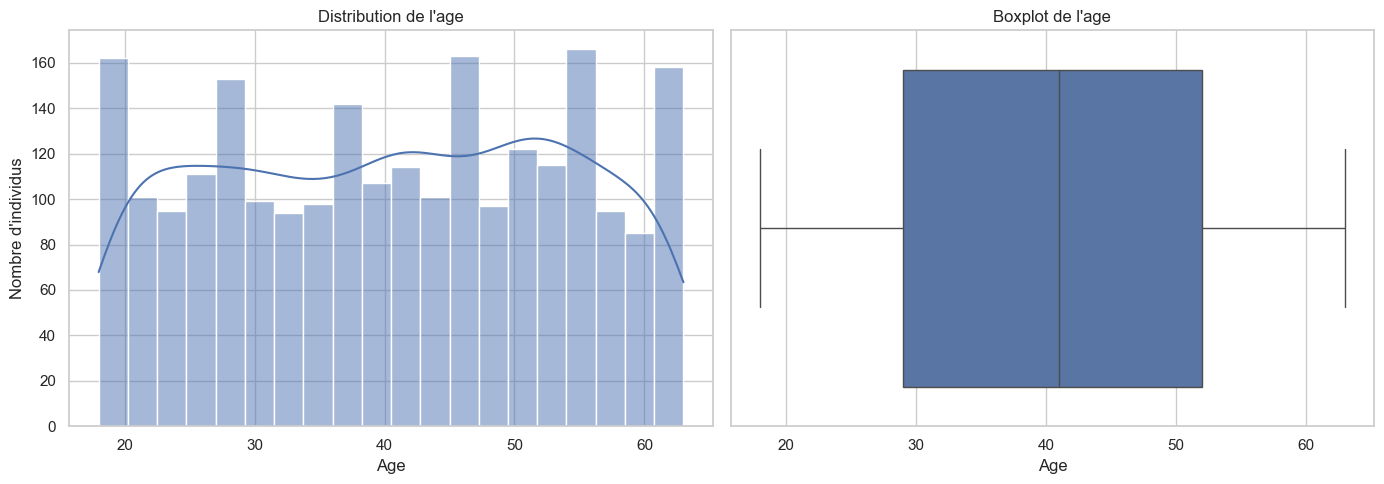

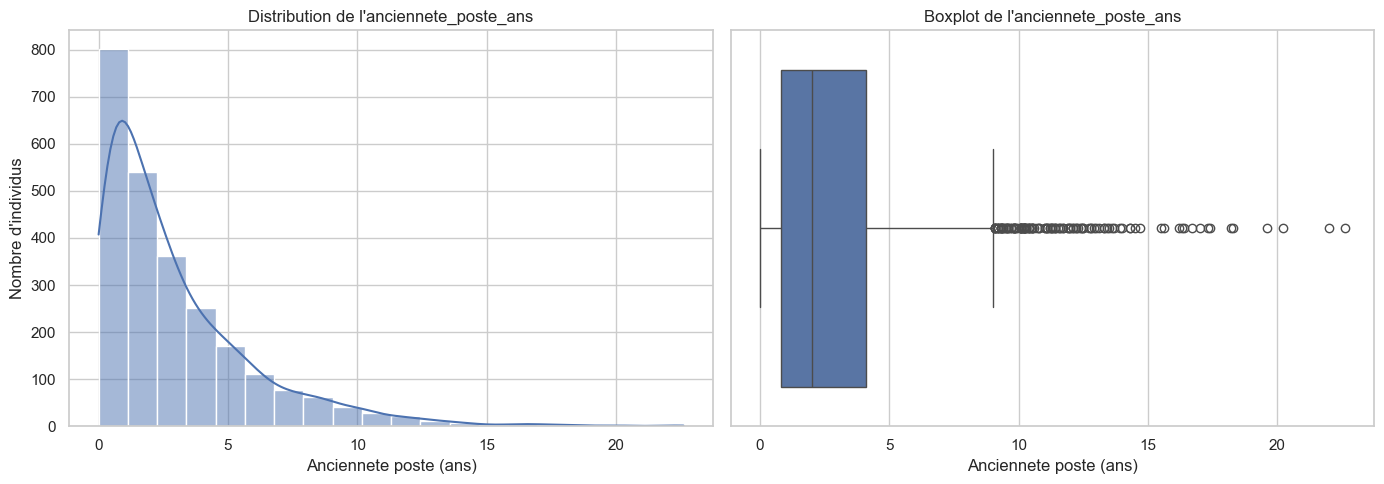

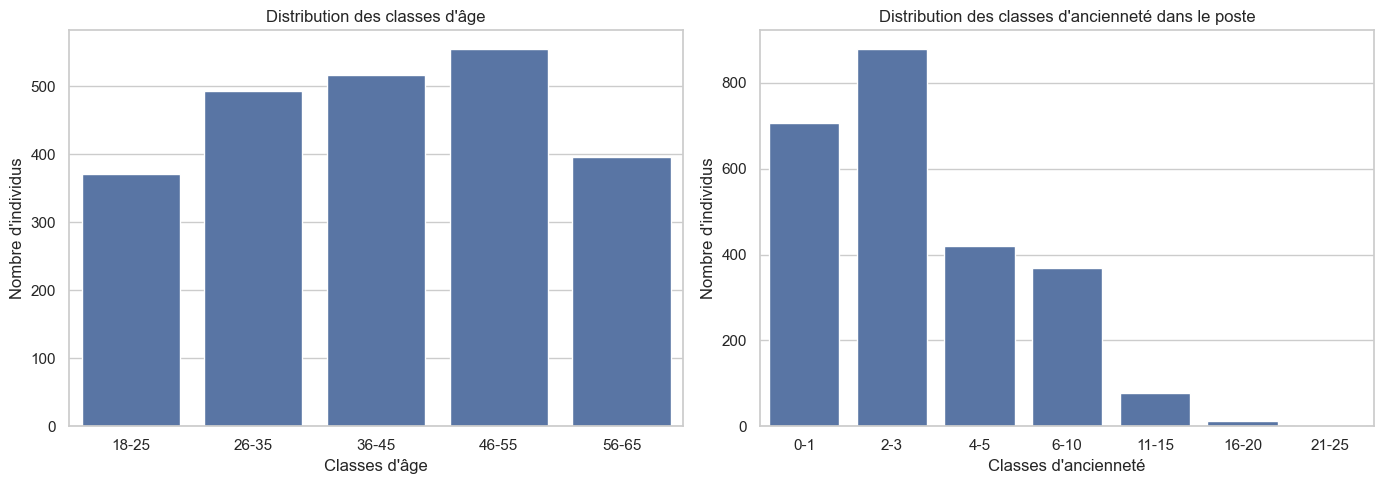

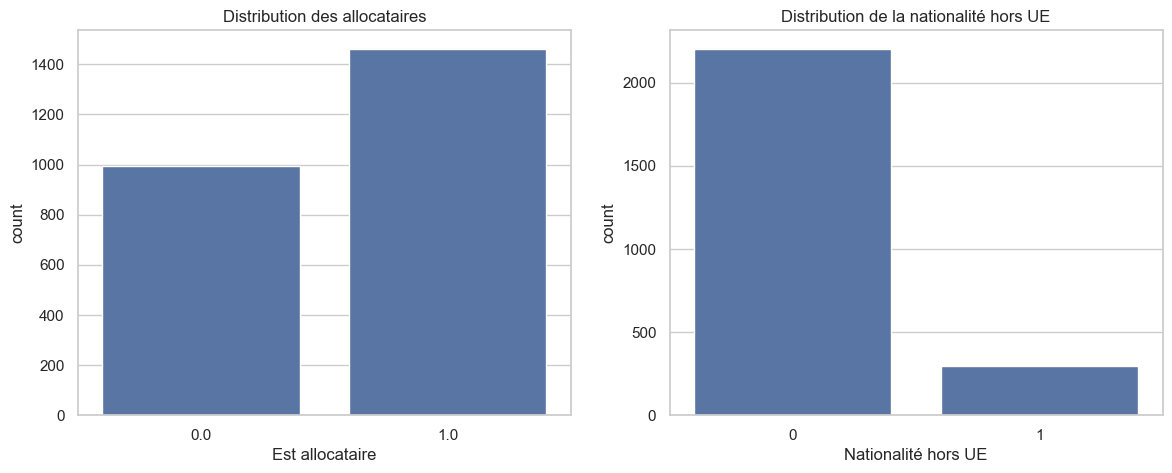

In [9]:
# Variables cibles => histogramme et boxplot
# Distribution de l'age : histo et boxplot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution de l'age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Nombre d'individus")

sns.boxplot(data=df, x="age", ax=axes[1])
axes[1].set_title("Boxplot de l'age")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

# distribution de l'anciennete_poste_ans
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution de l'anciennete_poste_ans")
axes[0].set_xlabel("Anciennete poste (ans)")
axes[0].set_ylabel("Nombre d'individus")

sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1])
axes[1].set_title("Boxplot de l'anciennete_poste_ans")
axes[1].set_xlabel("Anciennete poste (ans)")

plt.tight_layout()
plt.show()

# On répartie les ages et anciennetés dans le poste en classes pour mieux visualiser les relations
# Tranches d'ancienneté pour améliorer la lisibilité
bornes_anciennete = [0, 1, 3, 5, 10, 15, 20, 25]
labels_anciennete = ["0-1", "2-3", "4-5", "6-10", "11-15", "16-20", "21-25"]
bornes_age = [18, 25, 35, 45, 55, 65]
bornes_age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]
df["age_group"] = pd.cut(df["age"], bins=bornes_age, labels=bornes_age_labels)
df["anciennete_poste_group"] = pd.cut(df["anciennete_poste_ans"], bins=bornes_anciennete, labels=labels_anciennete)

# Deux graphiques pour visualiser la répartition des classes d'âge et d'ancienneté dans le poste
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.countplot(data=df, x="age_group", ax=axes[0])
axes[0].set_title("Distribution des classes d'âge")
axes[0].set_xlabel("Classes d'âge")
axes[0].set_ylabel("Nombre d'individus")
sns.countplot(data=df, x="anciennete_poste_group", ax=axes[1])
axes[1].set_title("Distribution des classes d'ancienneté dans le poste")
axes[1].set_xlabel("Classes d'ancienneté")
axes[1].set_ylabel("Nombre d'individus")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.countplot(data=df, x="est_allocataire", ax=axes[0])
axes[0].set_title("Distribution des allocataires")
axes[0].set_xlabel("Est allocataire")

sns.countplot(data=df, x="nationalite_hors_ue", ax=axes[1])
axes[1].set_title("Distribution de la nationalité hors UE")
axes[1].set_xlabel("Nationalité hors UE")

# Espace vertical supplémentaire entre les 2 lignes de graphes
fig.subplots_adjust(hspace=0.35)

plt.show()

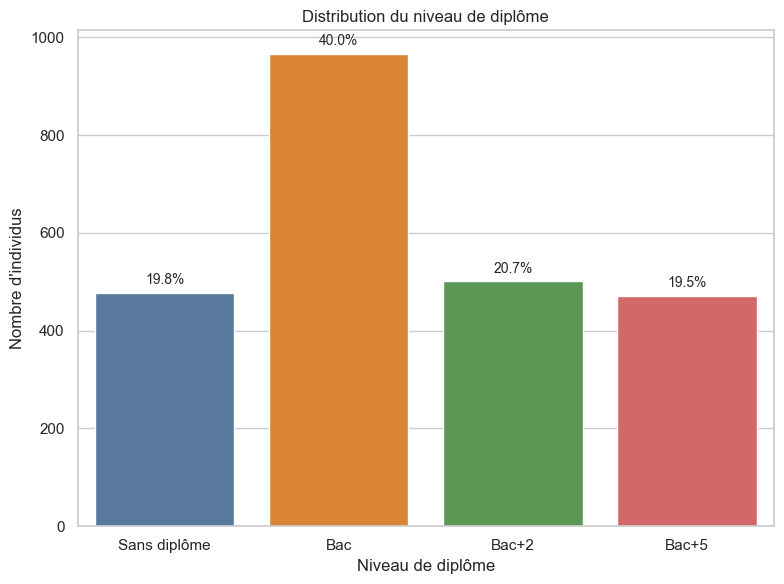

In [7]:
# Variables catégorielles => value_counts() (ou countplot)

ordre_diplome = ["Sans diplôme", "Bac", "Bac+2", "Bac+5"]
couleurs = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

fig, axes = plt.subplots(figsize=(8, 6))
sns.countplot(
    data=df,
    x="niveau_diplome",
    order=ordre_diplome,
    hue="niveau_diplome",
    hue_order=ordre_diplome,
    palette=couleurs,
    dodge=False,
    ax=axes,
    legend=False
)
axes.set_title("Distribution du niveau de diplôme")
axes.set_xlabel("Niveau de diplôme")
axes.set_ylabel("Nombre d'individus")

# Affichage des pourcentages au-dessus des barres
total = df["niveau_diplome"].notna().sum()
for p in axes.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        axes.annotate(
            f"{pct:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

plt.tight_layout()
plt.show()

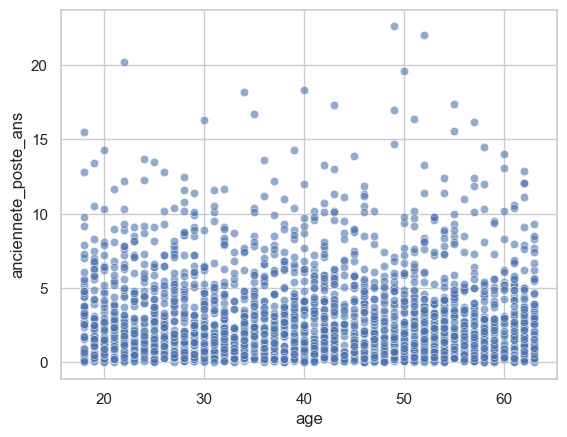

In [8]:
# Relations entre variables numériques
sns.scatterplot(data=df, x="age", y="anciennete_poste_ans", alpha=0.6)

plt.show()

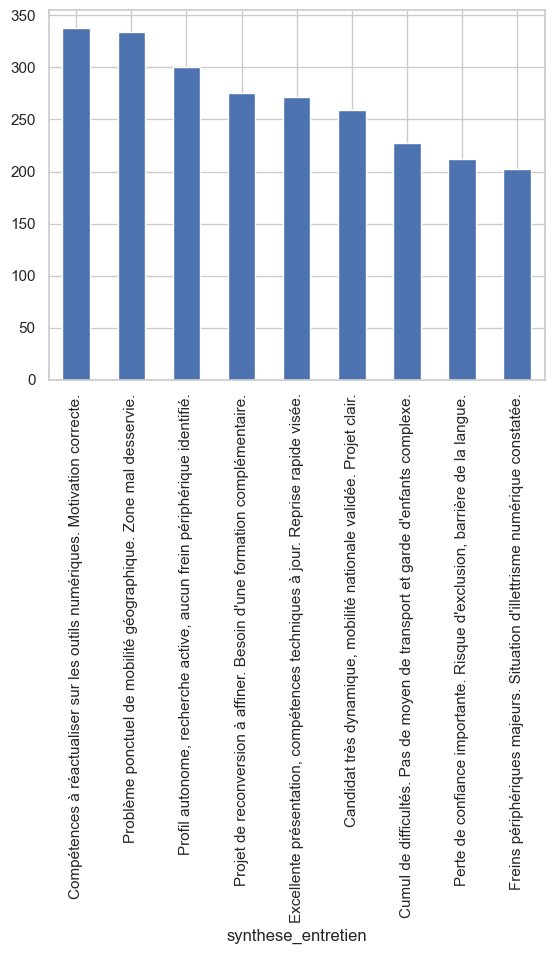

In [6]:
# Répartition des textes libres (compte le nombre d'utilisation pour chaque `synthese_entretien` unique)
df['synthese_entretien'].value_counts()
import matplotlib.pyplot as plt
df['synthese_entretien'].value_counts().plot(kind='bar')
plt.show()

**Observations**
- `age` : distribution plausible (18–63), sans anomalie majeure visible ni d'outliers aberrant. La répartition par tranche d'age montre une répartition globalement homogène.
- `anciennete_poste_ans` : distribution plus étalée (asymétrique à droite), quelques valeurs élevées mais globalement cohérentes. Même constat sur la répartition par tranche d'ancienneté.
- `est_allocataire` : distribution équilibrée.
- `nationalite_hors_ue` : distribution déséquilibrée à prendre en compte.
-  distribution de niveau de diplome montre une légère surreprésentation de personne avec le niveau de diplome : `Bac`
- Les relations entre `age` & `anciennete_poste_ans` confirme visuellement les quelques cas aberrants de jeune age avec une ancienneté trop élevée.
- `synthese_entretien` montre une répartition globalement homogène, de plus comme dit plus haut, variable très redondante.

---

### 3.4 Variable cible : équilibre des classes / distribution

In [11]:
df["classe_retour_emploi"].value_counts(normalize=True)

classe_retour_emploi
1    0.4448
0    0.3744
2    0.1808
Name: proportion, dtype: float64

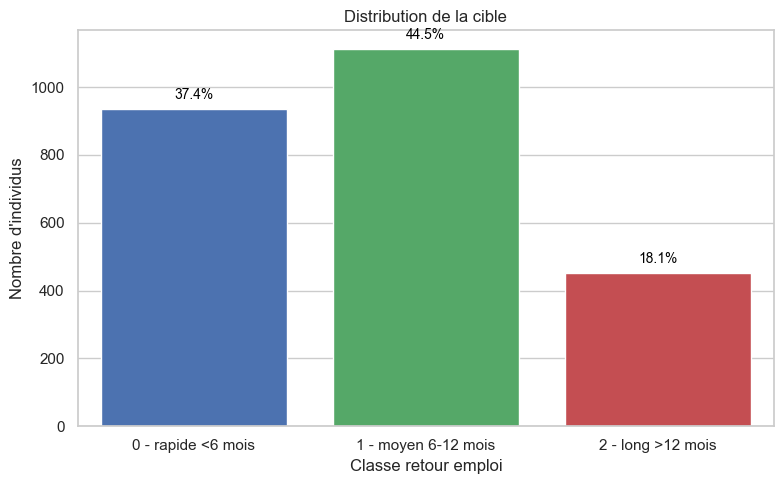

In [12]:
# Distribution de la cible
plt.figure(figsize=(8, 5))
repartition = sns.countplot(data=df, x="classe_retour_emploi", order=[0, 1, 2])
# 3 couleurs (une par classe)
colors = ["#4C72B0", "#55A868", "#C44E52"]
for i, p in enumerate(repartition.patches):
    p.set_facecolor(colors[i % len(colors)])
plt.title("Distribution de la cible")
plt.xlabel("Classe retour emploi")
# On met les labels
plt.xticks([0, 1, 2], ["0 - rapide <6 mois", "1 - moyen 6-12 mois", "2 - long >12 mois"])
plt.ylabel("Nombre d'individus")
# ajout des pourcentages sur les barres
total = len(df)
for p in repartition.patches:
    height = p.get_height()
    percentage = f"{height / total * 100:.1f}%"
    repartition.annotate(percentage, (p.get_x() + p.get_width() / 2., height), ha="center", va="bottom", fontsize=10, color="black", xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.show()

On observe un déséquilibre de la cible sur la classe 2 (long >12 mois), ce qui pourrait entrainer un biais.
On peut pour éviter ce biais :
- utiliser un split stratifié (`train_test_split(..., stratify=y)`)
- suivre des métriques adaptées (F1 macro, recall par classe, matrice de confusion)
- tester un rééquilibrage si besoin (`class_weight="balanced"`)

---

### 3.5 Corrélations & relations entre variables

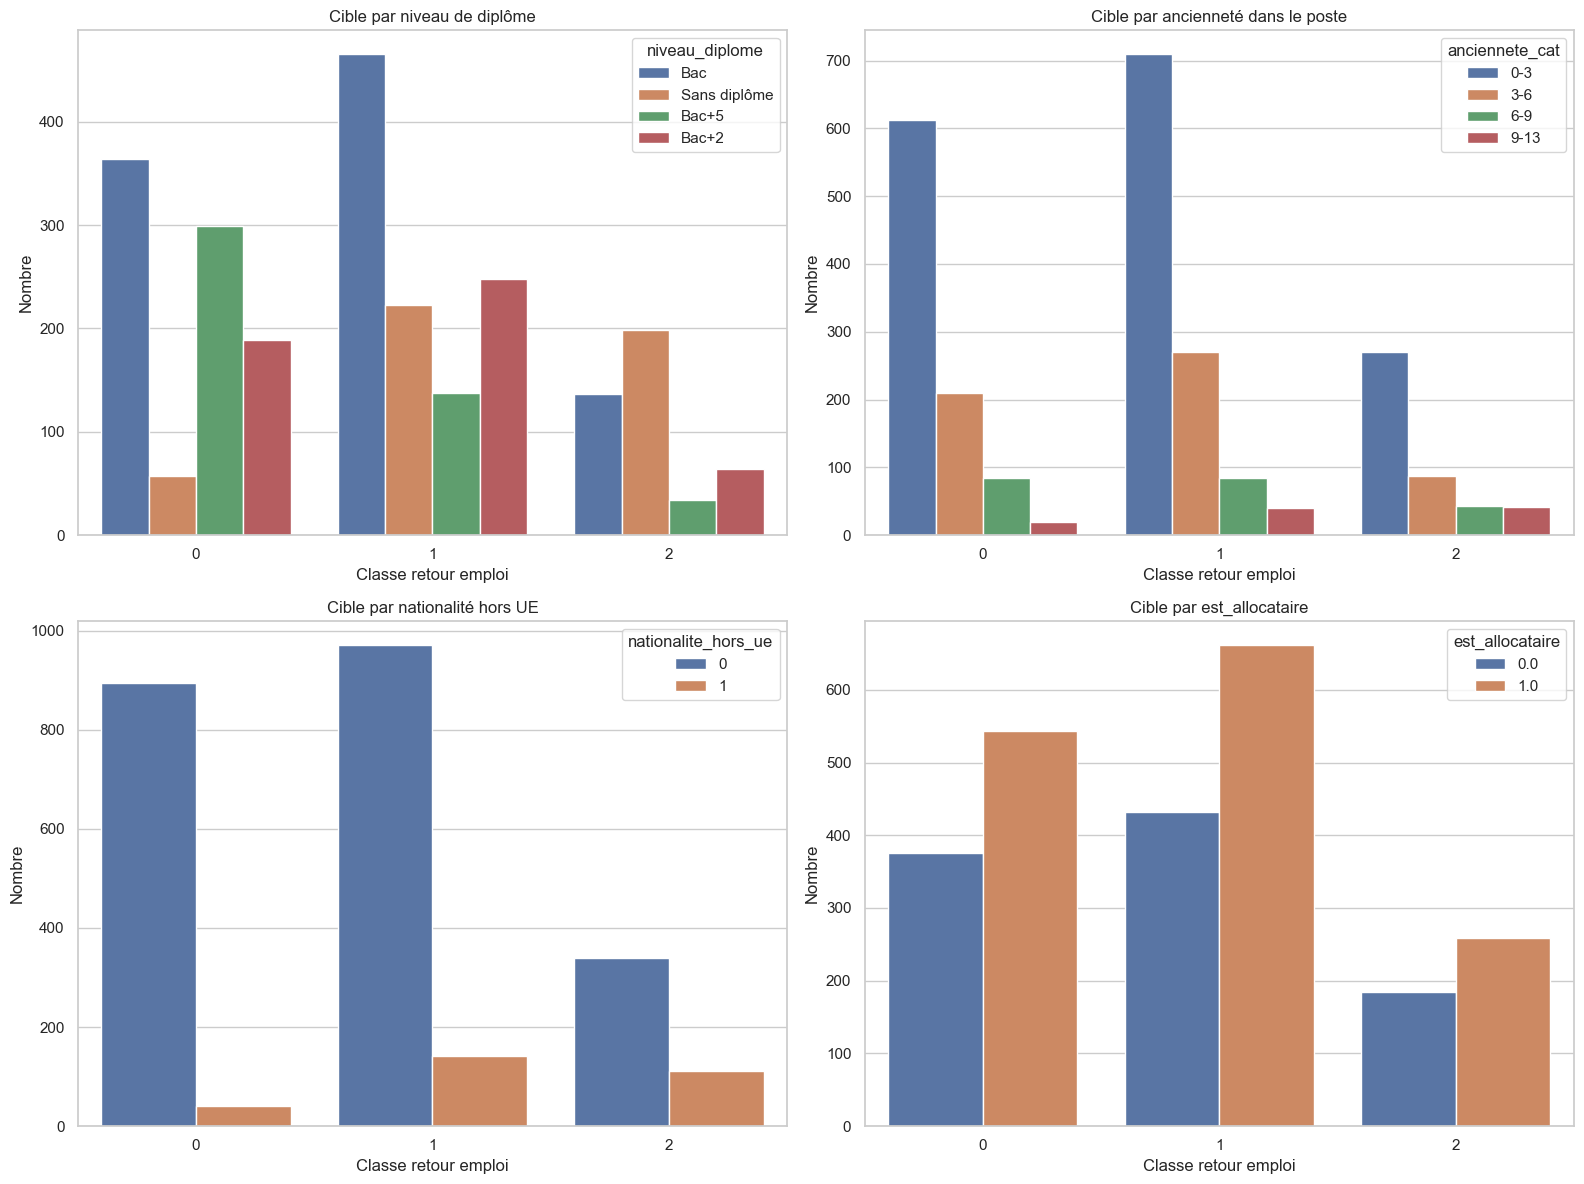

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Tranches d'ancienneté pour améliorer la lisibilité
bornes_anciennete = [0, 3, 6, 9, 13]
labels_anciennete = ["0-3", "3-6", "6-9", "9-13"]
df_plot = df.copy()
df_plot["anciennete_cat"] = pd.cut(
    df_plot["anciennete_poste_ans"],
    bins=bornes_anciennete,
    labels=labels_anciennete,
    include_lowest=True,
    right=False
)

# Répartition de la cible par niveau de diplôme
sns.countplot(data=df_plot, x="classe_retour_emploi", hue="niveau_diplome", ax=axes[0, 0])
axes[0, 0].set_title("Cible par niveau de diplôme")
axes[0, 0].set_xlabel("Classe retour emploi")
axes[0, 0].set_ylabel("Nombre")

# Répartition de la cible par ancienneté dans le poste (catégories)
sns.countplot(data=df_plot, x="classe_retour_emploi", hue="anciennete_cat", hue_order=labels_anciennete, ax=axes[0, 1])
axes[0, 1].set_title("Cible par ancienneté dans le poste")
axes[0, 1].set_xlabel("Classe retour emploi")
axes[0, 1].set_ylabel("Nombre")

# Répartition de la cible par nationalité hors UE
sns.countplot(data=df_plot, x="classe_retour_emploi", hue="nationalite_hors_ue", ax=axes[1, 0])
axes[1, 0].set_title("Cible par nationalité hors UE")
axes[1, 0].set_xlabel("Classe retour emploi")
axes[1, 0].set_ylabel("Nombre")

# Répartition de la cible par est_allocataire
sns.countplot(data=df_plot, x="classe_retour_emploi", hue="est_allocataire", ax=axes[1, 1])
axes[1, 1].set_title("Cible par est_allocataire")
axes[1, 1].set_xlabel("Classe retour emploi")
axes[1, 1].set_ylabel("Nombre")

plt.tight_layout()
plt.show()

**Observations**
- `niveau_diplome` : on observe une difficulté de retour à l'emploi pour les sans diplôme alors que pour les BAC+5 le retour à l'emploi est globalement rapide.
- `anciennete_poste_ans` : il y a un déséquilibre des classes avec une forte présence d'ancienneté courte et peu d'ancienneté longue.
- `nationalite_hors_ue` : on observe un impacte sur le retour à l'emploi pour les hors-UE (classe 1 & 2 bien plus présentes chez les hors-UE). De plus il y a un désiquilibre des classes avec peu de nationalité hors UE.
- `est_allocataire` : pas d'observation d'impact sur la cible. Données plutôt équilibrées.

In [4]:
# Répartition des classes pour le texte `synthese_entretien`
for classe in df['synthese_entretien'].unique():
    print(f"Classe {classe} : {len(df[df['synthese_entretien'] == classe])} occurrences")

Classe Compétences à réactualiser sur les outils numériques. Motivation correcte. : 338 occurrences
Classe Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe. : 227 occurrences
Classe Problème ponctuel de mobilité géographique. Zone mal desservie. : 334 occurrences
Classe Projet de reconversion à affiner. Besoin d'une formation complémentaire. : 275 occurrences
Classe Excellente présentation, compétences techniques à jour. Reprise rapide visée. : 272 occurrences
Classe Candidat très dynamique, mobilité nationale validée. Projet clair. : 259 occurrences
Classe Perte de confiance importante. Risque d'exclusion, barrière de la langue. : 212 occurrences
Classe Freins périphériques majeurs. Situation d'illettrisme numérique constatée. : 202 occurrences
Classe Profil autonome, recherche active, aucun frein périphérique identifié. : 300 occurrences
Classe nan : 0 occurrences


La variable textuelle est relativement équilibrée entre ses 9 modalités (de 202 à 338 occurrences). 

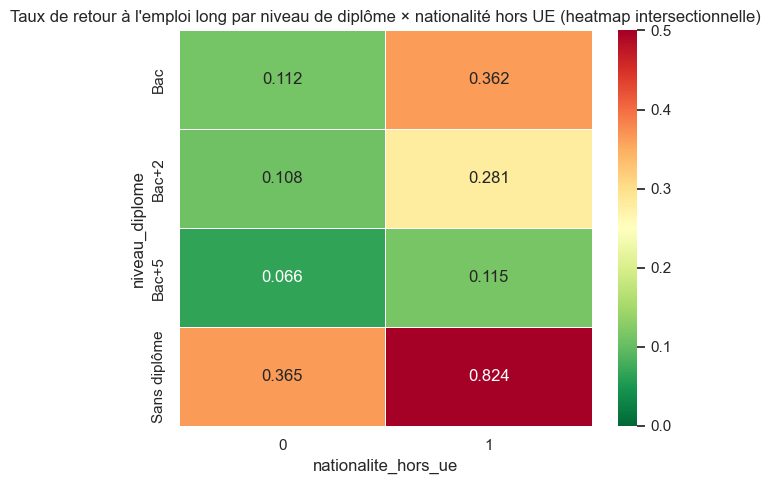

In [14]:
# Heatmap crosstab 
crosstab = pd.crosstab(
    df["niveau_diplome"],
    df["nationalite_hors_ue"],
    values=(df["classe_retour_emploi"] == 2).astype(int),
    aggfunc="mean",
).round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    crosstab,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=0.5,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Taux de retour à l'emploi long par niveau de diplôme × nationalité hors UE (heatmap intersectionnelle)")
plt.tight_layout()
plt.show()

Effet intersectionnel (niveau de diplome x nationnalité) :
- Moins le diplome est élevé, plus le risque de retour à l'emploi risque d'être long.
- A diplôme égal, le groupe hors UE est plus exposé à un retour long.
- Les 2 combinés montre une classe très défavorisée : les personne hors UE sans diplôme.

---

### 3.6 Analyse des biais & variables sensibles

In [5]:
# [3] Disparate impact (règle des 4/5)
def disparate_impact(df, sensible, target, positive):
    sr = df.groupby(sensible)[target].apply(lambda x: (x == positive).mean())
    if sr.max() == 0:                       # garde-fou : aucun cas positif → DI indéfini
        return None, sr
    di = sr.min() / sr.max()
    print(f"{sensible}: DI = {di:.3f}  ({'⚠️ SIGNAL' if di < 0.8 else '✅ OK'}), groupe défavorisé : {sr.idxmin()} ({sr.min():.3f}), groupe favorisé : {sr.idxmax()} ({sr.max():.3f})")
    return di, sr

disparate_impact(df, "age", "classe_retour_emploi", 0)
disparate_impact(df, "nationalite_hors_ue", "classe_retour_emploi", 0)
disparate_impact(df, "est_allocataire", "classe_retour_emploi", 0)
disparate_impact(df, "niveau_diplome", "classe_retour_emploi", 0)

age: DI = 0.134  (⚠️ SIGNAL), groupe défavorisé : 60.0 (0.081), groupe favorisé : 26.0 (0.604)
nationalite_hors_ue: DI = 0.342  (⚠️ SIGNAL), groupe défavorisé : 1 (0.139), groupe favorisé : 0 (0.406)
est_allocataire: DI = 0.980  (✅ OK), groupe défavorisé : 1.0 (0.371), groupe favorisé : 0.0 (0.379)
niveau_diplome: DI = 0.188  (⚠️ SIGNAL), groupe défavorisé : Sans diplôme (0.119), groupe favorisé : Bac+5 (0.635)


(0.187843718951596,
 niveau_diplome
 Bac             0.376812
 Bac+2           0.377246
 Bac+5           0.634820
 Sans diplôme    0.119247
 Name: classe_retour_emploi, dtype: float64)

D'après les analyses faites précédemment dans le chapitre 3 et le calcul des disparate impact sur les variables sensibles nous observons :
- Pour la variables sensible `age` :
    - une distribution de la cible globalement équilibrée
    - un groupe statistiquement défavorable (la plus petite proportion de retour rapide à l'emploi) : 60 ans
- Pour la variable sensible `nationalite_hors_ue` :
    - une distribution déséquilibrée avec peu de personne hors UE
    - un groupe statistiquement défavorable : nationalité hors UE
- Pour la variable sensible `est_allocataire` :
    - une distribution de la cible globalement équilibrée
    - pas de groupe statistiquement défavorable
- Pour la variable `niveau_diplome` :
    - une distribution légèrement déséquilibrée avec une surreprésentation de personne avec le niveau de diplome `Bac`
    - un groupe statistiquement défavorable : sans diplome

---

### 3.7 Synthèse EDA

**Top 5 enseignements de l’EDA** :

1. La donnée est exploitable pour une classification supervisée 3 classes, mais nécessite un prétraitement avant toute comparaison de modèles (manquants, cohérence : décisions au chapitre 4, cf résumé chapitre 4.4).
2. Le déséquilibre de cible est réel mais modéré (classe 2 minoritaire à 18,08%), ce qui impose stratification et métriques adaptées.
3. Le risque métier central de l’examen est confirmé par la distribution : les erreurs sur la classe 2 seront structurellement plus difficiles à réduire sans stratégie dédiée.
4. Les variables socio-professionnelles portent un signal prédictif fort (diplôme, nationalité hors UE), avec effet intersectionnel marqué (sans diplôme + hors UE atteint 0,824 de taux de retour long, donc risque de disparités structurelles très élevé).
5. Les signaux de disparité (DI < 0,8 sur âge, nationalité hors UE, diplôme) donc l’évaluation du modèle doit intégrer explicitement l’équité, pas seulement la performance.

**Hypothèses de travail pour la modélisation** :

1. Prétraitement indispensable avant apprentissage : imputation des valeurs manquantes, traitement des incohérences, typage robuste des variables, vectorisation du texte, extraction du département à partir du code INSEE, et pipeline reproductible.
2. Évaluer plusieurs modèles (Random Forest, LightGBM, XGBoost, ...) avec validation croisée stratifiée.
3. Formulation multi-classe conservée (0/1/2), avec surveillance renforcée de la classe 2 grace aux métriques : matrice de confusion, F1-score macro, recall.
4. Traiter explicitement l’erreur critique (classe 2 prédit 0) via une pondération des classes (plus de poids à la classe 2 pendant l’apprentissage), calibration/seuils (classer plus facilement en classe 2), ou fonction de coût asymétrique (matrice de coûts l'erreur critque est beaucoup plus pénalisé que les autres erreurs).
5. Comparer strictement les 4 scénarios de l’énoncé : approche multimodale complète, sans variables sensibles (approche éthique), diagnostic par le texte seul (NLP pure), données contextuelles pures (tabulaire seul), puis arbitrer performance/coût/équité.

**Risques de biais identifiés** :

- Biais de représentativité : sous-représentation des hors UE, pouvant dégrader la stabilité des prédictions de ce groupe.
- Biais de disparité statistique : DI nationalité hors UE (0,342) et diplôme (0,188) très en dessous de la règle des 4/5.
- Biais intersectionnel : groupe sans diplôme + hors UE fortement exposé au retour long.
- Biais de proxy : variables géographiques/professionnelles peuvent reconstruire indirectement des attributs sensibles.

**Révision des cibles 1.4 à la lumière de la donnée** :

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Réduire les erreurs critiques (classe 2 prédit 0) | <5% | <5% | On va essayer de minimiser l'erreur critque qui a le plus fort coût humain et financier. Cependant la classe 2 est minoritaire et il y a peu de données, cela sera dur à prédire donc on reste sur la même cible. |
| Modèle | F1-score macro | F1-score macro ≥ 0.75 | F1-score macro ≥ 0.70 | La classe 2 est minoritaire et il y a peu de données, une revue à la baisse est nécessaire. |
| Modèle | Matrice de confusion | Recall ≥ 85% pour classe 2 | Recall ≥ 70% pour classe 2 | La classe 2 est minoritaire et il y a peu de données, une revue à la baisse est nécessaire. |
| Opérationnel | Temps de réponse API en production | Latence : P50 < 250 ms | on ne modifie pas | ça reste réaliste |
| Robustesse | Traiter les manquants et les incohérences | non défini précédemment | 100% | Il faut que les manquants soient traités à 100% |
| Equité | Limiter les disparités entre sous-groupes sensibles | non défini précédemment | écart de recall classe 2 entre groupes ≤ 10 | L’EDA montre des DI < 0,8 et donc un risque de discrimination statistique |


---
## 4. Préparation des données

### 4.1 Train/test split

On préprare un découpage :
- Avec une répartition 80% pour apprendre et 20% pour l'évaluation, pour un compromis volume/fiabilité (`test_size=0.2`).
- Sans fuite de données (split avant pipeline).
- Equilibré en gardant la même proportion des classes 0/1/2 dans train et test (`stratify=y`).
- Reproductible (`random_state=RANDOM_STATE`) pour garantir que la découpe reste identique à chaque exécution

Mes choix pour le traitement de certaines colonnes :
- Pour la modélisation on garde l'age continu plutôt que par tranche d'age. Cela permet de garder toute l'information et ne par perdre du signal en regroupant.
- De même pour l'ancienneté du poste.
- Pour le code INSSE j'ai décidé de le regrouper en département (signal géographique qui reste pertinent) pour éviter une granularité trop riche qui pourrait entrainer un surapprentissage sur cette volumétrie.
- Pour les incohérences, on remplace les valeurs de l'ancienneté par Nan qui sera ensuite traité au préprocessing comme les autres colonnes numériques.
- Le TF-IDF est retenu comme méthode de vectorisation du texte car il est adapté aux textes courts, peu coûteux et facilement intégrable dans un pipeline scikit-learn. Il permet de pondérer les mots selon leur importance dans chaque synthèse. Cependant, la forte redondance du texte, avec seulement 9 formulations uniques, limite sa capacité de généralisation et expose le modèle à un risque de surapprentissage.

In [11]:
# Séparation des features et de la target
X, y = df.drop(columns=["classe_retour_emploi"]), df["classe_retour_emploi"]

# Normalisation défensive des noms de colonnes (espaces/BOM invisibles).
X.columns = X.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

# Colonnes temporaires créées pendant l'EDA : on les retire avant modélisation.
X.drop(columns=["age_group", "anciennete_poste_group"], inplace=True, errors="ignore")

# extraction du département à partir du code INSEE qu'on exclue ensuite
if "code_insee_commune" in X.columns:
    X["departement"] = X["code_insee_commune"].astype(str).str[:2]
X.drop(columns=["code_insee_commune"], inplace=True, errors="ignore")

# traitement des incohérences => on remplace les valeurs incohérentes par NaN pour l'ancienneté dans le poste
if "age" in X.columns and "anciennete_poste_ans" in X.columns:
    mask_incoherent = (X["age"] - X["anciennete_poste_ans"]) <= 15
    X.loc[mask_incoherent, "anciennete_poste_ans"] = np.nan

# On exclue les identifiants `usager_id` qui n'apportent pas d'information pour la prédiction
if "usager_id" in X.columns:
    X.drop(columns=["usager_id"], inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"\nDimensions du Dataframe : {X.shape}, répartition de la cible : {y.value_counts().to_dict()}")
# Affiche le nombre d'observations dans chaque sous-ensemble.
print(f"Répartition après split : Train : {X_train.shape} (répartition cible : {y_train.value_counts().to_dict()}) | Test : {X_test.shape} (répartition cible : {y_test.value_counts().to_dict()})")

# Répartition avant et après split de la cible sous forme de tableau de proportions
display(pd.DataFrame({
    "Avant split": y.value_counts(normalize=True).round(3),
    "Train": y_train.value_counts(normalize=True).round(3),
    "Test": y_test.value_counts(normalize=True).round(3)
}))


Dimensions du Dataframe : (2500, 8), répartition de la cible : {1: 1112, 0: 936, 2: 452}
Répartition après split : Train : (2000, 8) (répartition cible : {1: 889, 0: 749, 2: 362}) | Test : (500, 8) (répartition cible : {1: 223, 0: 187, 2: 90})


,Avant split,Train,Test
classe_retour_emploi,,,
1,0.445,0.444,0.446
0,0.374,0.374,0.374
2,0.181,0.181,0.180


### 4.2 Pipeline de préprocessing : numériques + catégorielles (nominale & ordinale) + Texte

Préprocessing unique, reproductible et sans fuite.

In [12]:
# Définition des colonnes numériques, catégorielles et textuelles
colonnes_num = ["age", "anciennete_poste_ans"]
colonnes_cat = ["nationalite_hors_ue", "est_allocataire", "code_rome_vise", "departement"]
colonnes_ord = ["niveau_diplome"]
ordre_diplome = ["Sans diplôme", "Bac", "Bac+2", "Bac+5"]
colonnes_txt = ["synthese_entretien"]

# 1. Sous-pipeline numérique
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # Remplace les valeurs manquantes par la médiane
    ("scaler", StandardScaler())                     # mise à l'échelle
])

# 2. Sous-pipeline catégoriel ordinal (ordre imposé !)
ordinal_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),      # Remplace les valeurs manquantes par la modalité la plus fréquente
    ("ordinal", OrdinalEncoder(categories=[ordre_diplome]))    # Encode les catégories selon l'ordre défini dans ordre_diplome
])

# 3. Sous-pipeline catégoriel one-hot
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),                      # Remplace les valeurs manquantes par la modalité la plus fréquente
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))    # Encode les catégories en one-hot, ignore les modalités inconnues dans le jeu de test
])

# 4. Sous-pipeline textuel (TF-IDF) => vectorisation du texte
text_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="")),        # Remplace les valeurs manquantes par une chaîne vide
    ("to_1d", FunctionTransformer(np.ravel, validate=False)),   # Transforme le tableau 2D en 1D pour TfidfVectorizer
    ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1,2)))                # Vectorisation TF-IDF avec n-grammes (1,2)
])

print("Pipelines de prétraitement définis avec succès.")

Pipelines de prétraitement définis avec succès.


### 4.3 Scénarios de jeux de données

J'ai choisi de respecter les 4 scénarios de l'énoncé :

| Scénario | Variables conservées | Justification |
|---|---|---|
| Scénario 1 — Approche multimodale complète | Toutes les variables (tabulaires + texte vectorisé) | Baseline complète de référence |
| Scénario 2 — Sans variables sensibles (Approche Éthique) | Variables non sensibles uniquement (avec justification CNIL/RGPD) | Mesurer l’impact du retrait des variables sensibles sur les performance / les biais |
| Scénario 3 — Diagnostic par le texte seul (NLP pure) | `synthese_entretien` uniquement | Tester la robustesse du modèle de langage face à des verbatims contenant du bruit stochastique |
| Scénario 4 — Données contextuelles pures (Tabulaire seul) | Variables tabulaires uniquement (sans texte) | Mesurer l’apport du texte en comparaison du tabulaire seul |

### 4.4 Synthèse préparation

La préparation des données repose sur un pipeline unique, reproductible et sans fuite de données. Le découpage train/test est effectué en amont, avec stratification de la cible et random_state fixé, afin de préserver la distribution des classes et garantir la comparabilité des résultats. Le préprocessing combine ensuite un traitement adapté à chaque type de variable via un ColumnTransformer :
- imputation médiane et standardisation pour les variables numériques
- remplacement des valeurs manquantes par la modalité la plus fréquente, puis encodage ordinal pour le niveau de diplôme
- remplacement des valeurs manquantes par la modalité la plus fréquente puis encodage one-hot pour les variables catégorielles
- remplacement des valeurs manquantes par une chaîne vide, puis vectorisation TF-IDF pour la variable textuelle.

Des choix de robustesse ont été intégrés, notamment  :
- le retrait de l’identifiant usager
- l’extraction du département depuis le code INSEE
- la gestion des incohérences métier sur l’ancienneté (cf chapitre 3.5).

Quatre scénarios ont été construits pour répondre à l’énoncé et permettre un arbitrage performance/équité :
- approche multimodale complète
- approche sans variables sensibles
- diagnostic texte seul
- tabulaire seul.

Cette structuration permet d’isoler l’apport réel du texte, de mesurer l’impact du retrait de variables sensibles, et de comparer des options déployables selon les contraintes métier et réglementaires.

La traçabilité est assurée par :
- la documentation de la session (date, versions Python/librairies, commit Git, version/source du dataset)
- la fixation des paramètres de reproductibilité
- la formalisation explicite des hypothèses de préparation.

L’ensemble fournit une base solide pour la comparaison des modèles en section suivante, dans des conditions expérimentales maîtrisées.

### 4.5 Assertions de qualité

In [13]:
# --- Sanite globale du dataset source ---
assert df.shape[0] > 0, "Dataset vide après préparation"
assert df["classe_retour_emploi"].isna().sum() == 0, "Manquants résiduels dans la cible"
assert df.duplicated().sum() == 0, "Doublons résiduels"
# Verifie que la cible ne contient que les classes attendues (multiclasse 0/1/2).
assert set(df["classe_retour_emploi"].unique()).issubset({0, 1, 2}), "Cible binaire attendue"

# --- Sanite du split train/test ---
assert X_train.shape[0] > 0, "Ensemble d'entraînement vide"
assert X_test.shape[0] > 0, "Ensemble de test vide"
# Verifie qu'aucune ligne n'a ete perdue ou dupliquee pendant le split.
assert (X_train.shape[0] + X_test.shape[0]) == df.shape[0], "Split incomplet"
assert y_train.isna().sum() == 0, "Manquants résiduels dans la cible d'entraînement"
assert y_test.isna().sum() == 0, "Manquants résiduels dans la cible de test"
# Verifie la coherence des classes dans les labels train/test.
assert set(y_train.unique()).issubset({0, 1, 2}), "Cible d'entraînement binaire attendue"
assert set(y_test.unique()).issubset({0, 1, 2}), "Cible de test binaire attendue"

# --- Coherence des features ---
# Les colonnes de train doivent provenir des colonnes preparees de X.
assert set(X_train.columns).issubset(set(X.columns)), "Colonnes incohérentes entre train et dataset initial"
# Train et test doivent avoir exactement les memes colonnes pour passer dans le meme pipeline.
assert set(X_train.columns) == set(X_test.columns), "Colonnes incohérentes entre train et test"

# Les colonnes utilisees doivent correspondre aux listes declarees pour le preprocessing.
colonnes_definies = set(colonnes_num + colonnes_cat + colonnes_ord + colonnes_txt)
colonnes_train = set(X_train.columns)
colonnes_test = set(X_test.columns)

extra_train = sorted(colonnes_train - colonnes_definies)
extra_test = sorted(colonnes_test - colonnes_definies)
missing_train = sorted(colonnes_definies - colonnes_train)
missing_test = sorted(colonnes_definies - colonnes_test)

assert not extra_train, f"Colonnes non déclarées dans train: {extra_train}"
assert not extra_test, f"Colonnes non déclarées dans test: {extra_test}"
assert not missing_train, f"Colonnes déclarées absentes de train: {missing_train}"
assert not missing_test, f"Colonnes déclarées absentes de test: {missing_test}"

Ces assertions constituent un garde-fou avant la modélisation. Elles valident que les données sont exploitables (non vides, sans manquants critiques, sans incohérences de structure), que le split train/test est correct, et que les colonnes injectées dans le pipeline sont alignées avec le schéma de préprocessing. En cas d’échec, l’exécution s’arrête immédiatement, ce qui permet de détecter tôt une dérive de données ou une erreur de préparation et de fiabiliser les comparaisons de modèles.

---

## 5. Modélisation & entraînement

### 5.0 Familles de modèles candidates

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn, XGBoost) | Oui : données structurées (tabulaires + texte vectorisé), 2 500 lignes < 1M, classification supervisée 3 classes | faible | élevée | aucune | **Retenue** : baseline principale et candidats prioritaires pour comparer performance, robustesse et coût |
| Deep Learning (Keras / PyTorch) | Peu adapté ici : volume modeste et texte court/redondant, risque de surcoût pour un gain limité | élevé (GPU train) | faible | aucune (modèle local) | **Écartée à ce stade** : retour sur investissement défavorable par rapport aux modèles classiques sur ce jeu de données (limité & simple) |
| SLM local (Ollama, modèles ≤ 7B) | Peu adapté : utile pour génération, moins pertinent pour ce problème de classification structurée | moyen | moyenne | aucune | **Écartée** : complexité supplémentaire sans bénéfice attendu clair sur les métriques cibles |
| LLM API + RAG | Non adapté au besoin principal : RAG pertinent pour QA documentaire, pas pour classification tabulaire/texte court supervisée | élevé (€/token) | faible | forte (OpenAI / Anthropic / Mistral) | **Écartée** : dépendance fournisseur forte, coût élevé, faible alignement avec l’objectif métier et l’architecture cible |
| Architecture agentique (multi-LLM, tools) | Non adaptée : surdimensionnée pour une prédiction de classe unique | très élevé | très faible | forte | **Écartée** : complexité opérationnelle importante et valeur ajoutée limitée pour ce cas d’usage |    

### 5.0.1 Synthèse familles

La famille retenue est le ML classique (scikit-learn, XGBoost, LightGBM), car elle est la mieux adaptée pour ce cas d’usage : classification supervisée 3 classes sur un dataset multimodal de taille modérée (2 500 lignes). Elle apporte un bon compromis performance, un coût d’inférence limité et de la robustesse.

Les autres familles (Deep Learning, SLM, LLM+RAG, agentique) sont écartées à ce stade, principalement pour cause de surcoût et de complexité, avec un gain attendu limité sur des données tabulaires + texte court vectorisé.

La contrainte décisive est le rapport valeur métier / coût total (train + inférence), complété par l’exigence d’explicabilité et de déployabilité maîtrisée (contexte de service public).

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| LogisticRegression | Linéaire | Baseline robuste, rapide et stable, utile pour comparer coût/performance | faible / faible | élevée |
| XGBoost Classifier | Ensemble (boosting) | Très bon compromis attendu sur tabulaire + texte vectorisé, capte bien les interactions et gère les déséquilibres via pondération des classes | moyen à élevé / moyen | moyenne |
| LightGBM Classifier | Ensemble (boosting) | Alternative performante et généralement plus rapide que XGBoost, adaptée aux features encodées en grande dimension (beaucoup de colonnes dû aux one-hot et au TF-IDF) | moyen / faible à moyen | moyenne |
| RandomForestClassifier | Ensemble (bagging) | Modèle robuste et simple à entraîner, bon point de comparaison face aux méthodes de boosting | moyen / faible | moyenne |

On ajoute un modèle plancher pour vérifier que nos modèles apprennent bien quelque chose.

> Glossaire :
>- Bagging : entraîne plusieurs arbres indépendamment sur des échantillons aléatoires du jeu de données, puis agrège leurs prédictions par vote.
>- Boosting : entraîne les arbres séquentiellement : chaque nouvel arbre cherche à corriger les erreurs des précédents.

### 5.2 Entraînement & validation croisée

La règle d'or absolue :

    Comparabilité : deux modèles ne se comparent que sur le même split, les mêmes métriques, le même prétraitement, les mêmes hyperparamètres par défaut (sauf variante annoncée).

In [5]:
# Pour chaque modèle choisi : Pipeline(preprocessor + estimator) + cross_validate
# Objectif : utiliser un ColumnTransformer différent selon chacun des 4 scénarios

# 1) Définition des modèles candidats (paramètres par défaut)
candidats = {
    "Dummy": DummyClassifier(
        strategy="prior"
    ),
    "lr_clf": LogisticRegression(
        solver="lbfgs",
        C=1.0,
        class_weight=None,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "xgb_clf": XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        learning_rate=None,
        max_depth=None,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE
    ),
    "lgbm_clf": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.01,
        num_leaves=31,
        min_child_samples=20,
        colsample_bytree=1.0,
        random_state=RANDOM_STATE,
        force_row_wise=True,
        verbosity=-1
    ),
    "rf_clf": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        max_features='sqrt',
        class_weight=None,
        n_jobs=None,
        random_state=RANDOM_STATE
    ),
}

# 2) Définition des colonnes par scénario (chaque scénario aura son ColumnTransformer dédié)
scenarios = {
    "S1_multimodale_complete": {
        "num": colonnes_num,
        "cat": colonnes_cat,
        "ord": colonnes_ord,
        "txt": colonnes_txt,
    },
    "S2_sans_variables_sensibles": {
        "num": ["anciennete_poste_ans"],
        "cat": ["code_rome_vise"],
        "ord": ["niveau_diplome"],
        "txt": ["synthese_entretien"],
    },
    "S3_texte_seul": {
        "num": [],
        "cat": [],
        "ord": [],
        "txt": ["synthese_entretien"],
    },
    "S4_tabulaire_seul": {
        "num": ["age", "anciennete_poste_ans"],
        "cat": ["nationalite_hors_ue", "est_allocataire", "code_rome_vise", "departement"],
        "ord": ["niveau_diplome"],
        "txt": [],
    },
}

# Fonction pour construire un ColumnTransformer selon les colonnes du scénario
def build_preprocessor(cols):
    transformers = []
    if cols["num"]:
        transformers.append(("num", num_pipe, cols["num"]))
    if cols["cat"]:
        transformers.append(("cat", cat_pipe, cols["cat"]))
    if cols["ord"]:
        transformers.append(("ord", ordinal_pipe, cols["ord"]))
    if cols["txt"]:
        transformers.append(("txt", text_pipe, cols["txt"]))

    # remainder="drop" => seules les colonnes listées dans transformers sont conservées et transformées
    return ColumnTransformer(transformers=transformers, remainder="drop")

# 3) Validation croisée stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Calcul du recall classe 2
def recall_class_2(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=[2], average="macro", zero_division=0)

# Calcul de la precision classe 2
def precision_class_2(y_true, y_pred):
    return precision_score(y_true, y_pred, labels=[2], average="macro", zero_division=0)

# Calcul du f1-score classe 2
def f1_class_2(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=[2], average="macro", zero_division=0)

# Calcul de l'erreur critique : proportion de prédictions 0 pour les vrais labels 2
def critical_error_2_to_0(y_true, y_pred):
    mask = (y_true == 2)
    if mask.sum() == 0:
        return 0.0
    return (y_pred[mask] == 0).mean()

In [11]:
# 4) Boucle sur les scénarios et les modèles pour effectuer la validation croisée et collecter les résultats
lignes = []
for scenario_name, scenario_cols in scenarios.items():
    preprocessor_scenario = build_preprocessor(scenario_cols)

    for nom_modele, modele in candidats.items():
        pipe = Pipeline([("preparation", preprocessor_scenario), ("modele", modele)])

        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "f1_macro": "f1_macro",
                "recall_c2": make_scorer(recall_class_2),
                "precision_c2": make_scorer(precision_class_2),
                "f1_c2": make_scorer(f1_class_2),
                "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
                "neg_log_loss": "neg_log_loss",
            },
            error_score="raise",
            n_jobs=1
        )

        lignes.append({
            "scénario": scenario_name,
            "modèle": nom_modele,
            "f1_macro (CV)": round(scores["test_f1_macro"].mean(), 3),
            "écart-type": round(scores["test_f1_macro"].std(), 3),
            "temps fit (s)": round(scores["fit_time"].mean(), 2),
            "recall_classe_2 (CV)": round(scores["test_recall_c2"].mean(), 3),
            "precision_classe_2 (CV)": round(scores["test_precision_c2"].mean(), 3),
            "f1_classe_2 (CV)": round(scores["test_f1_c2"].mean(), 3),
            "erreur_critique_2_vers_0 (CV)": round(-scores["test_critical_2_to_0"].mean(), 3),
            "log_loss (CV)": round(-scores["test_neg_log_loss"].mean(), 3),
            "temps score (s)": round(scores["score_time"].mean(), 2),
        })

resultats_cv = pd.DataFrame(lignes).sort_values(["scénario", "f1_macro (CV)"], ascending=[True, False])

`StratifiedKFold` est le plus adapté ici car :
- Problème multi-classe avec léger déséquilibre : StratifiedKFold conserve les proportions des classes dans chaque fold.
- Comparaison équitable : même split pour Dummy, LogisticRegression, XGB, LGBM, RandomForest.
- shuffle=True + random_state : résultats plus stables et reproductibles.

### 5.3 Métriques retenues & justification

Le problème sur une **classification multi-classes (0 / 1 / 2)** avec un léger déséquilibre et un enjeu métier asymétrique : rater un demandeur d'emploi en grande difficulté (classe 2 : risque de longue durée) coûte bien plus cher socialement que l'inverse. Les métriques sont donc choisies pour refléter à la fois la performance globale et les risques métier critiques.

| Métrique | Ce qu'elle mesure | Pourquoi elle est retenue ici |
|---|---|---|
| <span style="color: green;">**f1_macro**</span> | Moyenne des F1 de chaque classe (precision × recall équilibrés), pondération égale entre classes | **Mesure principale** : pénalise les modèles qui ignorent une classe. Insensible au déséquilibre car ne dépend pas des effectifs. Permet de comparer tous les candidats sur le même pied. |
| **écart-type (f1_macro)** | Dispersion du f1_macro entre les 5 folds de la validation croisée | Mesure la **stabilité** du modèle : un f1_macro élevé mais avec un écart-type fort indique un modèle instable, sensible à la composition du fold. Un modèle stable (faible écart-type) est plus fiable en production. |
| <span style="color: green;">**recall_classe_2**</span> | Parmi tous les vrais demandeurs d'emploi de classe 2 (risque de longue durée), quelle fraction le modèle détecte-t-il ? | Classe 2 = profils les plus vulnérables. Un recall faible signifie qu'on rate des personnes qui auraient besoin d'un accompagnement renforcé → coût social élevé. **Sensibilité prioritaire.** |
| **precision_classe_2** | Parmi les prédictions classe 2, quelle fraction est vraiment classe 2 ? | Évite les fausses alertes : déclencher un accompagnement renforcé inutilement est coûteux en ressources. Complète le recall pour ne pas sur-classifier. |
| **f1_classe_2** | Moyenne harmonique de recall et precision sur la seule classe 2 | Synthèse équilibrée du compromis détection / faux positifs sur la classe la plus sensible. Métrique de décision complémentaire au f1_macro. |
| <span style="color: green;">**erreur_critique_2_vers_0**</span> | Taux de demandeurs d'emploi réellement classe 2 prédits comme classe 0 (pas de difficulté) | **Erreur la plus grave** du système : orienter vers "retour rapide" quelqu'un qui a besoin d'un soutien long. Cette métrique custom quantifie précisément ce risque. À minimiser absolument. |
| **log_loss** | Pénalise les probabilités mal calibrées (confiance élevée sur une mauvaise prédiction) | Mesure la qualité de calibration : un modèle qui dit "95 % classe 0" quand classe 2 est plus dangereux qu'un modèle incertain. Utile pour comparer la fiabilité des sorties de probabilité entre candidats. Le plus proche de 0 est le mieux |

**Règle de décision** : le modèle retenu doit maximiser `f1_macro` et `recall_classe_2`, minimiser `erreur_critique_2_vers_0`, avec un `log_loss` raisonnable et un écart-type faible. Un modèle qui excelle en f1_macro mais échoue sur `erreur_critique_2_vers_0` est disqualifié par rapport au risque critique métier.


### 5.4 Comparaison des modèles : tableau de scores CV

#### 5.4.1 Matrices de confusion (Validation Croisée)

La **matrice de confusion** synthétise les flux d'erreurs du modèle :

```
            Prédiction
            Classe 0  Classe 1  Classe 2
Vraie 0    [  TN  ]  [  FP  ]  [  FP  ]   ← Faux positifs : retour rapide mal classé
Vraie 1    [  FN  ]  [  TN  ]  [  FP  ]   ← Faux Négatifs / Faux positifs
Vraie 2    [ FN** ]  [  FN  ]  [  TN  ]   ← La ligne critique : erreurs 2→0 désastreuses
```

**Lecture** :
- **Diagonale** = prédictions correctes (rappel)
- ****Vrais classe 2** qui deviennent classe 0 = risque métier maximal


Les matrices ci-dessous correspondent au **meilleur modèle de chaque scénario** (F1-macro maximal) :


Matrices de confusion (Validation Croisée) - Meilleur modèle par scénario



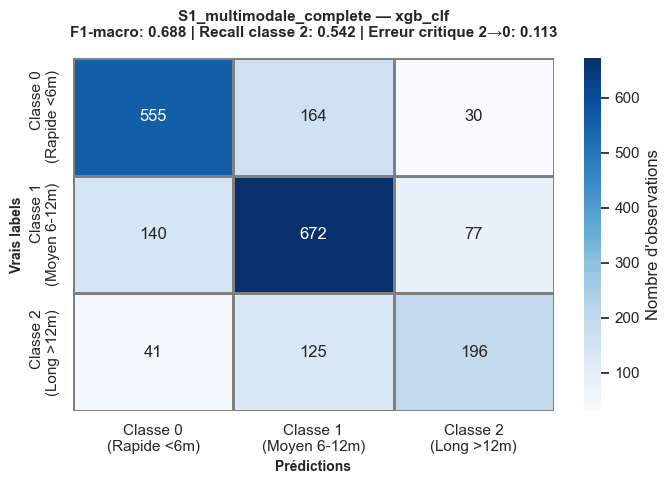


S1_multimodale_complete — xgb_clf: OK ✓



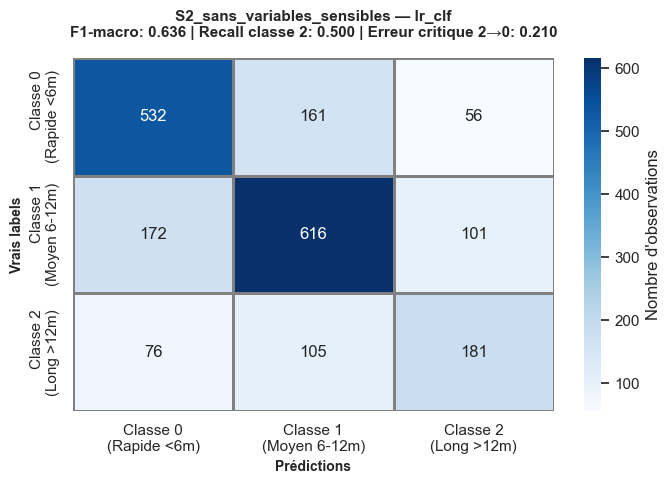


S2_sans_variables_sensibles — lr_clf: OK ✓



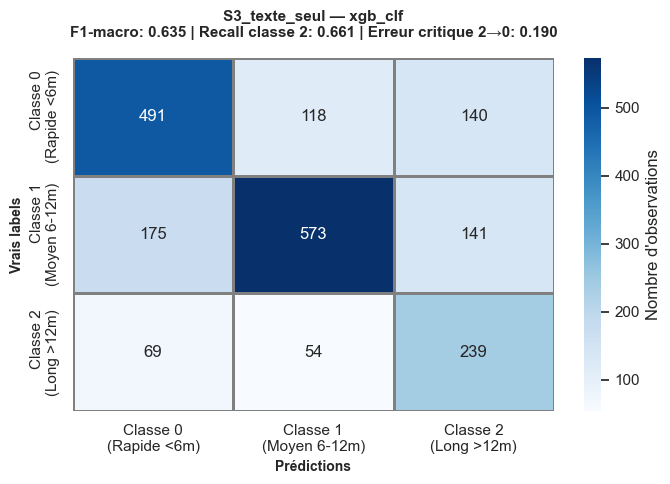


S3_texte_seul — xgb_clf: OK ✓



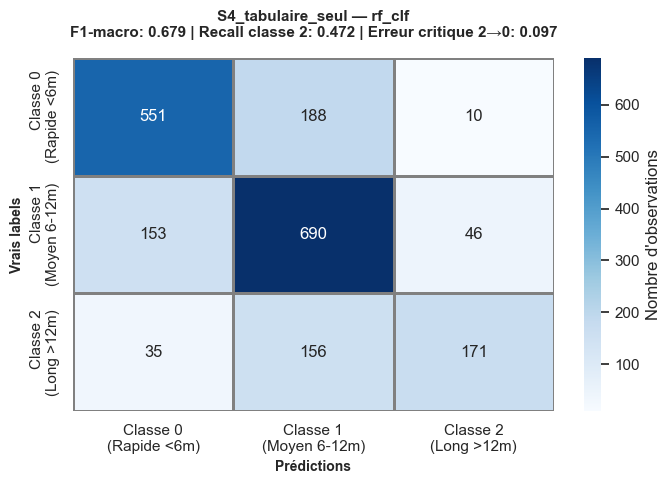


S4_tabulaire_seul — rf_clf: OK ✓



In [10]:
print("Matrices de confusion (Validation Croisée) - Meilleur modèle par scénario\n" + "="*80 + "\n")

for scenario_name in scenarios.keys():
    subset = resultats_cv[resultats_cv["scénario"] == scenario_name].iloc[0]
    best_model = subset["modèle"]
    best_model_obj = candidats[best_model]
    preprocessor_scenario = build_preprocessor(scenarios[scenario_name])
    
    # Recalcul de la matrice de confusion moyennée sur les folds => cross_validate ne stocke pas les prédictions par fold, donc il faut les recalculer
    cm_fold = None
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]
        pipe_cm = Pipeline([("preparation", preprocessor_scenario), ("modele", best_model_obj)])
        # On fit le pipeline sur le fold d'entraînement et on prédit sur le fold de validation
        pipe_cm.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred_fold = pipe_cm.predict(X_val_fold)
        if cm_fold is None:
            cm_fold = confusion_matrix(y_val_fold, y_pred_fold, labels=[0, 1, 2])
        else:
            cm_fold += confusion_matrix(y_val_fold, y_pred_fold, labels=[0, 1, 2])
    
    # Affichage de la matrice
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm_fold,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
        yticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
        cbar_kws={"label": "Nombre d'observations"},
        ax=ax,
        linewidths=1,
        linecolor="gray"
    )
    ax.set_title(
        f"{scenario_name} — {best_model}\nF1-macro: {subset['f1_macro (CV)']:.3f} | "
        f"Recall classe 2: {subset['recall_classe_2 (CV)']:.3f} | "
        f"Erreur critique 2→0: {subset['erreur_critique_2_vers_0 (CV)']:.3f}",
        fontsize=11,
        weight="bold",
        pad=15
    )
    ax.set_ylabel("Vrais labels", fontsize=10, weight="bold")
    ax.set_xlabel("Prédictions", fontsize=10, weight="bold")
    plt.tight_layout()
    plt.show()
    print(f"\n{scenario_name} — {best_model}: OK ✓\n")


#### 5.4.2 tableau de scores CV

In [11]:
# On réorganise le tableau pour mettre les colonnes les plus importantes en premier
colonnes_ordre = [
    "scénario",
    "modèle",
    "f1_macro (CV)",
    "recall_classe_2 (CV)",
    "erreur_critique_2_vers_0 (CV)"
]
# On tri par f1_macro décroissant pour tous les scénarios
resultats_cv = resultats_cv.sort_values(by="f1_macro (CV)", ascending=False).reset_index(drop=True)
# On réorganise les colonnes pour mettre les plus importantes en premier
resultats_cv = resultats_cv[colonnes_ordre + [col for col in resultats_cv.columns if col not in colonnes_ordre]]
# On affiche le tableau final
print("Résultats de la validation croisée (triés par F1-macro décroissant) :\n" + "="*80 + "\n")
display(resultats_cv)

Résultats de la validation croisée (triés par F1-macro décroissant) :



,scénario,modèle,f1_macro (CV),recall_classe_2 (CV),erreur_critique_2_vers_0 (CV),écart-type,temps fit (s),precision_classe_2 (CV),f1_classe_2 (CV),log_loss (CV),temps score (s)
0,S1_multimodale_complete,xgb_clf,0.688,0.542,0.113,0.018,0.54,0.652,0.590,0.709,0.06
1,S4_tabulaire_seul,rf_clf,0.679,0.472,0.097,0.024,0.38,0.755,0.579,0.829,0.03
2,S1_multimodale_complete,lgbm_clf,0.669,0.472,0.179,0.022,0.99,0.701,0.560,0.746,0.06
3,S1_multimodale_complete,lr_clf,0.662,0.531,0.171,0.014,0.14,0.591,0.559,0.739,0.02
4,S1_multimodale_complete,rf_clf,0.661,0.517,0.188,0.017,0.38,0.597,0.553,0.790,0.04
5,S4_tabulaire_seul,lgbm_clf,0.640,0.450,0.099,0.030,1.02,0.790,0.571,0.837,0.04
6,S4_tabulaire_seul,xgb_clf,0.637,0.461,0.080,0.028,0.27,0.645,0.537,0.831,0.03
7,S2_sans_variables_sensibles,lr_clf,0.636,0.500,0.210,0.010,0.07,0.537,0.517,0.775,0.02
8,S3_texte_seul,rf_clf,0.635,0.661,0.190,0.017,0.20,0.460,0.542,0.848,0.03
9,S3_texte_seul,xgb_clf,0.635,0.661,0.190,0.017,0.12,0.460,0.542,0.848,0.03


### 5.5 Optimisation des hyperparamètres

On refait pour chaque scénario l'analyse cross validation en prenant en compte que pour chaque modèle, on va modifier quelques hyperparamètres (par exemple : n_estimators=[50, 200], max_depth=[None, 10]) pour voir leur influence et voir si on ne peut pas améliorer le resultat.

#### 5.5.1 Pour le modèle XGBClassifier

In [12]:
# Pour le modèle XGBClassifier qui a le meilleur F1-macro, on peut faire un tuning des hyperparamètres pour améliorer les performances.
lignes = []
for scenario_name in scenarios.keys():
    scenario_cols = scenarios[scenario_name]
    preprocessor = build_preprocessor(scenario_cols)

    # On va modifier les hyperparamètres du XGBClassifier
    for w in (50, 300):                         # plus d’arbres pour mieux apprendre des signaux complexes
        for x in (None, 0.05):                  # apprentissage plus progressif, réduit le surapprentissage
            for y in (None, 4):                 # limite la complexité des arbres (dataset modeste: 2500 lignes)
                for z in (0.5, 0.7):            # utile avec one-hot + TF-IDF: chaque arbre voit moins de variables
                    model = XGBClassifier(
                        objective="binary:logistic", n_estimators=w, learning_rate=x, max_depth=y, colsample_bytree=z, random_state=RANDOM_STATE
                    )
                    pipe = Pipeline([("prep", preprocessor), ("xgbc", model)])
                    scores = cross_validate(
                        pipe,
                        X_train,
                        y_train,
                        cv=cv,
                        scoring={
                            "f1_macro": "f1_macro",
                            "recall_c2": make_scorer(recall_class_2),
                            "precision_c2": make_scorer(precision_class_2),
                            "f1_c2": make_scorer(f1_class_2),
                            "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
                            "neg_log_loss": "neg_log_loss",
                        },
                        error_score="raise",
                        n_jobs=1
                    )
                    lignes.append({
                        "scenario": scenario_name,
                        "n_estimators": w,
                        "learning_rate": x,
                        "max_depth": y,
                        "colsample_bytree": z,
                        "f1_macro": round(scores['test_f1_macro'].mean(), 3),
                        "recall_c2": round(scores['test_recall_c2'].mean(), 3),
                        "critical_2_to_0": round(-scores['test_critical_2_to_0'].mean(), 3)
                    })

resultats_cv_xgbc = pd.DataFrame(lignes).sort_values(["f1_macro", "critical_2_to_0"], ascending=[False, False])

print("10 meilleurs réglages :")
display(resultats_cv_xgbc.head(10))

print("5 moins bons réglages :")
display(resultats_cv_xgbc.tail(5))

10 meilleurs réglages :


,scenario,n_estimators,learning_rate,max_depth,colsample_bytree,f1_macro,recall_c2,critical_2_to_0
2,S1_multimodale_complete,50,NaN,4.0,0.5,0.706,0.575,0.132
15,S1_multimodale_complete,300,0.05,4.0,0.7,0.706,0.572,0.124
12,S1_multimodale_complete,300,0.05,NaN,0.5,0.705,0.555,0.130
0,S1_multimodale_complete,50,NaN,NaN,0.5,0.704,0.569,0.127
1,S1_multimodale_complete,50,NaN,NaN,0.7,0.704,0.564,0.124
14,S1_multimodale_complete,300,0.05,4.0,0.5,0.703,0.569,0.130
13,S1_multimodale_complete,300,0.05,NaN,0.7,0.698,0.550,0.130
11,S1_multimodale_complete,300,NaN,4.0,0.7,0.695,0.558,0.135
3,S1_multimodale_complete,50,NaN,4.0,0.7,0.695,0.558,0.133
10,S1_multimodale_complete,300,NaN,4.0,0.5,0.693,0.553,0.124


5 moins bons réglages :


,scenario,n_estimators,learning_rate,max_depth,colsample_bytree,f1_macro,recall_c2,critical_2_to_0
57,S4_tabulaire_seul,300,NaN,NaN,0.7,0.617,0.464,0.091
26,S2_sans_variables_sensibles,300,NaN,4.0,0.5,0.602,0.453,0.188
27,S2_sans_variables_sensibles,300,NaN,4.0,0.7,0.599,0.459,0.185
25,S2_sans_variables_sensibles,300,NaN,NaN,0.7,0.590,0.448,0.182
24,S2_sans_variables_sensibles,300,NaN,NaN,0.5,0.585,0.439,0.177


Ces validations croisées on pris 3 minutes 22 secondes à s'exécuter.

On remarque que les meilleurs résultats sont sur le scénario 1.

On regarde la learning curve du meilleur réglage.

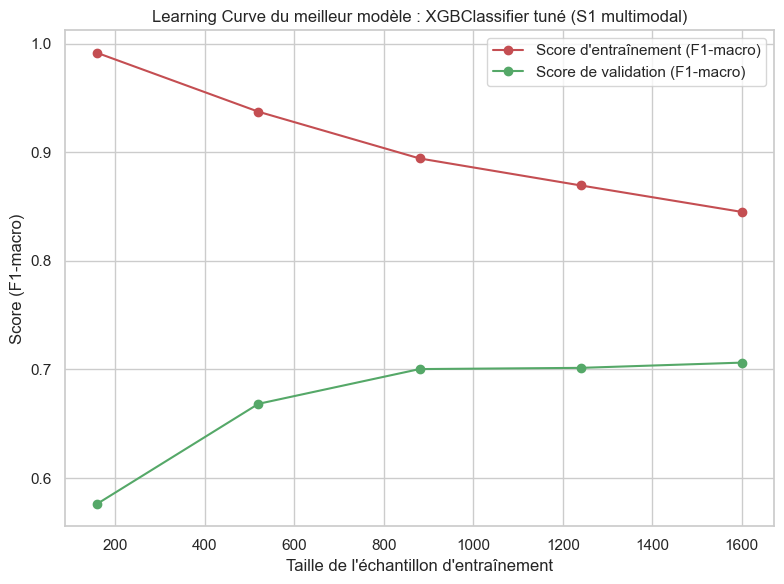

In [9]:
# Learning curve du meilleur réglage
# Colonnes du scénario gagnant
best_scenario_cols = scenarios["S1_multimodale_complete"]
best_preprocessor = build_preprocessor(best_scenario_cols)

# Meilleur modèle selon les résultats CV
best_lgbm = XGBClassifier(
    objective="binary:logistic",
    n_estimators=50,
    learning_rate=None,
    max_depth=4,
    colsample_bytree=0.5,
    random_state=RANDOM_STATE
)

best_pipe = Pipeline([
    ("preparation", best_preprocessor),
    ("modele", best_lgbm),
])

# On force une métrique cohérente avec l'analyse (F1-macro)
train_sizes, train_scores, test_scores = learning_curve(
    best_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Moyennes sur les 5 folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Affichage de la learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Score d'entraînement (F1-macro)")
plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Score de validation (F1-macro)")
plt.title("Learning Curve du meilleur modèle : XGBClassifier tuné (S1 multimodal)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score (F1-macro)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

On note à la fin de la courbe que l'écart entre le score d'entrainement et celui de la validation reste grand, on est donc en présence de variance. Il faut donc régulariser et simplifier le modèle, et mieux calibrer les poids de classes.

On va donc chercher d'autres paramètres à modifier notamment la `class_weight`, mais pour ce modèle ça ne se gère pas via l'API sklearn, on doit donc passer `sample_weight` au fit. On va aussi utiliser `objective="multi:softprob"` qui permet un apprentissage multiclasse.

,scénario,modèle,f1_macro (CV),écart-type,temps fit (s),recall_classe_2 (CV),precision_classe_2 (CV),f1_classe_2 (CV),erreur_critique_2_vers_0 (CV),log_loss (CV),temps score (s)
0,S1_multimodale_complete,XGBClassifier tuné,0.702,0.024,1.08,0.724,0.575,0.64,0.114,0.696,0.05


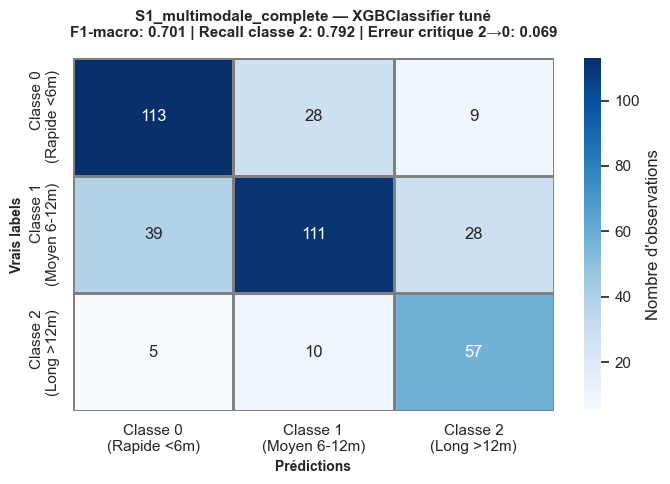

In [12]:
# 1) Split interne train/val (sans toucher au test final)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# 2) Poids de classes + focus classe 2
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
cw_local = {int(c): float(w) for c, w in zip(classes, weights)}
cw_local[2] = cw_local[2] * 1.5

# sample_weight indexé sur y_tr : sklearn le découpe automatiquement par fold
sample_weight_train = y_tr.map(cw_local).values

# Hyperparamètres réglés pour limiter le surapprentissage et mieux capter la classe 2.
xgb_modele = XGBClassifier(
    objective="multi:softprob", # Apprentissage multiclasse natif (classes 0, 1, 2). Contrairement à binary:logistic, qui correspond à un problème binaire.
    num_class=3,                # Nombre de classes cibles dans le problème.
    n_estimators=500,           # Beaucoup d'arbres pour apprendre progressivement sans brusquer le modèle.
    learning_rate=0.03,         # Petit pas d'apprentissage pour améliorer la généralisation, cela réduit la vitesse d’apprentissage et aide à éviter un modèle qui “mémorise” trop vite.
    max_depth=5,                # Garde-fou sur la profondeur pour limiter la variance. Plus restrictif que 4, mais pas radicalement. Cela limite la complexité des arbres.
    colsample_bytree=0.7,       # Sous-échantillonnage des colonnes (utile avec one-hot + tf-idf). Ajoute de la régularisation et réduit le risque de surapprentissage.
    random_state=RANDOM_STATE,  # Rend les résultats reproductibles entre exécutions.
    n_jobs=-1,                  # Utilise tous les coeurs CPU disponibles pour accélérer le fit.
)

pipe_xgb = Pipeline([
    ("preparation", build_preprocessor(best_scenario_cols)),
    ("modele", xgb_modele),
])

# fit_params transmet sample_weight au fit de chaque fold via la notation pipeline "etape__param"
scores = cross_validate(
    pipe_xgb,
    X_tr,
    y_tr,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "recall_c2": make_scorer(recall_class_2),
        "precision_c2": make_scorer(precision_class_2),
        "f1_c2": make_scorer(f1_class_2),
        "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
        "neg_log_loss": "neg_log_loss",
    },
    error_score="raise",
    params={"modele__sample_weight": sample_weight_train},
    n_jobs=1
)

# Affichage des résultats de la validation croisée
resultats = pd.DataFrame([{
    "scénario": "S1_multimodale_complete",
    "modèle": "XGBClassifier tuné",
    "f1_macro (CV)": round(scores["test_f1_macro"].mean(), 3),
    "écart-type": round(scores["test_f1_macro"].std(), 3),
    "temps fit (s)": round(scores["fit_time"].mean(), 2),
    "recall_classe_2 (CV)": round(scores["test_recall_c2"].mean(), 3),
    "precision_classe_2 (CV)": round(scores["test_precision_c2"].mean(), 3),
    "f1_classe_2 (CV)": round(scores["test_f1_c2"].mean(), 3),
    "erreur_critique_2_vers_0 (CV)": round(-scores["test_critical_2_to_0"].mean(), 3),
    "log_loss (CV)": round(-scores["test_neg_log_loss"].mean(), 3),
    "temps score (s)": round(scores["score_time"].mean(), 2),
}])
display(resultats)

# Matrice de confusion finale sur l'entrainement complet (après validation croisée)
pipe_xgb.fit(X_tr, y_tr, modele__sample_weight=sample_weight_train)
y_pred = pipe_xgb.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_pred)

# Affichage de la matrice
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    yticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    cbar_kws={"label": "Nombre d'observations"},
    ax=ax,
    linewidths=1,
    linecolor="gray"
)
ax.set_title(
    f"{'S1_multimodale_complete'} — {'XGBClassifier tuné'}\nF1-macro: {f1_score(y_val, y_pred, average='macro'):.3f} | "
    f"Recall classe 2: {recall_class_2(y_val, y_pred):.3f} | "
    f"Erreur critique 2→0: {critical_error_2_to_0(y_val, y_pred):.3f}",
    fontsize=11,
    weight="bold",
    pad=15
)
ax.set_ylabel("Vrais labels", fontsize=10, weight="bold")
ax.set_xlabel("Prédictions", fontsize=10, weight="bold")
plt.tight_layout()
plt.show()

D'après la validation croisée on remarque un F1_macro semblable (0.702 vs 0.688), on dirait qu'il plafonne. Cependant on note une amélioration sur le recall de la classe 2 (0.724 vs 0.542) mais une détection de l'erreur critique qui reste semblable (0.114 vs 0.113).

On reste toujours en dessous des seuils fixés dans l'objectif. Peut être que le modèle est trop complexe pour si peu de données.

#### 5.5.2 Pour le modèle RandomForestClassifier

In [10]:
# Pour le modèle RandomForestClassifier, on peut faire un tuning des hyperparamètres pour améliorer les performances.
lignes = []
for scenario_name in scenarios.keys():
    scenario_cols = scenarios[scenario_name]
    preprocessor = build_preprocessor(scenario_cols)

    # On va modifier les hyperparamètres du RandomForestClassifier
    for x in ("balanced", "balanced_subsample"):        # Rééquilibre les classes à chaque arbre (aide la classe minoritaire)
        for n in (50, 500):                             # Plus d’arbres = prédictions plus stables et variance réduite
            for o in (5, 18):                           # Limite la profondeur pour éviter le surapprentissage sur petit dataset
                for p in (2, 4):                        # Empêche les feuilles trop petites (règles trop spécifiques/bruitées)
                    for q in ('sqrt', 0.35, 'log2'):    # Chaque split teste 35% des variables, utile en haute dimension
                        model = RandomForestClassifier(
                            n_estimators=n, max_depth=o, min_samples_leaf=p, max_features=q, class_weight=x, n_jobs=-1, random_state=RANDOM_STATE
                        )
                        pipe = Pipeline([("prep", preprocessor), ("rfc", model)])
                        scores = cross_validate(
                            pipe,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring={
                                "f1_macro": "f1_macro",
                                "recall_c2": make_scorer(recall_class_2),
                                "precision_c2": make_scorer(precision_class_2),
                                "f1_c2": make_scorer(f1_class_2),
                                "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
                                "neg_log_loss": "neg_log_loss",
                            },
                            error_score="raise",
                            n_jobs=1
                        )
                        lignes.append({
                            "scenario": scenario_name,
                            "n_estimators": n,
                            "max_depth": o,
                            "min_samples_leaf": p,
                            "max_features": q,
                            "class_weight": x,
                            "f1_macro": round(scores['test_f1_macro'].mean(), 3),
                            "recall_c2": round(scores['test_recall_c2'].mean(), 3),
                            "critical_2_to_0": round(-scores['test_critical_2_to_0'].mean(), 3)
                        })

resultats_cv_rfc = pd.DataFrame(lignes).sort_values(["f1_macro", "critical_2_to_0"], ascending=[False, False])

print("10 meilleurs réglages :")
display(resultats_cv_rfc.head(10))

print("5 moins bons réglages :")
display(resultats_cv_rfc.tail(5))

10 meilleurs réglages :


,scenario,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,f1_macro,recall_c2,critical_2_to_0
43,S1_multimodale_complete,500,18,2,0.35,balanced_subsample,0.688,0.644,0.146
19,S1_multimodale_complete,500,18,2,0.35,balanced,0.688,0.647,0.141
22,S1_multimodale_complete,500,18,4,0.35,balanced,0.686,0.696,0.135
31,S1_multimodale_complete,50,18,2,0.35,balanced_subsample,0.685,0.633,0.152
46,S1_multimodale_complete,500,18,4,0.35,balanced_subsample,0.684,0.688,0.144
7,S1_multimodale_complete,50,18,2,0.35,balanced,0.683,0.644,0.141
10,S1_multimodale_complete,50,18,4,0.35,balanced,0.683,0.674,0.138
28,S1_multimodale_complete,50,5,4,0.35,balanced_subsample,0.682,0.688,0.144
34,S1_multimodale_complete,50,18,4,0.35,balanced_subsample,0.682,0.674,0.138
1,S1_multimodale_complete,50,5,2,0.35,balanced,0.681,0.691,0.144


5 moins bons réglages :


,scenario,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,f1_macro,recall_c2,critical_2_to_0
170,S4_tabulaire_seul,50,5,2,log2,balanced_subsample,0.514,0.693,0.185
146,S4_tabulaire_seul,50,5,2,log2,balanced,0.510,0.677,0.207
185,S4_tabulaire_seul,500,5,4,log2,balanced_subsample,0.510,0.688,0.191
149,S4_tabulaire_seul,50,5,4,log2,balanced,0.506,0.674,0.196
173,S4_tabulaire_seul,50,5,4,log2,balanced_subsample,0.504,0.680,0.204


Ces validations croisées on pris 11 minutes 7 secondes à s'exécuter.

Encore une fois le scénario 1 sort gagnant.

On regarde la learning curve du meilleur réglage.

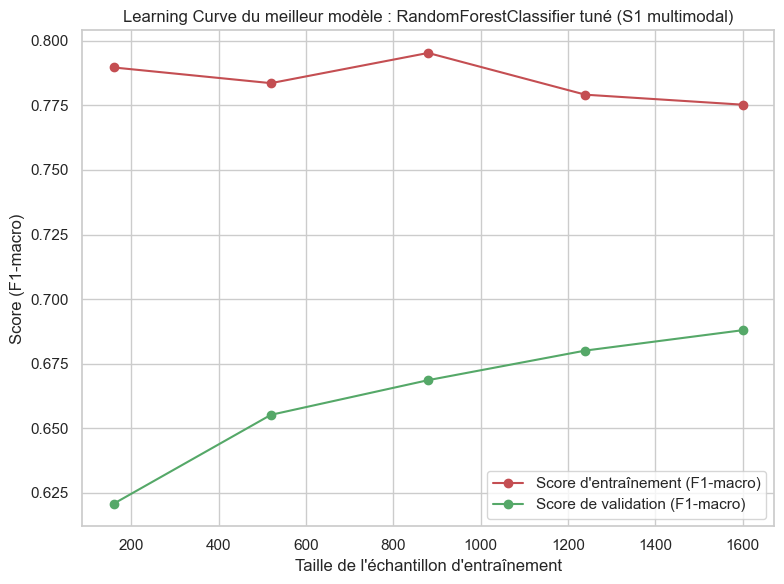

In [11]:
# Learning curve du meilleur réglage
# Colonnes du scénario gagnant
best_scenario_cols = scenarios["S1_multimodale_complete"]
best_preprocessor = build_preprocessor(best_scenario_cols)

# Meilleur modèle selon les résultats CV
best_rfc = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features=0.35,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

best_pipe = Pipeline([
    ("preparation", best_preprocessor),
    ("modele", best_rfc),
])

# On force une métrique cohérente avec l'analyse (F1-macro)
train_sizes, train_scores, test_scores = learning_curve(
    best_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Moyennes sur les 5 folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Affichage de la learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Score d'entraînement (F1-macro)")
plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Score de validation (F1-macro)")
plt.title("Learning Curve du meilleur modèle : RandomForestClassifier tuné (S1 multimodal)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score (F1-macro)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Mêmes observations qu'au dessus.

,scénario,modèle,f1_macro (CV),écart-type,temps fit (s),recall_classe_2 (CV),precision_classe_2 (CV),f1_classe_2 (CV),erreur_critique_2_vers_0 (CV),log_loss (CV),temps score (s)
0,S1_multimodale_complete,RandomForestClassifier tuné,0.619,0.023,0.63,0.817,0.387,0.524,0.048,1.046,0.17


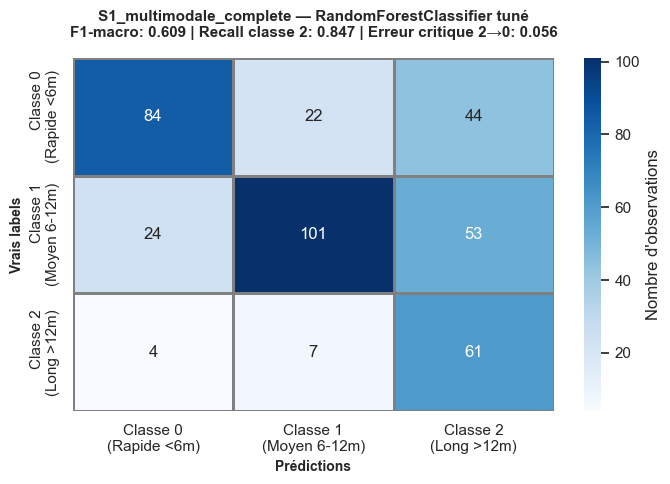

In [13]:
# 1) Split interne train/val (sans toucher au test final)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# 2) Poids de classes + focus classe 2
class_weights_rfc = {
    0: 1.0,   # Classe 0 : poids normal
    1: 1.0,   # Classe 1 : poids normal
    2: 3.0    # Classe 2 : poids 3x supérieur (à ajuster)
}

sample_weight_train = y_tr.map(class_weights_rfc).astype(float).values

# Hyperparamètres réglés pour limiter le surapprentissage et mieux capter la classe 2.
rfc_modele = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features="sqrt",        # réduit la corrélation entre arbres, et aide à limiter le surapprentissage.
    max_samples=0.8,            # Sous-échantillonnage des données (0.6-0.9). Aide à réduire la variance.
    bootstrap=True,             # Gardé à True (meilleure généralisation). Mode standard du RandomForest, favorise la généralisation par rapport à un arbre unique.
    random_state=RANDOM_STATE,
    n_jobs=-1,                  # Utilise tous les cœurs CPU
    class_weight=class_weights_rfc  # Poids personnalisés pour mieux capter la classe 2.
)

pipe_rfc = Pipeline([
    ("preparation", build_preprocessor(best_scenario_cols)),
    ("modele", rfc_modele),
])

# fit_params transmet sample_weight au fit de chaque fold via la notation pipeline "etape__param"
scores = cross_validate(
    pipe_rfc,
    X_tr,
    y_tr,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "recall_c2": make_scorer(recall_class_2),
        "precision_c2": make_scorer(precision_class_2),
        "f1_c2": make_scorer(f1_class_2),
        "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
        "neg_log_loss": "neg_log_loss",
    },
    error_score="raise",
    params={"modele__sample_weight": sample_weight_train},
    n_jobs=1
)

# Affichage des résultats de la validation croisée
resultats = pd.DataFrame([{
    "scénario": "S1_multimodale_complete",
    "modèle": "RandomForestClassifier tuné",
    "f1_macro (CV)": round(scores["test_f1_macro"].mean(), 3),
    "écart-type": round(scores["test_f1_macro"].std(), 3),
    "temps fit (s)": round(scores["fit_time"].mean(), 2),
    "recall_classe_2 (CV)": round(scores["test_recall_c2"].mean(), 3),
    "precision_classe_2 (CV)": round(scores["test_precision_c2"].mean(), 3),
    "f1_classe_2 (CV)": round(scores["test_f1_c2"].mean(), 3),
    "erreur_critique_2_vers_0 (CV)": round(-scores["test_critical_2_to_0"].mean(), 3),
    "log_loss (CV)": round(-scores["test_neg_log_loss"].mean(), 3),
    "temps score (s)": round(scores["score_time"].mean(), 2),
}])
display(resultats)

# Matrice de confusion finale sur l'entrainement complet (après validation croisée)
pipe_rfc.fit(X_tr, y_tr, modele__sample_weight=sample_weight_train)
y_pred = pipe_rfc.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_pred)

# Affichage de la matrice
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    yticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    cbar_kws={"label": "Nombre d'observations"},
    ax=ax,
    linewidths=1,
    linecolor="gray"
)
ax.set_title(
    f"{'S1_multimodale_complete'} — {'RandomForestClassifier tuné'}\nF1-macro: {f1_score(y_val, y_pred, average='macro'):.3f} | "
    f"Recall classe 2: {recall_class_2(y_val, y_pred):.3f} | "
    f"Erreur critique 2→0: {critical_error_2_to_0(y_val, y_pred):.3f}",
    fontsize=11,
    weight="bold",
    pad=15
)
ax.set_ylabel("Vrais labels", fontsize=10, weight="bold")
ax.set_xlabel("Prédictions", fontsize=10, weight="bold")
plt.tight_layout()
plt.show()

On finit avec une F1_macro moyenne voir basse (0.619 vs 0.679) mais un très bon recall de la classe 2 (0.817 vs 0.472) et aussi une erreur critique en nette amélioration (0.048 vs 0.097).

Il est donc un bon concurent pour le rappel classe 2 mais pas assez bon en général et laisse passer trop de faux positifs.

#### 5.5.3 Pour le modèle LGBMClassifier

In [14]:
# Pour le modèle LGBMClassifier, on peut faire un tuning des hyperparamètres pour améliorer les performances.
lignes = []
for scenario_name in scenarios.keys():
    scenario_cols = scenarios[scenario_name]
    preprocessor = build_preprocessor(scenario_cols)

    # On va modifier les hyperparamètres du LGBMClassifier
    for n in (50, 400):                             # + d’arbres = + de capacité d’apprentissage (utile avec LR plus faible)
        for o in (0.02, 0.05):                      # apprentissage plus progressif, réduit le surapprentissage
            for p in (27, 24):                      # complexité des arbres: plus bas que 31 (défaut) pour mieux généraliser sur petit dataset
                for q in (10, 40):                  # impose plus d’exemples par feuille, évite des règles trop spécifiques/bruitées
                    for x in (0.5, 0.7):            # utile avec one-hot + TF-IDF: chaque arbre voit moins de variables
                        model = LGBMClassifier(
                            n_estimators=n, learning_rate=o, num_leaves=p, min_child_samples=q, colsample_bytree=x, random_state=RANDOM_STATE
                        )
                        pipe = Pipeline([("prep", preprocessor), ("lgbm", model)])
                        scores = cross_validate(
                            pipe,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring={
                                "f1_macro": "f1_macro",
                                "recall_c2": make_scorer(recall_class_2),
                                "precision_c2": make_scorer(precision_class_2),
                                "f1_c2": make_scorer(f1_class_2),
                                "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
                                "neg_log_loss": "neg_log_loss",
                            },
                            error_score="raise",
                            n_jobs=1
                        )
                        lignes.append({
                            "scenario": scenario_name,
                            "n_estimators": n,
                            "learning_rate": o,
                            "num_leaves": p,
                            "min_child_samples": q,
                            "colsample_bytree": x,
                            "f1_macro": round(scores['test_f1_macro'].mean(), 3),
                            "recall_c2": round(scores['test_recall_c2'].mean(), 3),
                            "critical_2_to_0": round(-scores['test_critical_2_to_0'].mean(), 3)
                        })

resultats_cv_lgbm = pd.DataFrame(lignes).sort_values(["f1_macro", "critical_2_to_0"], ascending=[False, False])

print("10 meilleurs réglages :")
display(resultats_cv_lgbm.head(10))

print("5 moins bons réglages :")
display(resultats_cv_lgbm.tail(5))

10 meilleurs réglages :


,scenario,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,f1_macro,recall_c2,critical_2_to_0
21,S1_multimodale_complete,400,0.02,24,10,0.7,0.715,0.600,0.108
17,S1_multimodale_complete,400,0.02,27,10,0.7,0.710,0.586,0.113
20,S1_multimodale_complete,400,0.02,24,10,0.5,0.710,0.583,0.108
13,S1_multimodale_complete,50,0.05,24,10,0.7,0.704,0.569,0.138
16,S1_multimodale_complete,400,0.02,27,10,0.5,0.704,0.580,0.113
8,S1_multimodale_complete,50,0.05,27,10,0.5,0.699,0.564,0.146
12,S1_multimodale_complete,50,0.05,24,10,0.5,0.698,0.564,0.144
9,S1_multimodale_complete,50,0.05,27,10,0.7,0.697,0.555,0.133
28,S1_multimodale_complete,400,0.05,24,10,0.5,0.696,0.575,0.108
25,S1_multimodale_complete,400,0.05,27,10,0.7,0.695,0.575,0.116


5 moins bons réglages :


,scenario,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,f1_macro,recall_c2,critical_2_to_0
100,S4_tabulaire_seul,50,0.02,24,10,0.5,0.572,0.166,0.066
103,S4_tabulaire_seul,50,0.02,24,40,0.7,0.555,0.268,0.119
99,S4_tabulaire_seul,50,0.02,27,40,0.7,0.552,0.263,0.119
102,S4_tabulaire_seul,50,0.02,24,40,0.5,0.480,0.119,0.102
98,S4_tabulaire_seul,50,0.02,27,40,0.5,0.474,0.113,0.102


Ces validations croisées on pris 11 minutes 34 secondes à s'exécuter.

Toujours le scénario 1 en premier.

On regarde la learning curve du meilleur réglage.

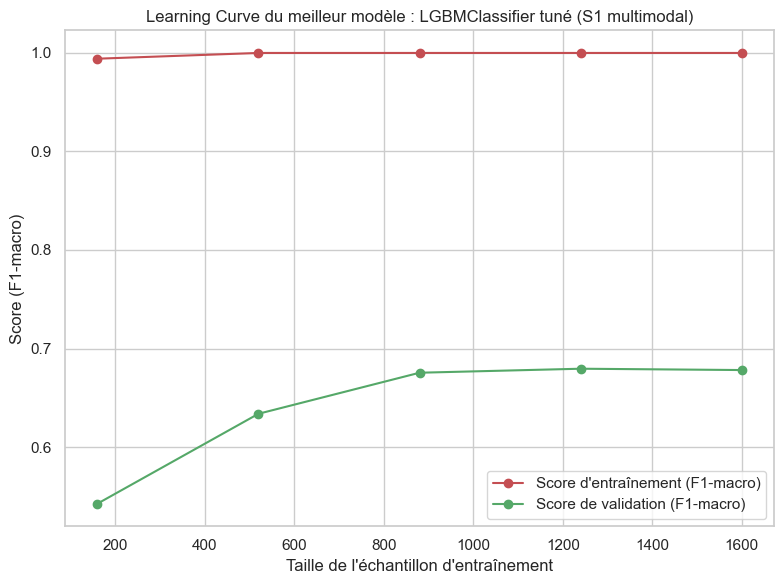

In [14]:
# Learning curve du meilleur réglage
# Colonnes du scénario gagnant
best_scenario_cols = scenarios["S1_multimodale_complete"]
best_preprocessor = build_preprocessor(best_scenario_cols)

# Meilleur modèle selon les résultats CV
best_lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.2,
    num_leaves=24,
    min_child_samples=10,
    colsample_bytree=0.7,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

best_pipe = Pipeline([
    ("preparation", best_preprocessor),
    ("modele", best_lgbm),
])

# On force une métrique cohérente avec l'analyse (F1-macro)
train_sizes, train_scores, test_scores = learning_curve(
    best_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Moyennes sur les 5 folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Affichage de la learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Score d'entraînement (F1-macro)")
plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Score de validation (F1-macro)")
plt.title("Learning Curve du meilleur modèle : LGBMClassifier tuné (S1 multimodal)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score (F1-macro)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Mêmes observations qu'au dessus.

De plus on remarque un entrainement qui reste à 1. Cela vient du fait que le score train de `learning_curve` est calculé sur les données qui ont servi à fit, donc le modèle est trop complexe pour la taille de données.

Il faut donc régulariser et simplifier.

,scénario,modèle,f1_macro (CV),écart-type,temps fit (s),recall_classe_2 (CV),precision_classe_2 (CV),f1_classe_2 (CV),erreur_critique_2_vers_0 (CV),temps score (s)
0,S1_multimodale_complete,LGBMClassifier tuné,0.654,0.024,2.45,0.724,0.461,0.562,0.121,0.11


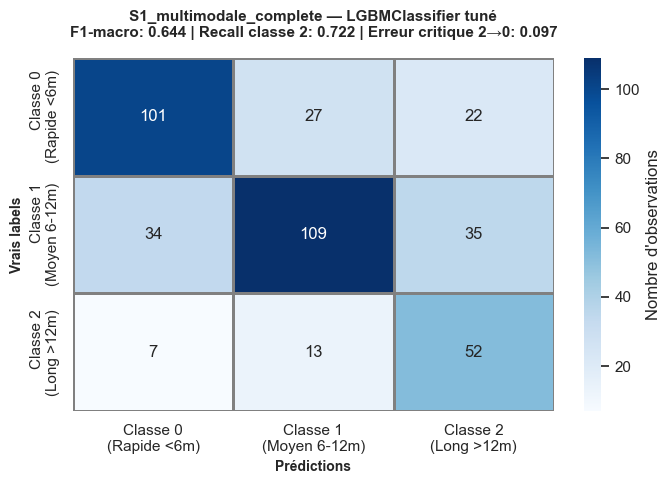

In [15]:
# --- Réduction ciblée de l'erreur critique 2->0 par tuning de seuils ---
# 1) Split interne train/val (sans toucher au test final)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# 2) Poids de classes + focus classe 2
class_weights_lgbm = {
    0: 1.0,   # Classe 0 : poids normal
    1: 1.0,   # Classe 1 : poids normal
    2: 3.0    # Classe 2 : poids 3x supérieur (à ajuster)
}

sample_weight_train = y_tr.map(class_weights_lgbm).astype(float).values

# Hyperparamètres réglés pour limiter le surapprentissage et mieux capter la classe 2.
modele_lgbm = LGBMClassifier(
    objective="multiclass",     # Apprentissage multiclasse natif (classes 0, 1, 2).
    num_class=3,                # Nombre de classes cibles dans le problème.
    n_estimators=700,           # Beaucoup d'arbres pour apprendre progressivement sans brusquer le modèle.
    learning_rate=0.025,        # Petit pas d'apprentissage pour améliorer la généralisation. Apprentissage plus lent.
    num_leaves=24,              # Complexité modérée de chaque arbre (évite des règles trop fines).
    max_depth=8,                # Garde-fou sur la profondeur pour limiter la variance.
    min_child_samples=35,       # Impose assez d'exemples par feuille pour éviter d'apprendre le bruit.
    subsample=0.8,              # Sous-échantillonnage des lignes à chaque arbre pour réduire le surapprentissage.
    colsample_bytree=0.6,       # Sous-échantillonnage des colonnes (utile avec one-hot + tf-idf). Ajoute de la robustesse.
    reg_alpha=0.2,              # Régularisation L1 pour favoriser un modèle plus parcimonieux.
    reg_lambda=1.5,             # Régularisation L2 pour stabiliser les poids et lisser les décisions.
    class_weight=class_weights_lgbm,      # Surpondère la classe 2 pour réduire les faux négatifs critiques 2->0.
    random_state=RANDOM_STATE,  # Rend les résultats reproductibles entre exécutions.
    n_jobs=-1,                  # Utilise tous les coeurs CPU disponibles pour accélérer le fit.
    verbosity=-1,               # Réduit les logs LightGBM pour garder une sortie notebook propre.
)

pipe_lgbm = Pipeline([
    ("preparation", build_preprocessor(best_scenario_cols)),
    ("modele", modele_lgbm),
])

# fit_params transmet sample_weight au fit de chaque fold via la notation pipeline "etape__param"
scores = cross_validate(
    pipe_lgbm,
    X_tr,
    y_tr,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "recall_c2": make_scorer(recall_class_2),
        "precision_c2": make_scorer(precision_class_2),
        "f1_c2": make_scorer(f1_class_2),
        "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
        "neg_log_loss": "neg_log_loss",
    },
    error_score="raise",
    params={"modele__sample_weight": sample_weight_train},
    n_jobs=1
)

# Affichage des résultats de la validation croisée
resultats = pd.DataFrame([{
    "scénario": "S1_multimodale_complete",
    "modèle": "LGBMClassifier tuné",
    "f1_macro (CV)": round(scores["test_f1_macro"].mean(), 3),
    "écart-type": round(scores["test_f1_macro"].std(), 3),
    "temps fit (s)": round(scores["fit_time"].mean(), 2),
    "recall_classe_2 (CV)": round(scores["test_recall_c2"].mean(), 3),
    "precision_classe_2 (CV)": round(scores["test_precision_c2"].mean(), 3),
    "f1_classe_2 (CV)": round(scores["test_f1_c2"].mean(), 3),
    "erreur_critique_2_vers_0 (CV)": round(-scores["test_critical_2_to_0"].mean(), 3),
    "temps score (s)": round(scores["score_time"].mean(), 2),
}])
display(resultats)

# Matrice de confusion finale sur l'entrainement complet (après validation croisée)
pipe_lgbm.fit(X_tr, y_tr, modele__sample_weight=sample_weight_train)
y_pred = pipe_lgbm.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_pred)

# Affichage de la matrice
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    yticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    cbar_kws={"label": "Nombre d'observations"},
    ax=ax,
    linewidths=1,
    linecolor="gray"
)
ax.set_title(
    f"{'S1_multimodale_complete'} — {'LGBMClassifier tuné'}\nF1-macro: {f1_score(y_val, y_pred, average='macro'):.3f} | "
    f"Recall classe 2: {recall_class_2(y_val, y_pred):.3f} | "
    f"Erreur critique 2→0: {critical_error_2_to_0(y_val, y_pred):.3f}",
    fontsize=11,
    weight="bold",
    pad=15
)
ax.set_ylabel("Vrais labels", fontsize=10, weight="bold")
ax.set_xlabel("Prédictions", fontsize=10, weight="bold")
plt.tight_layout()
plt.show()

On a fait baisser la F1_macro (0.654 vs 0.669) pour augmenter le recall classe 2 (0.724 vs 0.472). Mais le résultat final reste encore moyen et l'erreur critique baisse que très légérement (0.121 vs 0.179).

Néanmoins les modèles tunés sans poids de classe restent dans les meilleurs en performances.
Par exemple le modèle avec les paramètres : `n_estimators=400`, `learning_rate=0.02`, `num_leaves=24`, `min_child_samples=10`, `colsample_bytree=0.7` reste le meilleur avec les performances suivantes : F1-macro à 0.715, erreur critique à 0.108 et recall classe 2 à 0.60.

#### 5.5.4 Pour le modèle LogisticRegression

In [15]:
# Pour le modèle LogisticRegression, on peut faire un tuning des hyperparamètres pour améliorer les performances.
lignes = []
for scenario_name in scenarios.keys():
    scenario_cols = scenarios[scenario_name]
    preprocessor = build_preprocessor(scenario_cols)

    # On va modifier les hyperparamètres du LogisticRegression
    for n in ("lbfgs", "saga"):             # Optimiseur adapté aux données creuses (données où la majorité des valeurs sont à 0 à cause des One-hot et du TF-IDF) et haute dimension (TF-IDF + OHE)
        for o in (1, 0.5):                  # Régularisation plus forte (vs défaut 1.0) pour limiter le surapprentissage
            for p in (None, "balanced"):    # Rééquilibre automatiquement les classes minoritaires (important pour la classe 2)
                for q in (2000, 3000):      # Augmente le budget d’itérations pour éviter les warnings de non-convergence
                    model = LogisticRegression(
                        solver=n, C=o, class_weight=p, max_iter=q, random_state=RANDOM_STATE
                    )
                    pipe = Pipeline([("prep", preprocessor), ("logreg", model)])
                    scores = cross_validate(
                        pipe,
                        X_train,
                        y_train,
                        cv=cv,
                        scoring={
                            "f1_macro": "f1_macro",
                            "recall_c2": make_scorer(recall_class_2),
                            "precision_c2": make_scorer(precision_class_2),
                            "f1_c2": make_scorer(f1_class_2),
                            "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
                            "neg_log_loss": "neg_log_loss",
                        },
                        error_score="raise",
                        n_jobs=1
                    )
                    lignes.append({
                        "scenario": scenario_name,
                        "solver": n,
                        "C": o,
                        "class_weight": p,
                        "max_iter": q,
                        "f1_macro": round(scores['test_f1_macro'].mean(), 3),
                        "recall_c2": round(scores['test_recall_c2'].mean(), 3),
                        "critical_2_to_0": round(-scores['test_critical_2_to_0'].mean(), 3)
                    })

resultats_cv_logreg = pd.DataFrame(lignes).sort_values(["f1_macro", "critical_2_to_0"], ascending=[False, False])

print("10 meilleurs réglages :")
display(resultats_cv_logreg.head(10))

print("5 moins bons réglages :")
display(resultats_cv_logreg.tail(5))

10 meilleurs réglages :


,scenario,solver,C,class_weight,max_iter,f1_macro,recall_c2,critical_2_to_0
4,S1_multimodale_complete,lbfgs,0.5,None,2000,0.672,0.550,0.163
5,S1_multimodale_complete,lbfgs,0.5,None,3000,0.672,0.550,0.163
12,S1_multimodale_complete,saga,0.5,None,2000,0.672,0.550,0.163
13,S1_multimodale_complete,saga,0.5,None,3000,0.672,0.550,0.163
14,S1_multimodale_complete,saga,0.5,balanced,2000,0.668,0.677,0.152
15,S1_multimodale_complete,saga,0.5,balanced,3000,0.668,0.677,0.152
6,S1_multimodale_complete,lbfgs,0.5,balanced,2000,0.667,0.674,0.152
7,S1_multimodale_complete,lbfgs,0.5,balanced,3000,0.667,0.674,0.152
8,S1_multimodale_complete,saga,1.0,None,2000,0.663,0.533,0.169
9,S1_multimodale_complete,saga,1.0,None,3000,0.663,0.533,0.169


5 moins bons réglages :


,scenario,solver,C,class_weight,max_iter,f1_macro,recall_c2,critical_2_to_0
63,S4_tabulaire_seul,saga,0.5,balanced,3000,0.528,0.591,0.149
58,S4_tabulaire_seul,saga,1.0,balanced,2000,0.521,0.569,0.157
59,S4_tabulaire_seul,saga,1.0,balanced,3000,0.521,0.569,0.157
50,S4_tabulaire_seul,lbfgs,1.0,balanced,2000,0.518,0.561,0.157
51,S4_tabulaire_seul,lbfgs,1.0,balanced,3000,0.518,0.561,0.157


Ces validations croisées on pris 1 minutes 26 secondes à s'exécuter.

On regarde la learning curve du meilleur réglage.

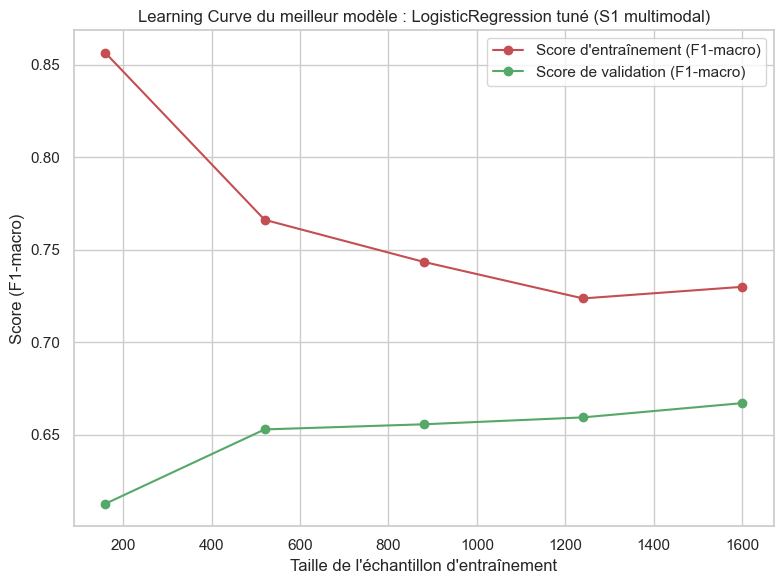

In [16]:
# Learning curve du meilleur réglage
# Colonnes du scénario gagnant
best_scenario_cols = scenarios["S1_multimodale_complete"]
best_preprocessor = build_preprocessor(best_scenario_cols)

# Meilleur modèle selon les résultats CV
best_logreg = LogisticRegression(
    solver="lbfgs",
    C=0.5,
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

best_pipe = Pipeline([
    ("preparation", best_preprocessor),
    ("modele", best_logreg),
])

# On force une métrique cohérente avec l'analyse (F1-macro)
train_sizes, train_scores, test_scores = learning_curve(
    best_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Moyennes sur les 5 folds
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

# Affichage de la learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Score d'entraînement (F1-macro)")
plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Score de validation (F1-macro)")
plt.title("Learning Curve du meilleur modèle : LogisticRegression tuné (S1 multimodal)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score (F1-macro)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

L'écart entre les 2 courbes à la fin est moins grand que pour les précédents modèles et elles convergent légèrement vers un résultat moyen/bas. On est ici donc dans un problème entre variance et biais.

Le modèle est peut être trop simple pour le problème. Ici avoir plus de données pourrait aider le modèle.

Augmenter le nombre de données n'est pas possible dans le cas de l'exercice, on va donc principalement influer sur les poids des classes.

,scénario,modèle,f1_macro (CV),écart-type,temps fit (s),recall_classe_2 (CV),precision_classe_2 (CV),f1_classe_2 (CV),erreur_critique_2_vers_0 (CV),temps score (s)
0,S1_multimodale_complete,LogisticRegression tuné,0.53,0.019,0.21,0.79,0.339,0.475,0.028,0.02


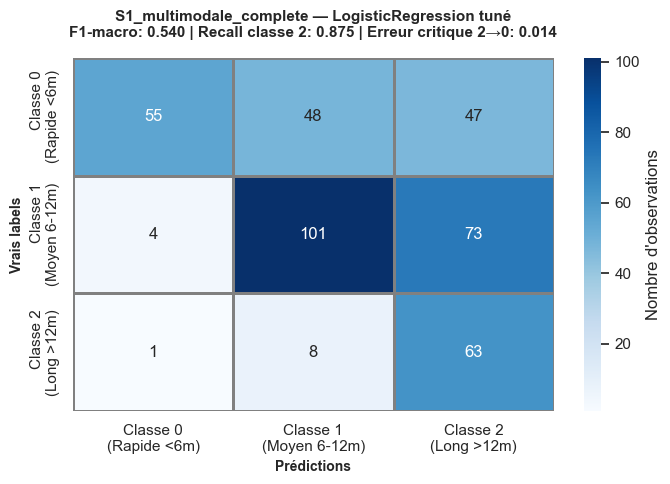

In [17]:
# --- Réduction ciblée de l'erreur critique 2->0 par tuning de seuils ---
# 1) Split interne train/val (sans toucher au test final)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

# 2) Poids de classes + focus classe 2
class_weights_lr = {
    0: 1.0,   # Classe 0 : poids normal
    1: 2.0,   # Classe 1 : poids normal
    2: 5.0    # Classe 2 : poids 5x supérieur (à ajuster)
}

sample_weight_train = y_tr.map(class_weights_lr).astype(float).values

# Hyperparamètres réglés pour limiter le surapprentissage et mieux capter la classe 2.
modele_logreg = LogisticRegression(
    solver="lbfgs", # Rapide pour petits jeux de données.
    C=0.1,          # Régularisation plus forte pour éviter le surajustement
    class_weight=class_weights_lr,
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1       # Utilise tous les cœurs pour accélérer l'entraînement
)

pipe_logreg = Pipeline([
    ("preparation", build_preprocessor(best_scenario_cols)),
    ("modele", modele_logreg),
])

# fit_params transmet sample_weight au fit de chaque fold via la notation pipeline "etape__param"
scores = cross_validate(
    pipe_logreg,
    X_tr,
    y_tr,
    cv=cv,
    scoring={
        "f1_macro": "f1_macro",
        "recall_c2": make_scorer(recall_class_2),
        "precision_c2": make_scorer(precision_class_2),
        "f1_c2": make_scorer(f1_class_2),
        "critical_2_to_0": make_scorer(critical_error_2_to_0, greater_is_better=False),
        "neg_log_loss": "neg_log_loss",
    },
    error_score="raise",
    params={"modele__sample_weight": sample_weight_train},
    n_jobs=1
)

# Affichage des résultats de la validation croisée
resultats = pd.DataFrame([{
    "scénario": "S1_multimodale_complete",
    "modèle": "LogisticRegression tuné",
    "f1_macro (CV)": round(scores["test_f1_macro"].mean(), 3),
    "écart-type": round(scores["test_f1_macro"].std(), 3),
    "temps fit (s)": round(scores["fit_time"].mean(), 2),
    "recall_classe_2 (CV)": round(scores["test_recall_c2"].mean(), 3),
    "precision_classe_2 (CV)": round(scores["test_precision_c2"].mean(), 3),
    "f1_classe_2 (CV)": round(scores["test_f1_c2"].mean(), 3),
    "erreur_critique_2_vers_0 (CV)": round(-scores["test_critical_2_to_0"].mean(), 3),
    "temps score (s)": round(scores["score_time"].mean(), 2),
}])
display(resultats)

# Matrice de confusion finale sur l'entrainement complet (après validation croisée)
pipe_logreg.fit(X_tr, y_tr, modele__sample_weight=sample_weight_train)
y_pred = pipe_logreg.predict(X_val)
conf_matrix = confusion_matrix(y_val, y_pred)

# Affichage de la matrice
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    yticklabels=["Classe 0\n(Rapide <6m)", "Classe 1\n(Moyen 6-12m)", "Classe 2\n(Long >12m)"],
    cbar_kws={"label": "Nombre d'observations"},
    ax=ax,
    linewidths=1,
    linecolor="gray"
)
ax.set_title(
    f"{'S1_multimodale_complete'} — {'LogisticRegression tuné'}\nF1-macro: {f1_score(y_val, y_pred, average='macro'):.3f} | "
    f"Recall classe 2: {recall_class_2(y_val, y_pred):.3f} | "
    f"Erreur critique 2→0: {critical_error_2_to_0(y_val, y_pred):.3f}",
    fontsize=11,
    weight="bold",
    pad=15
)
ax.set_ylabel("Vrais labels", fontsize=10, weight="bold")
ax.set_xlabel("Prédictions", fontsize=10, weight="bold")
plt.tight_layout()
plt.show()

On obtient un modèle simple qui capte très bien l'erreur critique (0.028 vs 0.171) avec un recall classe 2 (0.79 vs 0.531) très haut mais reste trés moyen dans l'exercice en général sur les autres classes avec un F1_macro (0.53 vs 0.662) mauvais.

### 5.6 Évaluation finale sur le test set (une seule fois, à la fin)

Suivant tous ces tests, voici un tableau des 3 modèles les plus convaincant pour l'exercice :

| Profil | Modèle | Erreur critique (CV) | F1-macro (CV) | Recall cl.2 (CV) | Hyperparamètres clés |
|--------|--------|---------------------|---------------|------------------|----------------------|
| **Sécurité maximale** | LogisticRegression tuné | **0.028** | 0.530 | 0.790 | `solver=lbfgs` · `C=0.1` · `class_weight={0:1, 1:2, 2:5}` · `max_iter=1000` |
| **Compromis équilibré** | RandomForestClassifier tuné | 0.048 | 0.619 | **0.817** | `n_estimators=500` · `max_depth=12` · `min_samples_split=5` · `min_samples_leaf=4` · `max_features=sqrt` · `max_samples=0.8` · `class_weight={0:1, 1:1, 2:3}` |
| **Performance globale** | LightGBM grid | 0.108 | **0.715** | 0.600 | `n_estimators=400` · `learning_rate=0.02` · `num_leaves=24` · `min_child_samples=10` · `colsample_bytree=0.7` |

> Attention : LogReg et RFC tuné ont été évalués sur `X_tr` (80% de `X_train`), LightGBM grid sur `X_train` complet — comparaison légèrement inégale, à confirmer sur le test set.

On a donc un modèle très bon en détection d'erreur critique mais avec un F1_macro mauvais. Un modèle avec un équilibre : très bonne détection des erreurs critiques et un F1_macro moyen. Et finalement un modèle avec des performances globales bonnes mais une détection des erreurs critiques moyenne.

Tous ces modèles on des performances en dessous de la cible.

#### Hypothèse de coût d’inférence

Le coût d’inférence est estimé à partir du temps CPU consommé pendant les prédictions individuelles.

Hypothèse retenue : le modèle est déployé sur une machine CPU standard facturée **0,50 € par heure CPU**.

Cette valeur est une hypothèse simplifiée utilisée pour comparer les modèles entre eux. Elle ne correspond pas à une facture cloud réelle et n’inclut pas le stockage, le réseau, la supervision...

Formule utilisée :

`coût pour 1000 prédictions = temps CPU moyen par prédiction × 1000 × coût CPU par seconde`

Avec :

`coût CPU par seconde = 0,50 / 3600`

Test final sur le jeu de test pour le modèle : modele_lgbm
Modèle sauvegardé : ..\models\modele_lgbm_v1.0_S1_multimodale_complete.joblib


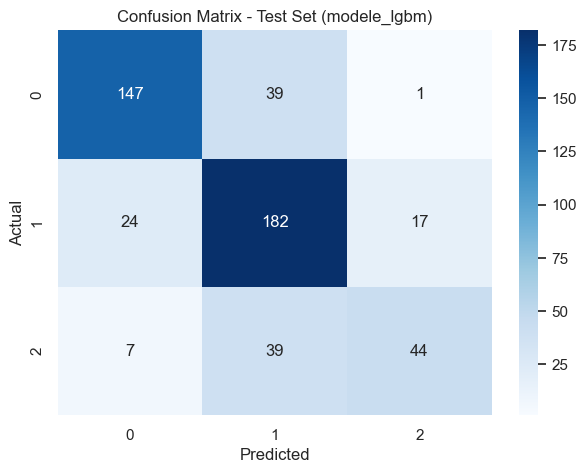

Modèle sauvegardé : ..\models\modele_lgbm_v1.0_S1_multimodale_complete.joblib
Métadonnées sauvegardées : ..\models\modele_lgbm_v1.0_S1_multimodale_complete_metadata.json
Résumé métriques test finales (meilleur modèle modele_lgbm sur scénario S1 multimodal) :



,scenario_choisi,modele_choisi,f1_macro_test,ecart_type_test,recall_classe_2_test,precision_classe_2_test,f1_class_2_test,erreur_critique_2_vers_0_test,temps_fit_s,latence_moyenne_ms,latence_p95_ms,cout_inference_euros_1000,cpu_seconds_par_prediction,temps_predict_s
0,S1_multimodale_complete,modele_lgbm,0.713,0.435,0.489,0.71,0.579,0.078,1.787,7.685,11.495,0.009,0.066,0.028


Test final sur le jeu de test pour le modèle : modele_logreg
Modèle sauvegardé : ..\models\modele_logreg_v1.0_S1_multimodale_complete.joblib


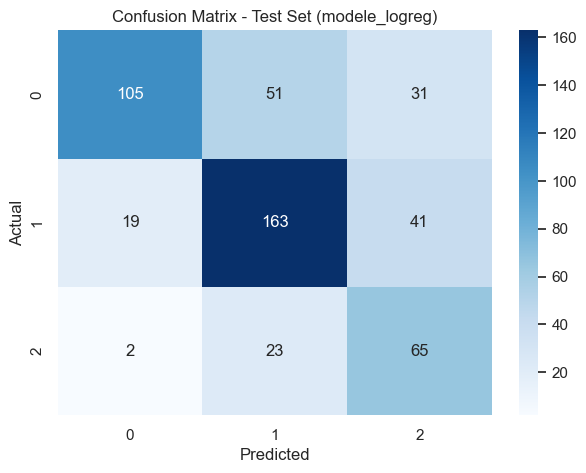

Modèle sauvegardé : ..\models\modele_logreg_v1.0_S1_multimodale_complete.joblib
Métadonnées sauvegardées : ..\models\modele_logreg_v1.0_S1_multimodale_complete_metadata.json
Résumé métriques test finales (meilleur modèle modele_logreg sur scénario S1 multimodal) :



,scenario_choisi,modele_choisi,f1_macro_test,ecart_type_test,recall_classe_2_test,precision_classe_2_test,f1_class_2_test,erreur_critique_2_vers_0_test,temps_fit_s,latence_moyenne_ms,latence_p95_ms,cout_inference_euros_1000,cpu_seconds_par_prediction,temps_predict_s
0,S1_multimodale_complete,modele_logreg,0.651,0.472,0.722,0.474,0.573,0.022,0.384,7.205,11.511,0.001,0.007,0.023


Test final sur le jeu de test pour le modèle : modele_rfc
Modèle sauvegardé : ..\models\modele_rfc_v1.0_S1_multimodale_complete.joblib


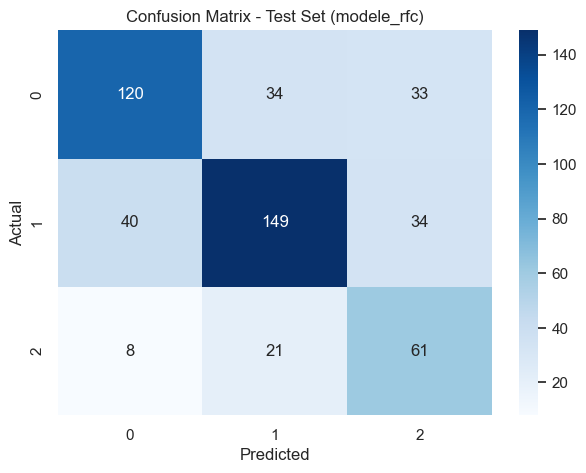

Modèle sauvegardé : ..\models\modele_rfc_v1.0_S1_multimodale_complete.joblib
Métadonnées sauvegardées : ..\models\modele_rfc_v1.0_S1_multimodale_complete_metadata.json
Résumé métriques test finales (meilleur modèle modele_rfc sur scénario S1 multimodal) :



,scenario_choisi,modele_choisi,f1_macro_test,ecart_type_test,recall_classe_2_test,precision_classe_2_test,f1_class_2_test,erreur_critique_2_vers_0_test,temps_fit_s,latence_moyenne_ms,latence_p95_ms,cout_inference_euros_1000,cpu_seconds_par_prediction,temps_predict_s
0,S1_multimodale_complete,modele_rfc,0.645,0.474,0.678,0.477,0.56,0.089,0.838,61.902,76.888,0.009,0.064,0.178


Modèles sauvegardés :


,modele,scenario,chemin,temps_fit_s
0,modele_lgbm_v1.0,S1_multimodale_complete,..\models\modele_lgbm_v1.0_S1_multimodale_comp...,1.787
1,modele_logreg_v1.0,S1_multimodale_complete,..\models\modele_logreg_v1.0_S1_multimodale_co...,0.384
2,modele_rfc_v1.0,S1_multimodale_complete,..\models\modele_rfc_v1.0_S1_multimodale_compl...,0.838


In [19]:
# Test final (Fit et predict) sur le jeu de test (X_test, y_test) pour les 3 meilleurs modèles (RFC, LGBM, LogReg)
scenario_choisi  = scenarios["S1_multimodale_complete"]
preprocessor_final = build_preprocessor(scenario_choisi)

modeles_choisis = {"modele_lgbm" : LGBMClassifier(
    n_estimators=400,       # Beaucoup d'arbres pour apprendre progressivement sans brusquer le modèle.
    learning_rate=0.02,     # Petit pas d'apprentissage pour améliorer la généralisation.
    num_leaves=24,          # Complexité modérée de chaque arbre (évite des règles trop fines).
    min_child_samples=10,   # Impose assez d'exemples par feuille pour éviter d'apprendre le bruit.
    colsample_bytree=0.7,   # Sous-échantillonnage des colonnes (utile avec one-hot + tf-idf).
    random_state=RANDOM_STATE
), "modele_logreg" : LogisticRegression(
    solver="lbfgs", # Rapide pour petits jeux de données.
    C=0.1,          # Régularisation plus forte pour éviter le surajustement
    class_weight=class_weights_lr,
    max_iter=1000,  # Nombre d'itérations pour convergence (par défaut 100, parfois insuffisant)
    random_state=RANDOM_STATE,
    n_jobs=-1       # Utilise tous les cœurs pour accélérer l'entraînement
), "modele_rfc" : RandomForestClassifier(
    n_estimators=500,           # Beaucoup d'arbres pour apprendre progressivement sans brusquer le modèle.
    max_depth=12,               # Limite la complexité des arbres pour mieux généraliser
    min_samples_split=5,        # Limite la complexité des arbres pour mieux généraliser
    min_samples_leaf=4,         # Limite la complexité des arbres pour mieux généraliser
    max_features="sqrt",        # ou 0.5 (meilleur que 0.35 pour la diversité)
    max_samples=0.8,            # Sous-échantillonnage des données (0.6-0.9)
    bootstrap=True,             # Gardé à True (meilleure généralisation)
    random_state=RANDOM_STATE,
    n_jobs=-1,                  # Utilise tous les cœurs CPU
    class_weight=class_weights_rfc  # Poids personnalisés
)}

# Liste pour stocker les artefacts des modèles (chemins, temps d'entraînement, etc.)
artefacts_modeles = []

# Boucle sur les modèles choisis pour effectuer le test final
for modele_name, modele in modeles_choisis.items():
    print(f"Test final sur le jeu de test pour le modèle : {modele_name}")
    # Création du pipeline final avec le préprocesseur et le modèle choisi
    pipeline_final = Pipeline([
        ("preparation", preprocessor_final),
        ("modele", modele)
    ])

    # 1) Temps d'entraînement (offline)
    t0_fit = time.perf_counter()
    pipeline_final.fit(X_train, y_train)
    temps_fit_final = time.perf_counter() - t0_fit

    # 2) Prédiction test
    t0_predict = time.perf_counter()
    y_pred_test = pipeline_final.predict(X_test)
    temps_predict_final = time.perf_counter() - t0_predict

    # 3) Sauvegarde du pipeline complet : preprocessing + modèle entraîné
    nom_fichier_modele = f"{modele_name}_v1.0_S1_multimodale_complete.joblib"
    chemin_modele = MODEL_DIR / nom_fichier_modele

    joblib.dump(pipeline_final, chemin_modele)

    artefacts_modeles.append({
        "modele": modele_name+"_v1.0",
        "scenario": "S1_multimodale_complete",
        "chemin": str(chemin_modele),
        "temps_fit_s": round(temps_fit_final, 3),
    })

    print(f"Modèle sauvegardé : {chemin_modele}")

    # 4) Métriques qualité + mesure temps inférence pour comparaison au chapitre 6.1
    # Mesure de la latence individuelle sur le jeu de test
    n_mesures = min(500, len(X_test))

    # Warm-up : exclut le coût du premier appel
    pipeline_final.predict(X_test.iloc[[0]])

    latences_ms = []
    t0_cpu = time.process_time()

    for i in range(n_mesures):
        t0 = time.perf_counter()
        pipeline_final.predict(X_test.iloc[[i]])
        latences_ms.append((time.perf_counter() - t0) * 1000)

    cpu_seconds_total = time.process_time() - t0_cpu
    cpu_seconds_par_prediction = cpu_seconds_total / n_mesures

    # Hypothèse documentée : coût estimé d'une machine CPU utilisée pour servir les prédictions.
    # Valeur simplifiée pour comparer les modèles, hors stockage, réseau, monitoring et maintenance.
    tarif_cpu_euros_heure = 0.50
    tarif_cpu_euros_seconde = tarif_cpu_euros_heure / 3600

    cout_inference_euros_1000 = (
        cpu_seconds_par_prediction
        * 1000
        * tarif_cpu_euros_seconde
    )

    latence_moyenne_ms = float(np.mean(latences_ms))
    latence_p95_ms = float(np.percentile(latences_ms, 95))

    # 5) Matrice de confusion finale sur l'ensemble de test
    cm_final = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])

    # Affichage de la matrice de confusion finale
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Test Set ({modele_name})")
    plt.show()

    # Calcul des métriques finales sur l'ensemble de test
    f1_macro_final = f1_score(y_test, y_pred_test, average="macro")
    ecart_type_final = np.std(y_test == y_pred_test)
    recall_class_2_final = recall_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    precision_class_2_final = precision_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    f1_class_2_final = f1_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    erreur_critique_2_vers_0_final = critical_error_2_to_0(y_test, y_pred_test)

    resume_test = pd.DataFrame([{
        "scenario_choisi": "S1_multimodale_complete",
        "modele_choisi": modele_name,
        "f1_macro_test": round(f1_macro_final, 3),
        "ecart_type_test": round(ecart_type_final, 3),
        "recall_classe_2_test": round(recall_class_2_final, 3),
        "precision_classe_2_test": round(precision_class_2_final, 3),
        "f1_class_2_test": round(f1_class_2_final, 3),
        "erreur_critique_2_vers_0_test": round(erreur_critique_2_vers_0_final, 3),
        "temps_fit_s": round(temps_fit_final, 3),
        "latence_moyenne_ms": round(latence_moyenne_ms, 3),
        "latence_p95_ms": round(latence_p95_ms, 3),
        "cout_inference_euros_1000": round(cout_inference_euros_1000, 3),
        "cpu_seconds_par_prediction": round(cpu_seconds_par_prediction, 3),
        "temps_predict_s": round(temps_predict_final, 3),
    }])

    # Sauvegarde des métadonnées
    metadonnees = {
        "modele": modele_name,
        "model_version": "1.0",
        "session_date": session_date,
        "created_at": datetime.now(timezone.utc).isoformat(),
        "scenario": "S1_multimodale_complete",
        "chemin": str(chemin_modele),
        "python_version": py_version,
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "dataset": DATASET_NAME,
        "dataset_source": DATASET_SOURCE,
        "dataset_version": DATASET_VERSION,
        "hyperparameters": modele.get_params() if hasattr(modele, "get_params") else None,
        "metriques": {
            "f1_macro_test": round(f1_macro_final, 3),
            "ecart_type_test": round(ecart_type_final, 3),
            "recall_classe_2_test": round(recall_class_2_final, 3),
            "precision_classe_2_test": round(precision_class_2_final, 3),
            "f1_class_2_test": round(f1_class_2_final, 3),
            "erreur_critique_2_vers_0_test": round(erreur_critique_2_vers_0_final, 3),
            "temps_fit_s": round(temps_fit_final, 3),
            "latence_moyenne_ms": round(latence_moyenne_ms, 3),
            "latence_p95_ms": round(latence_p95_ms, 3),
            "cout_inference_euros_1000": round(cout_inference_euros_1000, 3)
        },
        "features_columns": X_train.columns.tolist(),
        "target_column": y_train.name,
    }

    chemin_metadonnees = MODEL_DIR / f"{modele_name}_v1.0_S1_multimodale_complete_metadata.json"
    chemin_metadonnees.write_text(json.dumps(metadonnees, indent=2), encoding="utf-8")
    print(f"Modèle sauvegardé : {chemin_modele}")
    print(f"Métadonnées sauvegardées : {chemin_metadonnees}")

    print(f"Résumé métriques test finales (meilleur modèle {modele_name} sur scénario S1 multimodal) :\n" + "="*80 + "\n")
    display(resume_test)

artefacts_modeles_df = pd.DataFrame(artefacts_modeles)

print("Modèles sauvegardés :")
display(artefacts_modeles_df)

artefacts_modeles_df.to_csv(MODEL_DIR / "registre_modeles_sauvegardes.csv", index=False)

Les trois pipelines finalistes sont sauvegardés au format `.joblib` dans le dossier `../models`.

Chaque fichier contient le pipeline complet :
- préprocessing,
- imputations,
- encodages,
- vectorisation TF-IDF,
- modèle entraîné.

### 5.7 Synthèse modélisation

#### Modèle retenu

Le modèle retenu est le **LightGBMClassifier**, entraîné sur le scénario **S1 — approche multimodale complète**.

Ce choix repose principalement sur :

- Le meilleur compromis entre performance globale et complexité.
- Un F1-score macro supérieur ou comparable aux autres modèles.
- Une bonne capacité à exploiter simultanément les variables numériques, catégorielles et les variables TF-IDF.
- Un temps d'entraînement et d'inférence compatible avec l'objectif opérationnel.
- Une meilleure stabilité générale que les modèles fortement pondérés en faveur de la classe 2.

La sélection ne repose toutefois pas uniquement sur le F1-score macro. L'erreur critique `2 → 0` est particulièrement importante : elle correspond à un demandeur d'emploi réellement en situation de retour long, classé à tort comme ayant un retour rapide.

À titre d'hypothèse métier, on peut attribuer les coûts suivants :

| Type d'erreur | Coût proposé (en d'euros) | Interprétation |
|---|---:|---|
| `0 → 1` ou `1 → 0` | 1000 | Erreur d'orientation modérée |
| `1 → 2` ou `2 → 1` | 5000 | Intensité d'accompagnement mal évaluée |
| `0 → 2` | 8000 | Mobilisation excessive de ressources |
| `2 → 0` | 15000 | Erreur critique : absence possible d'un accompagnement renforcé |

In [34]:
# Coût métier total pour plusieurs scénarios et plusieurs modèles

matrice_couts = np.array([
    [0, 1, 8],    # Vrai 0
    [1, 0, 5],    # Vrai 1
    [15, 5, 0],   # Vrai 2 : 2 -> 0 est l'erreur critique
])

modeles_par_scenario = {
    "S1_multimodale_complete": [modele_lgbm, modele_logreg, rfc_modele],
    "S2_sans_variables_sensibles": [candidats["lr_clf"]],
    "S3_texte_seul": [candidats["rf_clf"]],
    "S4_tabulaire_seul": [candidats["rf_clf"]],
}

resultats_couts = []

for scenario_name, scenario_cols in scenarios.items():
    if scenario_name not in modeles_par_scenario:
        continue

    for modele in modeles_par_scenario[scenario_name]:
        pipeline_final = Pipeline([
            ("preparation", build_preprocessor(scenario_cols)),
            ("modele", modele)
        ])

        pipeline_final.fit(X_train, y_train)
        y_pred_test = pipeline_final.predict(X_test)

        couts_individuels = matrice_couts[
            y_test.to_numpy().astype(int),
            np.asarray(y_pred_test).astype(int)
        ]

        cm_final = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])

        resultats_couts.append({
            "Scénario": scenario_name,
            "Modèle": type(modele).__name__,
            "Coût total (en milliers d'euros)": int(couts_individuels.sum()),
            "Coût moyen par dossier (en milliers d'euros)": round(couts_individuels.mean(), 3),
            "Erreur critique 2→0": int(cm_final[2, 0]),
        })

tableau_couts = (
    pd.DataFrame(resultats_couts)
    .sort_values(["Coût total (en milliers d'euros)", "Erreur critique 2→0"], ascending=[True, True])
    .reset_index(drop=True)
)

display(tableau_couts)

,Scénario,Modèle,Coût total (en milliers d'euros),Coût moyen par dossier (en milliers d'euros),Erreur critique 2→0
0,S4_tabulaire_seul,RandomForestClassifier,436,0.872,6
1,S1_multimodale_complete,LGBMClassifier,534,1.068,9
2,S2_sans_variables_sensibles,LogisticRegression,655,1.310,9
3,S1_multimodale_complete,LogisticRegression,668,1.336,2
4,S1_multimodale_complete,RandomForestClassifier,733,1.466,8
5,S3_texte_seul,RandomForestClassifier,769,1.538,12


Avec cette pondération, le modèle avec un cout le moins élevé sur le scénario 1 est **LightGBMClassifier**.

Le modèle ne doit pas être utilisé pour prendre automatiquement une décision. Il doit fournir une aide à la décision au conseiller, avec une vérification humaine obligatoire, notamment lorsque la probabilité des classes est proche ou lorsqu'une prédiction de classe 0 concerne un profil potentiellement vulnérable.

#### Résultats sur le test final

Les résultats obtenus sur le jeu de test sur le scénario S1 sont les suivants :

| Modèle |  F1 macro | Recall classe 2 | Précision classe 2 | F1 classe 2 | Erreur critique `2 → 0` |
|---|---:|---:|---:|---:|---:|
| **LightGBM** | **0.713** | 0.489 | **0.710** | **0.579** | 0.078 |
| LogisticRegression | 0.651 | **0.722** | 0.474 | 0.573 | **0.022** |
| RandomForest | 0.645 | 0.678 | 0.477 | 0.560 | 0.089 |

L'évaluation sur le test est réalisée une seule fois, après les choix de préparation et de paramétrage. Elle constitue donc l'estimation finale de la performance attendue sur de nouvelles observations.

#### Comparaison avec la baseline DummyClassifier

Le `DummyClassifier` constitue une baseline minimale. Il prédit principalement la classe majoritaire et ne tient compte d'aucune caractéristique individuelle.

| Critère | DummyClassifier | Modèle retenu |
|---|---:|---:|
| F1 macro | 0.206 | 0.713 |
| Recall classe 2 | 0.000 | 0.489 |
| Erreur critique `2 → 0` | 0.000 | 0.078 |

La comparaison avec la baseline permet donc de vérifier que le modèle apprend.

Le score nul en erreur critique ne signifie pas que le DummyClassifier est performant : son rappel de la classe 2 est également nul, car il prédit systématiquement la classe majoritaire, ici la classe 1.

#### Points faibles et limites connus

Plusieurs limites sont à prendre en compte :

- Le jeu de données est limité à 2 500 observations.
- Les textes d'entretien sont très redondants, avec seulement quelques formulations distinctes.
- La classe 2 reste minoritaire, ce qui rend son évaluation plus incertaine.
- Les résultats peuvent varier selon le découpage train/test.
- Les variables `age`, `nationalite_hors_ue`, `est_allocataire` et `departement` peuvent introduire ou reproduire des biais.
- Le code ROME et le département peuvent agir comme variables proxy de caractéristiques sociales ou territoriales.
- Les pondérations de classes améliorent le rappel de la classe 2, mais dégradent fortement le F1 macro.

En conséquence, le modèle doit être considéré comme un outil d'aide au tri et à la priorisation, et non comme un outil de décision automatique. Une supervision humaine, une possibilité de contestation et un suivi régulier des performances et des écarts entre sous-groupes sont indispensables avant toute mise en production.
C'est, de toute façon, une obligation de l'AI Act.

---
## 6. Analyse des scénarios & arbitrages

### 6.1 Tableau comparatif

| Scénario | Modèle | Métrique principale | Métriques secondaires | Coût inférence (€/1000 prédictions) | Latence p95 (ms) | Coût métier (en milliers d'euros) | Explicabilité | Dépendance fournisseur | Biais | Verdict |
|---|---|---|---|---|---|---|---|---|---|---|
| Scénario 1 — Approche multimodale complète | LightGBMClassifier tuné | **F1-macro = 0.713** | Recall classe 2 = 0.489, Erreur critique 2→0 = 0.078 | 0.013€ | 23.64 | 534 | Moyenne (`feature_importances_`, fournit une mesure d'importance des features) | Aucune (modèle local scikit-learn/LightGBM) | Variables sensibles identifiées en §1.5 (`age`, `nationalite_hors_ue`, `code_insee_commune`→`département`, `est_allocataire`) confirmées à risque en §3.6 (DI < 0.8 sur `age`, `nationalite_hors_ue` et `niveau_diplome`). Non mitigées ici (S1 conserve toutes les variables) | **Retenu** : meilleur compromis F1-macro/coût, mais nécessite une supervision humaine renforcée sur les biais identifiés ainsi que sur l'erreur critique |
| Scénario 1 — Approche multimodale complète | LogisticRegression tuné | F1-macro = 0.651 | **Recall classe 2 = 0.722, Erreur critique 2→0 = 0.022** | **0.001€** | **13.55** | 668 | Élevée (coefficients directement interprétables par variable) | Aucune (modèle local scikit-learn) | Mêmes biais qu'au-dessus (§1.5/§3.6), non mitigés mais modèle simple donc plus facile à auditer, mais toujours sensible aux variables proxy | **Alternative "sécurité maximale"** : à privilégier si l'erreur critique 2→0 est jugée inacceptable, au prix d'un F1-macro plus faible ou si l'explicabilité est obligatoire (AI act) |
| Scénario 1 — Approche multimodale complète | RandomForestClassifier tuné | F1-macro = 0.645 | Recall classe 2 = 0.678, Erreur critique 2→0 = 0.089 | 0.014€ | 122.80 | 733 | Moyenne (`feature_importances_`) | Aucune (modèle local scikit-learn) | Mêmes biais qu'au-dessus (§1.5/§3.6), non mitigés | **Compromis équilibré** : bon recall classe 2 sans sacrifier totalement le F1-macro, mais dominé par LightGBM sur la performance globale |
| Scénario 2 — Sans variables sensibles (Approche Éthique) | LogisticRegression (défaut, non tuné) | F1-macro = 0.636 | Recall classe 2 = 0.5, Erreur critique 2→0 = 0.210 | Très faible (même ordre de grandeur que le scénario 1 avec le même modèle) |  Très faible, (De même, < 10 ms attendu) | 655 | Élevée (coefficients interprétables) | Aucune (modèle local scikit-learn) | Variables sensibles retirées (`age`, `nationalite_hors_ue`, `departement`) → mitigation directe du risque identifié en §1.5/§3.6 | Rejeté en l'état : chute drastique du F1-macro (0.475 vs 0.713 en S1) et du recall classe 2 (0.160, le plus faible de tous les modèles hors Dummy) : retirer les variables sensibles fait perdre l'essentiel du signal prédictif utile (avec des modèles non tunés) |
| Scénario 3 — Diagnostic par le texte seul (NLP pure) | RandomForestClassifier (défaut, ex-æquo avec XGBoost, non tuné) | F1-macro = 0.635 | Recall classe 2 = 0.661, Erreur critique 2→0 = 0.190 | Même ordre de grandeur que le scénario 1 avec le même modèle | Même ordre de grandeur que le scénario 1 avec le même modèle | 769 | Moyenne (`feature_importances_`) | Aucune (modèle local scikit-learn) | Seulement 9 formulations uniques (§3.2) → risque de surapprentissage | Résultat surprenant et fragile : très bon recall classe 2 malgré l'absence de variables tabulaires, mais à interpréter avec prudence : la redondance du texte (9 synthèses uniques pour 2419 non-nuls, cf §3.2) limite fortement la généralisabilité de ce score |
| Scénario 4 — Données contextuelles pures (Tabulaire seul) | RandomForestClassifier (défaut, non tuné) | F1-macro = 0.679 | Recall classe 2 = 0.472, Erreur critique 2→0 = 0.097 | Même ordre de grandeur que le scénario 1 avec le même modèle | Même ordre de grandeur que le scénario 1 avec le même modèle | **436** | Moyenne (`feature_importances_`) | Aucune (modèle local scikit-learn) | Biais identiques à S1 | Résultat notable : très bon F1-macro en CV brute, le texte apporte donc peu de valeur ajoutée par rapport au tabulaire seul en configuration par défaut, ce qui questionne l'intérêt du scénario multimodal |

> Attention :
>- Les coûts d'inférence moyens des trois modèles du scénario 1 sont mesurés en 5.6 sur 500 dossiers. Et n'est qu'une estimation pour les scénarios 2, 3 et 4.
>- De même pour la latence P95.
>- L’évaluation finale sur le jeu de test n’a été réalisée que pour trois modèles et que sur le scénario 1.

### 6.2 Recommandation finale au client

Je recommande le scénario 1 : il offre le meilleur niveau de performance globale tout en gardant un coût métier maîtrisé.

Son principal compromis est qu’il peut encore sous-estimer certains profils ayant besoin d’un accompagnement long.

La décision finale doit donc rester au conseiller, avec une revue renforcée des dossiers fragiles.
Le gain attendu est un tri plus rapide et plus cohérent, sans automatiser l’accès aux aides ou à l’accompagnement.

### 6.3 Synthèse arbitrages

Le choix a été tranché en faveur de la meilleure qualité globale d’orientation (F1-macro) et du coût métier total le plus faible.
L’alternative plus protectrice repère davantage de dossiers fragiles, mais elle dégrade le tri général et mobilise plus souvent un accompagnement renforcé sans nécessité.

Le scénario 1 est donc retenu, à condition de conserver une validation humaine pour les dossiers sensibles.

Le scénario S2 est une alternative crédible quand la conformité éthique est prioritaire, car il supprime les variables sensibles sans faire perdre tout le signal prédictif. En revanche, il reste moins performant que S1 sur la détection de la classe la plus critique.

---
## 7. Interprétation pour la communication client

### 7.1 Feature importance / SHAP



Top 20 des features transformées selon l'importance LightGBM (gain) :


,feature_transformee,importance_gain,importance_relative_pct
0,num__age,12017.83,16.41
1,ord__niveau_diplome,9042.81,12.35
2,num__anciennete_poste_ans,8079.05,11.03
3,txt__de,4938.47,6.74
4,txt__compétences,3355.47,4.58
5,cat__nationalite_hors_ue_0,3295.85,4.50
6,txt__affiner,2654.33,3.62
7,txt__de mobilité,1693.22,2.31
8,txt__constatée,1508.90,2.06
9,cat__nationalite_hors_ue_1,1072.48,1.46


Top des variables originales après agrégation des modalités et termes TF-IDF :


,feature_source,importance_gain,importance_relative_pct
0,synthese_entretien,22080.94,30.15
1,age,12017.83,16.41
2,code_rome_vise,10732.72,14.66
3,niveau_diplome,9042.81,12.35
4,anciennete_poste_ans,8079.05,11.03
5,departement,5684.16,7.76
6,nationalite_hors_ue,4368.33,5.97
7,est_allocataire,1223.26,1.67


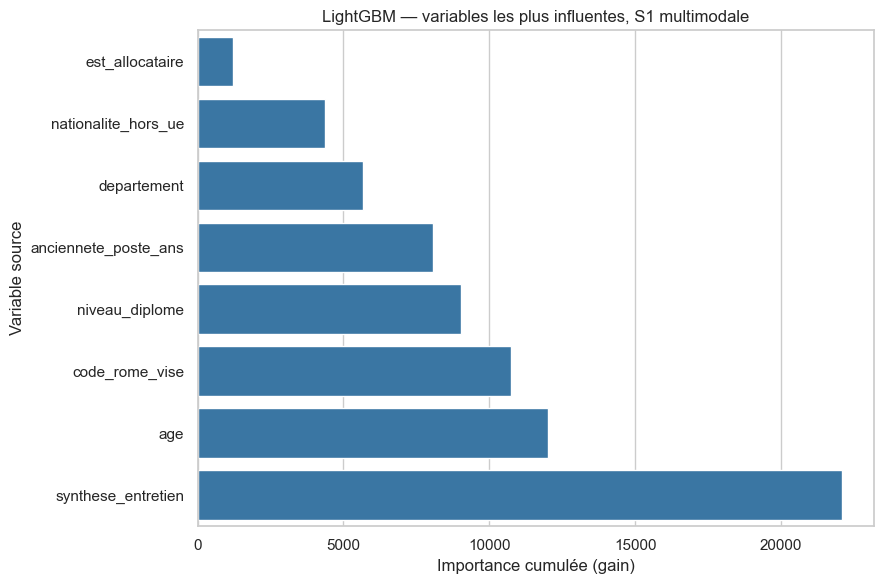

In [20]:
# Identifier les features les plus influentes pour le modèle LightGBMClassifier sur le scénario S1
# Analyse du pipeline réellement sauvegardé pour S1, afin de conserver l'alignement
# entre le préprocessing et les importances du LightGBM.
# Le fichier contient à la fois le préprocesseur et le modèle déjà entraîné.
chemin_lgbm = MODEL_DIR / "modele_lgbm_v1.0_S1_multimodale_complete.joblib"
pipeline_lgbm = joblib.load(chemin_lgbm)
preprocesseur_lgbm = pipeline_lgbm.named_steps["preparation"]
modele_lgbm_final = pipeline_lgbm.named_steps["modele"]

# On récupère les noms des variables après transformation pour pouvoir
# relier chaque importance LightGBM à une variable lisible.
try:
    noms_features = preprocesseur_lgbm.get_feature_names_out()
except AttributeError:
    # La branche TF-IDF contient une FunctionTransformer (to_1d) qui ne
    # fournit pas get_feature_names_out : on reconstruit alors les noms branche par branche.
    noms_features = []
    for nom_branche, transformateur, colonnes in preprocesseur_lgbm.transformers_:
        if transformateur == "drop":
            continue
        if transformateur == "passthrough":
            noms_branche = [f"{nom_branche}__{colonne}" for colonne in colonnes]
        else:
            try:
                # Cas standard : le transformateur sait produire ses noms de sortie.
                noms_branche = transformateur.get_feature_names_out(colonnes)
            except AttributeError:
                # Cas texte : les termes finaux sont fournis par le TfidfVectorizer.
                dernier_transformateur = list(transformateur.named_steps.values())[-1]
                noms_branche = dernier_transformateur.get_feature_names_out()
            noms_branche = [f"{nom_branche}__{nom}" for nom in noms_branche]
        noms_features.extend(noms_branche)

# Le gain mesure la réduction cumulée de l'impureté apportée par chaque feature.
# Il est préférable ici à une simple fréquence de séparation, car il tient compte
# de la contribution effective des variables aux décisions du modèle.
importances_gain = modele_lgbm_final.booster_.feature_importance(importance_type="gain")
assert len(noms_features) == len(importances_gain), (
    f"Nombre de noms ({len(noms_features)}) différent des importances ({len(importances_gain)})"
)

# Tableau détaillé au niveau des variables transformées : modalités one-hot
# et termes TF-IDF apparaissent encore séparément à ce stade.
importance_lgbm = (
    pd.DataFrame({
        "feature_transformee": noms_features,
        "importance_gain": importances_gain,
    })
    .sort_values("importance_gain", ascending=False)
    .reset_index(drop=True)
)
importance_lgbm["importance_relative_pct"] = (
    100 * importance_lgbm["importance_gain"] / importance_lgbm["importance_gain"].sum()
)

print("Top 20 des features transformées selon l'importance LightGBM (gain) :")
display(importance_lgbm.head(20).round({"importance_gain": 2, "importance_relative_pct": 2}))

# Regroupement des modalités one-hot et des termes TF-IDF par variable source.
# Toutes les features txt__... proviennent de la colonne synthese_entretien.
def feature_source(feature_name):
    if feature_name.startswith("txt__"):
        return "synthese_entretien"

    nom = re.sub(r"^(num|cat|ord|txt)__", "", feature_name)
    nom = re.sub(r"_(?:[0-9]+|x)$", "", nom)
    for colonne in sorted(X_train.columns, key=len, reverse=True):
        if nom == colonne or nom.startswith(f"{colonne}_"):
            return colonne
    return nom

importance_lgbm["feature_source"] = importance_lgbm["feature_transformee"].map(feature_source)
importance_agregee = (
    importance_lgbm.groupby("feature_source", as_index=False)["importance_gain"]
    .sum()
    .sort_values("importance_gain", ascending=False)
    .reset_index(drop=True)
)
importance_agregee["importance_relative_pct"] = (
    100 * importance_agregee["importance_gain"] / importance_agregee["importance_gain"].sum()
)

print("Top des variables originales après agrégation des modalités et termes TF-IDF :")
display(importance_agregee.round({"importance_gain": 2, "importance_relative_pct": 2}))

# Le graphique présente la vue agrégée, plus directement exploitable
# pour la communication métier et l'analyse des variables sensibles.
plt.figure(figsize=(9, 6))
top_features = importance_agregee.head(15).sort_values("importance_gain")
sns.barplot(
    data=top_features,
    x="importance_gain",
    y="feature_source",
    color="#2878b5",
)
plt.title("LightGBM — variables les plus influentes, S1 multimodale")
plt.xlabel("Importance cumulée (gain)")
plt.ylabel("Variable source")
plt.tight_layout()
plt.show()


On remarque que seule la variable `age` est une variable sensible qui apporte une influence non négligeable.

Par ailleurs, le scénario 1 conserve l'ensemble des variables sensibles ou susceptibles de favoriser des biais. Dans le contexte de ce projet et au regard des exigences du RGPD, l'utilisation de `nationalite_hors_ue` doit donc être questionnée. Il est nécessaire de réaliser un test final du modèle sélectionné dans le scénario 1, en retirant cette variable, afin de mesurer son impact sur les performances et de vérifier si un compromis plus favorable entre efficacité et équité est possible.

Test final sur le jeu de test pour le modèle : modele_lgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 270
[LightGBM] [Info] Start training from score -0.982163
[LightGBM] [Info] Start training from score -0.810805
[LightGBM] [Info] Start training from score -1.709258


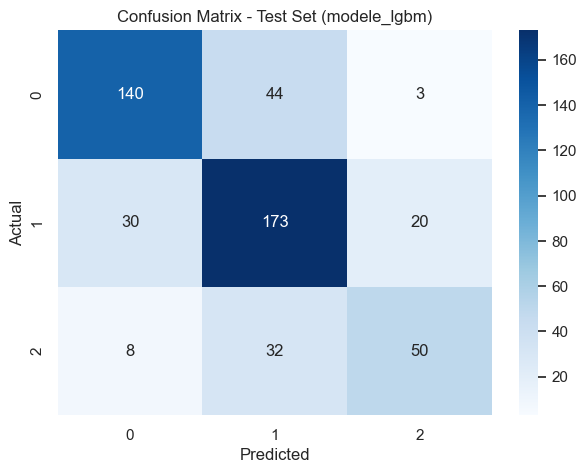

Résumé métriques test finales (meilleur modèle modele_lgbm sur scénario S1 sans nationalité hors UE) :



,scenario_choisi,modele_choisi,f1_macro_test,ecart_type_test,recall_classe_2_test,precision_classe_2_test,f1_class_2_test,erreur_critique_2_vers_0_test,temps_fit_s,latence_moyenne_ms,latence_p95_ms,cout_inference_euros_1000,cpu_seconds_par_prediction,temps_predict_s
0,S1_sans_nationalite_hors_ue,modele_lgbm,0.705,0.446,0.556,0.685,0.613,0.089,1.728,7.826,12.595,0.009,0.064,0.026


In [20]:
# Scénario 1 sans nationalite_hors_ue
scenarios = {
    "S1_sans_nationalite_hors_ue": {
        "num": colonnes_num,
        "cat": [
            colonne
            for colonne in colonnes_cat
            if colonne != "nationalite_hors_ue"
        ],
        "ord": colonnes_ord,
        "txt": colonnes_txt,
    }
}

preprocessor_final = build_preprocessor(scenarios["S1_sans_nationalite_hors_ue"])

modeles_choisis = {"modele_lgbm" : LGBMClassifier(
    n_estimators=400,       # Beaucoup d'arbres pour apprendre progressivement sans brusquer le modèle.
    learning_rate=0.02,     # Petit pas d'apprentissage pour améliorer la généralisation.
    num_leaves=24,          # Complexité modérée de chaque arbre (évite des règles trop fines).
    min_child_samples=10,   # Impose assez d'exemples par feuille pour éviter d'apprendre le bruit.
    colsample_bytree=0.7,   # Sous-échantillonnage des colonnes (utile avec one-hot + tf-idf).
    random_state=RANDOM_STATE
)}

# Boucle sur les modèles choisis pour effectuer le test final
for modele_name, modele in modeles_choisis.items():
    print(f"Test final sur le jeu de test pour le modèle : {modele_name}")
    # Création du pipeline final avec le préprocesseur et le modèle choisi
    pipeline_final = Pipeline([
        ("preparation", preprocessor_final),
        ("modele", modele)
    ])

    # 1) Temps d'entraînement (offline)
    t0_fit = time.perf_counter()
    pipeline_final.fit(X_train, y_train)
    temps_fit_final = time.perf_counter() - t0_fit

    # 2) Prédiction test
    t0_predict = time.perf_counter()
    y_pred_test = pipeline_final.predict(X_test)
    temps_predict_final = time.perf_counter() - t0_predict

    # 4) Métriques qualité + mesure temps inférence pour comparaison au chapitre 6.1
    # Mesure de la latence individuelle sur le jeu de test
    n_mesures = min(500, len(X_test))

    # Warm-up : exclut le coût du premier appel
    pipeline_final.predict(X_test.iloc[[0]])

    latences_ms = []
    t0_cpu = time.process_time()

    for i in range(n_mesures):
        t0 = time.perf_counter()
        pipeline_final.predict(X_test.iloc[[i]])
        latences_ms.append((time.perf_counter() - t0) * 1000)

    cpu_seconds_total = time.process_time() - t0_cpu
    cpu_seconds_par_prediction = cpu_seconds_total / n_mesures

    # Hypothèse documentée : coût estimé d'une machine CPU utilisée pour servir les prédictions.
    # Valeur simplifiée pour comparer les modèles, hors stockage, réseau, monitoring et maintenance.
    tarif_cpu_euros_heure = 0.50
    tarif_cpu_euros_seconde = tarif_cpu_euros_heure / 3600

    cout_inference_euros_1000 = (
        cpu_seconds_par_prediction
        * 1000
        * tarif_cpu_euros_seconde
    )

    latence_moyenne_ms = float(np.mean(latences_ms))
    latence_p95_ms = float(np.percentile(latences_ms, 95))

    # 5) Matrice de confusion finale sur l'ensemble de test
    cm_final = confusion_matrix(y_test, y_pred_test, labels=[0, 1, 2])

    # Affichage de la matrice de confusion finale
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Test Set ({modele_name})")
    plt.show()

    # Calcul des métriques finales sur l'ensemble de test
    f1_macro_final = f1_score(y_test, y_pred_test, average="macro")
    ecart_type_final = np.std(y_test == y_pred_test)
    recall_class_2_final = recall_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    precision_class_2_final = precision_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    f1_class_2_final = f1_score(y_test, y_pred_test, labels=[2], average="macro", zero_division=0)
    erreur_critique_2_vers_0_final = critical_error_2_to_0(y_test, y_pred_test)

    resume_test = pd.DataFrame([{
        "scenario_choisi": "S1_sans_nationalite_hors_ue",
        "modele_choisi": modele_name,
        "f1_macro_test": round(f1_macro_final, 3),
        "ecart_type_test": round(ecart_type_final, 3),
        "recall_classe_2_test": round(recall_class_2_final, 3),
        "precision_classe_2_test": round(precision_class_2_final, 3),
        "f1_class_2_test": round(f1_class_2_final, 3),
        "erreur_critique_2_vers_0_test": round(erreur_critique_2_vers_0_final, 3),
        "temps_fit_s": round(temps_fit_final, 3),
        "latence_moyenne_ms": round(latence_moyenne_ms, 3),
        "latence_p95_ms": round(latence_p95_ms, 3),
        "cout_inference_euros_1000": round(cout_inference_euros_1000, 3),
        "cpu_seconds_par_prediction": round(cpu_seconds_par_prediction, 3),
        "temps_predict_s": round(temps_predict_final, 3),
    }])

    print(f"Résumé métriques test finales (meilleur modèle {modele_name} sur scénario S1 sans nationalité hors UE) :\n" + "="*80 + "\n")
    display(resume_test)

### Conclusion sur la suppression de `nationalite_hors_ue`

La comparaison porte sur le modèle LightGBM, avec le même jeu de test et les mêmes hyperparamètres. Dans le scénario S1 multimodal complet, le modèle obtient un **F1 macro de 0,713**, un **rappel de la classe 2 de 0,489**, une **précision de la classe 2 de 0,710**, un **F1 de la classe 2 de 0,579** et une **erreur critique `2 → 0` de 0,078**.

Après suppression de `nationalite_hors_ue`, le F1 macro passe à **0,705**, soit une baisse limitée de **0,008**. En revanche, le rappel de la classe 2 progresse de **0,489 à 0,556**, et son F1 de **0,579 à 0,613**. La précision de la classe 2 diminue légèrement, de **0,710 à 0,685**, tandis que l'erreur critique `2 → 0` augmente de **0,078 à 0,089**. Le retrait de la variable améliore donc la détection globale des profils de classe 2, mais augmente légèrement le risque de classer à tort un profil réellement en classe 2 dans la classe 0.

Les performances opérationnelles restent très proches : la latence moyenne passe de **7,685 ms à 7,826 ms**, la latence P95 de **11,495 ms à 12,595 ms**, et le coût estimé reste à **0,009 € pour 1 000 prédictions**. Le retrait de la variable n'entraîne donc pas de surcoût significatif.

Le bilan est nuancé. La suppression de `nationalite_hors_ue` réduit le risque d'utiliser directement une variable susceptible de favoriser une discrimination, tout en conservant un niveau de performance globale proche et en améliorant le rappel de la classe 2. En contrepartie, l'erreur critique `2 → 0` augmente de 1,1 point. Dans un contexte d'emploi, ce compromis doit être arbitré avec prudence : si la priorité est la minimisation des biais et la détection des profils vulnérables, le scénario sans nationalité est préférable, sous réserve d'accepter cette légère hausse de l'erreur critique et de renforcer la revue humaine des prédictions de classe 0.

La recommandation est donc de retenir `S1_sans_nationalite_hors_ue` comme scénario de référence plus prudent, tout en conservant `nationalite_hors_ue` uniquement pour l'audit d'équité et le suivi des écarts entre groupes. Le modèle ne doit jamais prendre seul une décision d'orientation.

Cependant, au regard du travail déjà réalisé et du gain limité apporté par cette modification, je conserve le scénario 1 initial et ne remets pas en cause les choix déjà effectués.

### 7.2 Identifier les faiblesses du modèle et concevoir le filet de sécurité

Le système est utilisé dans le domaine de l’emploi et peut influencer l’orientation et le niveau d’accompagnement proposés aux demandeurs d’emploi. Il relève donc potentiellement des systèmes d’IA à haut risque au sens de l’AI Act. Il ne doit jamais prendre automatiquement une décision concernant une personne : il doit uniquement assister le conseiller, qui conserve la responsabilité de la décision finale.

Le scénario S1 est conservé, malgré la présence de variables sensibles ou potentiellement sensibles telles que `age`, `nationalite_hors_ue`, `est_allocataire` et `departement`. Ce choix est acceptable uniquement s’il est justifié par leur utilité métier, documenté, régulièrement réévalué et accompagné de mesures strictes de prévention des discriminations. Ces variables ne doivent pas conduire automatiquement à une décision défavorable pour un demandeur.

Le modèle doit donc être intégré dans un dispositif de supervision humaine et de contrôle continu.

| Levier | Question à trancher | Exemple concret |
|---|---|---|
| **Automatisation** | Automatisation de certains cas ? | La prédiction ne déclenche jamais seule une orientation, le modèle fournit une recommandation et ses probabilités, mais le conseiller valide, modifie ou refuse cette recommandation. |
| **Rejection threshold** | À quel niveau de confiance je préfère m’abstenir plutôt que prédire ? | Si la probabilité maximale est inférieure à 0,65, ou si l’écart entre les deux probabilités les plus élevées est insuffisant (< à 15%), le modèle s’abstient de formuler une prédiction. De même si la prédiction est la classe 0 alors que la probabilité de la classe 2 est supérieur à 30% |
| **Abstention contrôlée** | Que renvoie l’API quand le modèle s’abstient ? | L’API retourne le statut HTTP 200, avec un message "confiance insuffisante" ainsi que les probabilités calculées. |
| **Escalade humaine (HITL)** | Qui prend la main, sous quel délai, avec quelle interface ? | Les cas non fiables (dossiers présentant une forte probabilité de relever de la classe 2, ou une forte incertitude entre les classes 2 et 0) sont retournés avec un statut HTTP 200, accompagnés d’un message d’abstention et d'alerte avec les probabilités calculées, afin de favoriser une revue approfondie par le conseiller. Comme pour chaque dossier, le conseiller examine ces éléments, prend et valide la décision finale dans le respect du délai de réponse applicable au sein de l’agence. L’ensemble des données, de la recommandation et de la décision est journalisé pour assurer la traçabilité.  |
| **Métrique d’alerte** | Comment détecte-t-on que le modèle devient moins sûr ? | Surveillance des taux d’abstention, des erreurs critiques 2→0, et de la distribution des probabilités par classe dans le temps. Cf chapitre 9 |

Le modèle doit ainsi être considéré comme un outil d’aide au tri et à la priorisation, et non comme un outil de décision autonome. Avant toute mise en production, une analyse des risques et des impacts sur les droits fondamentaux doit être réalisée, puis actualisée régulièrement. Le déploiement doit également prévoir une documentation complète, une supervision humaine effective, une journalisation des usages et une procédure de retrait du modèle en cas de dérive ou de discrimination constatée.

,variable_profil,profil,effectif,f1_macro,recall_classe_2,precision_classe_2,erreur_critique_2_vers_0,profil_interpretable
0,tranche_age,46-55,108,0.738,0.567,0.810,0.033,True
1,tranche_age,26-35,100,0.542,0.100,0.200,0.200,True
2,tranche_age,36-45,99,0.687,0.250,0.500,0.500,True
3,tranche_age,56-65,87,0.467,0.600,0.720,0.000,True
4,tranche_age,18-25,84,0.756,0.636,0.875,0.091,True
...,...,...,...,...,...,...,...,...
100,departement,2A,1,0.333,0.000,0.000,NaN,False
101,departement,74,1,0.333,0.000,0.000,NaN,False
102,departement,84,1,0.333,0.000,0.000,NaN,False
103,departement,87,1,0.333,0.000,0.000,NaN,False


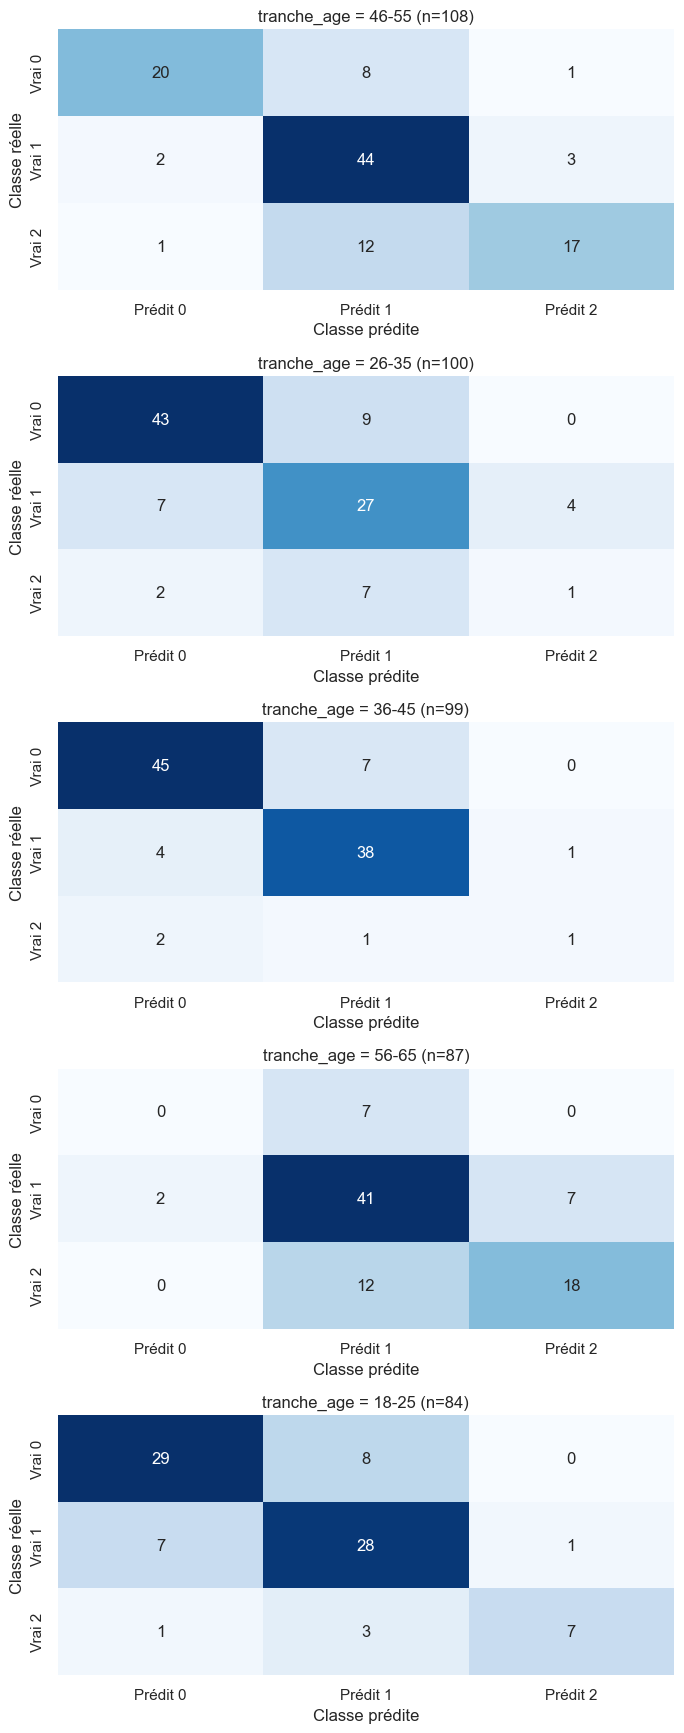

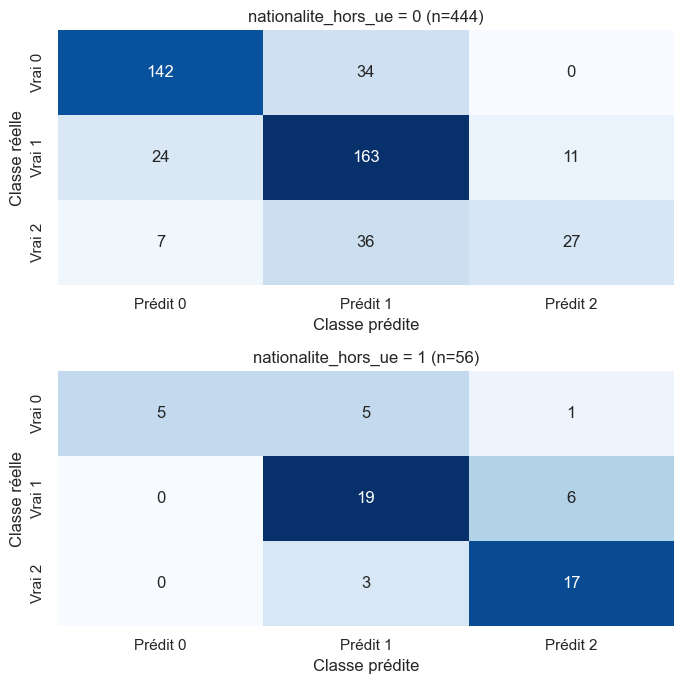

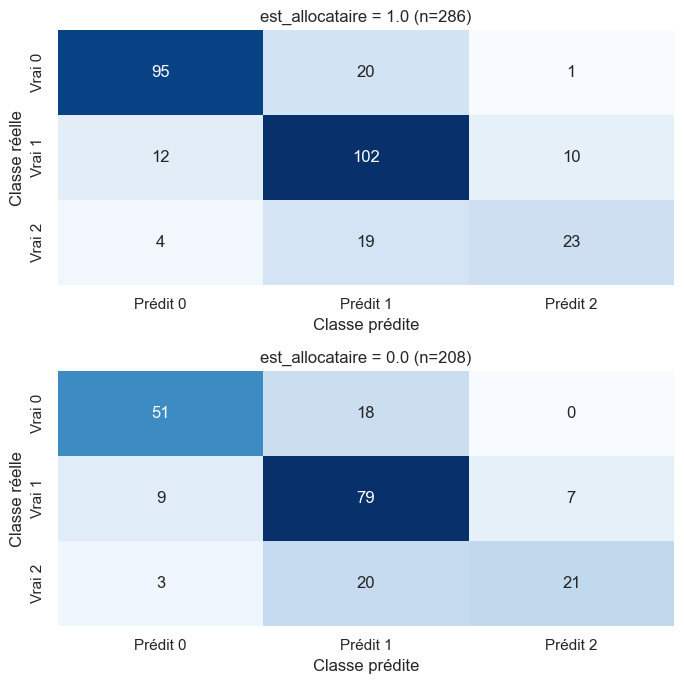

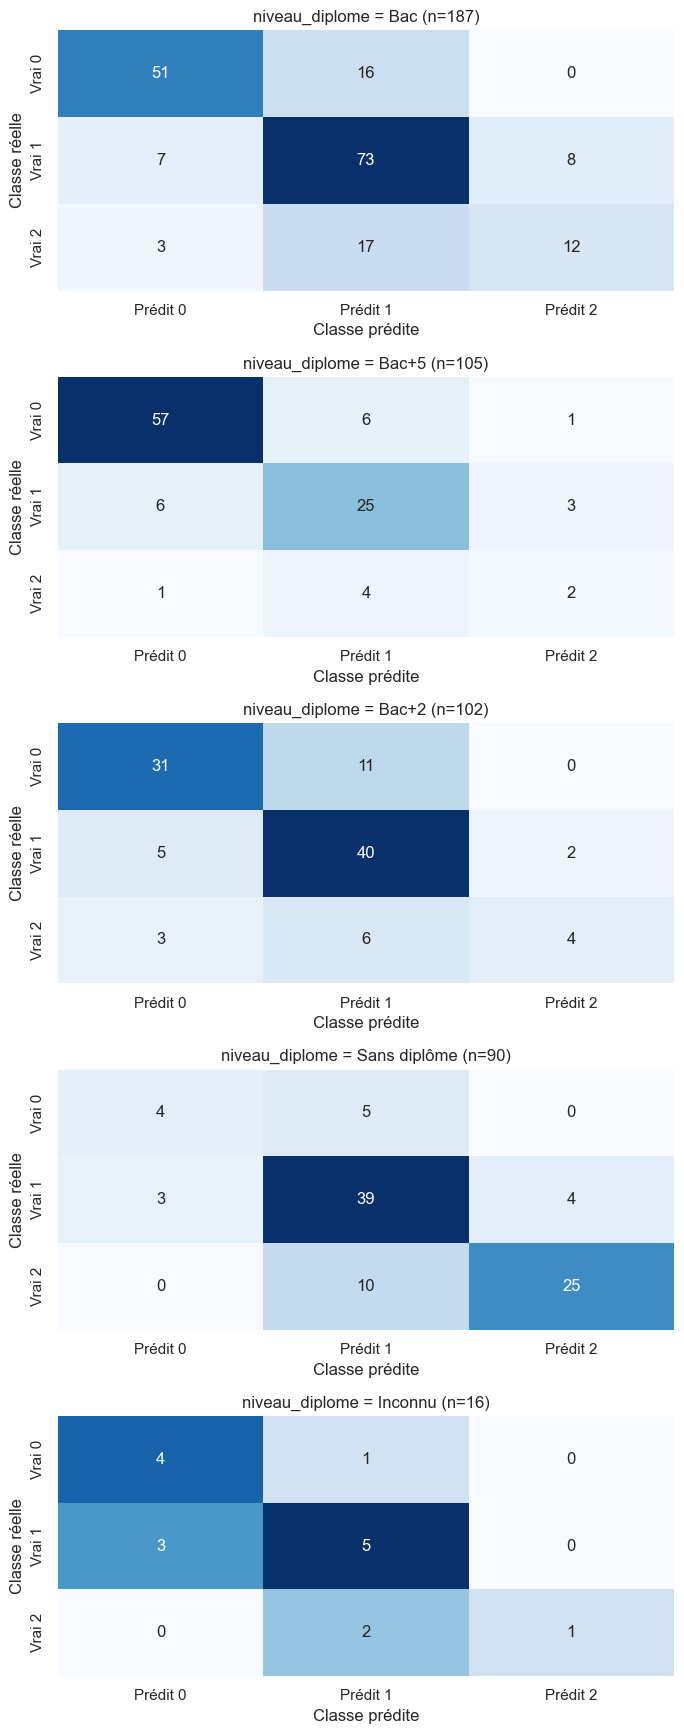

In [21]:
# 7.2 Analyse des erreurs et profils à escalader
# Matrice de confusion détaillée par profil
# Variables sensibles incluses : âge, nationalité hors UE, allocataire,
# niveau de diplôme et département.
# Prédictions du modèle retenu
pipeline_profil = pipeline_lgbm
y_pred_profil = pipeline_profil.predict(X_test)

# Copie des variables de profil
profils_test = X_test.copy()
profils_test["y_true"] = y_test
profils_test["y_pred"] = y_pred_profil

# Regroupement de l'âge pour éviter des groupes trop petits
profils_test["tranche_age"] = pd.cut(
    profils_test["age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
    include_lowest=True,
)

# Normalisation des variables sensibles
profils_test["nationalite_hors_ue"] = (
    profils_test["nationalite_hors_ue"]
    .fillna("Inconnu")
    .astype(str)
)

profils_test["est_allocataire"] = (
    profils_test["est_allocataire"]
    .fillna("Inconnu")
    .astype(str)
)

profils_test["niveau_diplome"] = (
    profils_test["niveau_diplome"]
    .fillna("Inconnu")
    .astype(str)
)

profils_test["departement"] = (
    profils_test["departement"]
    .fillna("Inconnu")
    .astype(str)
)


def matrice_par_profil(data, colonne_profil, labels=(0, 1, 2)):
    """Retourne les métriques et la matrice de confusion par profil."""

    resultats = []

    for profil, groupe in data.groupby(
        colonne_profil,
        dropna=False,
        observed=False,
    ):
        y_true_groupe = groupe["y_true"]
        y_pred_groupe = groupe["y_pred"]

        cm = confusion_matrix(
            y_true_groupe,
            y_pred_groupe,
            labels=labels,
        )

        resultats.append({
            "variable_profil": colonne_profil,
            "profil": str(profil),
            "effectif": len(groupe),
            "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
            "f1_macro": f1_score(
                y_true_groupe,
                y_pred_groupe,
                labels=list(labels),
                average="macro",
                zero_division=0,
            ),
            "recall_classe_2": recall_score(
                y_true_groupe,
                y_pred_groupe,
                labels=[2],
                average="macro",
                zero_division=0,
            ),
            "precision_classe_2": precision_score(
                y_true_groupe,
                y_pred_groupe,
                labels=[2],
                average="macro",
                zero_division=0,
            ),
            "erreur_critique_2_vers_0": (
                cm[2, 0] / cm[2].sum()
                if cm[2].sum() > 0
                else np.nan
            ),
            "vrai_0_predit_0": cm[0, 0],
            "vrai_0_predit_1": cm[0, 1],
            "vrai_0_predit_2": cm[0, 2],
            "vrai_1_predit_0": cm[1, 0],
            "vrai_1_predit_1": cm[1, 1],
            "vrai_1_predit_2": cm[1, 2],
            "vrai_2_predit_0": cm[2, 0],
            "vrai_2_predit_1": cm[2, 1],
            "vrai_2_predit_2": cm[2, 2],
        })

    return (
        pd.DataFrame(resultats)
        .sort_values(["variable_profil", "effectif"], ascending=[True, False])
        .reset_index(drop=True)
    )


variables_profil = [
    "tranche_age",
    "nationalite_hors_ue",
    "est_allocataire",
    "niveau_diplome",
    "departement",
]

resultats_profils = pd.concat(
    [
        matrice_par_profil(profils_test, variable)
        for variable in variables_profil
    ],
    ignore_index=True,
)

# Éviter d'interpréter des groupes trop petits
resultats_profils["profil_interpretable"] = (
    resultats_profils["effectif"] >= 10
)

display(
    resultats_profils[
        [
            "variable_profil",
            "profil",
            "effectif",
            "f1_macro",
            "recall_classe_2",
            "precision_classe_2",
            "erreur_critique_2_vers_0",
            "profil_interpretable",
        ]
    ].round(3)
)

def afficher_matrices_par_profil(data, colonne_profil, min_effectif=10):
    profils = (
        data[colonne_profil]
        .value_counts()
        .loc[lambda s: s >= min_effectif]
        .index
    )

    n = len(profils)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(7, max(4, 3.5 * n)),
    )

    axes = np.atleast_1d(axes)

    for ax, profil in zip(axes, profils):
        groupe = data[data[colonne_profil] == profil]

        cm = confusion_matrix(
            groupe["y_true"],
            groupe["y_pred"],
            labels=[0, 1, 2],
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["Prédit 0", "Prédit 1", "Prédit 2"],
            yticklabels=["Vrai 0", "Vrai 1", "Vrai 2"],
            ax=ax,
        )

        ax.set_title(
            f"{colonne_profil} = {profil} "
            f"(n={len(groupe)})"
        )
        ax.set_xlabel("Classe prédite")
        ax.set_ylabel("Classe réelle")

    plt.tight_layout()
    plt.show()


for variable in [
    "tranche_age",
    "nationalite_hors_ue",
    "est_allocataire",
    "niveau_diplome",
]:
    afficher_matrices_par_profil(profils_test, variable)

#### Observations

- Le modèle n’est pas homogène selon l’âge. Il semble sous-détecter les situations de retour long chez les 26–45 ans, particulièrement chez les 36–45 ans (attention effectif réduit donc résultat instable). Cela constitue un risque de discrimination indirecte ou de moindre qualité d’accompagnement pour cette tranche.
- La performance du modèle varie selon la nationalité. Le groupe `nationalite_hors_ue = 0` (donc de nationalité européenne) présente un rappel de la classe 2 faible et 7 erreurs critiques `2 → 0`. Le groupe hors UE présente un meilleur rappel de la classe 2, mais un effectif réduit et une mauvaise reconnaissance de la classe 0. Ces résultats doivent être interprétés avec prudence et faire l’objet d’une revue d’équité complémentaire.
- `est_allocataire` ne semble pas constituer ici le profil à risque principal. Le risque concernant l’erreur 2 → 0 reste limité et assez comparable entre les deux groupes.
- Le modèle semble donc mieux détecter les profils sans diplôme, mais sous-détecte les situations de retour long chez les personnes diplômées, particulièrement les Bac+2 et Bac+5. Cependant, encore une fois, pour ce profils les effectifs sont réduits dans le dataset.

### 7.3 Message au client (langage métier)

Le modèle peut aider les conseillers à repérer les situations nécessitant une attention particulière. Les variables utilisées apportent un signal utile, mais l’importance d’une variable ne signifie pas qu’elle est la cause du résultat.

**Message clé 1 : le modèle fournit un éclairage statistique, et non une explication certaine de la situation d’une personne.**

**Message clé 2 : les cas incertains ou potentiellement défavorables doivent être examinés attentivement par un conseiller.** Le système doit pouvoir s’abstenir lorsque sa confiance est insuffisante, notamment lorsque les probabilités des classes sont proches ou lorsqu’un retour rapide est prédit malgré des signaux de difficulté. Ces situations doivent être orientées vers une revue humaine renforcée.

**Message clé 3 : le modèle ne doit jamais décider seul de l’accompagnement proposé.** Dans ce contexte sensible, le conseiller conserve la responsabilité de la décision, peut contredire la recommandation et doit pouvoir justifier son choix. Les prédictions, les abstentions et les décisions doivent être suivies dans le temps afin de détecter d’éventuels biais ou une dégradation des performances.

### 7.4 Synthèse interprétation

L’analyse met en évidence trois points de vigilance pour l’utilisation du modèle :

- **Variables-clés :** `synthese_entretien`, `age` et `code_rome_vise` représentent 60% du pouvoir prédictif du modèle, rajouter `niveau_diplome` et `anciennete_poste_ans` et on atteind les 80%. Ces pourcentages indiquent les variables auxquelles le modèle s’est le plus référé dans les données, ils ne prouvent pas qu’elles sont la cause du résultat. Parmi ces variables seule `age` est une variable sensible qui influence le modèle. `nationalite_hors_ue`, `departement` et `est_allocataire` peuvent également contribuer aux prédictions ou servir de relais à des inégalités déjà présentes dans les données. Leur influence doit donc être contrôlée, même lorsqu’elle est moins élevée.

- **Profils mal prédits :** le modèle semble sous-détecter certaines situations de retour à l’emploi long chez les 26–45 ans, notamment les 36–45 ans, ainsi que chez certains profils diplômés, en particulier Bac+2 et Bac+5. Les écarts observés pour la nationalité et le diplôme doivent aussi être surveillés. Ces constats ne suffisent pas, à eux seuls, à démontrer une discrimination : les effectifs de certains groupes sont faibles et les résultats doivent être confirmés sur des données indépendantes, avec des intervalles de confiance.

- **Vigilance opérationnelle :** une prédiction de classe 0 accompagnée d’une probabilité non négligeable de classe 2, une faible confiance ou une forte proximité entre les probabilités doivent déclencher une revue humaine renforcée. Les taux d’abstention, le rappel de la classe 2, les erreurs critiques `2 → 0` et les écarts entre groupes doivent être suivis régulièrement. Chaque recommandation, alerte, abstention, décision du conseiller et éventuelle contestation doivent être journalisées.

En pratique, le modèle peut accélérer le tri des dossiers, mais il ne doit jamais réduire l’examen humain ni l’accès à une révision. Toute dérive des performances ou aggravation d’un écart entre profils doit conduire à une analyse, à une réévaluation des seuils ou, si nécessaire, à la suspension du modèle.

### 7.5 Conclusion sur les scénarios avant l'industrialisation

#### Lecture comparative des scénarios

Le scénario 1, qui conserve les variables tabulaires et le texte, obtient le meilleur compromis global avec un F1-macro de 0,713. Il exploite notamment l’information contenue dans `synthese_entretien`, qui représente environ 30 % de l’importance agrégée du modèle, ainsi que les variables liées au profil et au parcours.

Le scénario 2, sans variables sensibles, permet de réduire directement certains risques de discrimination, mais ses performances sont moins favorables, notamment pour la détection de la classe 2. Cela montre que les variables retirées contiennent un signal prédictif, mais ne justifie pas à lui seul leur utilisation en production.

Le scénario 3, fondé uniquement sur `synthese_entretien`, obtient des résultats intéressants, mais ils doivent être interprétés avec prudence car les textes sont très redondants et peu nombreux. Le risque de surapprentissage est donc important.

Le scénario 4, fondé uniquement sur les données tabulaires, montre que le texte n’améliore pas nécessairement toutes les métriques dans la configuration testée. Il constitue une alternative plus simple à auditer, mais conserve les risques liés aux variables sensibles et aux variables proxy.

Ces résultats restent indicatifs, car les scénarios n’ont pas tous été évalués avec exactement le même modèle, le même niveau de réglage et le même protocole final de test. Une comparaison définitive nécessiterait de réévaluer chaque scénario dans des conditions identiques.

---
## 8. Industrialisation



### 8.1 Pré-requis

Pour etre exécuté l'industrialisation nécessite l'utilisation du repository github : https://github.com/rbatos/Cas_usage_certif/tree/main

### 8.2 Persistance et versionnement du modèle

#### 8.2.1 Modèle initial et modèle actif

L’artefact initial retenu est le pipeline LightGBM du scénario `S1_multimodale_complete` :

```text
models/modele_lgbm_v1.0_S1_multimodale_complete.joblib
```

Il contient le prétraitement complet et le classifieur. Le fichier `v1.0` constitue la version initiale et reste conservé comme référence immuable. Il est décrit par son fichier de métadonnées :

```text
models/modele_lgbm_v1.0_S1_multimodale_complete_metadata.json
```

Après une promotion par `POST /train`, l’API ne remplace pas cet artefact. Elle crée une nouvelle version, par exemple `v1.1`, avec ses propres metadata, puis met à jour le manifeste :

```text
models/model_manifest.json
```

Le manifeste identifie le modèle actif avec :

- La version locale de l’artefact (`1.0`, `1.1`, etc.).
- Le chemin du fichier `.joblib`.
- Le chemin du fichier de métadonnées.
- Le hash SHA-256 de l’artefact.
- La version correspondante dans MLflow lorsqu’elle existe.


Exemple de manifeste :

```json
{
  "model_version": "1.1",
  "model_path": "modele_lgbm_v1.1_S1_multimodale_complete.joblib",
  "metadata_path": "modele_lgbm_v1.1_S1_multimodale_complete_metadata.json",
  "sha256": "...",
  "mlflow_model_version": "18"
}
```

Au démarrage, le `lifespan` lit ce manifeste, vérifie l’intégrité du fichier avec le hash SHA-256, puis charge le pipeline actif avec `joblib.load()`. Le pipeline reste ensuite en mémoire pour les inférences. Si le manifeste, l’artefact ou son hash sont invalides, l’API applique sa politique fail-fast et le conteneur s’arrête.


#### 8.2.2 Stratégie de persistance et création d’une version

La persistance repose sur `joblib`, adapté à la sauvegarde des pipelines scikit-learn et LightGBM :

- Le pipeline entraîné est sauvegardé comme artefact `.joblib` dans `models/`.
- Le prétraitement et le modèle sont sauvegardés ensemble afin de garantir la même transformation entre entraînement et prédiction.
- Chaque promotion produit un nom de fichier versionné (`v1.1`, `v1.2`, etc.).
- Les versions précédentes ne sont pas écrasées et restent disponibles pour un rollback.
- Un fichier de métadonnées est produit pour chaque version promue.
- Le manifeste est mis à jour uniquement après l’écriture complète de l’artefact et de ses métadonnées.


La route `POST /train` suit le cycle suivant :

1. Elle recharge le dataset et les corrections conseillers.
2. Elle entraîne un modèle de validation et compare son `f1_macro` à la baseline.
3. Si le modèle est rejeté, aucun artefact actif ni manifeste ne change.
4. Si le modèle est promu, elle le réentraîne sur toutes les données.
5. Elle calcule la prochaine version locale, par exemple `1.1` après `1.0`.
6. Elle sauvegarde le nouveau pipeline, ses métadonnées et son hash.
7. Elle met à jour le manifeste et remplace le pipeline conservé en mémoire.


La réponse de `POST /train` distingue désormais :

- `model_version` : version du modèle dans MLflow.
- `artifact_version` : version locale immuable de l’artefact servi.
- `model_path` : chemin de l’artefact effectivement promu.


Le modèle rejeté reste tracé dans MLflow, mais il ne modifie ni l’artefact actif, ni le manifeste, ni le pipeline utilisé pour les prédictions.


#### 8.2.3 Traçabilité des expériences et correspondance MLflow

MLflow complète la persistance locale Joblib et le manifeste. Chaque appel à `POST /train`, accepté ou rejeté, crée un run contenant notamment :

- Les hyperparamètres du classifieur.
- Les métriques de validation (`accuracy`, `f1_macro`).
- La baseline utilisée et la tolérance de dégradation.
- Le nombre de lignes d’entraînement et de feedbacks intégrés.
- Le statut de promotion (`promoted` ou `rejected`).


Lorsqu’un modèle est promu :

- L’artefact est enregistré dans MLflow.
- Une nouvelle version est créée dans le Model Registry.
- L’alias `champion` est déplacé vers cette version.
- La version MLflow est recopiée dans `model_manifest.json`.
- La version locale du fichier `.joblib` reste la référence effectivement chargée par l’API.


MLflow constitue donc l’historique et le registre des versions, tandis que le manifeste constitue la référence opérationnelle locale du modèle actif. L’API ne télécharge pas automatiquement l’alias `champion` au démarrage : elle charge le fichier indiqué par le manifeste et vérifie son hash. Cette séparation permet de conserver la compatibilité avec le déploiement Docker actuel tout en assurant la traçabilité et le rollback.


Les modèles comparés hors production restent conservés séparément : LightGBM, régression logistique et Random Forest. Le fichier `models/registre_modeles_sauvegardes.csv` recense les artefacts produits par le notebook, tandis que les versions promues par l’API sont suivies par le manifeste et MLflow.

#### 8.2.4 Interface MLflow

L'interface MLflow est accessible localement à l'adresse `http://localhost:5000/`. Elle permet de consulter les runs d'entraînement, leurs métriques, leurs paramètres, les artefacts associés et les versions enregistrées dans le Model Registry.

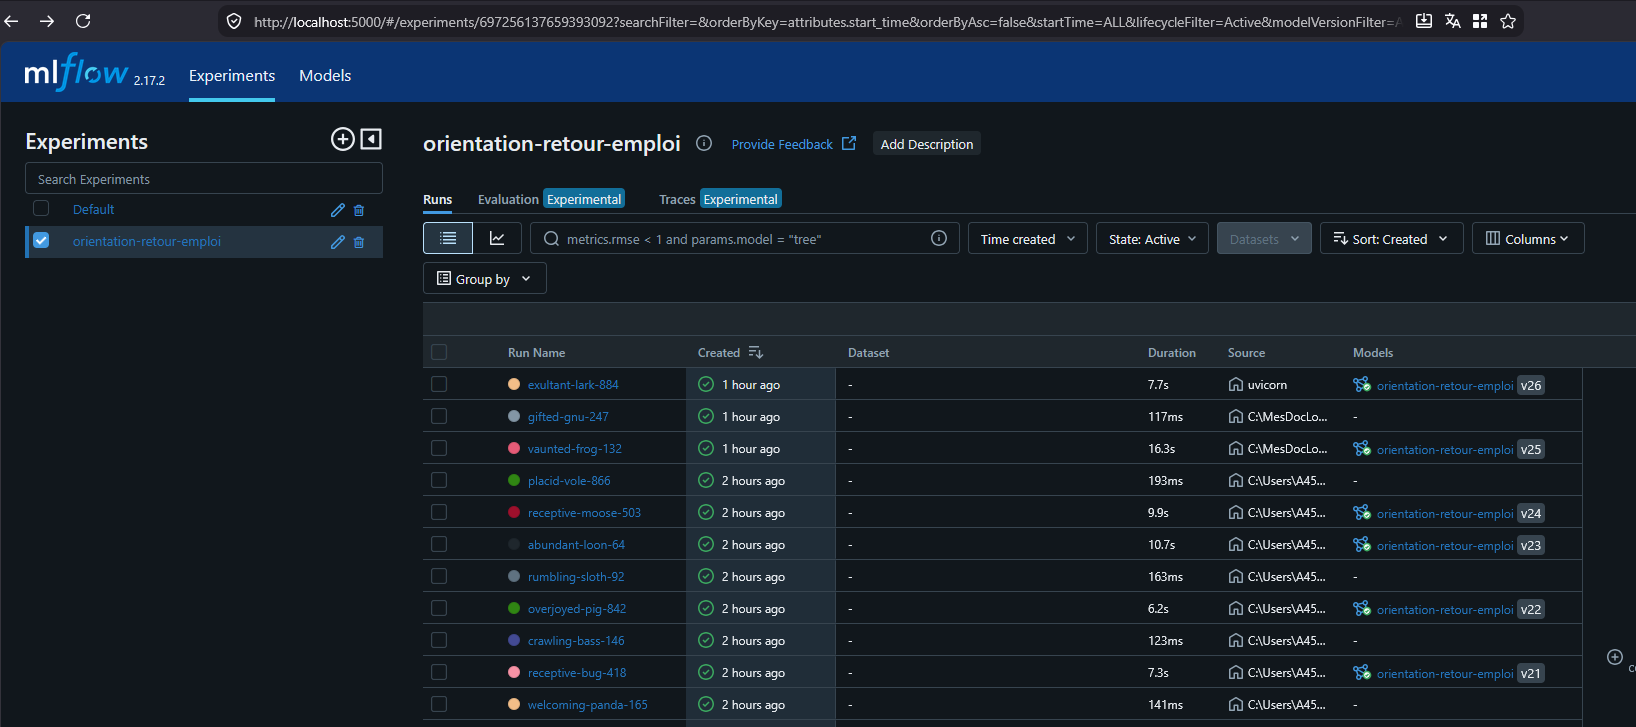

### 8.3 API de service

> **Dépôt associé** : [Cas_usage_certif](https://github.com/rbatos/Cas_usage_certif/tree/main) — dossier `Cas_usage_certif/app/`

L’API expose le pipeline LightGBM sauvegardé avec son prétraitement. Elle transforme le payload entrant au format attendu par le modèle, notamment par l’extraction du département depuis le code INSEE, effectue la prédiction et renvoie les probabilités des trois classes. Au démarrage de l’API, le `lifespan` charge le pipeline avec `joblib.load()`, puis celui-ci est conservé en mémoire afin d’éviter de relire l’artefact à chaque requête.

#### Architecture du flux

```text
UI Streamlit — interface conseiller
    │
    ├── GET /health
    │       └── affichage de l’état de l’API et de la version du modèle
    │
    ├── POST /predict
    │       ├── saisie du dossier demandeur
    │       ├── validation Pydantic
    │       ├── prédiction
    │       ├── affichage de la classe et des probabilités
    │       └── écriture dans historique_inferences.csv
    │
    ├── POST /feedback
    │       ├── formulaire de correction conseiller
    │       ├── validation Pydantic
    │       ├── ajout dans feedback_conseillers.csv
    │       └── confirmation affichée dans l’UI
    │
    ├── POST /train
    │       ├── clic sur « Lancer le réentraînement »
    │       ├── lecture du dataset CSV
    │       ├── fusion des feedbacks conseillers
    │       ├── entraînement et comparaison à la baseline
    │       │
    │       ├── modèle rejeté
    │       │       ├── run MLflow enregistré comme rejected
    │       │       ├── modèle actif inchangé
    │       │       └── résultat affiché dans l’UI
    │       │
    │       └── modèle accepté
    │               ├── création d’une nouvelle version
    │               ├── sauvegarde Joblib + métadonnées + hash
    │               ├── mise à jour du manifeste
    │               ├── mise à jour MLflow et alias champion
    │               ├── remplacement du pipeline actif en mémoire
    │               └── statut, métriques et version affichés dans l’UI
    │
    └── GET /history
            ├── clic sur « Charger l’historique »
            ├── filtrage conseiller_id + limit
            └── affichage dans l’UI
```

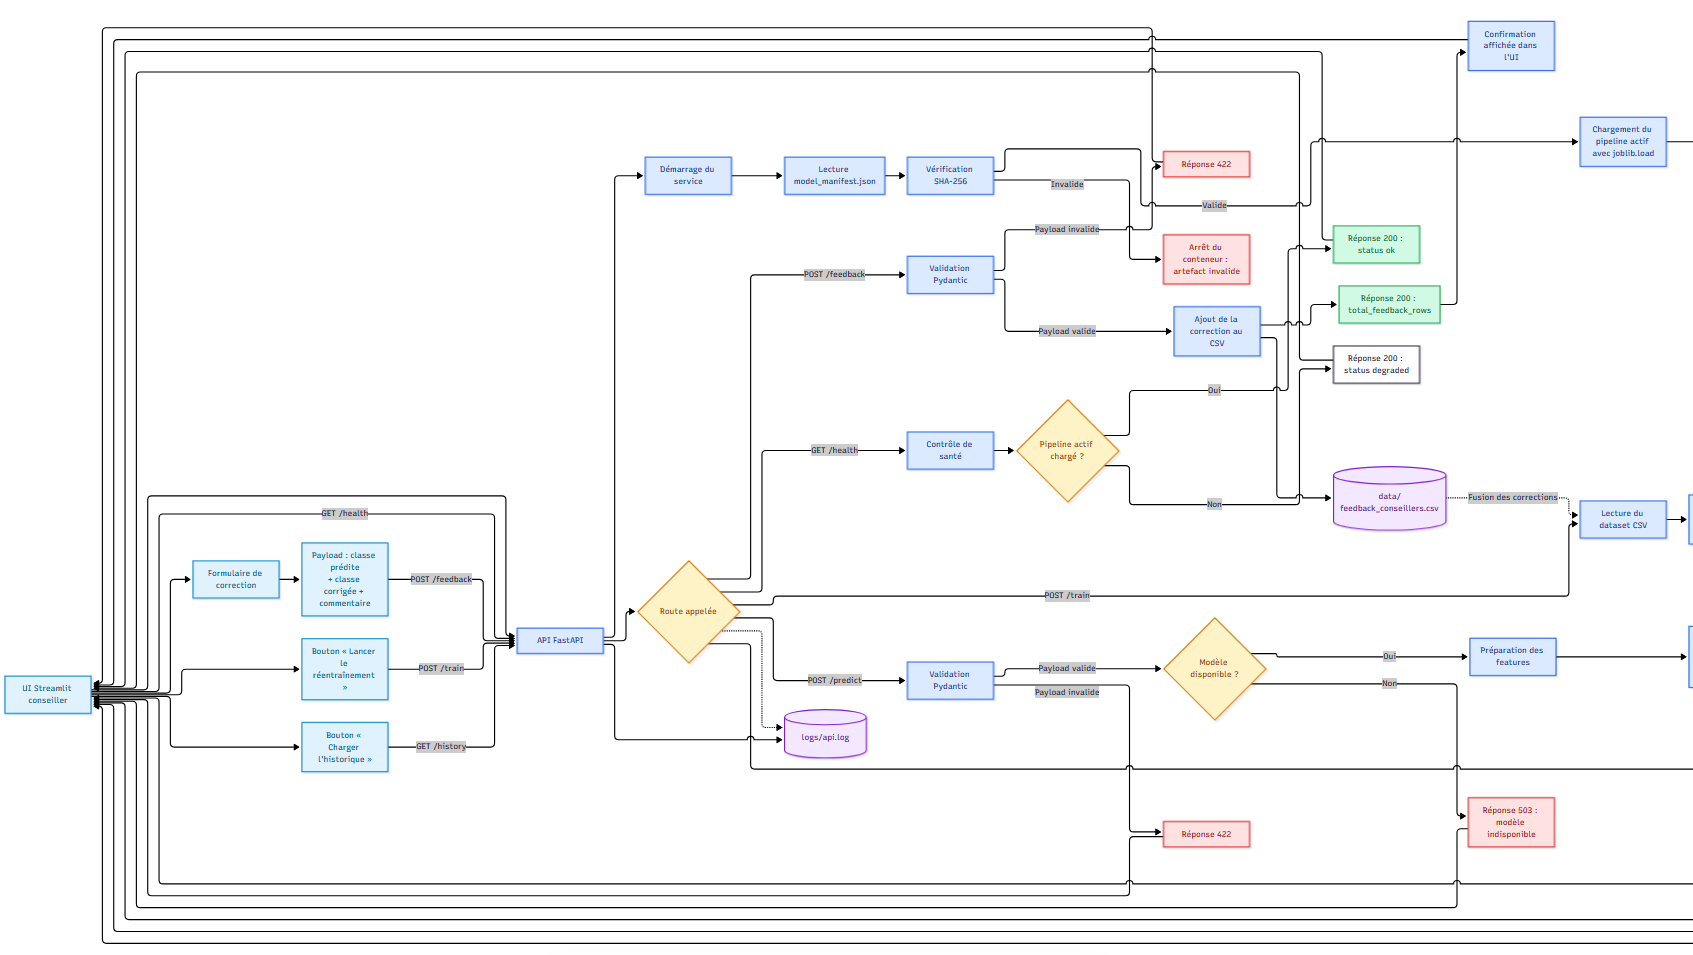
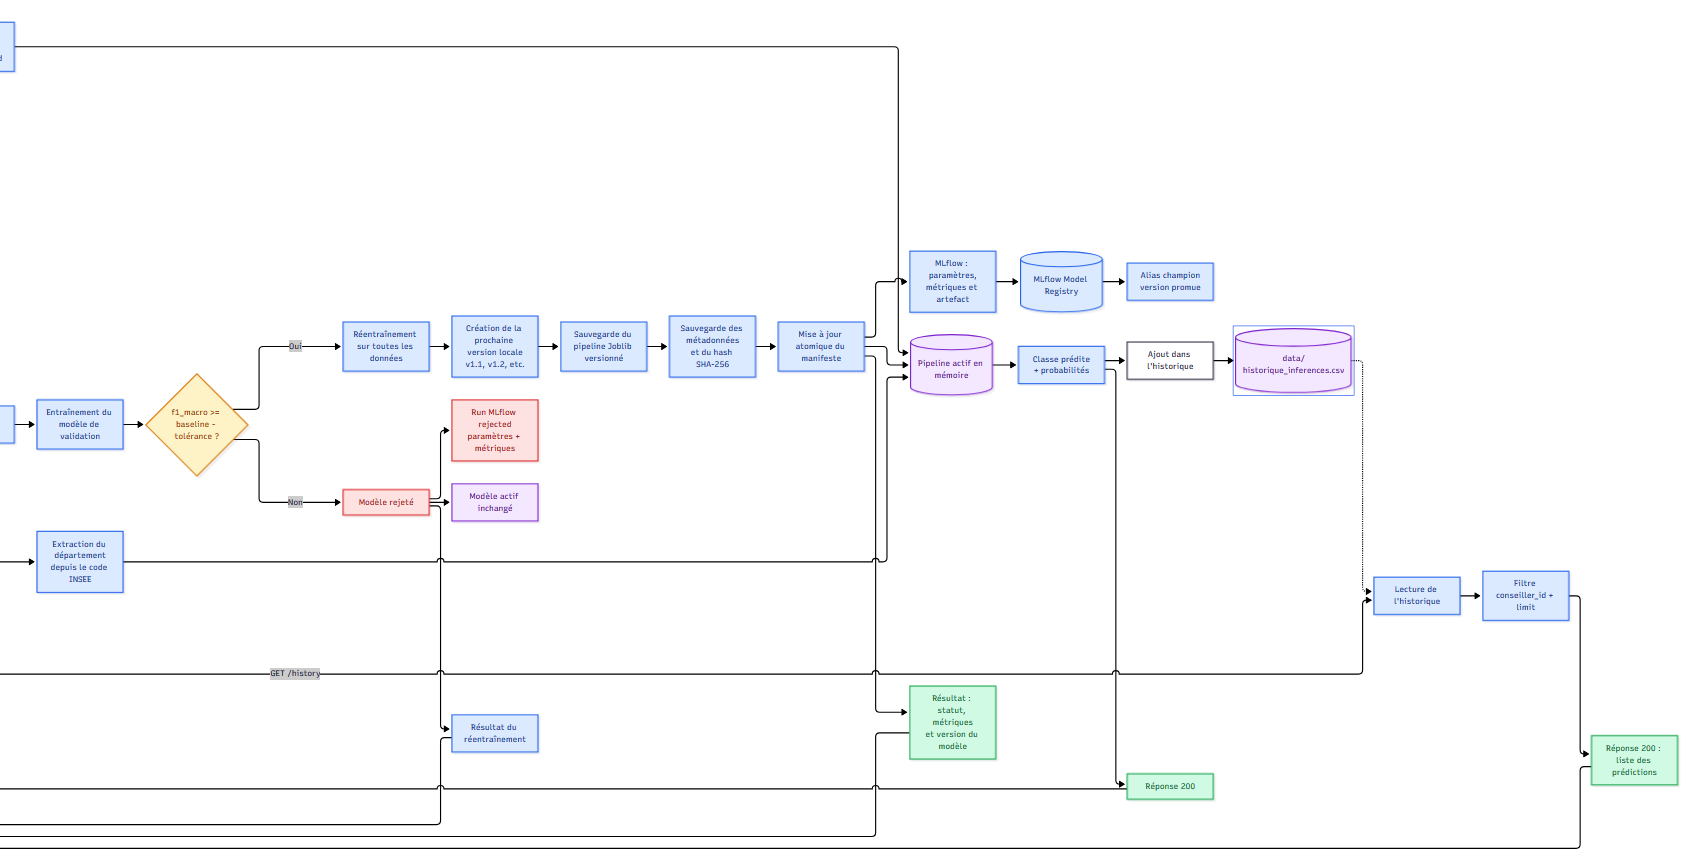

- 🟢 **Vert** : réponses nominales `200` (`/health`, `/predict`, `/feedback`, `/train` et `/history`).
- 🔴 **Rouge** : erreurs fonctionnelles ou techniques (`422`, `503` et rejet de promotion).
- 🔵 **Bleu** : étapes de traitement de l'API et du pipeline de données.
- 🟡 **Jaune** : routes ou contrôles conditionnels qui orientent le flux.

Cf voir [flux_donnees.md](../TMP/flux_donnees.md)

Finalement je mets aussi le code ici car j'ai du diviser en 2 l'image pour que ça soit lisible :
```mermaid
flowchart LR
    UI[UI Streamlit conseiller] --> API[API FastAPI]

    UI --> FeedbackForm[Formulaire de correction]
    FeedbackForm --> FeedbackPayload[Payload : classe prédite<br/>+ classe corrigée + commentaire]
    FeedbackPayload -->|POST /feedback| API

    UI --> TrainButton[Bouton « Lancer le réentraînement »]
    TrainButton -->|POST /train| API

    UI --> HistoryButton[Bouton « Charger l'historique »]
    HistoryButton -->|GET /history| API

    UI -->|GET /health| API

    API --> Route{Route appelée}

    API --> Startup[Démarrage du service]
    Startup --> Manifest[Lecture model_manifest.json]
    Manifest --> Hash[Vérification SHA-256]
    Hash -->|Valide| Load[Chargement du pipeline actif avec joblib.load]
    Hash -->|Invalide| StartupError[Arrêt du conteneur : artefact invalide]
    Load --> ActiveModel[(Pipeline actif en mémoire)]

    Route -->|GET /health| Health[Contrôle de santé]
    Health --> HealthModel{Pipeline actif chargé ?}
    HealthModel -->|Oui| HealthOK[Réponse 200 : status ok]
    HealthModel -->|Non| HealthKO[Réponse 200 : status degraded]
    HealthOK --> UI
    HealthKO --> UI

    Route -->|POST /predict| PredictionValidation[Validation Pydantic]
    PredictionValidation -->|Payload invalide| Error422[Réponse 422]
    PredictionValidation -->|Payload valide| ModelCheck{Modèle disponible ?}
    ModelCheck -->|Non| Error503[Réponse 503 : modèle indisponible]
    ModelCheck -->|Oui| Preparation[Préparation des features]
    Preparation --> Features[Extraction du département<br/>depuis le code INSEE]
    Features --> ActiveModel
    ActiveModel --> Prediction[Classe prédite<br/>+ probabilités]
    Prediction --> PredictionResponse[Réponse 200]
    PredictionResponse --> UI
    Prediction --> HistoryAppend[Ajout dans l'historique]
    HistoryAppend --> HistoryCSV[(data/historique_inferences.csv)]
    Error422 --> UI
    Error503 --> UI

    Route -->|POST /feedback| FeedbackValidation[Validation Pydantic]
    FeedbackValidation -->|Payload invalide| FeedbackError422[Réponse 422]
    FeedbackValidation -->|Payload valide| FeedbackAppend[Ajout de la correction au CSV]
    FeedbackAppend --> FeedbackCSV[(data/feedback_conseillers.csv)]
    FeedbackAppend --> FeedbackOK[Réponse 200 : total_feedback_rows]
    FeedbackOK --> FeedbackResponse[Confirmation affichée dans l'UI]
    FeedbackResponse --> UI
    FeedbackError422 --> UI

    Route -->|POST /train| Dataset[Lecture du dataset CSV]
    FeedbackCSV -.->|Fusion des corrections| Dataset
    Dataset --> Training[Entraînement du modèle de validation]
    Training --> Compare{f1_macro >= baseline - tolérance ?}

    Compare -->|Non| TrainRejected[Modèle rejeté]
    TrainRejected --> MLflowRejected[Run MLflow rejected<br/>paramètres + métriques]
    TrainRejected --> ActiveUnchanged[Modèle actif inchangé]
    TrainRejected --> TrainRejectedResponse[Résultat du réentraînement]
    TrainRejectedResponse --> UI

    Compare -->|Oui| Retrain[Réentraînement sur toutes les données]
    Retrain --> ModelVersion[Création de la prochaine version locale<br/>v1.1, v1.2, etc.]
    ModelVersion --> Save[Sauvegarde du pipeline Joblib versionné]
    Save --> Metadata[Sauvegarde des métadonnées<br/>et du hash SHA-256]
    Metadata --> ManifestUpdate[Mise à jour atomique du manifeste]
    ManifestUpdate --> ActiveModel
    ManifestUpdate --> MLflowRun[MLflow : paramètres,<br/>métriques et artefact]
    MLflowRun --> Registry[(MLflow Model Registry)]
    Registry --> Champion[Alias champion<br/>version promue]
    ManifestUpdate --> TrainAcceptedResponse[Résultat : statut, métriques<br/>et version du modèle]
    TrainAcceptedResponse --> UI

    Route -->|GET /history| HistoryRead[Lecture de l'historique]
    HistoryCSV -.-> HistoryRead
    HistoryRead --> HistoryFilter[Filtre conseiller_id + limit]
    HistoryFilter --> HistoryOK[Réponse 200 : liste des prédictions]
    HistoryOK --> UI

    API -.-> Logs[(logs/api.log)]
    Route -.-> Logs

    classDef ok fill:#d1fae5,stroke:#16a34a,stroke-width:2px,color:#166534
    classDef error fill:#fee2e2,stroke:#dc2626,stroke-width:2px,color:#991b1b
    classDef process fill:#dbeafe,stroke:#2563eb,stroke-width:2px,color:#1e3a8a
    classDef decision fill:#fef3c7,stroke:#d97706,stroke-width:2px,color:#92400e
    classDef store fill:#f3e8ff,stroke:#7e22ce,stroke-width:2px,color:#581c87
    classDef client fill:#e0f2fe,stroke:#0284c7,stroke-width:2px,color:#075985

    class UI,FeedbackForm,FeedbackPayload,TrainButton,HistoryButton client
    class API,Startup,Manifest,Hash,Load,PredictionValidation,Preparation,Features,Prediction,PredictionResponse,Health,FeedbackValidation,FeedbackAppend,FeedbackResponse,Dataset,Training,Retrain,ModelVersion,Save,Metadata,ManifestUpdate,MLflowRun,Registry,Champion,HistoryRead,HistoryFilter,TrainRejectedResponse,TrainAcceptedResponse process
    class Route,HealthModel,ModelCheck,Compare decision
    class HealthOK,PredictionResponse,FeedbackOK,HistoryOK,TrainAcceptedResponse ok
    class Error422,Error503,FeedbackError422,TrainRejected,StartupError,MLflowRejected error
    class ActiveModel,ActiveUnchanged,HistoryCSV,FeedbackCSV,Logs store
```

Le pipeline servi est le scénario `S1_multimodale_complete` : variables numériques, catégorielles, diplôme ordinal et texte d'entretien vectorisé par TF-IDF. L'artefact contient le prétraitement et le classifieur afin de garantir la même transformation entre entraînement et inférence.

#### Contrat des routes

| Route | Méthode | Rôle | Réponse nominale | Erreurs principales |
|---|---|---|---|---|
| `/health` | `GET` | Vérifier que l’API répond et que le pipeline actif, désigné par `model_manifest.json`, est chargé et intègre | `200` avec `status`, `model_loaded` et `model_version` | `status="degraded"` si le modèle est absent, invalide ou impossible à charger |
| `/predict` | `POST` | Prédire le délai de retour à l'emploi pour un demandeur | `200` avec classe `bas/moyen/long` et probabilités | `422` si le payload est invalide, `503` si le modèle actif est indisponible |
| `/feedback` | `POST` | Enregistrer la correction d’un conseiller pour le prochain réentraînement | `200` avec statut et nombre total de corrections stockées | `422` si le payload est invalide |
| `/train` | `POST` | Réentraîner le pipeline, intégrer les feedbacks, comparer le modèle à la baseline et tracer l’entraînement avec MLflow | `200` avec statut (`trained`/`rejected`), métriques, décision de promotion, `model_path`, `artifact_version`, `mlflow_run_id` et `model_version` si le modèle est promu | `404` si le dataset manque, `422` si l’entraînement ou le suivi MLflow échoue |
| `/history` | `GET` | Consulter l’historique persistant des prédictions, filtrable par conseiller et limité par `limit` | `200` avec la liste des prédictions passées, la plus récente en premier | Liste vide si aucun historique n’existe encore |

La documentation interactive est disponible via `/docs` (Swagger UI) et `/redoc` (ReDoc).

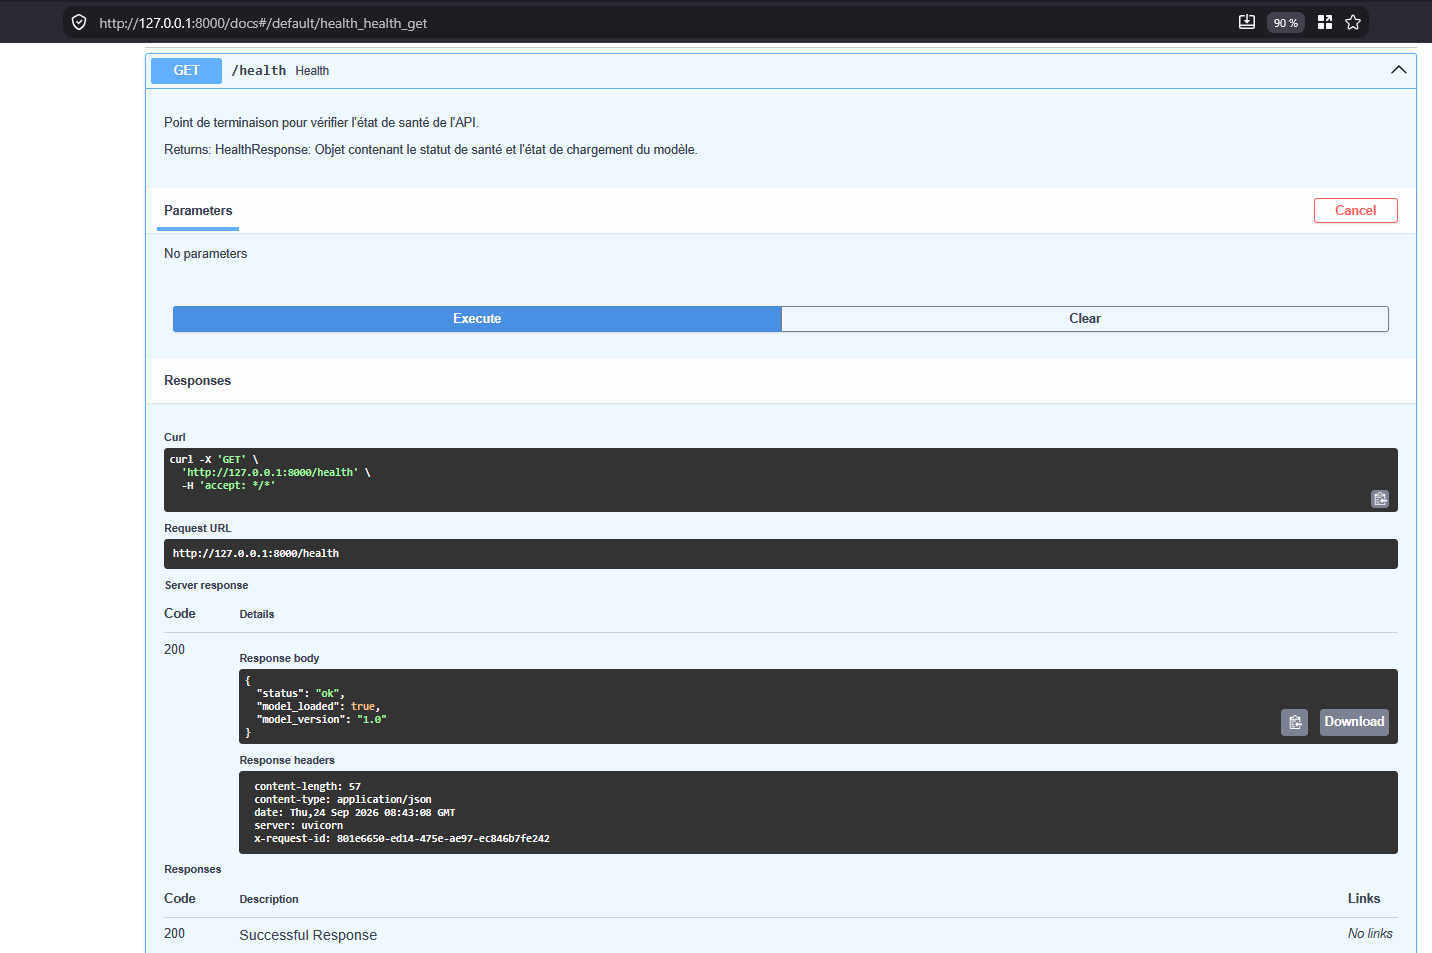

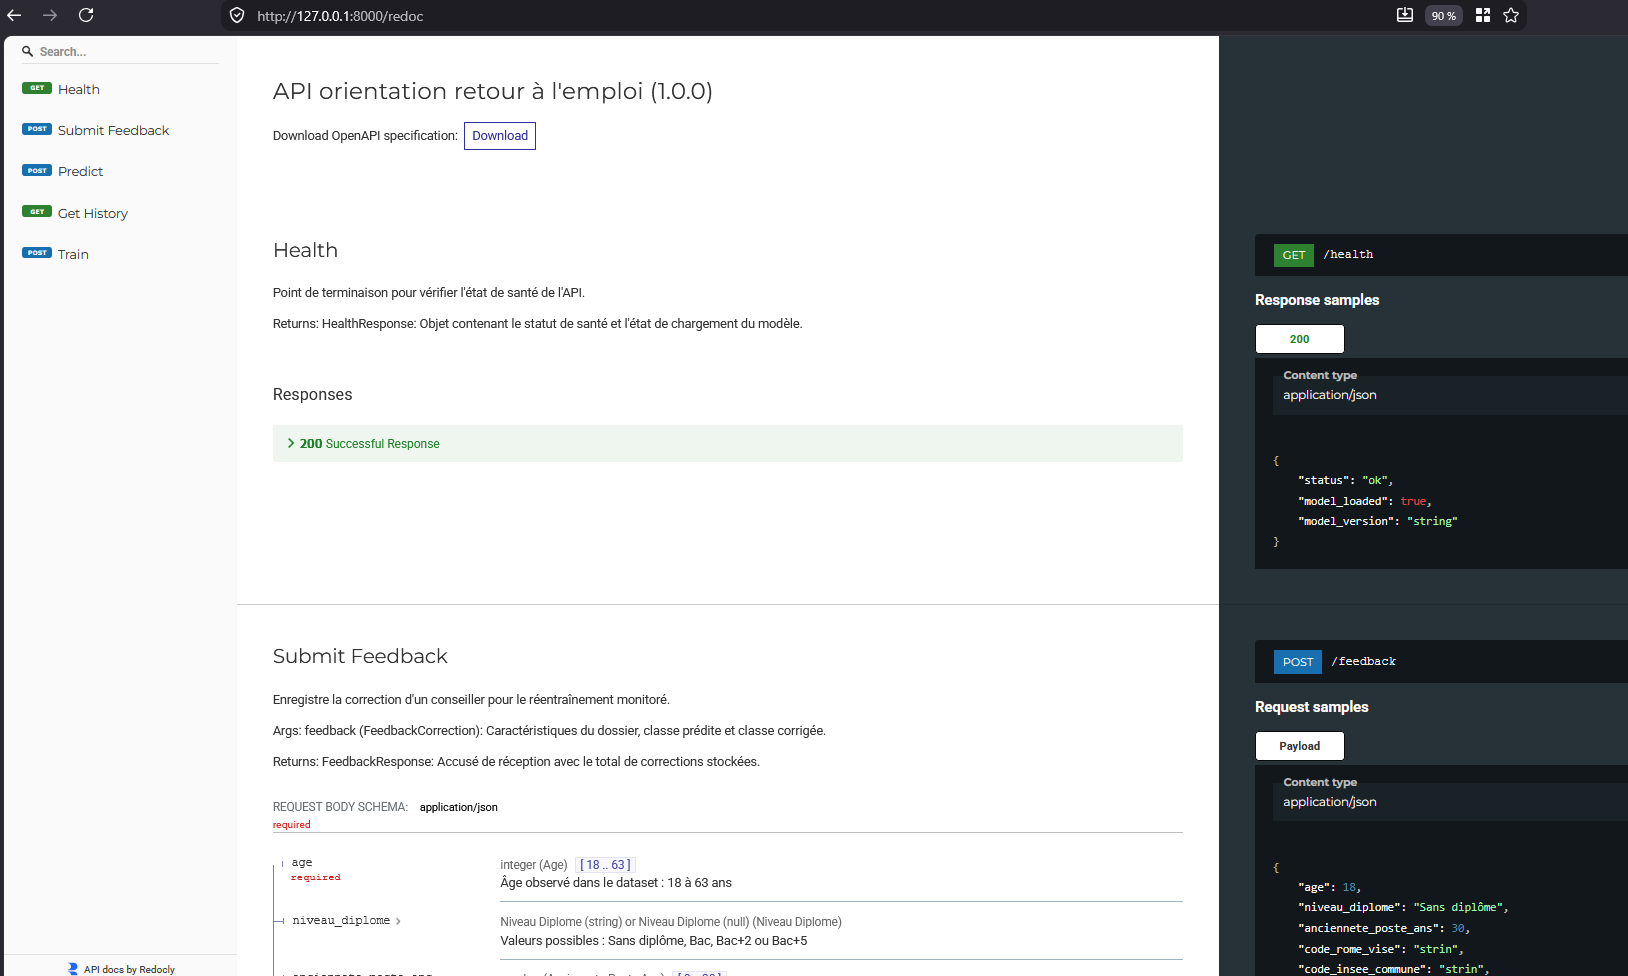

#### Exemple `POST /predict`

Payload accepté :

```json
{
  "age": 35,
  "niveau_diplome": "Bac+2",
  "anciennete_poste_ans": 10,
  "code_rome_vise": "A1101",
  "code_insee_commune": "75056",
  "est_allocataire": "1",
  "nationalite_hors_ue": "0",
  "synthese_entretien": "Expérience en gestion de projet."
}
```

Réponse nominale :

```json
{
  "retour_emploi": "moyen",
  "probabilites": {
    "bas": 0.1,
    "moyen": 0.7,
    "long": 0.2
  }
}
```

Le champ `retour_emploi` est une recommandation statistique et non une décision automatique. Les probabilités sont retournées afin que le conseiller puisse apprécier l'incertitude du modèle.

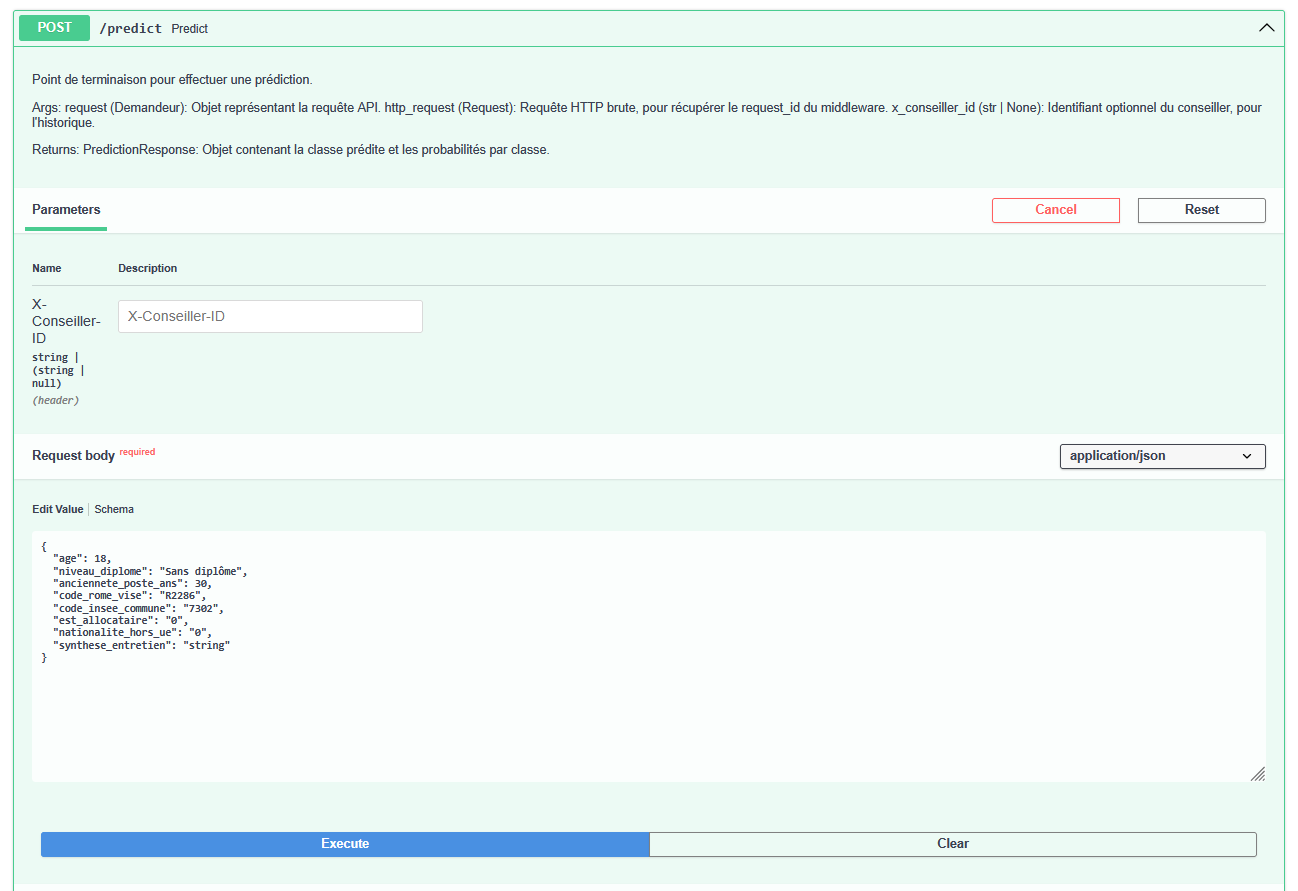
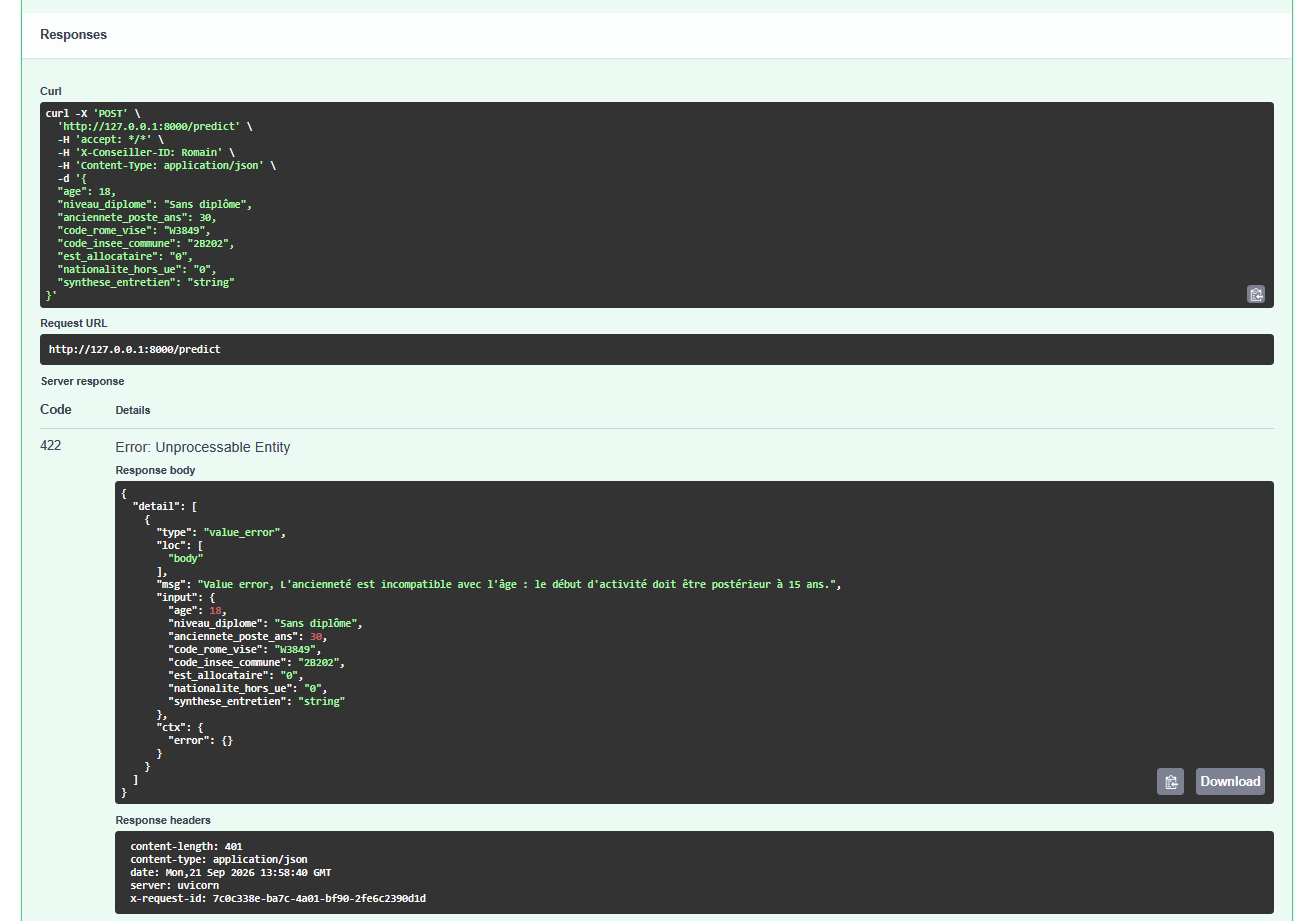

#### Validation et garde-fous

- Les champs inconnus sont refusés (`extra="forbid"`).
- Les bornes métier sont contrôlées : âge de 18 à 63 ans, ancienneté de 0 à 30 ans, code ROME au format attendu et code INSEE sur 4 ou 5 caractères.
- `niveau_diplome` peut être absent, les autres champs requis doivent être fournis.
- Une incohérence entre l'âge et l'ancienneté est rejetée lorsque le début d'activité ne serait pas postérieur à 15 ans.
- Les erreurs de validation sont renvoyées en `422` par FastAPI, sans lancer de prédiction.
- Chaque requête reçoit un `X-Request-ID` propagé dans la réponse et les logs, cela permet de relier une prédiction, une erreur et son temps de trai,ment.

#### Exemple de contrôle d'erreur

Une requête contenant `age=35` et `anciennete_poste_ans=25` est rejetée avec le statut `422`, car l'ancienneté est incompatible avec l'âge. Une requête valide peut aussi recevoir `503` si l'artefact du modèle est absent ou impossible à charger.

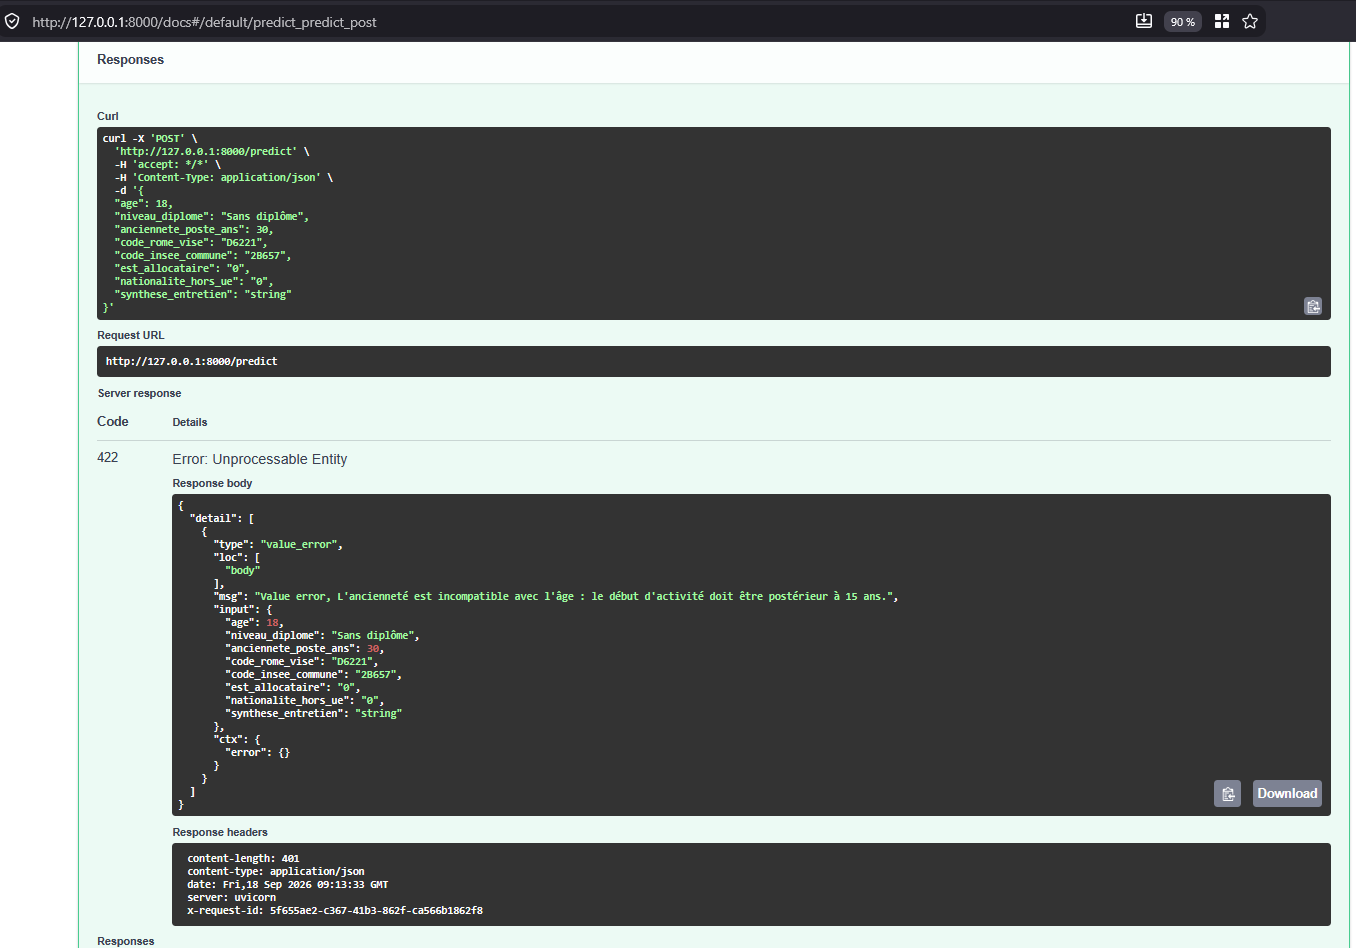

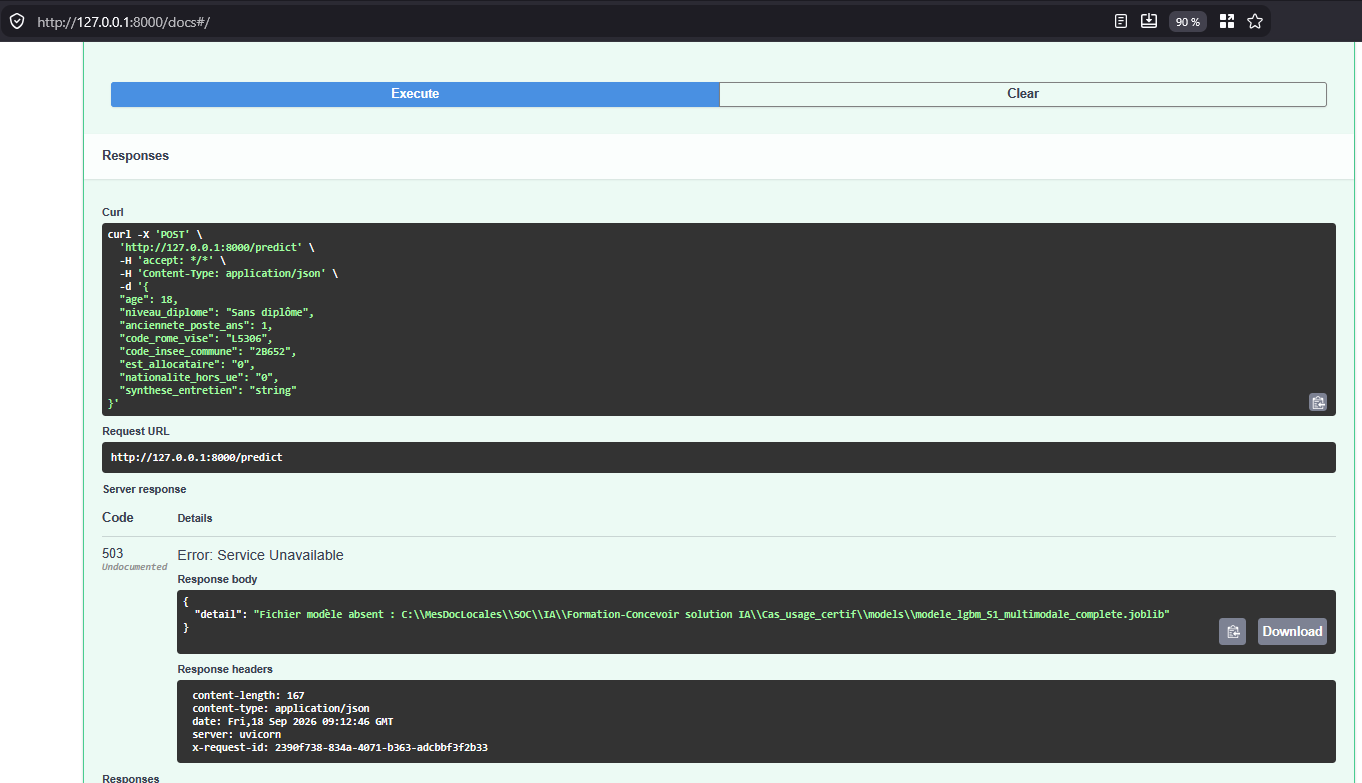

#### Feedback conseiller et réentraînement monitoré

##### Feedback conseiller

`POST /feedback` permet au conseiller d’enregistrer une correction depuis l’interface Streamlit après une prédiction. Le payload reprend les caractéristiques du dossier, la classe initialement prédite, la classe corrigée et un commentaire facultatif. Chaque correction est ajoutée à `data/feedback_conseillers.csv` sans écraser les précédentes.

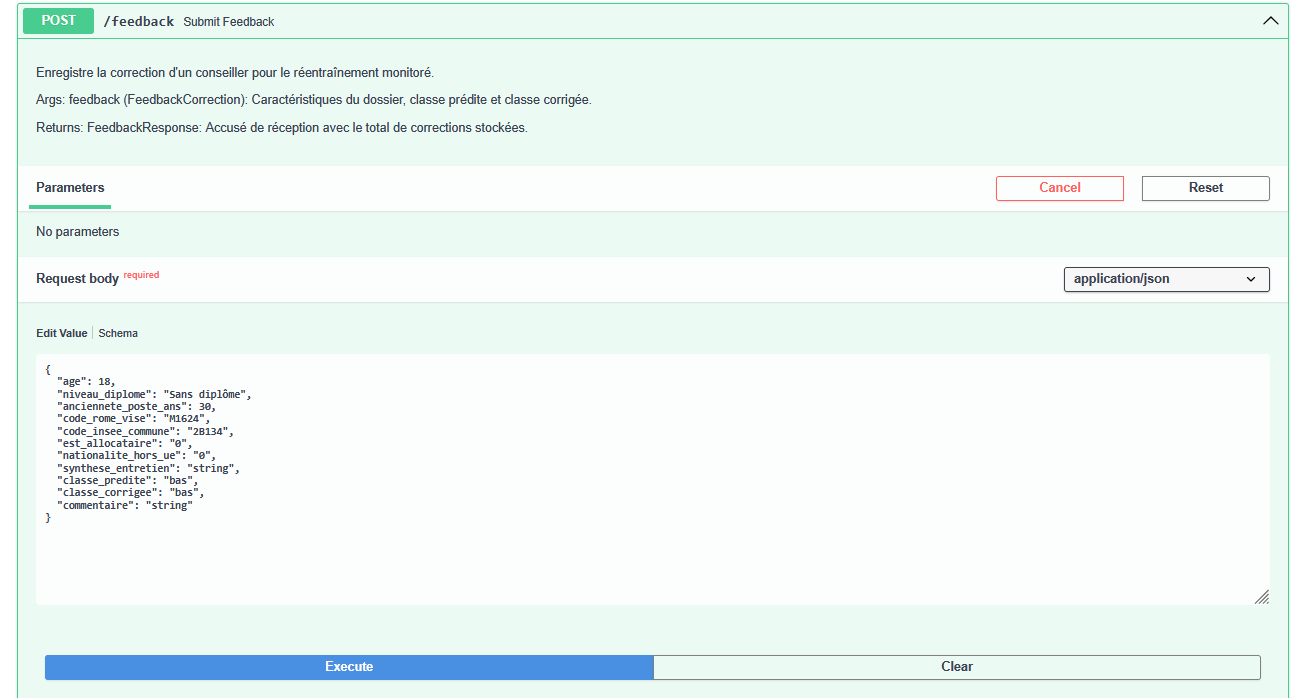
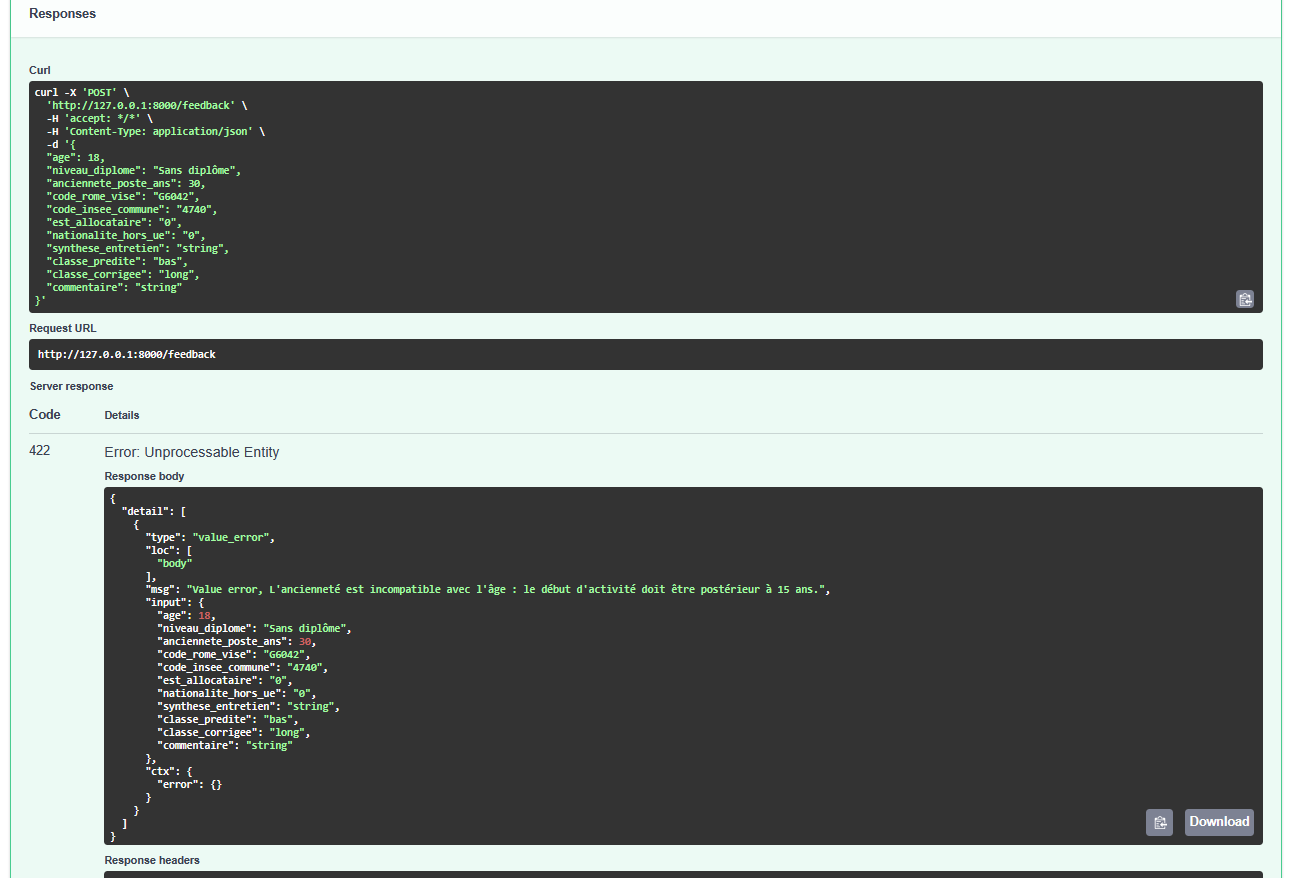

##### Réentraînement monitoré

`POST /train` recharge le dataset local, fusionne les corrections de `feedback_conseillers.csv`, reconstruit le même prétraitement que le modèle S1, remplace les valeurs incohérentes d'ancienneté par des valeurs manquantes, puis entraîne un pipeline de validation. Le `f1_macro` obtenu est comparé à la baseline enregistrée (`models/train_metrics_baseline.json`), avec une tolérance de dégradation de 0.02.

Si le nouveau modèle respecte ce garde-fou, il est réentraîné sur l'ensemble des données puis promu sous une nouvelle version locale (`v1.1`, `v1.2`, etc.). Le pipeline Joblib versionné, ses métadonnées et son hash SHA-256 sont sauvegardés. Le fichier `models/model_manifest.json` est ensuite mis à jour afin de désigner ce nouvel artefact comme modèle actif, qui remplace le pipeline précédent en mémoire. MLflow enregistre l'artefact, crée une nouvelle version dans le Model Registry et déplace l'alias `champion`.

Si le modèle est rejeté, le statut retourné est `rejected` et le modèle actif, le manifeste, la baseline et le pipeline en mémoire restent inchangés. Ce garde-fou anti-régression évite qu'un nouveau lot de corrections dégrade silencieusement le modèle servi.

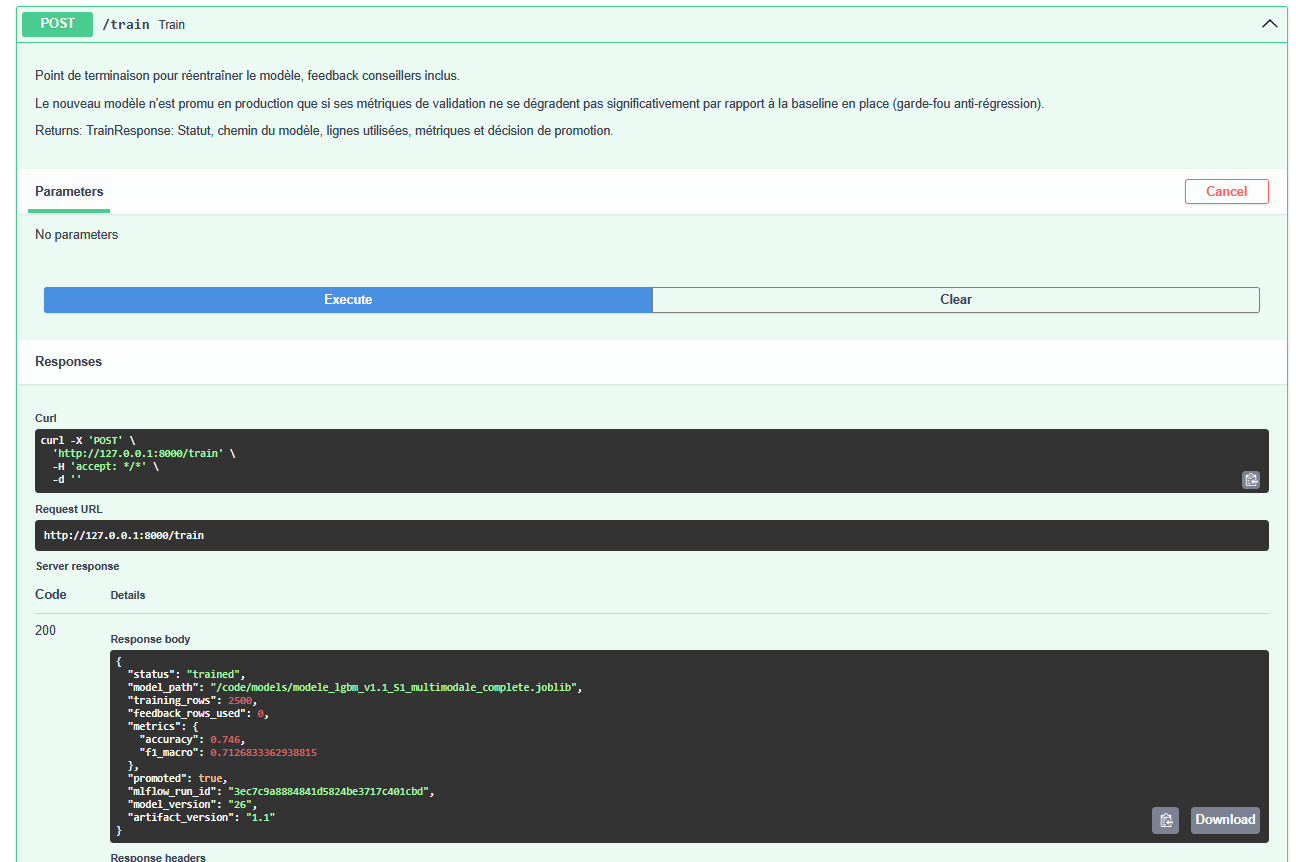
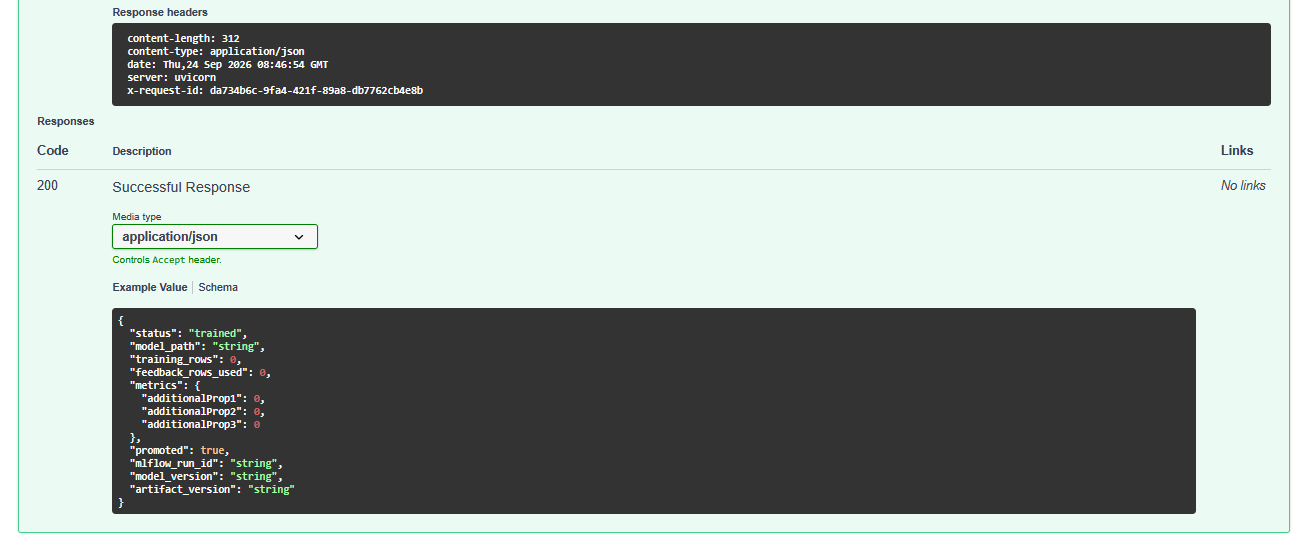

#### Conditions et recommandations pour la mise en production

Pour lancer l'API en local :

```powershell
.\.venv\Scripts\python.exe -m uvicorn app.main:app --reload
```

Avant toute mise en production ou exposition hors environnement local de confiance, il faut au minimum authentifier et autoriser la route `/train`, séparer l’API de prédiction des fonctions d’administration, appliquer une limitation de débit, gérer les secrets via des variables d’environnement ou un gestionnaire dédié, et sécuriser l’accès à MLflow.

Le dispositif de mise en production repose sur des artefacts Joblib versionnés, un manifeste local (`model_manifest.json`) avec métadonnées et hash SHA-256, ainsi que sur MLflow et l’alias `champion`. Avant toute promotion, le nouveau modèle est comparé à la baseline via son `f1_macro`. Un modèle rejeté laisse le modèle actif inchangé, un modèle accepté crée une nouvelle version, met à jour le manifeste et est enregistré dans MLflow. Avant la production, ce dispositif doit être complété par une validation indépendante, une approbation humaine, un contrôle de cohérence entre l’artefact, le manifeste et MLflow, ainsi qu’une procédure de rollback.

### 8.4 Interface utilisateur

 > **Dossier associé** : `Cas_usage_certif/services/ui-streamlit/`

Une interface web Streamlit permet à un conseiller de saisir les caractéristiques d'un demandeur d'emploi, d'obtenir la prédiction du modèle, d'enregistrer une correction via le formulaire de feedback, de lancer un réentraînement contrôlé et de consulter son historique d'inférences, sans passer par `/docs` ou un client HTTP. Elle consomme les routes `POST /predict`, `POST /feedback`, `POST /train`, `GET /health` et `GET /history` de l'API décrite en 8.3.

#### Formulaire de saisie

Le conseiller renseigne les 8 champs attendus par le modèle :

- âge, ancienneté au dernier poste, niveau de diplôme (liste déroulante)
- code ROME visé, code INSEE de la commune
- allocataire (oui/non), nationalité hors UE (oui/non)
- synthèse libre de l'entretien

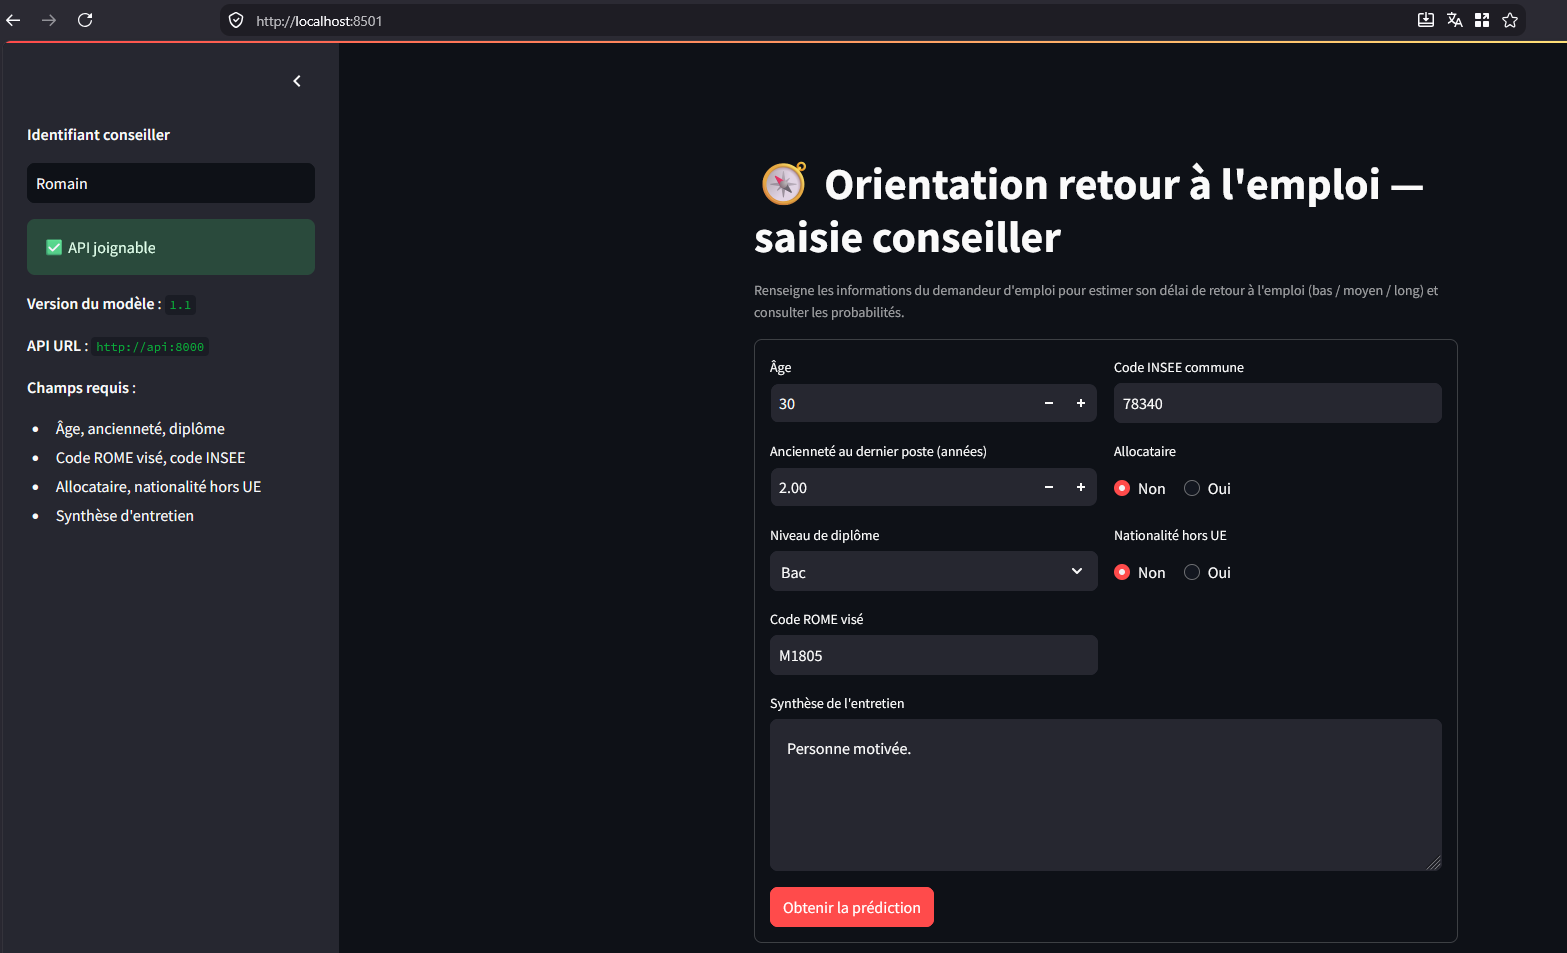

Ces champs reprennent les mêmes contraintes que le schéma Pydantic `Demandeur` (bornes d'âge et d'ancienneté, format des codes), afin d'éviter à la source les rejets `422`.

#### Affichage du résultat

Au clic sur « Obtenir la prédiction », l'UI appelle `POST /predict` (timeout 10 s) puis affiche :

- la classe prédite (`bas` / `moyen` / `long`) dans un encadré coloré (vert / orange / rouge)
- les probabilités des trois classes sous forme de graphique en barres (`st.bar_chart`)
- un message d'erreur explicite en cas d'API injoignable, de timeout, ou de réponse `422`/`503`

La barre latérale affiche en continu l'état de santé de l'API (`GET /health`) et la version du modèle chargé, pour signaler immédiatement si le service est disponible et quel modèle est utilisé.

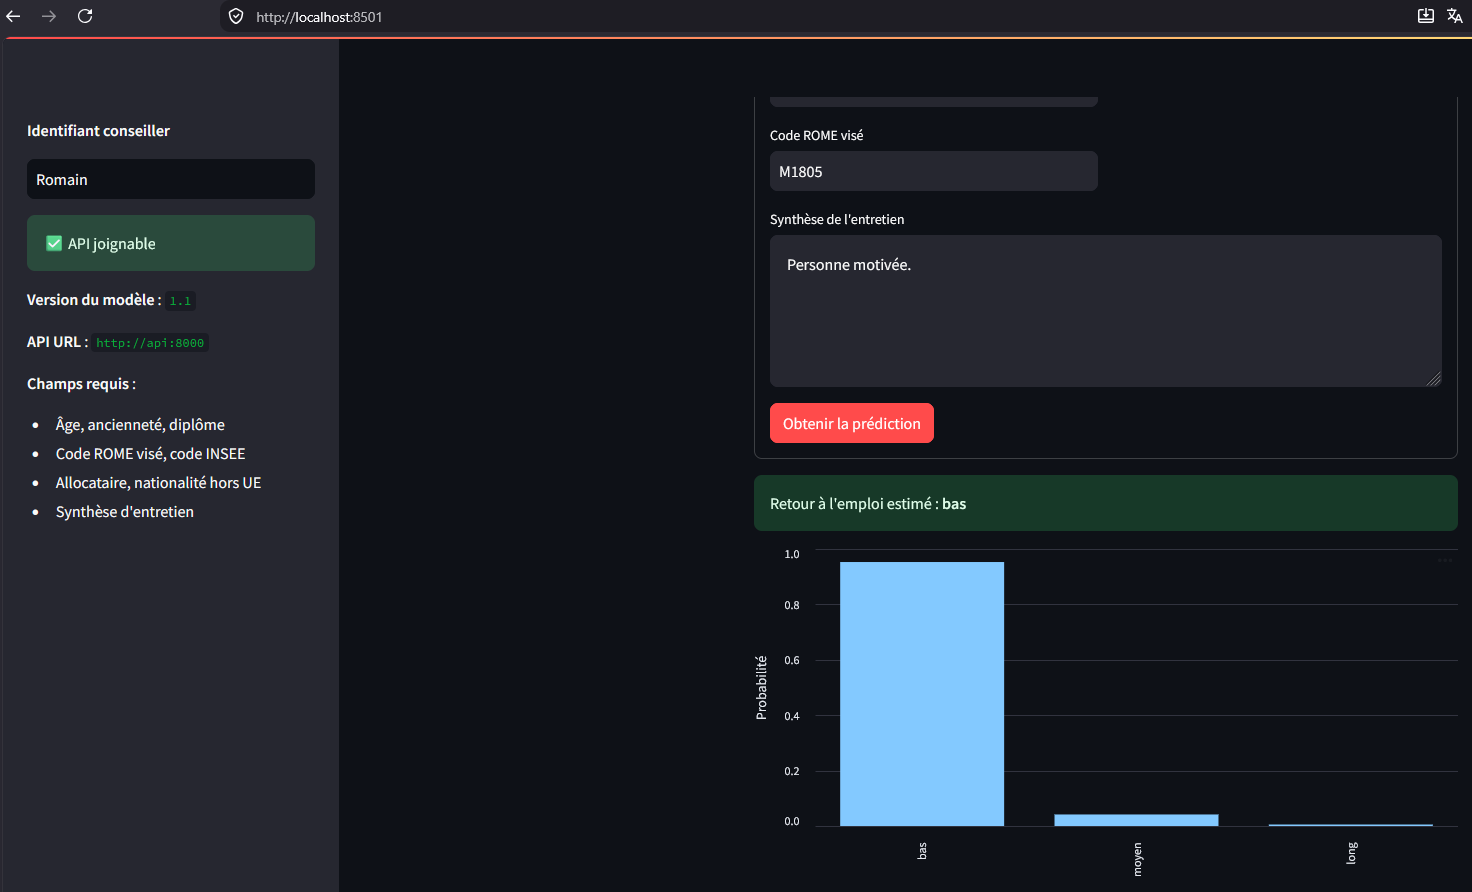
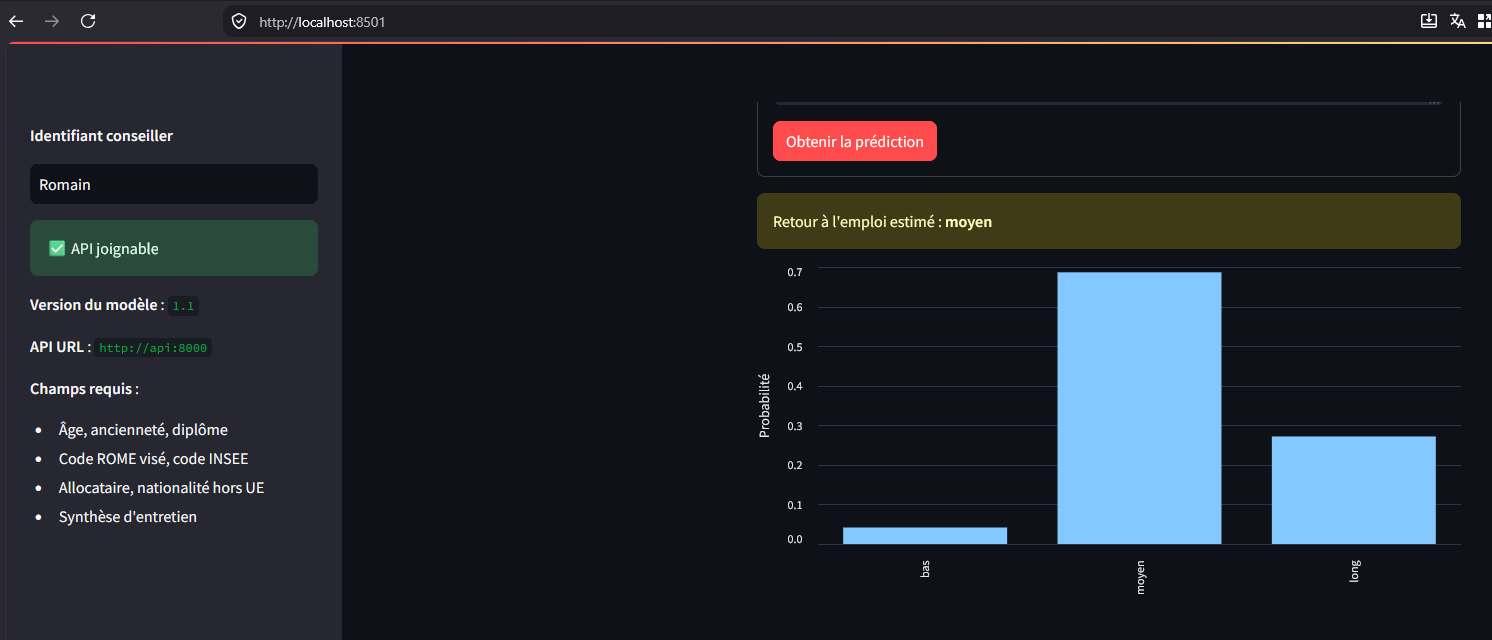
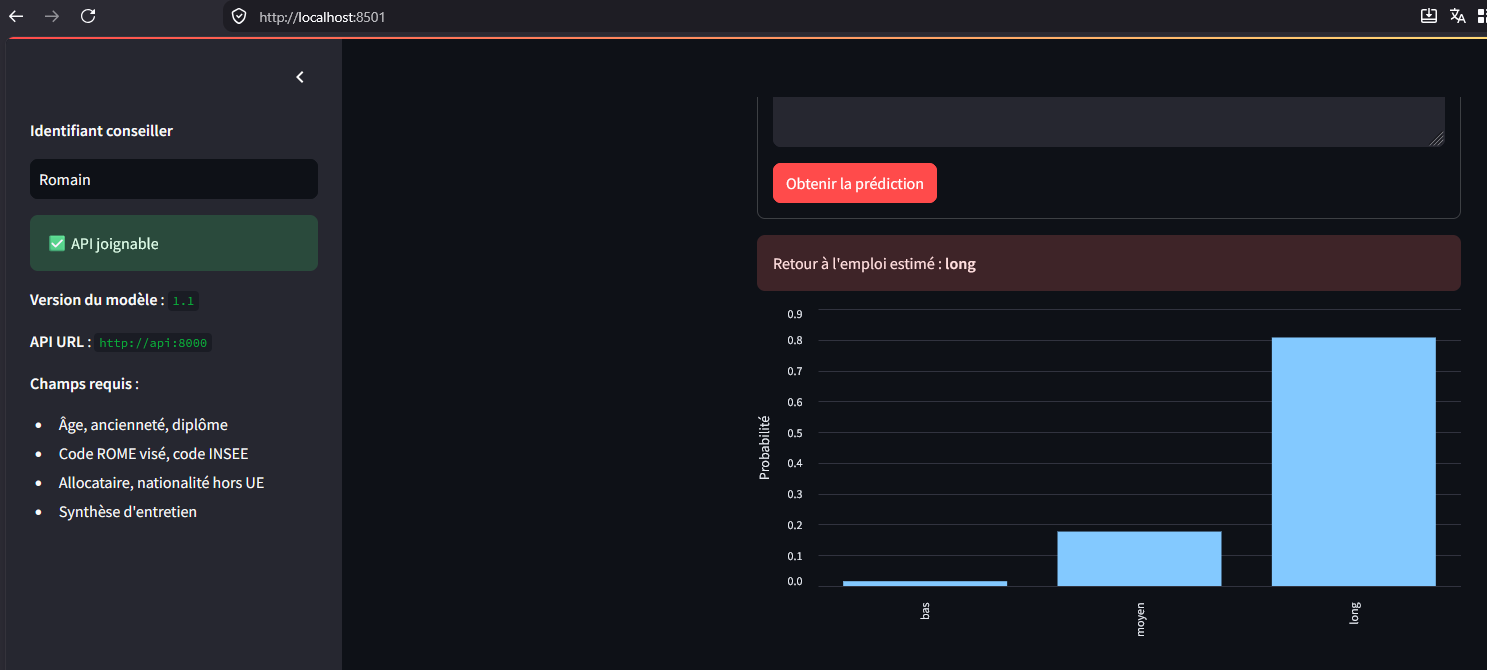
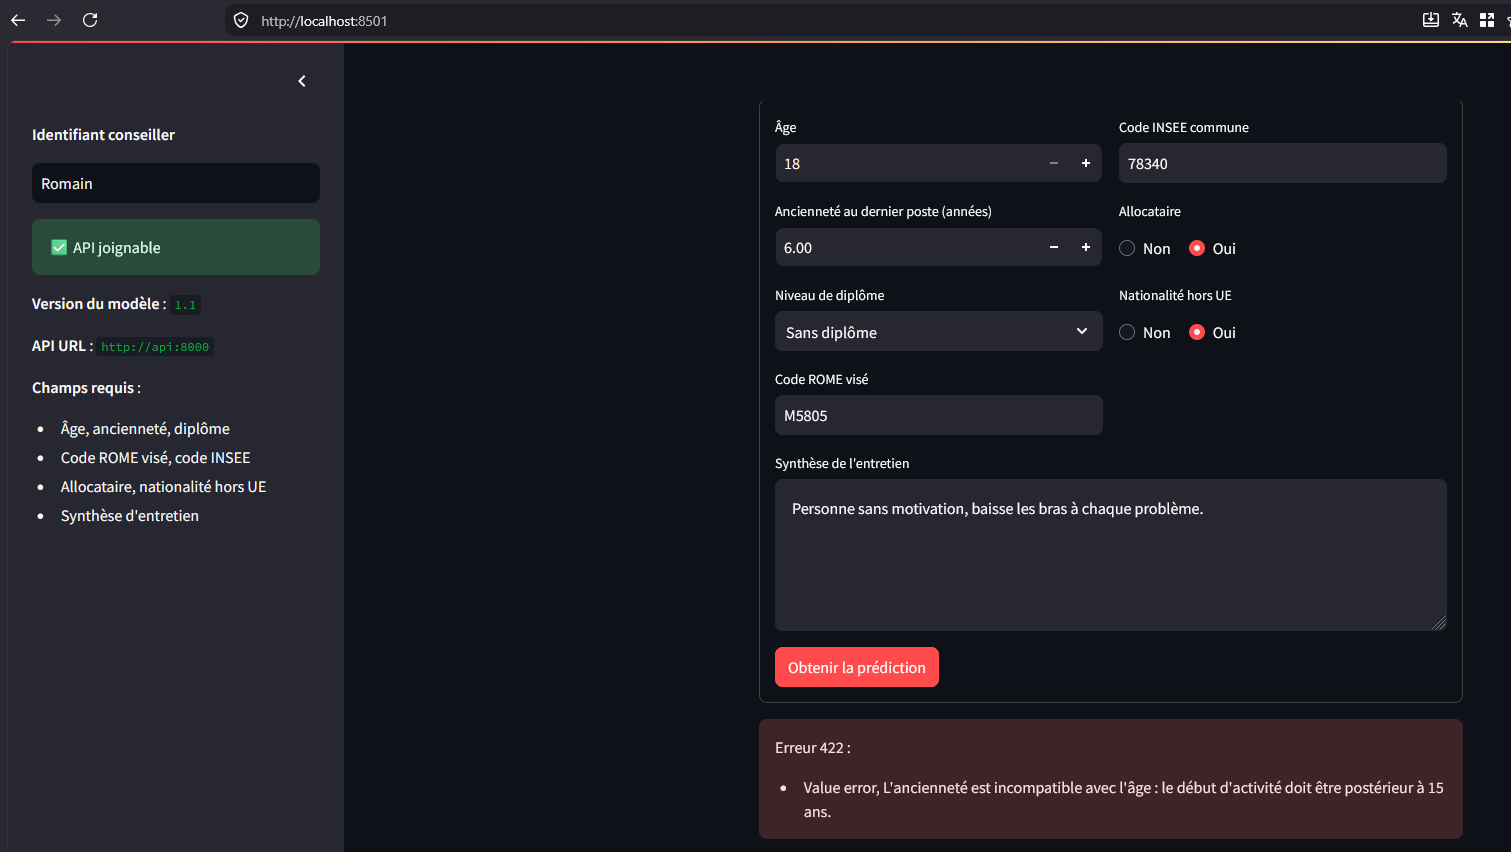
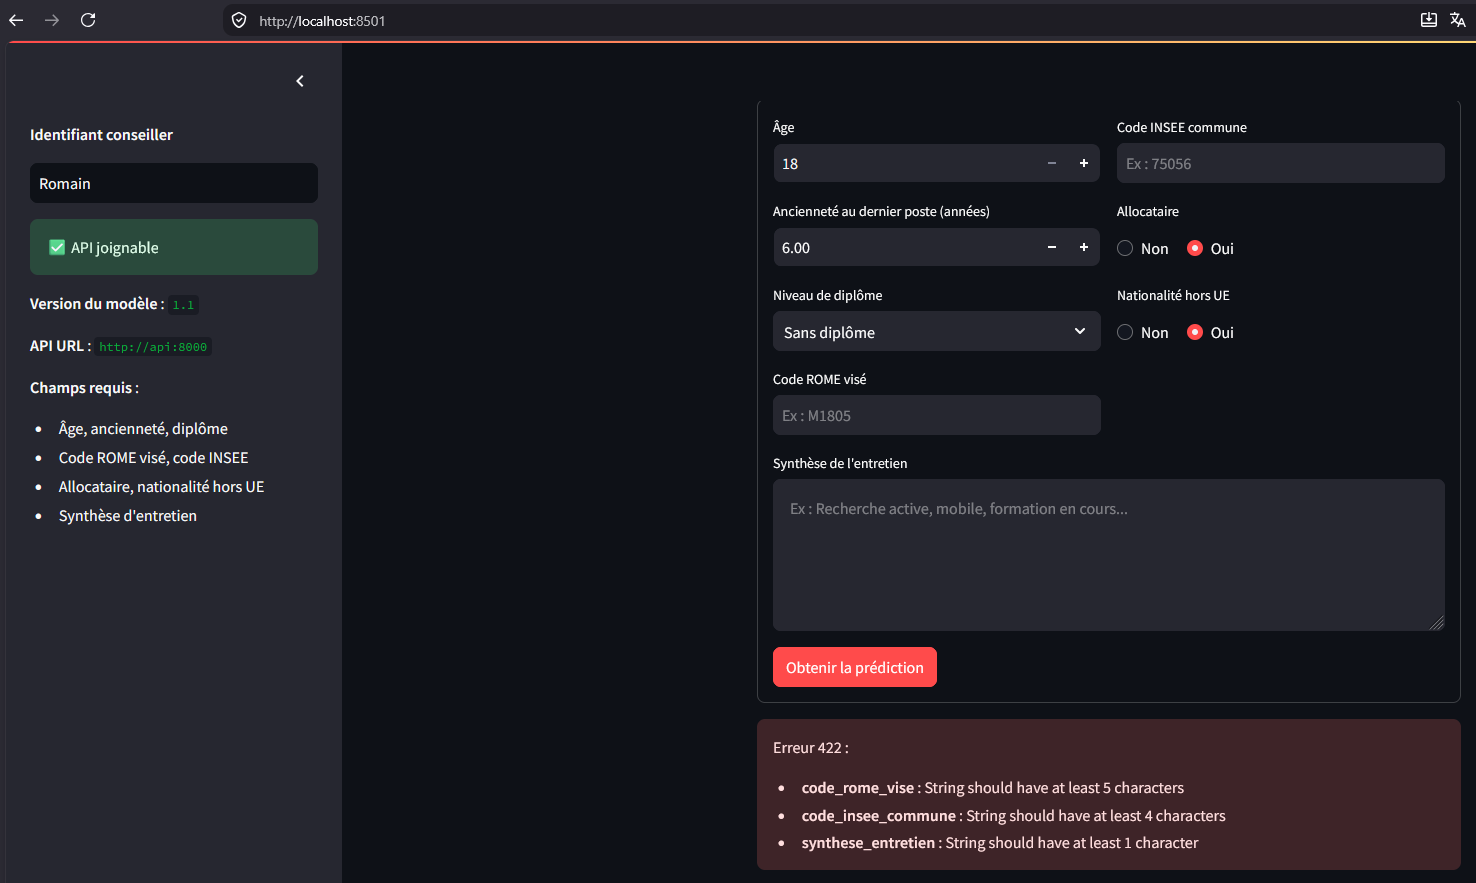

Aperçu des inférences enregistrées pour un conseiller dans le fichier `historique_inferences.csv` :

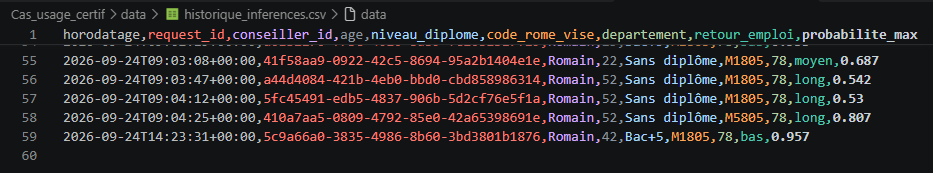

#### Feedback conseiller

Après l'affichage d'une prédiction, le conseiller peut utiliser le formulaire de correction pour sélectionner la classe réellement constatée et ajouter un commentaire facultatif. L'UI envoie alors les caractéristiques du dossier, la classe initialement prédite, la classe corrigée et le commentaire à `POST /feedback`. La réponse de l'API confirme l'enregistrement et indique le nombre total de corrections stockées.

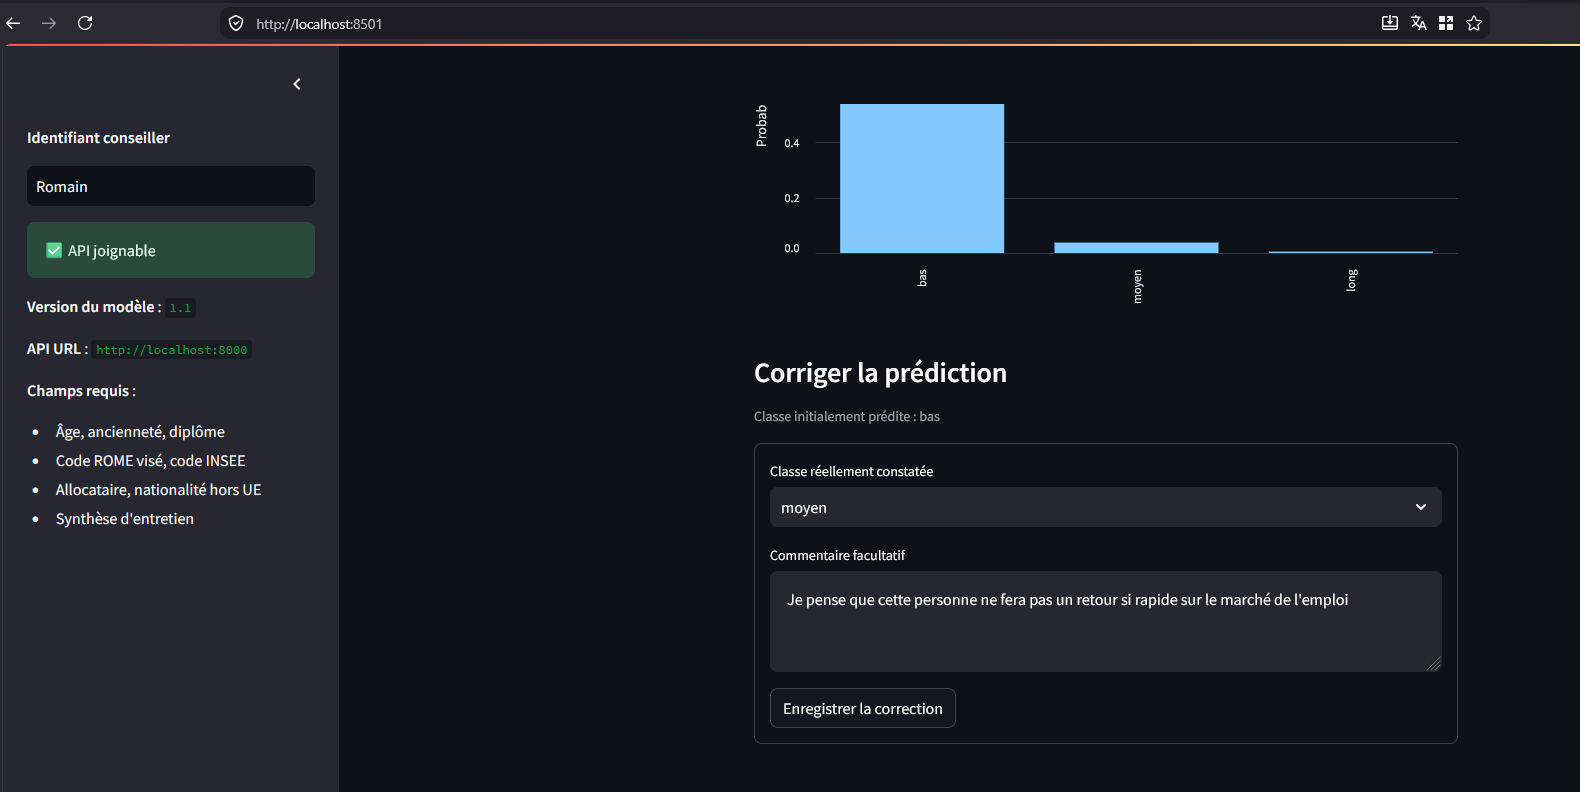
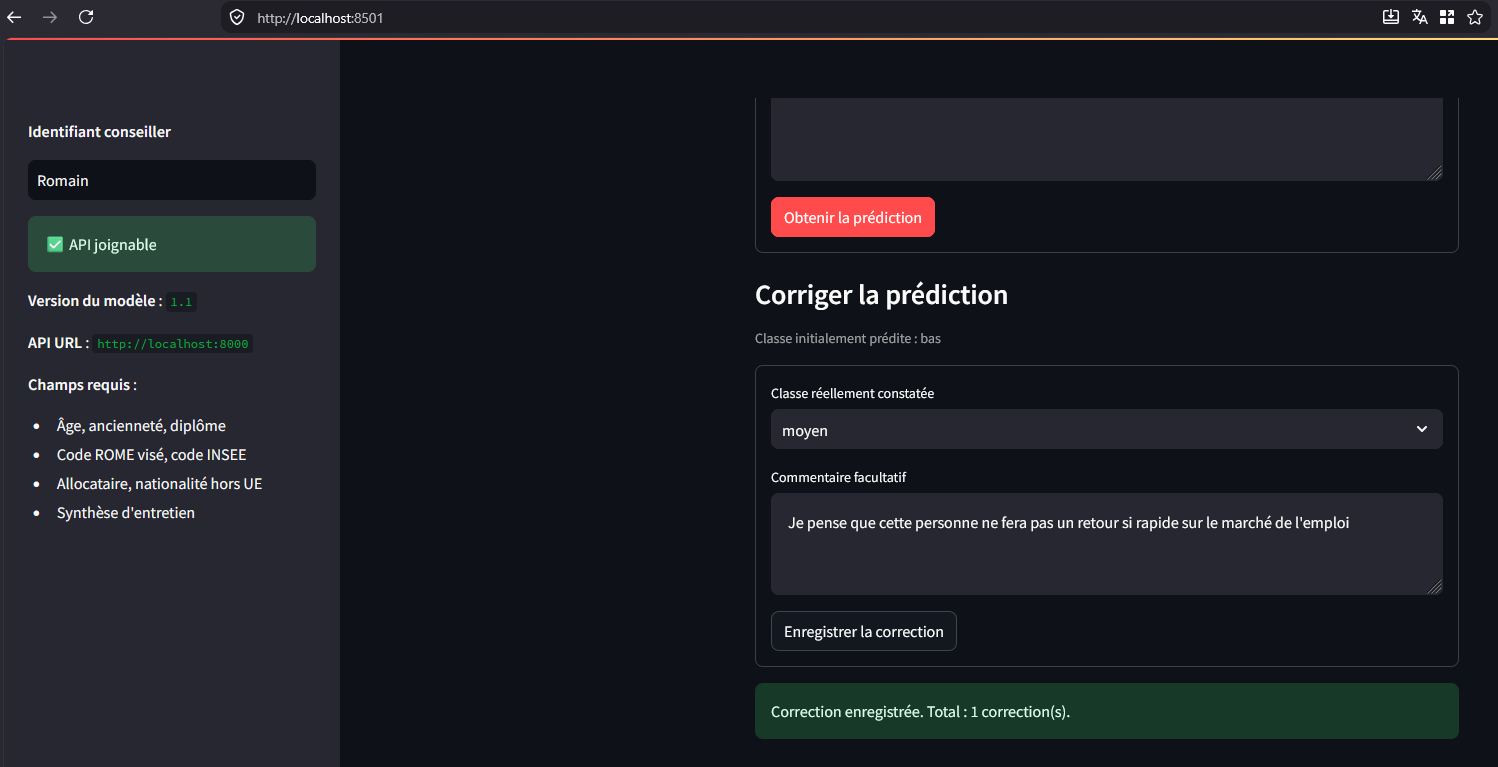

Aperçu des corrections enregistrées dans le fichier de feedbacks :

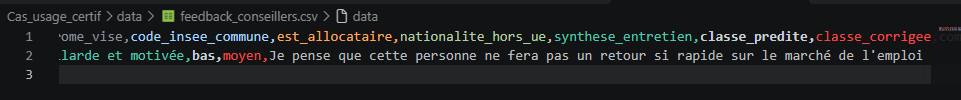

#### Consultation de l'historique des inférences

Chaque prédiction est enregistrée côté API dans `data/historique_inferences.csv` (horodatage, identifiant conseiller, âge, diplôme, code ROME, département, classe prédite, probabilité maximale), via la route `GET /history` décrite au chapitre 8.3.

Dans la barre latérale, le conseiller peut renseigner un identifiant libre (`X-Conseiller-ID`), transmis à chaque appel `POST /predict` pour rattacher ses prédictions. Un bouton **« Charger l'historique »**, avec un réglage du nombre de lignes à afficher, interroge `GET /history` (filtré par cet identifiant si renseigné) et affiche le résultat sous forme de tableau : les prédictions les plus récentes en premier.

Cet historique est persistant côté serveur : il survit au rechargement de la page et au redémarrage du conteneur `ui`, contrairement à un simple état de session Streamlit. Il reste toutefois un outil de confort pour le conseiller (retrouver ses dernières estimations) et non un journal d'audit réglementaire : la traçabilité complète des décisions reste assurée par `logs/api.log` et le futur rattachement au dossier usager dans le référentiel national (cf §8.5.1).

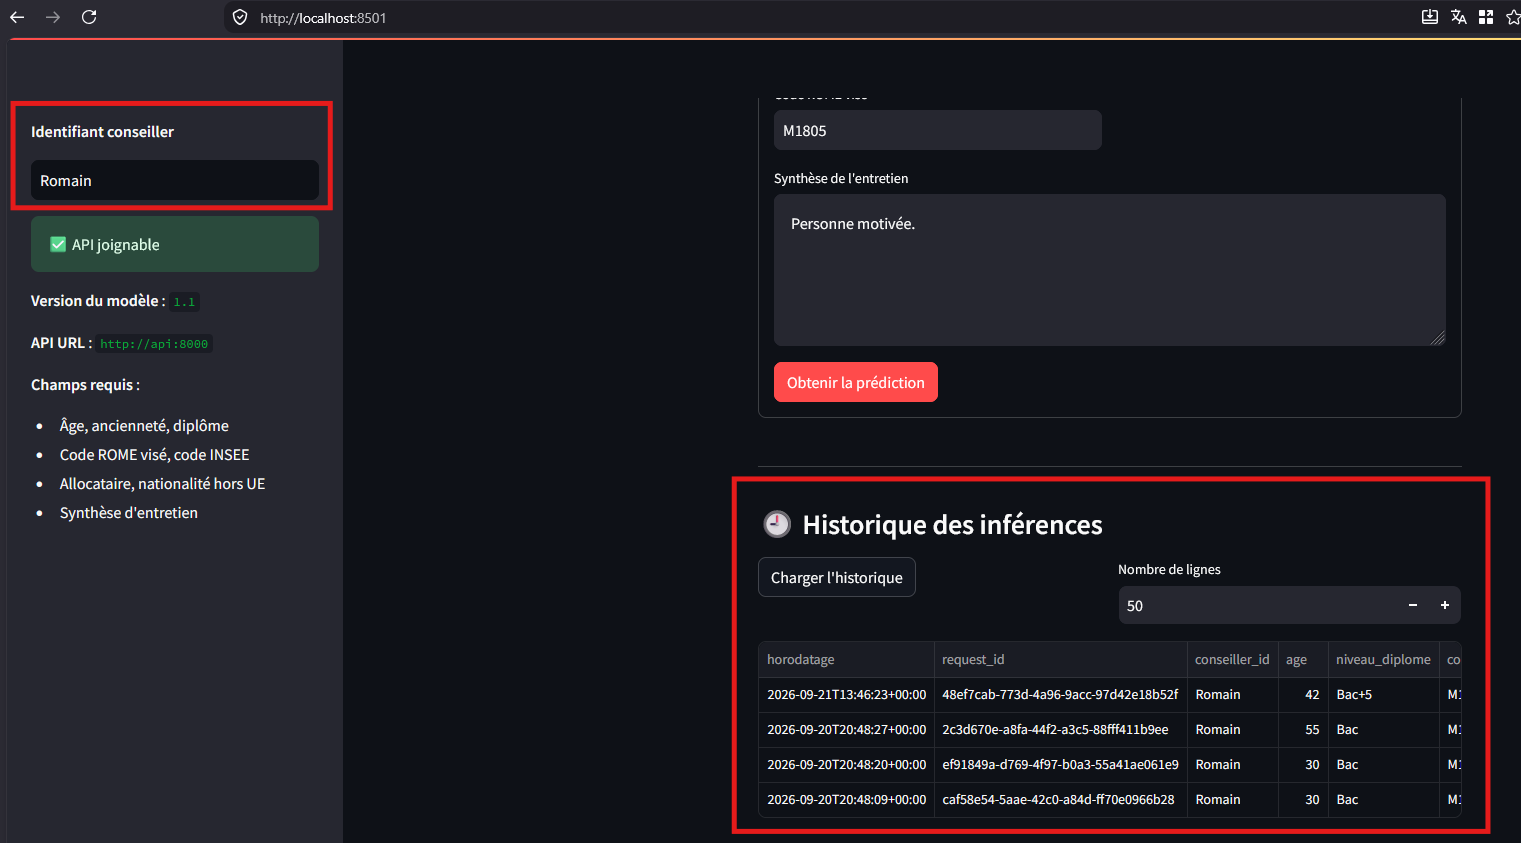

En production, l’identifiant du conseiller devra être obligatoire. Son format devra être défini avec l’agence utilisatrice, puis contrôlé automatiquement par l’API afin de garantir une traçabilité fiable des inférences.

#### Réentraînement du modèle par le conseiller

Depuis la barre latérale, le bouton **« Lancer le réentraînement »** appelle `POST /train` sans payload. L'UI utilise un timeout dédié de 120 secondes et affiche le résultat de l'entraînement :

- le statut `trained` ou `rejected`
- la décision de promotion du modèle
- les métriques `accuracy` et `f1_macro`
- le nombre de lignes d'entraînement et de corrections intégrées
- la version locale de l'artefact promu lorsqu'elle existe

Le réentraînement est synchrone et peut modifier le pipeline actif en mémoire uniquement si le nouveau modèle est accepté par le garde-fou anti-régression. En production, l'accès à cette action devra être authentifié et autorisé selon le rôle du conseiller ou de l'administrateur.

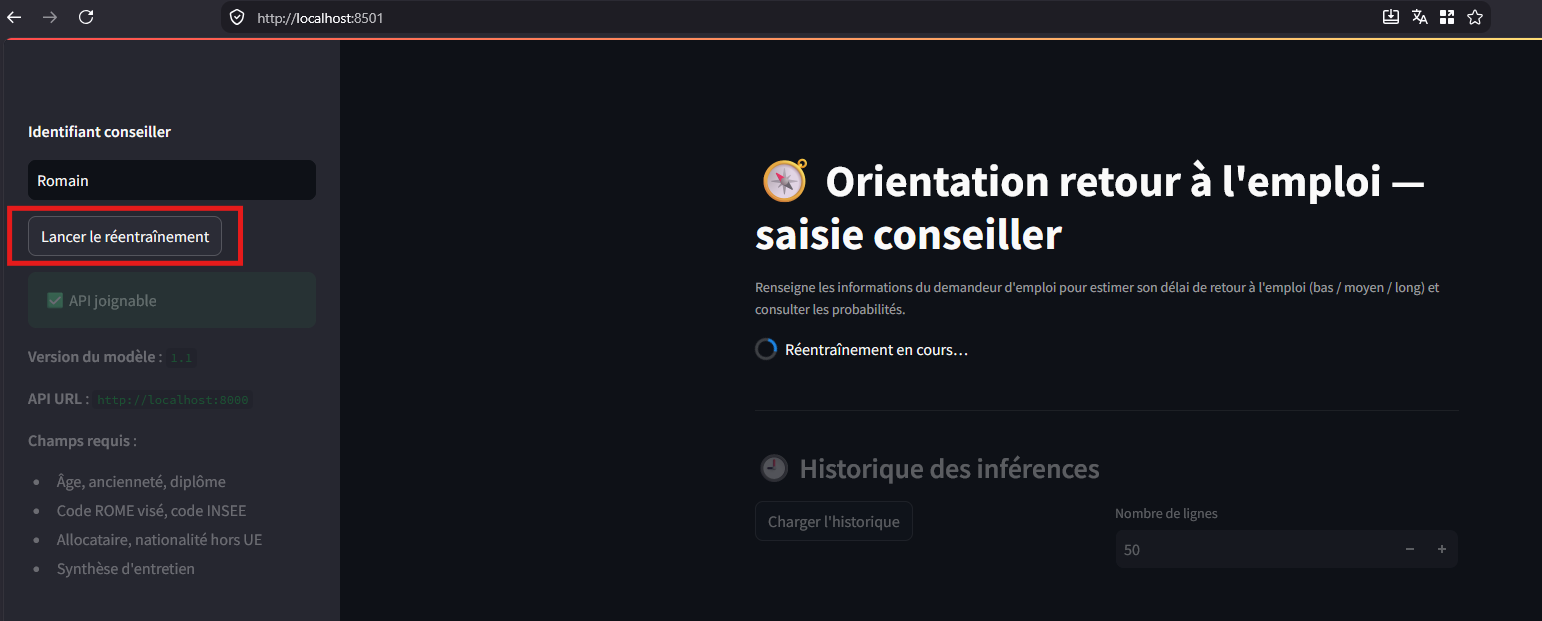
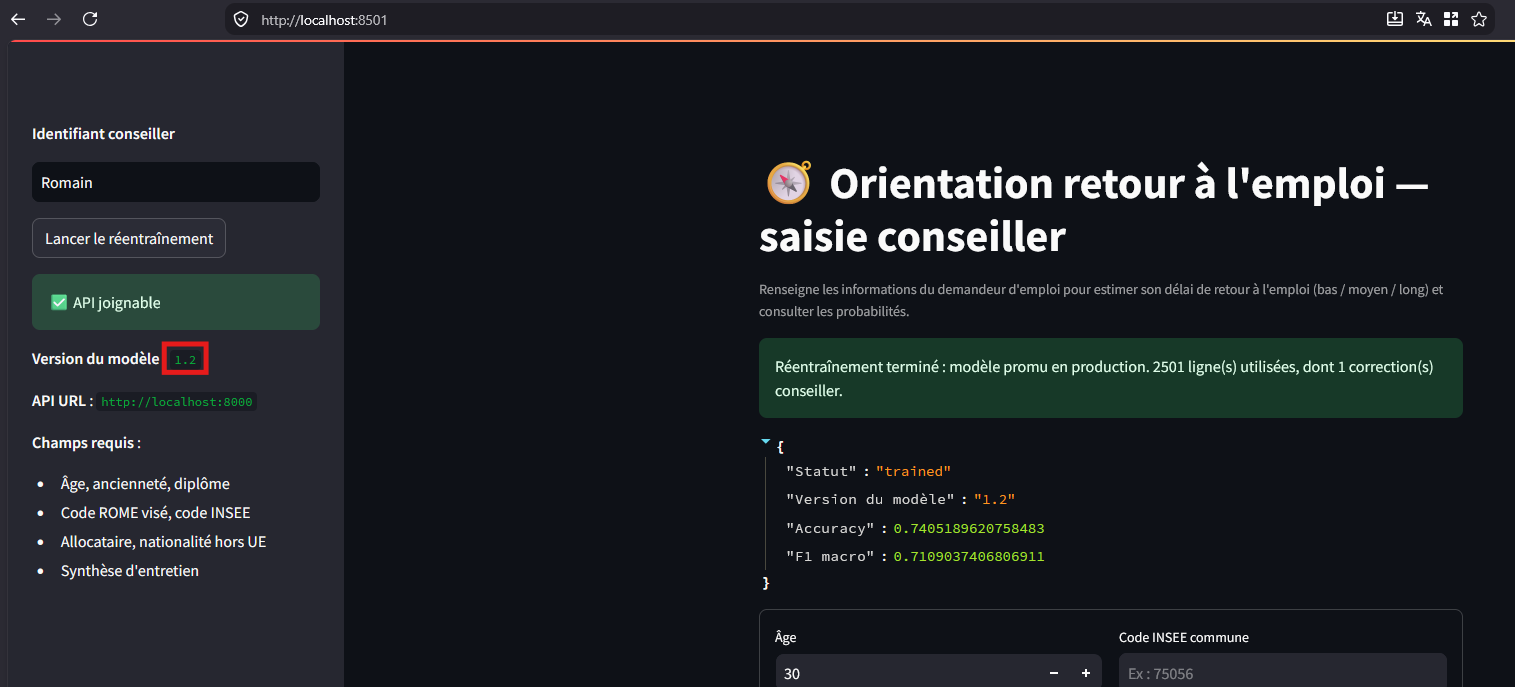

#### Exécution locale

```powershell
.\.venv\Scripts\python.exe -m streamlit run services\ui-streamlit\app.py
```

L'URL de l'API est configurable via la variable d'environnement `API_URL` (par défaut `http://localhost:8000`, ou `http://api:8000` dans un déploiement `docker-compose`), ce qui permet de brancher l'UI sur l'API sans modifier le code.


### 8.5 Schéma d'architecture

L’architecture distingue l’inférence en ligne et une boucle de réentraînement contrôlée. En ligne, l’API applique le prétraitement du pipeline chargé au démarrage aux données saisies par le conseiller et renvoie une prédiction supervisée par les logs et le monitoring. Après cette prédiction, le conseiller peut corriger la classe proposée depuis le formulaire de feedback de l’interface Streamlit. La correction est envoyée à `POST /feedback`, enregistrée dans un fichier dédié, puis réutilisée par la route `/train`, déclenchée par le bouton de réentraînement de l’UI, pour entraîner un modèle de validation, le comparer à la baseline, puis le promouvoir ou le rejeter. Les modèles acceptés sont sauvegardés, tracés dans MLflow et chargés en mémoire pour les prédictions suivantes.

```mermaid
flowchart LR
    subgraph Entraînement hors ligne
        A[CSV dataset] --> B[Prétraitement]
        FB[(feedback_conseillers.csv)] --> B
        B --> C[Entraînement de validation]
        C --> G{f1_macro >= baseline - tolérance ?}
        G -->|Non| Rej[Modèle rejeté - modèle actif inchangé]
        G -->|Oui| C2[Réentraînement sur tout le jeu]
        C2 --> V[Création de la prochaine version - v1.1, v1.2, etc.]
        V --> M[Sauvegarde artefact .joblib versionné]
        M --> MD[Sauvegarde des métadonnées]
        MD --> H[Calcul du hash SHA-256]
        H --> MM[Mise à jour atomique de model_manifest.json]
        MM --> AM[(Modèle actif en mémoire)]
        MM --> ML[MLflow - run, artefact et métriques]
        ML --> CH[Alias champion]
    end

    subgraph Inférence en ligne
        U[Saisie conseiller UI] --> D[API /predict]
        AM --> D
        D --> R[Prédiction et probabilités]
        R --> U
        D --> F[Monitoring et logs]
        D --> HI[(historique_inferences.csv)]
        U --> Health[API /health]
        Health --> HealthResult[Statut et version du modèle]
        HealthResult --> U
    end

    subgraph Boucle de feedback
        U --> FeedbackForm[Formulaire de correction dans l'UI]
        FeedbackForm -->|Classe corrigée + commentaire| E[API /feedback]
        E --> FeedbackOK[Confirmation d'enregistrement]
        FeedbackOK --> U
        E --> FB
    end

    subgraph Réentraînement depuis l'UI
        U --> TrainButton[Bouton « Lancer le réentraînement »]
        TrainButton -->|POST /train| TrainAPI[API /train]
        TrainAPI --> C
        Rej --> TrainRejectedResult[Résultat rejected affiché dans l'UI]
        TrainRejectedResult --> U
        MM --> TrainAcceptedResult[Résultat trained + métriques + version affiché dans l'UI]
        TrainAcceptedResult --> U
    end

    subgraph Consultation de l'historique
        U --> HistoryButton[Bouton « Charger l'historique »]
        HistoryButton -->|GET /history| I[API /history]
        HI -.-> I
        I --> HistoryResult[Historique affiché dans l'UI]
        HistoryResult --> U
    end

    subgraph Rollback
        MM --> VERS[(Artefacts versionnés)]
        VERS -.-> RB[Rollback vers une version précédente]
        RB -.-> MM
    end
```

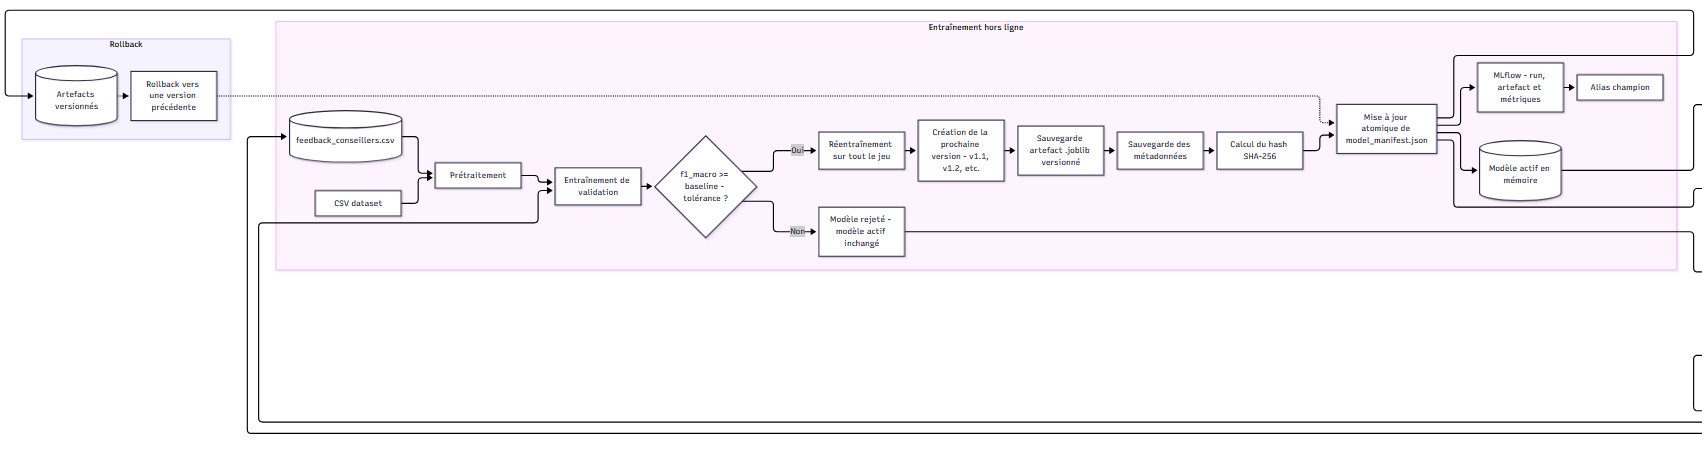
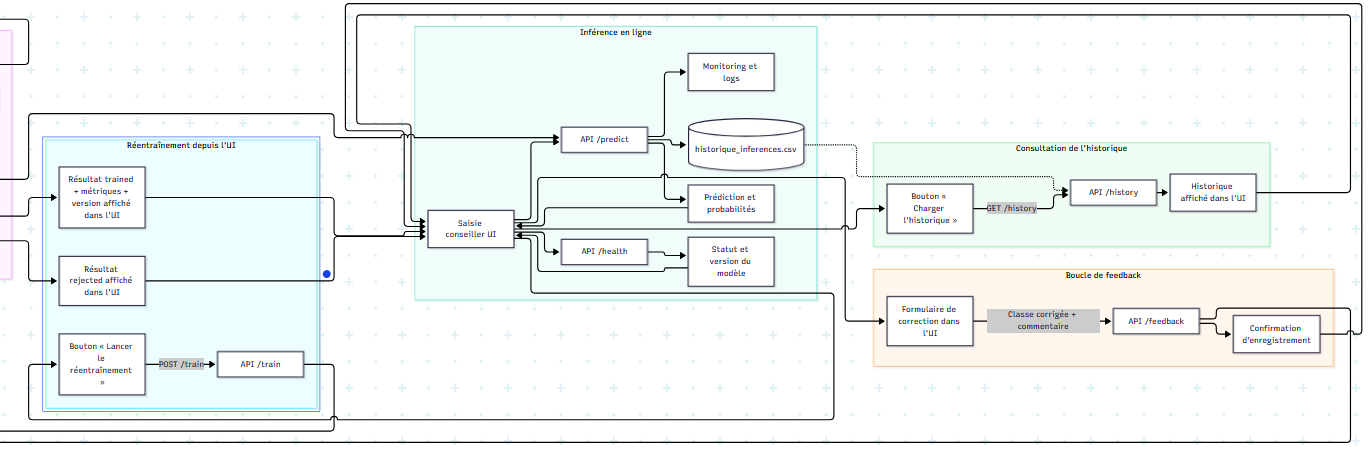

- **Réentraînement manuel et contrôlé** : le bouton de l’interface Streamlit appelle `POST /train` sans payload. L’API recharge le dataset CSV et les corrections accumulées dans `feedback_conseillers.csv`, puis lance un entraînement de validation. Les hyperparamètres, les métriques, la baseline et le statut de promotion sont enregistrés dans MLflow. Si le nouveau modèle respecte le garde-fou sur le `f1_macro`, il est réentraîné sur l'ensemble des données et promu sous une nouvelle version locale (`v1.1`, `v1.2`, etc.). Le pipeline `.joblib` versionné, ses métadonnées et son hash SHA-256 sont sauvegardés, puis `model_manifest.json` est mis à jour atomiquement pour désigner cet artefact comme modèle actif. Le nouveau pipeline remplace alors le modèle conservé en mémoire. L’UI affiche le statut, les métriques, le nombre de feedbacks intégrés et la version promue.

  Si le modèle est rejeté parce que son `f1_macro` est inférieur à la baseline diminuée de la tolérance, aucun artefact actif, manifeste ou pipeline en mémoire n'est modifié. Le modèle rejeté reste toutefois tracé dans MLflow, et le résultat `rejected` est affiché dans l’UI.

- **Inférence en ligne** : l’API lit `model_manifest.json` au démarrage, vérifie le hash SHA-256 de l’artefact désigné et charge le pipeline actif en mémoire. La donnée consommée n’est pas le CSV mais les features saisies par le conseiller dans l’UI. L’API applique le même prétraitement au pipeline actif, correspondant à la version locale promue, puis produit la prédiction. La route `/health` expose notamment l’état de chargement et la version du modèle, tandis que chaque prédiction est journalisée dans `historique_inferences.csv`.

- **Boucle de feedback** : après l’affichage d’une prédiction, le conseiller ouvre le formulaire de correction dans l’UI, sélectionne la classe réellement constatée et ajoute éventuellement un commentaire. L’UI envoie alors les données du dossier, la classe prédite, la classe corrigée et le commentaire à `POST /feedback`. L’API enregistre la correction dans `feedback_conseillers.csv` et renvoie une confirmation avec le nombre total de corrections stockées. Cette correction sera intégrée lors du prochain `POST /train` déclenché depuis l’UI.

- **Consultation de l'historique** : le conseiller peut relire ses prédictions passées via `GET /history`, qui relit `historique_inferences.csv` et permet un filtrage par identifiant conseiller et par limite de lignes. Cette consultation ne modifie ni le modèle actif ni sa version.

- **UI** : l’interface Streamlit consomme `POST /predict` pour afficher la classe et les probabilités, `POST /feedback` pour enregistrer une correction conseiller, `GET /health` pour afficher l’état de l’API et la version du modèle chargé, `GET /history` pour consulter l’historique, et `POST /train`pour lancer le réentraînement du modèle.

- **Sécurité de `/train`** : même si le bouton est disponible dans l’interface, la route devra être authentifiée et autorisée en production. L’accès devra être limité aux profils habilités, avec journalisation de l’appel et de son résultat.

- **Monitoring et traçabilité** : les logs structurés (`logs/api.log`, `request_id`), `GET /health`, le manifeste local et la vérification du hash SHA-256 permettent de suivre la disponibilité, l’intégrité et la version du modèle servi. MLflow conserve les entraînements acceptés et rejetés, leurs hyperparamètres, leurs métriques, leurs artefacts et leurs versions dans le Model Registry. L’alias `champion` désigne la version promue. Les versions locales des artefacts restent la référence opérationnelle chargée par l’API. Le stockage local `mlruns/` devra être remplacé par un serveur MLflow persistant en production.

### 8.5.1 Cartographie des flux avec le système d'information métier

Le service d'IA ne fonctionne pas en vase clos : il s'intègre entre l'application de guichet unique utilisée par les conseillers et le référentiel national des usagers. Dans la démonstration actuelle, l'interface Streamlit porte la saisie, l'affichage de la prédiction, le formulaire de correction et le déclenchement manuel du réentraînement. Le guichet unique représente le système métier cible qui pourra alimenter cette interface ou appeler directement l'API dans une intégration future.

```mermaid
flowchart LR
    subgraph SI["SI existant"]
        GU["Application guichet unique<br/>conseiller"]
        REF[("Référentiel national<br/>des usagers")]
        ADM["Administrateur<br/>ou processus autorisé"]
    end

    subgraph IA["Service IA"]
        UI["Interface Streamlit<br/>conseiller"]
        API["API FastAPI<br/>/predict /health /feedback /train /history"]
        MANIFEST[("model_manifest.json")]
        HASH["Vérification hash<br/>SHA-256"]
        MOD[("Pipeline actif<br/>en mémoire")]
        VERS[("Artefacts Joblib<br/>versionnés")]
        HIST[("historique_inferences.csv")]
        FEEDBACK[("feedback_conseillers.csv")]
        TRAIN["Validation et<br/>réentraînement"]
        MLFLOW[("MLflow Tracking<br/>+ Model Registry")]
        ALIAS["Alias champion"]
        LOGS[("logs/api.log")]
    end

    GU -->|1. Lecture dossier usager| REF
    REF -->|2. Données du dossier| UI
    UI -->|3. POST /predict<br/>caractéristiques du dossier| API

    MANIFEST -->|Artefact et version active| HASH
    HASH -->|Hash valide| MOD
    VERS -->|Chargement de la version désignée| HASH

    API -->|4. Utilisation du pipeline actif| MOD
    API -->|4bis. Journalisation| HIST
    API -->|5. Classe + probabilités| UI
    UI -->|6. Décision du conseiller| GU

    UI -->|7. Correction via le formulaire<br/>classe corrigée + commentaire| API
    API -->|8. Confirmation + total_feedback_rows| UI
    API -->|9. Enregistrement du feedback| FEEDBACK

    UI -->|10. GET /history| API
    API -->|11. Lecture de l'historique| HIST
    API -->|12. Historique affiché| UI

    UI -->|13. GET /health<br/>statut + version| API
    API -->|14. Statut + version du modèle| UI

    UI -->|15. Bouton réentraînement<br/>POST /train| API
    ADM -.->|Accès alternatif autorisé<br/>POST /train| API
    API --> TRAIN
    TRAIN -->|16. Dataset + feedbacks| FEEDBACK
    TRAIN -->|17. Comparaison f1_macro<br/>à la baseline| TRAIN

    TRAIN -->|Modèle rejeté| REJ["Modèle actif inchangé<br/>résultat rejected affiché dans l'UI"]
    TRAIN -->|Modèle accepté| NEW["Création nouvelle version<br/>v1.1, v1.2, etc."]
    REJ --> UI

    NEW -->|Sauvegarde pipeline,<br/>métadonnées et hash| VERS
    VERS --> MANIFEST
    MANIFEST -->|Mise à jour atomique| MOD
    MOD -->|Modèle promu + métriques<br/>affichés dans l'UI| UI

    TRAIN -->|Paramètres, métriques,<br/>statut et artefact| MLFLOW
    MLFLOW -->|Version promue| ALIAS
    ALIAS -->|Référence de promotion| MLFLOW

    MOD -.->|Rollback| VERS
    API -.->|Logs et request_id| LOGS
```

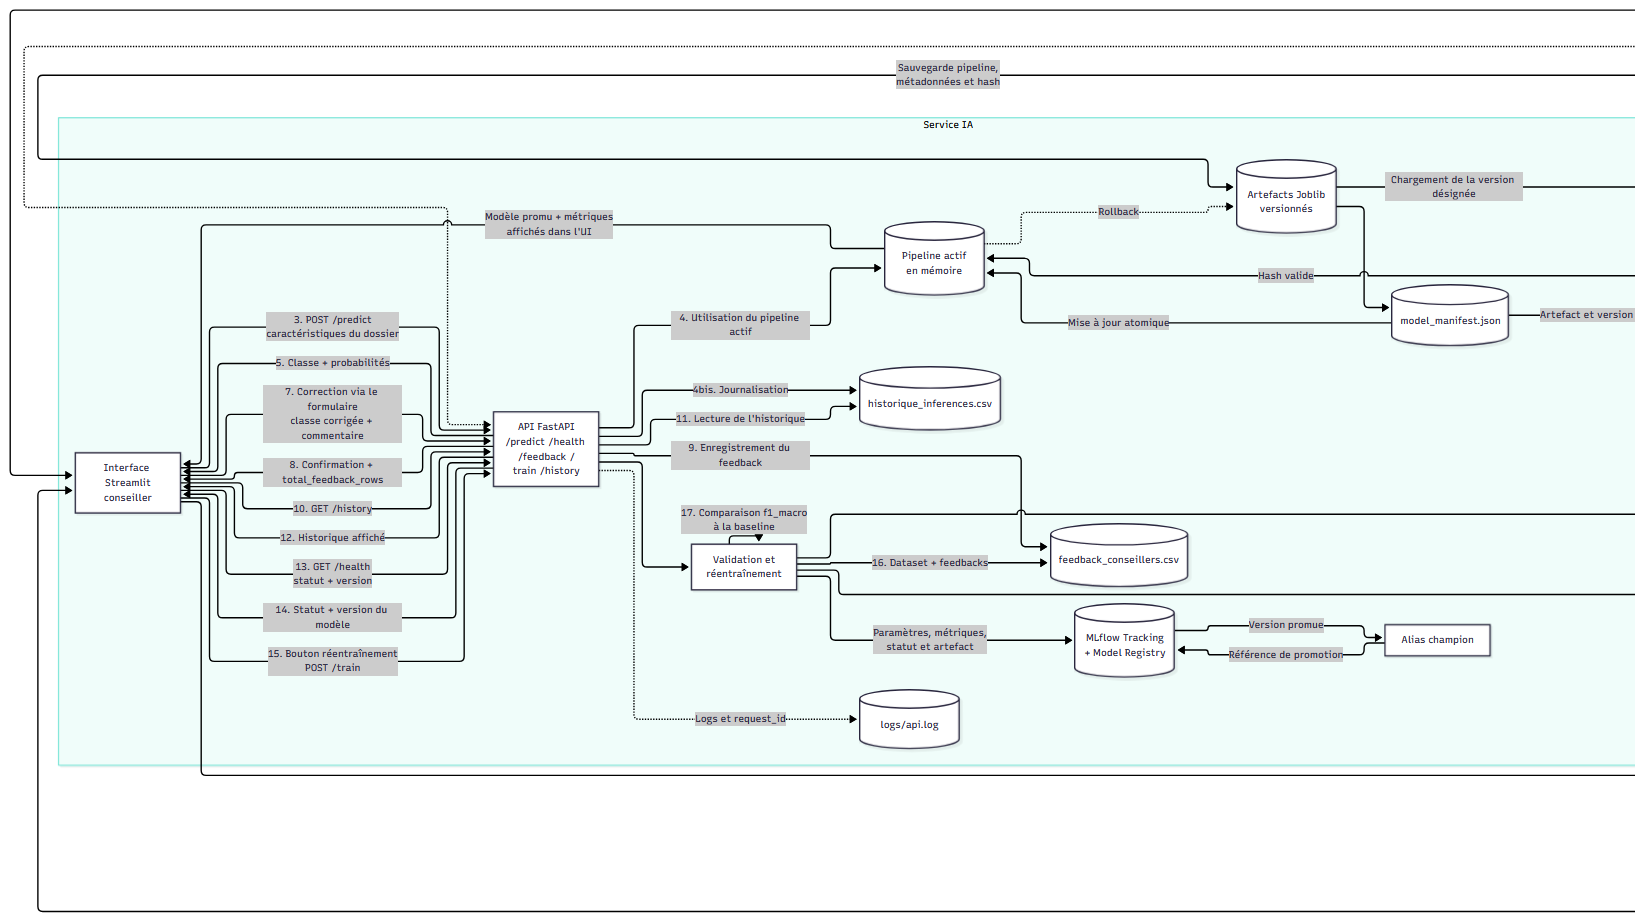
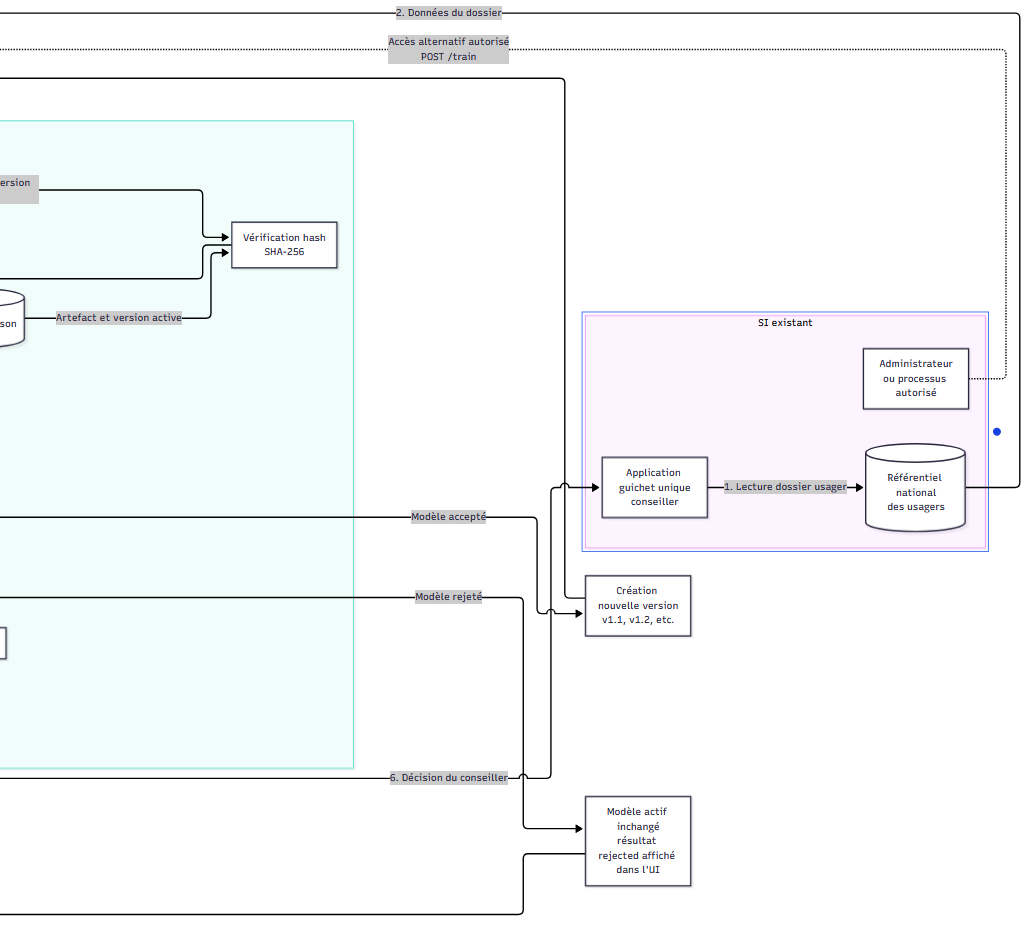

**Lecture des flux** :

1. Le conseiller ouvre le dossier de l'usager. L'application récupère les informations administratives dans le référentiel national des usagers.
2. Dans la démonstration actuelle, les données sont saisies dans l'interface Streamlit. Dans une intégration cible, elles pourront être transmises par l'application de guichet unique.
3. L'interface Streamlit appelle `POST /predict` avec les caractéristiques du dossier.
4. Au démarrage, l'API lit `model_manifest.json`, vérifie le hash SHA-256 de l'artefact désigné et charge le pipeline actif en mémoire.
5. L'API renvoie la classe de retour à l'emploi et les probabilités à l'interface, qui les affiche au conseiller.
6. Le conseiller prend la décision finale et peut contredire la recommandation du modèle.
7. Après la prédiction, le conseiller utilise le formulaire de correction dans l'UI pour sélectionner la classe réellement constatée et ajouter un commentaire facultatif.
8. L'UI transmet la correction à `POST /feedback`. L'API valide le payload, enregistre la ligne dans `feedback_conseillers.csv` et renvoie une confirmation avec le nombre total de corrections.
9. Le conseiller peut consulter l'historique via `GET /history`. L'API relit `historique_inferences.csv` et applique les filtres demandés.
10. L'UI appelle `GET /health` pour afficher le statut de l'API et la version du modèle chargé.
11. Le conseiller clique sur « Lancer le réentraînement ». L'UI appelle `POST /train` sans payload et attend la réponse pendant le timeout dédié.
12. La route recharge le dataset et les feedbacks, entraîne un modèle de validation et compare son `f1_macro` à la baseline.
13. Si le modèle est rejeté, le modèle actif, le manifeste et le pipeline en mémoire restent inchangés. Le résultat `rejected` est affiché dans l’UI.
14. Si le modèle est accepté, un nouvel artefact versionné est créé, avec ses métadonnées et son hash SHA-256. Le manifeste est mis à jour atomiquement, le pipeline actif en mémoire est remplacé et la nouvelle version est enregistrée dans MLflow et le Model Registry sous l'alias `champion`.
15. L'accès à `/train` devra être authentifié et autorisé en production. Un processus d'administration peut également utiliser cette route selon le contrat d'exploitation retenu.
16. Les versions précédentes des artefacts restent disponibles pour permettre un rollback vers une version antérieure.

**Points de vigilance sur ces flux inter-systèmes** :

- Le service d'IA ne lit ni n'écrit directement dans le référentiel national des usagers.
- Dans la démonstration actuelle, l'UI Streamlit appelle l'API. En production, le guichet unique devra être intégré selon un contrat d'échange défini et sécurisé.
- L'accès à `POST /train` doit être authentifié, autorisé et journalisé, même si le bouton est disponible dans l'interface conseiller.
- Les échanges HTTP entre l'interface métier, l'UI et l'API doivent être authentifiés et chiffrés (TLS).
- Chaque recommandation, correction, décision et éventuelle contestation doivent être journalisées pour assurer la traçabilité.
- La version active, son chemin d'artefact et son hash doivent rester cohérents avec `model_manifest.json`.
- Les runs MLflow peuvent contenir des métadonnées sensibles : le serveur MLflow et son stockage doivent être protégés par une authentification, des droits d'accès et des sauvegardes.
- En cas d'indisponibilité de l'API (`/health` dégradé), l'interface conseiller doit fonctionner en mode dégradé.
- En production, le stockage local `mlruns/` devra être remplacé par un serveur MLflow et un stockage d'artefacts persistants.

### 8.6 Conteneurisation & CI/CD

#### 8.6.1 Conteneurisation docker

**Repo associé** : `Cas_usage_certif` — fichiers [`Dockerfile`](../Dockerfile), [`app/requirements.txt`](../app/requirements.txt), [`services/ui-streamlit/Dockerfile`](../services/ui-streamlit/Dockerfile), [`docker-compose.yml`](../docker-compose.yml), [`docker-compose.prod.yml`](../docker-compose.prod.yml) et [`.github/workflows/ci.yml`](../.github/workflows/ci.yml).

Deux images sont construites :
- `api` (build racine, `Dockerfile`) : installe `libgomp1` (requis par LightGBM), copie `app/`, expose le port 8000, applique un `HEALTHCHECK` sur `/health` et démarre avec `uvicorn app.main:app --host 0.0.0.0 --port 8000`.
- `ui` (build `services/ui-streamlit`, `Dockerfile`) : installe les dépendances Streamlit, expose le port 8501 et applique un `HEALTHCHECK` sur `/_stcore/health`.
- `mlflow` réutilise l'image `api` et démarre l'interface MLflow sur le port 5000, avec `mlruns/` comme stockage local des runs. Son healthcheck est redéfini au niveau Compose pour tester le port 5000, car le healthcheck de l'image `api` cible l'API FastAPI sur le port 8000.

`docker-compose.yml` orchestre les trois services en local (build à partir des sources) :
- `api` monte `models/`, `data/`, `logs/` et `mlruns/` en volumes. Son lifespan charge le modèle au démarrage en **fail-fast** : le conteneur s'arrête si l'artefact est absent ou corrompu.
- `mlflow` monte également `mlruns/`, afin d'afficher les runs produits par l'API.
- `ui` attend que `api` soit `healthy` (`depends_on: condition: service_healthy`) et la joint via `API_URL=http://api:8000`.

`docker-compose.prod.yml` reprend la même topologie pour l'environnement cible, mais consomme les images déjà publiées sur GHCR (`ghcr.io/rbatos/cas_usage_certif/api:latest` et `.../ui:latest`) au lieu de les reconstruire, avec `restart: unless-stopped` pour la résilience au redémarrage de l'hôte.

Démarrage local :
```powershell
docker compose up --build
```

#### 8.6.2 CI/CD (GitHub Actions)

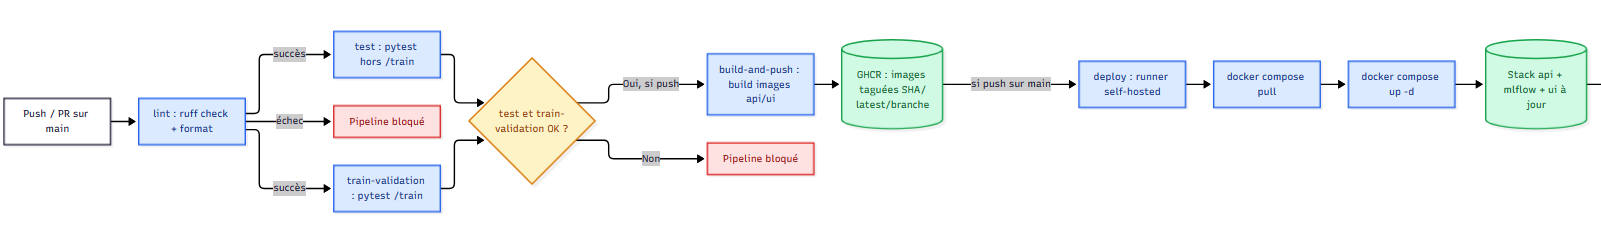
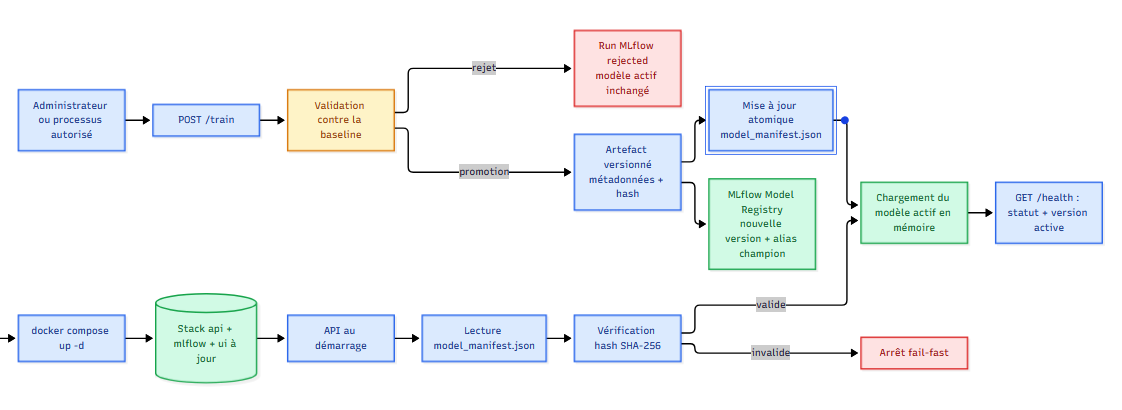

```mermaid
flowchart LR
    Push[Push / PR sur main] --> Lint[lint : ruff check + format]
    Lint -->|échec| StopLint[Pipeline bloqué]
    Lint -->|succès| Test[test : pytest hors /train]
    Lint -->|succès| Train[train-validation : pytest /train]

    Test --> Gate{test et train-validation OK ?}
    Train --> Gate
    Gate -->|Non| StopGate[Pipeline bloqué]
    Gate -->|Oui, si push| Build[build-and-push : build images api/ui]
    Build --> GHCR[(GHCR : images taguées SHA/latest/branche)]
    GHCR -->|si push sur main| Deploy[deploy : runner self-hosted]
    Deploy --> Pull[docker compose pull]
    Pull --> Up[docker compose up -d]
    Up --> Stack[(Stack api + mlflow + ui à jour)]

    Stack --> Startup[API au démarrage]
    Startup --> Manifest[Lecture model_manifest.json]
    Manifest --> Hash[Vérification hash SHA-256]
    Hash -->|valide| Active[Chargement du modèle actif en mémoire]
    Hash -->|invalide| StartupError[Arrêt fail-fast]
    Active --> Health[GET /health : statut + version active]

    Admin[Administrateur ou processus autorisé] --> TrainModel[POST /train]
    TrainModel --> Compare[Validation contre la baseline]
    Compare -->|rejet| Rejected[Run MLflow rejected<br/>modèle actif inchangé]
    Compare -->|promotion| Version[Artefact versionné<br/>métadonnées + hash]
    Version --> ManifestUpdate[Mise à jour atomique<br/>model_manifest.json]
    ManifestUpdate --> Active
    Version --> Registry[MLflow Model Registry<br/>nouvelle version + alias champion]

    classDef ok fill:#d1fae5,stroke:#16a34a,stroke-width:2px,color:#166534
    classDef error fill:#fee2e2,stroke:#dc2626,stroke-width:2px,color:#991b1b
    classDef process fill:#dbeafe,stroke:#2563eb,stroke-width:2px,color:#1e3a8a
    classDef decision fill:#fef3c7,stroke:#d97706,stroke-width:2px,color:#92400e
    classDef version fill:#f3e8ff,stroke:#7e22ce,stroke-width:2px,color:#581c87

    class Stack,GHCR,Active,Registry ok
    class StopLint,StopGate,StartupError,Rejected error
    class Lint,Test,Train,Build,Deploy,Pull,Up,Startup,Manifest,Hash,Health,Admin,TrainModel,Version,ManifestUpdate process
    class Gate,Compare decision
```

Le workflow `.github/workflows/ci.yml` comprend cinq jobs, chacun conditionné à la réussite du précédent :

- **`lint`** : à chaque push et pull request, vérifie le style et la qualité du code avec `ruff check` et `ruff format --check` (configuration dans `ruff.toml`). Bloque toute la suite si le code n'est pas conforme.
- **`test`** (`needs: lint`) : installe `app/requirements.txt` + `pytest`/`httpx` et exécute les tests unitaires de l'API hors entraînement (`pytest -k "not train"`).
- **`train-validation`** (`needs: lint`, en parallèle de `test`) : exécute spécifiquement les tests de la route `/train` (`pytest -k "train"`) — promotion du modèle, comparaison à la baseline `f1_macro`, tolérance de dégradation — pour garantir la reproductibilité du pipeline d'entraînement avant toute mise en production.
- **`build-and-push`** (`needs: [test, train-validation]`) : uniquement sur push vers `main` ou tag `v*`. Construit les images `api` et `ui` en parallèle (matrice) et les publie sur GitHub Container Registry (GHCR), taguées avec le SHA du commit, `latest` et la branche/tag, pour pouvoir tracer précisément une version déployée. Cette étape versionne le logiciel et son environnement d'exécution, elle ne promeut pas à elle seule un artefact de modèle.
- **`deploy`** (`needs: build-and-push`) : uniquement sur push vers `main`. S'exécute sur un **runner self-hosted** installé sur la machine cible (choix retenu ici faute d'infrastructure cloud dédiée pour ce cas d'usage de certification), s'authentifie à GHCR puis relance la stack via `docker compose -f docker-compose.prod.yml pull` + `up -d`, garantissant un déploiement reproductible et traçable (image identifiée par son SHA de commit) à chaque mise à jour de `main`. Le modèle effectivement servi reste celui désigné par `model_manifest.json` et validé au démarrage.

Le versionnement des images et celui des modèles sont distincts : l'image Docker est identifiée par le SHA du commit, tandis que le modèle servi est identifié par sa version d'artefact, son manifeste local et son hash SHA-256. MLflow conserve les runs et les versions du registre. Le déploiement d'une image ne promeut donc pas automatiquement un nouveau modèle : la promotion, le rejet et le rollback restent gérés par le flux `/train` et le manifeste.

Déclencheurs : `push` sur `main`, tags `v*`, `pull_request` vers `main`, et déclenchement manuel (`workflow_dispatch`).

##### Exemple d'un run lors d'une action `push` :

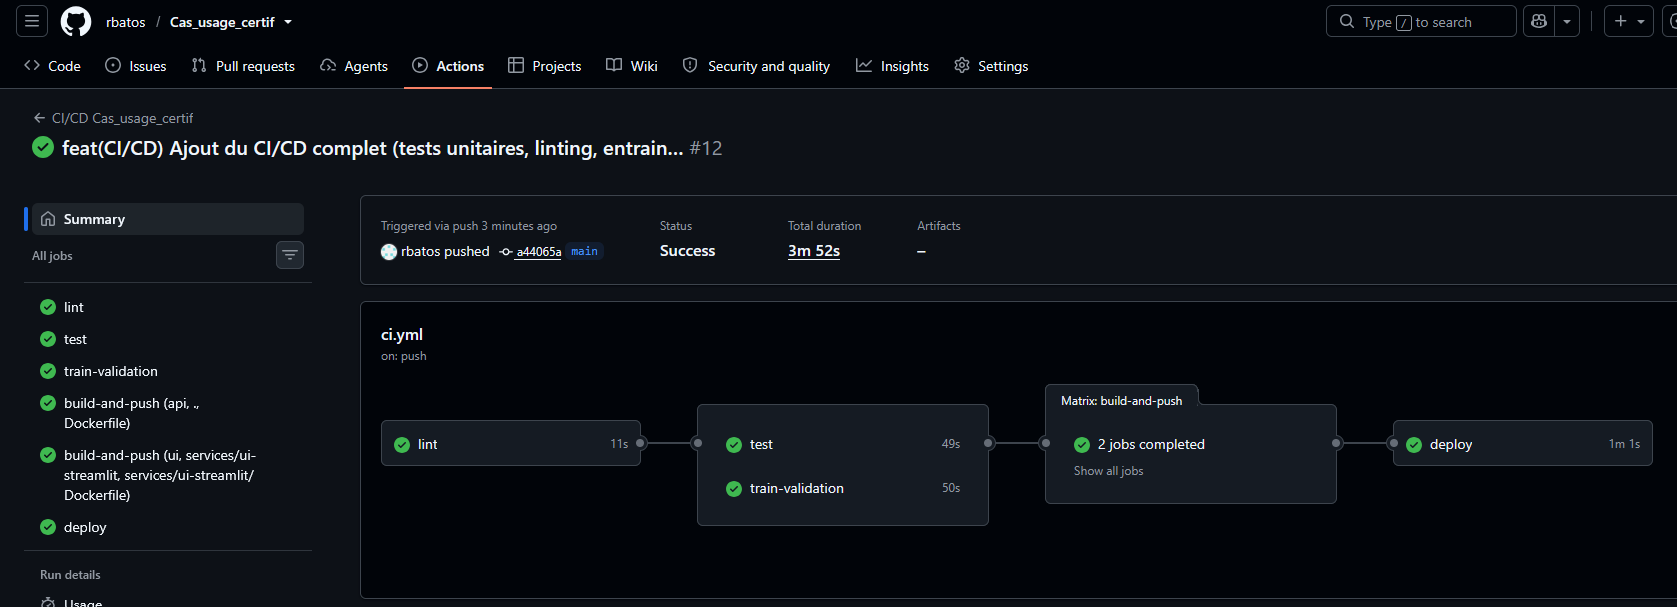


### 8.7 Performance/coût d'inférence, choix d'hébergement et dimensionnement

#### Rapport performance / coût computationnel d'inférence

Les mesures du chapitre 5.6 (500 dossiers, machine locale) donnent, pour le modèle retenu (LightGBM, scénario S1 multimodal) :

| Modèle | Latence moyenne | Latence p95 | Coût estimé /1000 prédictions* |
|---|---:|---:|---:|
| LightGBM (retenu) | ~15 ms | 23,6 ms | 0,013 € |
| LogisticRegression | ~10 ms | 13,6 ms | 0,001 € |
| RandomForest | ~80 ms | 122,8 ms | 0,014 € |

*Hypothèse simplifiée à 0,50 €/heure CPU (cf 5.6), hors stockage, réseau, supervision.

Le coût d'inférence par prédiction est négligeable pour les trois modèles (quelques millisecondes de calcul CPU, pas de GPU requis). Le modèle multimodal combine des transformations peu coûteuses à l'inférence (TF-IDF creux car la matrice contient surtout des zéros, one-hot, standardisation) avec un classifieur d'arbres (LightGBM) qui reste rapide même avec plusieurs centaines d'arbres. Le principal facteur de coût n'est donc pas le calcul unitaire, mais la disponibilité continue de l'API (temps de fonctionnement du conteneur, pas seulement le temps de calcul par requête).

#### Choix de l'infrastructure d'hébergement

| Critère | On-premise | Cloud souverain (ex. OVHcloud, Outscale, S3NS) |
|---|---|---|
| Confidentialité des données publiques | Maîtrise totale de la localisation et de l'accès physique aux données (usagers, synthèses d'entretien) | Hébergement en France/UE avec garanties contractuelles (SecNumCloud, immunité aux lois extraterritoriales), mais dépendance à un tiers |
| Charge de calcul | Faible (modèle CPU léger, pas de GPU) : ne justifie pas un investissement matériel dédié à lui seul | Élasticité à la demande, mutualisation avec d'autres services de l'agence |
| Exploitation | Nécessite une équipe infra interne pour la disponibilité, les mises à jour de sécurité, la sauvegarde | Service managé (Kubernetes, registre de conteneurs), astreinte simplifiée |
| Conformité réglementaire | Alignement naturel avec l'AI Act et le RGPD pour un système à haut risque du secteur public | Nécessite un fournisseur qualifié SecNumCloud pour un niveau de garantie équivalent |
| Coût | dépenses d’investissement initiales : serveurs, dépenses de fonctionnement récurrentes de maintenance (acheter puis entretenir) | dépenses de fonctionnement récurrentes, pas d'investissement matériel initial (louer et payer régulièrement) |

**Recommandation** : compte tenu de la nature du cas d'usage (service public, données sensibles sur des demandeurs d'emploi, système potentiellement à haut risque au sens de l'AI Act) et de la faible charge de calcul du modèle (pas de GPU, latence de quelques dizaines de ms), un hébergement en **Cloud souverain qualifié SecNumCloud** (qualification de sécurité délivrée par l'ANSSI) est privilégié : il apporte les garanties de confidentialité et de conformité réglementaire d'un hébergement maîtrisé, sans supporter le coût et la charge opérationnelle d'une infrastructure on-premise dédiée à un service dont les besoins CPU/RAM restent modestes. L'option on-premise reste une alternative légitime si l'agence dispose déjà d'un datacenter interne qualifié et d'une équipe d'exploitation, auquel cas elle éviterait toute dépendance à un fournisseur externe.

#### Latence acceptable en entretien de face-à-face

Un entretien conseiller/usager impose une contrainte d'interaction en temps réel : le conseiller consulte la recommandation pendant que l'usager est en face de lui, sans temps mort perceptible qui dégraderait la qualité de l'échange. Sur cette base :

- **Cible retenue** : `P50 < 250 ms` et `P95 < 500 ms` bout en bout (réseau + API + rendu UI), cohérente avec la cible fixée en §1.4/§3.7.
- **Justification** : au-delà d'environ 300-400 ms, un temps de réponse commence à être perçu comme un temps d'attente par l'utilisateur (seuils classiques d'interaction homme-machine). En entretien, un délai supérieur à la seconde obligerait le conseiller à meubler le silence ou à interrompre le fil de la conversation.
- **Marge disponible** : les latences mesurées au chapitre 5.6 (13 à 25 ms pour LightGBM et LogisticRegression) laissent une marge très confortable pour absorber la latence réseau, l'authentification et le rendu côté guichet unique, même dans un déploiement Cloud souverain distant du poste du conseiller.

#### Dimensionnement des ressources (CPU/RAM)

Le modèle servi est un pipeline scikit-learn/LightGBM CPU-only, sans dépendance GPU. Le dimensionnement peut donc rester modeste :

| Ressource | Dimensionnement proposé | Justification |
|---|---|---|
| CPU | 1 à 2 vCPU par instance API | Chaque prédiction consomme quelques millisecondes de CPU (cf 5.6), 1-2 vCPU suffisent pour absorber les pics de guichet (plusieurs conseillers en simultané) avec de la marge |
| RAM | 512 Mo à 1 Go par instance | L'artefact `.joblib` (préprocesseur + modèle) et les dépendances (scikit-learn, LightGBM, pandas) tiennent largement dans cette enveloppe |
| Réplicas | 2 instances minimum | Haute disponibilité (bascule en cas de redémarrage/mise à jour) et répartition de charge entre agences |
| Scaling | Horizontal, basé sur le nombre de requêtes/s | Le calcul dépend du CPU et est rapide, la montée en charge se fait par ajout d'instances plutôt que par des instances plus grosses |

Ce dimensionnement reste une estimation de premier ordre : un test de charge représentatif (nombre de conseillers simultanés, pic en début/fin de journée) est nécessaire avant la mise en production pour valider ces ordres de grandeur.

### 8.8 Justifications des choix techniques

#### FastAPI plutôt que Flask

FastAPI a été retenu pour exposer l'API car il fournit nativement :

- la validation des données avec Pydantic
- la génération automatique du contrat OpenAPI
- une documentation interactive avec Swagger UI (`/docs`) et ReDoc (`/redoc`)
- une bonne intégration avec le typage Python
- une gestion adaptée des erreurs de validation avec des réponses HTTP `422`.

Flask aurait également permis de construire cette API, mais aurait nécessité l'ajout et la configuration de bibliothèques complémentaires pour obtenir un niveau équivalent de validation, de sérialisation et de documentation. FastAPI est donc retenu pour réduire le code d'intégration et rendre le contrat de l'API immédiatement vérifiable.

Ce choix ne repose pas uniquement sur la performance : les routes actuelles sont principalement synchrones et la simplicité du contrat, la validation et la documentation sont les critères déterminants.

#### MLflow plutôt qu'un fichier `experiments.md`

Un fichier `experiments.md` peut documenter manuellement quelques essais, mais il ne garantit pas une traçabilité structurée et systématique. Il ne permet pas facilement :

- d'enregistrer automatiquement les paramètres et les métriques
- de relier un entraînement à son artefact de modèle
- de comparer les runs dans une interface dédiée
- de conserver les entraînements rejetés
- de gérer plusieurs versions d'un modèle
- d'identifier de manière fiable la version active en production.

MLflow a donc été retenu pour compléter la sauvegarde locale Joblib. Chaque entraînement crée un run identifié, avec ses hyperparamètres, ses métriques, sa baseline, son statut de promotion et, lorsque le modèle est accepté, l'artefact du pipeline complet.

Le Model Registry et l'alias `champion` permettent ensuite de désigner explicitement la version promue. Un modèle rejeté reste consultable dans l'historique MLflow sans remplacer le modèle servi par l'API.

Le fichier `experiments.md` reste pertinent pour expliquer les décisions et les conclusions, mais il ne constitue pas un système de suivi expérimental suffisamment fiable à lui seul.

#### LightGBM plutôt que les autres modèles

LightGBM a été retenu après comparaison avec la régression logistique, Random Forest et XGBoost. Il offre le meilleur compromis observé entre :

- F1-score macro
- coût métier
- temps d'inférence
- capacité à exploiter les variables tabulaires et les variables TF-IDF
- coût d'exploitation sur CPU.

La régression logistique reste une alternative plus simple et plus explicable, tandis que Random Forest offre un meilleur rappel de la classe 2 dans certains réglages. LightGBM est retenu car il fournit le compromis global le plus favorable pour le besoin métier.

#### Joblib pour la persistance du modèle

Joblib a été retenu car le modèle est un pipeline scikit-learn/LightGBM. Il permet de sauvegarder dans un même artefact le prétraitement, les imputations, les encodages, la vectorisation TF-IDF et le classifieur.

Cette solution garantit que les données sont transformées de la même manière lors de l'entraînement et de l'inférence. Elle est simple à intégrer dans l'API et compatible avec le déploiement Docker actuel.

MLflow conserve parallèlement l'artefact et son historique pour la traçabilité et le versioning. Joblib reste le format effectivement chargé par l'API afin de conserver la compatibilité avec l'architecture actuelle.

#### Streamlit pour l'interface conseiller

Streamlit a été retenu pour construire rapidement une interface interne de démonstration et de validation métier. Il permet de créer un formulaire Python directement connecté à l'API, avec peu de code et sans développer séparément un frontend JavaScript.

Ce choix est adapté à un prototype fonctionnel et à une démonstration. Pour une mise en production à grande échelle, une interface intégrée au système d'information métier serait préférable.

#### Docker et GitHub Actions

Docker garantit un environnement reproductible pour l’API, l’interface conseiller et le suivi MLflow. Deux images sont construites : `api` et `ui`. Le service MLflow réutilise l’image `api`, ce qui permet de déployer et de faire évoluer indépendamment le service de prédiction, l’interface conseiller et l’interface de suivi des entraînements.

GitHub Actions automatise l'exécution des tests et bloque la publication des images si les tests échouent. Le pipeline CI/CD réduit ainsi le risque de publier une version non vérifiée.

#### Pydantic, Uvicorn et Loguru

Pydantic est utilisé pour formaliser et valider les données d'entrée de l'API. Uvicorn sert de serveur ASGI (Asynchronous Server Gateway Interface) léger pour exécuter FastAPI. Loguru fournit une journalisation structurée avec identifiant de requête, durée et statut HTTP.

Ces outils complètent FastAPI en couvrant respectivement la validation, l'exécution du serveur et le suivi opérationnel des requêtes.

### 8.9 Synthèse industrialisation

#### Pile retenue

- **API** : FastAPI + Uvicorn, pipeline scikit-learn/LightGBM chargé via `joblib` depuis l'artefact désigné par `models/model_manifest.json`, vérification du hash SHA-256, validation des entrées par Pydantic et journalisation structurée avec Loguru (middleware `X-Request-ID`).
- **UI** : Streamlit, formulaire de saisie conseiller consommant `POST /predict` via `httpx`, formulaire de correction consommant `POST /feedback`, bouton de réentraînement consommant `POST /train`, ainsi que `GET /health` et `GET /history`.
- **Réentraînement UI** : le bouton « Lancer le réentraînement » appelle `POST /train` sans payload, avec un timeout dédié de 120 secondes. L’UI affiche le statut (`trained` ou `rejected`), les métriques, le nombre de feedbacks intégrés et la version promue.
- **Conteneurisation** : deux images Docker distinctes (`api`, `ui`), le service MLflow réutilise l'image `api`. Les services sont orchestrés par `docker-compose.yml` en local et `docker-compose.prod.yml` sur la cible de déploiement.
- **Suivi et registre des modèles** : MLflow Tracking et Model Registry conservent les runs, les artefacts, les versions et l'alias `champion`. Le manifeste local reste la référence opérationnelle effectivement chargée par l'API.
- **Données de feedback** : `POST /feedback` valide la correction du conseiller et l'ajoute à `data/feedback_conseillers.csv`. Ces corrections sont conservées sans écraser les précédentes et réutilisées lors du prochain `POST /train`.
- **CI/CD** : GitHub Actions en 5 jobs chaînés — `lint` (ruff) → `test` + `train-validation` (pytest, en parallèle) → `build-and-push` (publication GHCR) → `deploy` (runner self-hosted, `docker compose pull/up` sur `docker-compose.prod.yml`).
- **Tests** : `pytest` + `TestClient` FastAPI, exécutés en local et en CI sur chaque push/pull request, avec un job dédié à la validation du pipeline d'entraînement et de la promotion ou du rejet.

#### Choix d'architecture

- **Réentraînement manuel et contrôlé** : `POST /train` est déclenché par le bouton de l’interface Streamlit ou par un processus d’administration autorisé. Après fusion du dataset local et des feedbacks enregistrés dans `data/feedback_conseillers.csv`, la route compare le résultat à la baseline, trace chaque tentative dans MLflow et ne promeut un modèle que s'il respecte le garde-fou anti-régression. En cas de promotion, un nouvel artefact Joblib versionné, ses métadonnées et son hash sont sauvegardés, puis `model_manifest.json` est mis à jour.
- **Contrôle d’accès** : la route `/train` ne possède actuellement pas d’authentification. Avant toute exposition hors d’un environnement de confiance, elle devra être protégée et réservée aux profils ou processus autorisés, avec journalisation de l’appel et de son résultat.
- **Versionnement séparé** : la version de l'image Docker est identifiée par le SHA du commit et les tags GHCR. La version du modèle servi est identifiée par l'artefact versionné, le manifeste local et le hash SHA-256. Le déploiement d'une nouvelle image ne constitue donc pas une promotion automatique d'un nouveau modèle.
- **Inférence, feedback et réentraînement en ligne** : au démarrage, le lifespan lit `model_manifest.json`, vérifie l'intégrité de l'artefact désigné et charge le pipeline `.joblib` actif en mémoire pour les prédictions. L'UI appelle `POST /predict`, affiche la classe et les probabilités, peut envoyer une correction via `POST /feedback`, puis déclencher `POST /train`. L'API enregistre les corrections dans `feedback_conseillers.csv` et réutilise le fichier lors de l’entraînement suivant.
- **Lifespan fail-fast** : le chargement du modèle au démarrage de l'API lève une exception si le manifeste, l'artefact ou le hash sont absents ou invalides, ce qui arrête le conteneur plutôt que de laisser tourner une API avec un modèle inutilisable.
- **Volumes Docker** : `models/`, `data/`, `logs/` et `mlruns/` sont montés en volumes plutôt qu'inclus dans l'image. Cela permet de conserver les artefacts versionnés, les données, les feedbacks, les logs et les runs MLflow sans reconstruire l'image, y compris sur la cible de déploiement.
- **Healthchecks** : l'API expose `/health`, l'UI `/_stcore/health` et MLflow est contrôlé sur le port `5000`. Compose attend spécifiquement que l'API soit saine avant de démarrer l'UI via `depends_on: condition: service_healthy`.
- **CI/CD à 5 jobs** : `build-and-push` ne s'exécute que si `test` et `train-validation` réussissent (`needs: [test, train-validation]`), eux-mêmes conditionnés à `lint`. La CI valide le logiciel et le pipeline d'entraînement, la promotion opérationnelle du modèle reste pilotée par `/train`, le manifeste et MLflow.
- **Déploiement sur runner self-hosted** : le job `deploy` tourne sur un runner GitHub Actions installé sur la machine cible et consomme les images GHCR taguées par SHA de commit. Au redémarrage, l'API recharge et valide le modèle désigné par `model_manifest.json`.

#### Points encore ouverts

- **Garde-fou de promotion incomplet** : la route `POST /train` décide actuellement de la promotion uniquement à partir du `f1_macro`. Le rappel de la classe 2 et le taux d’erreurs critiques `2 → 0` ne participent pas encore à cette décision.
- **Monitoring opérationnel incomplet** : il faut mettre en place un monitoring centralisé portant notamment sur la disponibilité, les erreurs HTTP, la latence, la distribution des prédictions, le volume de feedbacks, le rappel de la classe 2, les erreurs critiques `2 → 0`, le taux d’abstention et la dérive des données.
- **Validation humaine de la promotion absente** : la promotion d’un modèle est actuellement déclenchée automatiquement dès que le garde-fou technique est satisfait. Une approbation humaine devra être ajoutée avant la production.
- **Qualité des feedbacks à contrôler** : les corrections conseillers sont ajoutées au CSV et réutilisées lors des entraînements suivants. Il faudra prévoir une déduplication, un contrôle des valeurs, une traçabilité du conseiller et un audit des corrections.
- **Persistance MLflow non adaptée à la production** : les runs sont actuellement conservés dans `mlruns/`. La production devra s’appuyer sur un serveur MLflow persistant et sécurisé.
- **Procédure de rollback non validée** : les artefacts versionnés permettent théoriquement de revenir à un modèle antérieur, mais cette procédure doit encore être testée de bout en bout.
- **Surveillance des dérives non implémentée** : les logs et healthchecks renseignent sur le fonctionnement technique, mais les dérives des données et des performances ne sont pas encore détectées automatiquement.


---
## 9. Suivi en production & amélioration continue

### 9.1 Métriques à surveiller

Ce tableau définit les principaux indicateurs à surveiller en production, aussi bien pour la qualité du modèle que pour la disponibilité du service. Il précise les seuils devant déclencher une alerte et indique les sources nécessaires à leur mesure, même si une partie de ce monitoring reste encore à implémenter.

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | `f1_macro` de validation (à chaque `POST /train`) | < baseline - 0,02 (tolérance du garde-fou anti-régression déjà implémenté, `DEGRADATION_TOLERANCE` dans `app/main.py`) | Run MLflow (`log_training_run`) comparé à `models/train_metrics_baseline.json` |
| Modèle | Taux d'abstention (probabilité max < 0,65 ou écart top-2 < 15 %, cf §7.2) | > 20 % sur 4 semaines glissantes | `data/historique_inferences.csv` (à enrichir d'un champ `abstention`, cf §9.4) |
| Modèle | Erreurs critiques 2→0 (classe réelle « long » prédite « bas ») | > 0 détectée lors d'un audit mensuel des corrections | `data/feedback_conseillers.csv` (corrections conseillers via `POST /feedback`) |
| Données | PSI (Population Stability Index) sur `age`, `departement`, `code_rome_vise`, `nationalite_hors_ue` et `est_allocataire` | > 0,2 | Batch journalier à mettre en place (non implémenté à ce jour, cf §9.3) |
| Système | Latence p95 API | > 500 ms (cible fixée en §8.7) | `logs/api.log` (middleware `X-Request-ID`), exportable vers Prometheus |
| Système | Disponibilité | `GET /health` renvoie `status="degraded"` de façon répétée | `HEALTHCHECK` Docker (`docker-compose.yml`/`docker-compose.prod.yml`) |
| CI/CD | Échec du job `train-validation` sur push vers `main` | Bloque automatiquement `build-and-push` et `deploy` | GitHub Actions (cf §8.6) |

 > **Limite actuelle avant mise en production** : le `recall` de la classe 2 et l’erreur critique `2 → 0` sont identifiés comme des métriques prioritaires, mais ne sont pas encore utilisés comme conditions automatiques de promotion dans `POST /train`. Leur intégration à la baseline et au garde-fou anti-régression constitue un prérequis de mise en production.

### 9.2 Boucle de rétroaction

Le circuit de rétroaction actuel repose principalement sur deux routes de l’API et sur le formulaire de correction de l’interface Streamlit :

1. **Collecte depuis l’UI** : après une prédiction, le conseiller peut ouvrir le formulaire de correction dans l’interface Streamlit, sélectionner la classe réellement constatée et ajouter un commentaire facultatif. L’UI transmet alors les caractéristiques du dossier, la classe initialement prédite, la classe corrigée et le commentaire à `POST /feedback`.
2. **Validation et stockage** : l’API valide le payload avec Pydantic, ajoute la correction à `data/feedback_conseillers.csv` sans écraser les corrections précédentes et renvoie une confirmation avec le nombre total de corrections stockées. L’UI affiche cette confirmation au conseiller.
3. **Intégration** : lors d’un appel à `POST /train`, l’API recharge l’ensemble des corrections enregistrées et les fusionne avec le dataset initial avant l’entraînement de validation. Les corrections restent conservées dans le fichier CSV et sont donc réutilisées lors des réentraînements suivants.
4. **Garde-fou avant promotion** : le nouveau modèle n’est promu que si son `f1_macro` ne se dégrade pas de plus de 0,02 par rapport à la baseline. Lorsqu’il est accepté, un nouvel artefact Joblib versionné est créé, le manifeste est mis à jour et l’alias MLflow `champion` est déplacé. Ce garde-fou reste incomplet, car il ne contrôle pas encore le rappel de la classe 2 ni les erreurs critiques `2 → 0`.
5. **Traçabilité** : chaque tentative de réentraînement acceptée ou rejetée crée un run MLflow contenant notamment les métriques, le statut de promotion et le nombre de lignes de feedback intégrées (`feedback_rows`).

La collecte est désormais accessible depuis l’interface Streamlit, mais la boucle reste actuellement manuelle : `POST /train` n’est déclenché par aucun ordonnanceur. De plus, les corrections ne font l’objet ni d’un audit préalable, ni d’une déduplication, ni d’un suivi de leur qualité. Des corrections erronées, dupliquées ou biaisées pourraient donc influencer progressivement le modèle malgré le garde-fou actuel.

### 9.3 Plan de réentraînement

**Déclencheurs (triggers) envisagés** :
- **Calendaire** : réentraînement hebdomadaire ou mensuel systématique, pour absorber régulièrement les corrections accumulées même en l'absence de signal de dérive.
- **Volume de nouvelles données** : déclenchement dès que `feedback_conseillers.csv` atteint un seuil de nouvelles lignes (ex. 50 corrections), pour ne pas laisser un lot de corrections dormir trop longtemps.
- **Performance** : déclenchement si le taux d'abstention (§9.4) ou le PSI (§9.1) dépasse son seuil d'alerte, en plus du cycle calendaire.

**Automatisation actuelle vs cible** :
- *Aujourd'hui* : `POST /train` est déclenché manuellement (aucune authentification ni planification, cf §8.9 « points ouverts »). Le garde-fou anti-régression (`f1_macro` vs baseline) est automatique, mais rien ne déclenche l'appel lui-même.
- *Cible* : un job planifié (`cron` côté infrastructure ou `on: schedule` GitHub Actions) appelle `POST /train` sur un environnement protégé, publie le résultat (statut, métriques, `mlflow_run_id`) et **notifie un humain** en cas de promotion, avant toute bascule en production. Le pipeline CI/CD existant (`lint` → `test`/`train-validation` → `build-and-push` → `deploy`, cf §8.6) fournit déjà l'échafaudage de validation automatique. Il resterait à y ajouter une étape de réentraînement planifié suivie d'une **approbation manuelle obligatoire** avant que le modèle promu ne soit servi (ex. `environment: production` avec *required reviewers* sur GitHub, déjà supporté par la configuration actuelle du job `deploy`).
- **Validation avant mise en prod** : au minimum, contrôle du `f1_macro` par rapport à la baseline (déjà fait), et idéalement un audit du contenu de `feedback_conseillers.csv` intégré (détection de valeurs aberrantes ou d'un biais introduit par un seul conseiller) avant promotion.

### 9.4 Robustesse en exploitation

Le filet de sécurité conçu en §7.2 (seuil de confiance à 0,65, écart top-2 < 15 %, abstention HTTP 200) définit *où* le système doit s'arrêter et laisser la main au conseiller. Cette section précise comment cette mesure est (ou sera) instrumentée en exploitation, une fois le modèle déployé.

| Axe | Métrique opérationnelle | État actuel | Action automatique visée |
|---|---|---|---|
| **OOD (Out-Of-Distribution)** | Score de distance sur les variables numériques clés (`age`, `anciennete_poste_ans`) par rapport à la distribution du dataset d'entraînement (ex. distance de Mahalanobis ou score d'isolation) | Non implémenté : l'API ne calcule aujourd'hui aucun score de distribution, seule la validation Pydantic (bornes métier) filtre les entrées aberrantes | Ajouter un calcul de score OOD dans `request_to_features` (`app/main.py`), logger les dossiers hors distribution dans `logs/api.log`, et forcer l'abstention (statut « confiance insuffisante ») au-delà d'un seuil à calibrer sur le jeu d'entraînement |
| **Drift du seuil de rejet** | Taux d'abstention (probabilité max < 0,65 ou écart top-2 < 15 %) calculé sur une fenêtre glissante de 4 semaines | Le seuil est appliqué au moment de la prédiction (§7.2), mais le taux d'abstention n'est pas encore agrégé ni suivi dans le temps : `data/historique_inferences.csv` ne contient pas de champ dédié | Ajouter un champ `abstention` (booléen) à `historique_inferences.csv` et `HistoryEntry`/`HISTORY_COLUMNS` (`app/main.py`, `app/schemas.py`), puis calculer le taux d'abstention glissant, réviser le seuil de rejet si la dérive dépasse 20 % sur 4 semaines |
| **Calibration** | Brier score et courbe de calibration mensuelle sur les prédictions confirmées (dossiers avec feedback conseiller) | Non implémenté : aucune évaluation de calibration n'est réalisée après le déploiement, seul le `log_loss` est mesuré hors ligne lors de la comparaison de modèles (§5.3) | Calculer mensuellement le Brier score à partir des couples (probabilités prédites, classe corrigée dans `data/feedback_conseillers.csv`), recalibrer (Platt, isotonic) sans réentraîner tout le pipeline si seule la calibration dérive |

⚠️ La chaîne conception → exploitation doit rester explicite. §7.2 définit le filet de sécurité, §9.4 le surveille. Aujourd'hui, seul le seuil de rejet (§7.2) est réellement actif en production. L'OOD, le suivi du taux d'abstention dans le temps et la calibration sont conçus mais **pas encore mesurés** — un fallback conçu mais jamais mesuré correspond à un attendu C8 N3 non atteint, et constitue donc la priorité d'implémentation suivante avant une mise en production réelle.

### 9.5 Synthèse amélioration continue

- **Cadence de surveillance** : contrôle hebdomadaire du `f1_macro` de validation et du taux d'abstention, contrôle mensuel du PSI des variables clés, des erreurs critiques 2→0 et de la calibration, supervision continue de la latence p95 et de la disponibilité (`/health`).
- **Déclencheurs de réentraînement** : cycle calendaire (hebdomadaire/mensuel) combiné à un seuil de volume de nouvelles corrections et à un déclenchement sur dépassement des seuils d'alerte (§9.1/§9.4). Le garde-fou anti-régression (`DEGRADATION_TOLERANCE`) reste la condition sine qua non de promotion, quel que soit le déclencheur.
- **Plan de remédiation en cas de dérive** :
  1. Abstention/escalade immédiate côté API pour les cas concernés (déjà actif, §7.2).
  2. Analyse ciblée : PSI par variable, revue des feedbacks récents, comparaison des runs MLflow autour de la période de dérive suspectée.
  3. Réentraînement anticipé (hors cycle calendaire) si la dérive est confirmée, avec validation humaine avant promotion (§9.3).
  4. **Rollback** possible à tout moment vers la version précédente : redéployer l'image GHCR taguée par le SHA du commit précédent (`deploy`, cf §8.6) et/ou repositionner l'alias MLflow `champion` sur une version antérieure du Model Registry.
- **Limite actuelle assumée** : la boucle de réentraînement et la surveillance de dérive restent partiellement manuelles (déclenchement, audit des feedbacks), l'automatisation complète (planification + notification + validation humaine avant bascule) est identifiée comme prochaine étape et n'est pas encore implémentée.

---
# 📎 Annexes

## A. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

TODO??? A voir si je rajoute...

---

## A. Journal de bord

### 📅 Journal de bord – Jour 1 (16/07/2026)

#### 🔧 Étapes / Actions réalisées
- Analyse du sujet.
- Mise en place de Git ainsi que du squelette du projet, avec un commit initial.
- Création du notebook avec un environnement virtuel fonctionnel et un fichier `requirements.txt`, importation des bibliothèques pour l’EDA et ajout de la traçabilité.
- Création d’un README à enrichir au fur et à mesure.

#### 📝 Observations / Difficultés
- Jeu de données relativement petit : seulement 2 500 lignes.
- Données issues d’une seule agence et donc d’un seul bassin d’emploi. Cela peut constituer un biais en fonction du bassin d’emploi.

#### ✅ Prochaines étapes
- Analyse du jeu de données.
- EDA du jeu de données.

---

### 📅 Journal de bord – Jour 2 (20/07/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’analyse du sujet.
- Poursuite du notebook avec le chapitre `1. Cadrage métier & problème`.
- Début de l’EDA.

#### 📝 Observations / Difficultés
- Plusieurs variables sensibles nécessiteront une attention particulière.

#### ✅ Prochaines étapes
- Suite de l’EDA.

---

### 📅 Journal de bord – Jour 3 (21/07/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l'EDA

#### 📝 Observations / Difficultés
- Des valeurs incohérentes ont été détectées, il va falloir prévoir un traitement.

#### ✅ Prochaines étapes
- Suite de l'EDA

---

### 📅 Journal de bord – Jour 4 (22/07/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’EDA.

#### 📝 Observations / Difficultés
- Recherche de représentations pertinentes pour compléter l’EDA.

#### ✅ Prochaines étapes
- Suite de l’EDA : analyse de la discrimination pour repérer les biais liés aux variables sensibles.

---

### 📅 Journal de bord – Jour 5 (04/08/2026)

#### 🔧 Étapes / Actions réalisées
- Relecture.
- Suite et fin de l’EDA.
- Début de la préparation des données.

#### 📝 Observations / Difficultés
- De nombreux prétraitements sont nécessaires : il faudra rester organisé et veiller à tous les effectuer.
- Prendre en compte toutes les demandes de l’énoncé.

#### ✅ Prochaines étapes
- Suite de la préparation des données.

---

### 📅 Journal de bord – Jour 6 (05/08/2026)

### 🔧 Étapes / Actions réalisées
- Suite et fin de la préparation des données, dans le respect des quatre scénarios fournis dans l’énoncé.
- Début de l’entraînement avec la sélection des quatre modèles les plus adaptés au cas d’usage.

#### 📝 Observations / Difficultés
- Difficulté à respecter la règle d’or pour la comparaison des modèles.

#### ✅ Prochaines étapes
- Suite de l’entraînement.

---

### 📅 Journal de bord – Jour 7 (06/08/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’entraînement.

#### 📝 Observations / Difficultés
- Des questionnements sont apparus lors des entraînements sur les hyperparamètres ainsi que sur le test final : faut-il utiliser un seul modèle, tous les modèles ou effectuer une première sélection des meilleurs modèles ?
- Le choix du modèle reste difficile et les résultats sont inférieurs à la cible fixée.

#### ✅ Prochaines étapes
- Relecture et modification de certains points concernant l’entraînement.
- Analyse des scénarios et arbitrage.
- Interprétation des résultats pour la communication avec le client.

---

### 📅 Journal de bord – Jour 8 (09/08/2026)

#### 🔧 Étapes / Actions réalisées
- Reprise complète du chapitre 5.5, dont les résultats ne sont pas satisfaisants. Après des recherches dans les cours, sur Internet et auprès de plusieurs LLM, je vais reprendre ce chapitre pour obtenir de meilleurs résultats.
- Utilisation de `class_weight`.
- Recherche d’hyperparamètres susceptibles d’améliorer les résultats, au vu des courbes d’apprentissage.

#### 📝 Observations / Difficultés
- Test de nouveaux paramètres, comme `class_weight`.
- N’étant pas satisfait du résultat final, je dois tester plusieurs modèles supplémentaires, et pas uniquement le meilleur modèle obtenu lors de l’entraînement. Je vais donc sélectionner quelques-uns des meilleurs modèles et les tester.
- Peut-être faudra-t-il revoir à la baisse la cible définie au début.

#### ✅ Prochaines étapes
- Évaluation finale des modèles sélectionnés et synthèse de la modélisation.

---

### 📅 Journal de bord – Jour 9 (18/08/2026)

#### 🔧 Étapes / Actions réalisées
- Sélection de trois modèles présentant les meilleurs résultats : deux modèles sélectionnés pour leur précision concernant l’erreur critique, et un modèle sélectionné pour son fonctionnement général, avec le meilleur F1-macro et une erreur critique acceptable.
- Réalisation des tests finaux.
- Révision de la cible après l’EDA. Après réflexion, au vu de l’EDA, certaines métriques sont difficiles à améliorer, car la classe critique est minoritaire et peu représentée dans les données.
- Retour au chapitre 5.6 pour ajouter le calcul de l’inférence au tableau 6.1.

#### 📝 Observations / Difficultés
- Difficulté à choisir le modèle, avec une hésitation entre l’optimisation du fonctionnement général et la minimisation de l’erreur critique. La formulation d’hypothèses de coût m’aide à prendre une décision.
- Mauvaise interprétation de l’EDA lors de la révision de la cible, ce qui a entraîné du travail supplémentaire et un retour en arrière.

#### ✅ Prochaines étapes
- Analyse des scénarios et arbitrages.

---

### 📅 Journal de bord – Jour 10 (14/09/2026)

#### 🔧 Étapes / Actions réalisées
- Analyse des scénarios et arbitrages.
- Relecture de l’énoncé pour vérifier que je n’oublie aucun point avant de passer à l’industrialisation.
- Ajout de la sauvegarde du pipeline complet (prétraitement et modèle entraîné), ainsi que des métadonnées.

#### 📝 Observations / Difficultés
- Calcul du coût d’inférence : je ne le calcule malheureusement pas pour tous les scénarios dans le code ; j’ai donc utilisé des estimations.
- Calcul de la latence p95 : je ne la mesure malheureusement pas de façon unitaire dans le code ; j’ai donc utilisé des estimations.
- Après relecture de l’énoncé, je me suis aperçu qu’il manquait quelques éléments. Je dois donc reprendre le travail effectué, effectuer une relecture approfondie et ajouter les points manquants.
- La présentation des critères de succès ne me plaît pas ; je l’ai donc reprise.
- Après relecture, je regrette de ne pas avoir davantage poussé les tests sur le scénario tabulaire seul, car il aurait pu être prometteur.

#### ✅ Prochaines étapes
- Interprétation des résultats pour la communication avec le client.
- Industrialisation.

---

### 📅 Journal de bord – Jour 11 (15/09/2026)

#### 🔧 Étapes / Actions réalisées
- Reprise des chapitres 1 à 6, car j’ai constaté que le scénario 2 avait été mal configuré. En effet, ce scénario exclut les variables sensibles, alors que j’avais considéré que le texte `synthese_entretien` ne constituait pas une variable sensible, car aucune des neuf synthèses différentes ne contient d’information sensible.
- Interprétation des résultats pour la communication avec le client.

#### 📝 Observations / Difficultés
- Une petite erreur peut faire perdre beaucoup de temps. Le scénario mal configuré m’a obligé à revoir le code, les commentaires ainsi que la conclusion.

#### ✅ Prochaines étapes
- Suite de l’interprétation des résultats pour la communication avec le client.
- Industrialisation.

---

### 📅 Journal de bord – Jour 12 (16/09/2026)

#### 🔧 Étapes / Actions réalisées
- Analyse de l’influence des variables sur la décision concernant le modèle sélectionné.
- Interprétation de ces éléments pour le client.
- Début de l’industrialisation avec la mise en place des routes `/health`, `/predict` et `/train`, ainsi que de leurs premiers tests.

#### 📝 Observations / Difficultés
- Difficulté à démarrer l’industrialisation et à mettre en place l’arborescence des dossiers.
- Difficulté à déterminer comment tester progressivement l’avancement de l’industrialisation.

Pour commencer, j’ai installé `uvicorn` afin de faire fonctionner l’application FastAPI (`.\\.venv\\Scripts\\python.exe -m uvicorn app.main:app --reload`).
La route `/health` répond correctement lorsque l’API est chargée.
![health.png](attachment:image.png)
La route `/predict` retourne une erreur lorsqu’une feature n’est pas conforme :
![predict1.png](attachment:image-2.png)
Dans le cas contraire, elle retourne la prédiction et les probabilités :
![predict2.png](attachment:image-3.png)

#### ✅ Prochaines étapes
- Suite de l’industrialisation.

---

### 📅 Journal de bord – Jour 13 (17/09/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’industrialisation.
- Ajout des dernières validations Pydantic.
- Ajout des journaux du middleware (requête HTTP et route de l’API) pour centraliser les logs avec Loguru.
- Ajout de tests fonctionnels avec pytest sur les routes.

#### 📝 Observations / Difficultés
- Exemple de logs du middleware :
```
2026-09-17 15:13:52.755 | INFO     | request_id=c0ed5dc1-9e25-455a-84bd-32a21a3bd3e5 | Requête reçue: GET /health
2026-09-17 15:13:52.756 | INFO     | request_id=c0ed5dc1-9e25-455a-84bd-32a21a3bd3e5 | Contrôle de santé: model_loaded=True
2026-09-17 15:13:52.757 | INFO     | request_id=c0ed5dc1-9e25-455a-84bd-32a21a3bd3e5 | Requête terminée: GET /health -> 200 (2.40 ms)
2026-09-17 15:13:52.768 | INFO     | request_id=24f0e296-b2d4-4c3d-905a-7e3a83e5fa6b | Requête reçue: POST /predict | paramètres={'age': 35, 'niveau_diplome': 'Bac+2', 'anciennete_poste_ans': 10, 'code_rome_vise': 'A1101', 'code_insee_commune': '75056', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 32}
2026-09-17 15:13:52.774 | INFO     | request_id=24f0e296-b2d4-4c3d-905a-7e3a83e5fa6b | Paramètres validés pour la prédiction: {'age': 35, 'niveau_diplome': 'Bac+2', 'anciennete_poste_ans': 10.0, 'code_rome_vise': 'A1101', 'code_insee_commune': '75056', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 32}
2026-09-17 15:13:52.776 | INFO     | request_id=24f0e296-b2d4-4c3d-905a-7e3a83e5fa6b | Prédiction retournée: retour_emploi=moyen probabilites={'bas': 0.1, 'moyen': 0.7, 'long': 0.2}
2026-09-17 15:13:52.777 | INFO     | request_id=24f0e296-b2d4-4c3d-905a-7e3a83e5fa6b | Requête terminée: POST /predict -> 200 (9.45 ms)
```
- Tests fonctionnels avec pytest (`.\\.venv\\Scripts\\python.exe -m pytest -v`) :
![pytest.png](attachment:image.png)

#### ✅ Prochaines étapes
- Suite de l’industrialisation.

---

### 📅 Journal de bord – Jour 14 (18/09/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’industrialisation.
- Reprise de la persistance du modèle afin d’inclure sa version dans le nom du fichier.

#### 📝 Observations / Difficultés
- Ajout d’une interface utilisateur pour la saisie du conseiller :
![UI_saisie.png](attachment:image.png)
![UI_reponse.png](attachment:image-2.png)
- Ajout de la conteneurisation.
- Ajout d’un premier schéma d’architecture :
![architecture.png](attachment:image-3.png)
- Début de la CI/CD avec deux jobs : `test` et `build-and-push`.

#### ✅ Prochaines étapes
- Suite de l’industrialisation : il reste à intégrer le suivi du modèle avec MLflow.
- Démarrage du suivi et de l’amélioration continue.

---

### 📅 Journal de bord – Jour 15 (20/09/2026)

#### 🔧 Étapes / Actions réalisées
- Suite de l’industrialisation.
- Ajout de la route de feedback, demandée dans l’énoncé.
- Ajout de la cartographie des flux de données.
- Ajout d’un chapitre intitulé « 8.7 Performance et coût d’inférence, choix de l’hébergement et dimensionnement » pour aborder ces différents points.
- Ajout d’une analyse de la non-discrimination algorithmique des profils.
- Ajout d’un point sur la responsabilité juridique.
- Ajout de la consultation de l’historique pour un conseiller, ainsi que de son stockage et de sa documentation.

#### 📝 Observations / Difficultés
- Lorsqu’on ajoute quelque chose au projet, comme la route de feedback, il faut penser à toutes les conséquences, notamment sur les tests et sur le notebook utilisé pour mettre à jour la documentation.
- Pour le moment, la seule façon pour un conseiller d’envoyer un feedback est d’utiliser une commande `curl`. Il faudrait ajouter cette option dans l’interface utilisateur.
- De même, l’ajout de l’historique a entraîné de nombreuses modifications :
![historique.png](attachment:image.png)

#### ✅ Prochaines étapes
- Suite de l’industrialisation en vérifiant les éléments demandés dans l’énoncé. Je vais devoir me concentrer sur les tâches essentielles, car le jour de la livraison approche et il reste encore beaucoup de travail, notamment la préparation de la présentation.
- Il reste les points suivants à développer :
    - suivi du modèle avec MLflow
    - démarche CI/CD complète
    - développement du chapitre 9 pour expliquer mes choix sur le suivi en production et l'amélioration continue.

---

### 📅 Journal de bord – Jour 16 (21/09/2026)

### 🔧 Étapes / Actions réalisées
- Ajout du suivi du modèle avec MLflow
- Ajout du CI/CD complet

#### 📝 Observations / Difficultés
- Le simple ajout d'une fonctionnalité demande maintenant beacoup de travail avec la relecture du chapitre 8 en entier et les modifications architecturale, des flux... que ça entraine.
![MLflow.png](attachment:image.png)
- CI/CD fonctionnel :
![ci-cd_complet.png](attachment:image-2.png)

#### ✅ Prochaines étapes
- Il reste les points suivants à développer :
    - développement du chapitre 9 pour expliquer mes choix sur le suivi en production et l'amélioration continue.
    - Préparation de la présentation!

---

### 📅 Journal de bord – Jour 17 (23 & 24/09/2026)

#### 🔧 Étapes / Actions réalisées
- Relecture complète du projet et du notebook.
- Rédaction du chapitre 9 consacré au suivi en production et à l’amélioration continue.

#### 📝 Observations / Difficultés
- La relecture a mis en évidence un point de vigilance concernant l’utilisation de variables sensibles, notamment `nationalite_hors_ue` et `age`. Une approche plus rigoureuse aurait consisté à étudier plus tôt un scénario intermédiaire excluant uniquement `nationalite_hors_ue`. Reprendre l’ensemble des expérimentations étant trop coûteux à ce stade, j’ai ajouté au chapitre 7.1 une analyse d’impact ciblée comparant le scénario S1 avec et sans cette variable. Les résultats et les limites observées m’ont conduit à conserver le scénario S1 complet pour la démonstration, tout en documentant ce choix.
- J’ai identifié une anomalie dans le nommage et le versionnement des modèles, dont la version restait fixée à `v1.0`. J’ai corrigé la logique afin d’incrémenter les versions lors des promotions et mis à jour la documentation associée. Cette évolution améliore la traçabilité des artefacts et facilite la mise en œuvre d’un rollback.
- Le garde-fou de promotion repose actuellement uniquement sur le `f1_macro`. Le rappel de la classe 2 et le taux d’erreurs critiques `2 → 0` devraient également être intégrés à la décision de promotion. Cette évolution n’est pas implémentée dans la démonstration, mais elle est identifiée comme un prérequis avant la mise en production dans la section 8.9 « Points encore ouverts ».
- Le projet dispose de logs, de healthchecks Docker et du suivi des entraînements dans MLflow, mais pas encore d’un monitoring opérationnel complet avec agrégation des métriques, tableaux de bord et alertes automatiques. Cette amélioration est également documentée comme un prérequis de mise en production. Elle pourra être ajoutée avant l’épreuve orale si le temps disponible le permet.
- L'UI ne donne pas la possibilité au conseiller de faire une feedback alors que c'est explicitement demandé dans l'énoncé. J'apporte les corrections nécessaire au code et modifie la documentation liée dans le notebook. -> dans la précipitation j'ai mal lu, tant pis c'est ajouté.
- L'UI ne donne pas la possibilité au conseiller d'appeler le réentrainement alors que c'est explicitement demandé dans l'énoncé. J'apporte les corrections nécessaire au code et modifie la documentation liée dans le notebook.
- La préparation de la présentation constitue un exercice moins familier pour moi. Je dois donc prévoir un temps spécifique pour structurer le discours, sélectionner les résultats essentiels et répéter la soutenance.

#### ✅ Prochaines étapes
- Effectuer une dernière relecture afin de finaliser le notebook livrable.
- Fusionner le journal-de-bord au notebook de livraison.
- Préparer les supports de présentation et répéter la soutenance.

---

### 📅 Journal de bord – Jour 18 (25++/09/2026)

#### 🔧 Étapes / Actions réalisées
- Préparation du livrable notebook.
- Préparation du support de présentation et de la soutenance.

#### 📝 Observations / Difficultés
- Pas mal de travail.

#### ✅ Prochaines étapes
- Livraison & soutenance.

---

## B. Code source de la partie industrialisation

Pour plus de simplicité le code qui suit est disponible sur le `Repositories` publique suivant :
https://github.com/rbatos/Cas_usage_certif

### B.1 API FastAPI
Présenter les routes /predict, /feedback, /train, /history et /health.

- `app/main.py` :
```python
"""API FastAPI pour la prédiction et l'entraînement du modèle emploi."""

import hashlib
import json
import re
import sys
from contextlib import asynccontextmanager
from datetime import datetime, timezone
from pathlib import Path
from threading import Lock

import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, Header, HTTPException, Request
from fastapi.openapi.docs import get_redoc_html
from lightgbm import LGBMClassifier
from loguru import logger
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

from app.middleware import RequestLoggingMiddleware
from app.mlflow_tracking import log_training_run
from app.schemas import (
    Demandeur,
    FeedbackCorrection,
    FeedbackResponse,
    HealthResponse,
    HistoryEntry,
    HistoryResponse,
    PredictionResponse,
    TrainResponse,
)

ROOT_DIR = Path(__file__).resolve().parents[1]
MODEL_PATH = ROOT_DIR / "models" / "modele_lgbm_v1.0_S1_multimodale_complete.joblib"
MODEL_MANIFEST_PATH = ROOT_DIR / "models" / "model_manifest.json"
MODEL_VERSION = "1.0"
MODEL_FILENAME_TEMPLATE = "modele_lgbm_v{version}_S1_multimodale_complete.joblib"
MODEL_METADATA_TEMPLATE = "modele_lgbm_v{version}_S1_multimodale_complete_metadata.json"
DATA_PATH = (
    ROOT_DIR
    / "data"
    / ("dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas " "- mai-oct2026 (Session-00279143).csv")
)
FEEDBACK_PATH = ROOT_DIR / "data" / "feedback_conseillers.csv"
HISTORY_PATH = ROOT_DIR / "data" / "historique_inferences.csv"
BASELINE_METRICS_PATH = ROOT_DIR / "models" / "train_metrics_baseline.json"
FEEDBACK_COLUMNS = [
    "age",
    "niveau_diplome",
    "anciennete_poste_ans",
    "code_rome_vise",
    "code_insee_commune",
    "est_allocataire",
    "nationalite_hors_ue",
    "synthese_entretien",
    "classe_predite",
    "classe_corrigee",
    "commentaire",
]
HISTORY_COLUMNS = [
    "horodatage",
    "request_id",
    "conseiller_id",
    "age",
    "niveau_diplome",
    "code_rome_vise",
    "departement",
    "retour_emploi",
    "probabilite_max",
]
# Tolérance de dégradation du f1_macro avant de refuser la promotion d'un nouveau modèle
DEGRADATION_TOLERANCE = 0.02

CLASS_LABELS = {0: "bas", 1: "moyen", 2: "long"}
REVERSE_CLASS_LABELS = {label: index for index, label in CLASS_LABELS.items()}
MODEL_LOCK = Lock()
FEEDBACK_LOCK = Lock()
HISTORY_LOCK = Lock()
pipeline_lgbm = None
model_load_error = None


def read_model_manifest() -> dict | None:
    """Retourne le manifeste du modèle actif, s'il existe et est valide."""
    if not MODEL_MANIFEST_PATH.exists():
        return None
    try:
        manifest = json.loads(MODEL_MANIFEST_PATH.read_text(encoding="utf-8"))
        model_path = Path(manifest["model_path"])
        if model_path.is_absolute() or ".." in model_path.parts:
            raise ValueError("Le chemin du modèle actif doit rester relatif au dossier models")
        if not manifest.get("model_version"):
            raise ValueError("La version du modèle actif est absente")
        return manifest
    except (OSError, ValueError, KeyError, json.JSONDecodeError) as error:
        raise ValueError(f"Manifeste du modèle invalide : {error}") from error


def resolve_active_model() -> tuple[Path, str]:
    """Résout le chemin et la version du modèle à charger."""
    manifest = read_model_manifest()
    if manifest is None:
        return MODEL_PATH, MODEL_VERSION
    return ROOT_DIR / "models" / manifest["model_path"], str(manifest["model_version"])


def next_model_version() -> str:
    """Calcule la prochaine version patch à partir du modèle actif et des artefacts présents."""
    model_directory = MODEL_MANIFEST_PATH.parent
    versions = []
    manifest = read_model_manifest()
    if manifest is not None:
        versions.append(str(manifest["model_version"]))
    versions.extend(
        match.group(1)
        for path in model_directory.glob("modele_lgbm_v*_S1_multimodale_complete.joblib")
        if (match := re.match(r"modele_lgbm_v(\d+\.\d+)_S1_multimodale_complete\.joblib", path.name))
    )
    major, minor = max((tuple(map(int, version.split("."))) for version in versions), default=(1, 0))
    return f"{major}.{minor + 1}"


def write_promoted_model_metadata(
    model_path: Path,
    version: str,
    metrics: dict[str, float],
    training_rows: int,
    pipeline: Pipeline,
    feature_columns: list[str],
) -> Path:
    """Écrit les metadata de l'artefact effectivement promu."""
    metadata_path = model_path.with_name(MODEL_METADATA_TEMPLATE.format(version=version))
    try:
        dataset_source = str(DATA_PATH.parent.relative_to(ROOT_DIR))
    except ValueError:
        dataset_source = str(DATA_PATH.parent)
    metadata = {
        "modele": "modele_lgbm",
        "model_version": version,
        "created_at": datetime.now(timezone.utc).isoformat(),
        "scenario": "S1_multimodale_complete",
        "chemin": str(model_path.relative_to(MODEL_MANIFEST_PATH.parent)),
        "python_version": sys.version.split()[0],
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "dataset": DATA_PATH.name,
        "dataset_source": dataset_source,
        "hyperparameters": pipeline.named_steps["modele"].get_params(),
        "metrics": metrics,
        "training_rows": training_rows,
        "features_columns": feature_columns,
        "target_column": "classe_retour_emploi",
    }
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return metadata_path


def write_model_manifest(model_path: Path, version: str, metadata_path: Path, mlflow_version: str | None) -> None:
    """Publie atomiquement la nouvelle référence du modèle actif."""
    manifest = {
        "model_version": version,
        "model_path": str(model_path.relative_to(MODEL_MANIFEST_PATH.parent)),
        "metadata_path": str(metadata_path.relative_to(MODEL_MANIFEST_PATH.parent)),
        "sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
        "mlflow_model_version": mlflow_version,
    }
    temporary_path = MODEL_MANIFEST_PATH.with_suffix(".tmp")
    temporary_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    temporary_path.replace(MODEL_MANIFEST_PATH)


# --- Loguru configuration ---------------------------------------------------
# Configuration Loguru (au démarrage du module)
LOGS_DIR = Path(__file__).parent.parent / "logs"
LOGS_DIR.mkdir(exist_ok=True)

logger.remove()  # vire le handler par défaut


def log_format(record):
    """Format compact qui supporte les messages contenant des dictionnaires."""
    request_id = record["extra"].get("request_id", "-")
    timestamp = record["time"].strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
    level = record["level"].name.ljust(8)
    message = record["message"].replace("{", "{{").replace("}", "}}")
    return f"<green>{timestamp}</green> | <level>{level}</level> | request_id={request_id} | {message}\n"


logger.add(sys.stderr, level="INFO", colorize=True, format=log_format)
# Configuration du log rotate
logger.add(
    LOGS_DIR / "api.log",
    rotation="10 MB",  # nouveau fichier à 10 Mo
    retention="7 days",  # garde 7 jours d'historique
    compression="gz",  # compresse les anciens fichiers
    format=log_format,
    enqueue=True,  # thread-safe
    level="INFO",
)


@asynccontextmanager
async def lifespan(app: FastAPI):
    """Charge le modèle au démarrage, le libère à l'arrêt.

    Politique fail-fast : si `load_model` échoue, l'exception remonte,
    Uvicorn s'arrête et le conteneur sort en erreur (pas d'API zombie
    qui répondrait OK avec un modèle cassé ou absent).
    """
    global pipeline_lgbm, MODEL_PATH, MODEL_VERSION
    load_model()
    yield
    pipeline_lgbm = None
    logger.info("Modèle libéré à l'arrêt de l'API")


app = FastAPI(
    title="API orientation retour à l'emploi",
    version="1.0.0",
    redoc_url=None,
    lifespan=lifespan,
)
app.add_middleware(RequestLoggingMiddleware)


@app.get("/redoc", include_in_schema=False)
def redoc_documentation():
    """Expose ReDoc avec une version stable du bundle JavaScript."""
    return get_redoc_html(
        openapi_url=app.openapi_url,
        title=f"{app.title} - ReDoc",
        redoc_js_url="https://cdn.jsdelivr.net/npm/redoc@latest/bundles/redoc.standalone.js",
    )


def flatten_text(values):
    """Transforme la colonne texte 2D en vecteur 1D pour TF-IDF.

    Args:
        values (np.ndarray): Colonne texte 2D.

    Returns:
        np.ndarray: Vecteur 1D aplati.
    """
    return values.ravel()


def load_model() -> None:
    """Charge le modèle actif en mémoire.

    Cette fonction met à jour les variables globales `pipeline_lgbm`,
    `MODEL_PATH` et `MODEL_VERSION`. En cas d'erreur, elle journalise
    l'erreur et relance l'exception.

    Raises:
        FileNotFoundError: Si le fichier modèle est absent.
        ValueError: Si le hash du modèle actif ne correspond pas au manifeste.
        OSError | EOFError | ImportError | AttributeError | ValueError | MemoryError:
            Si le désérialisation du modèle échoue.
    """
    global model_load_error, pipeline_lgbm, MODEL_PATH, MODEL_VERSION
    try:
        manifest = read_model_manifest()
        active_model_path, active_model_version = resolve_active_model()
        if manifest is not None and manifest.get("sha256"):
            actual_hash = hashlib.sha256(active_model_path.read_bytes()).hexdigest()
            if actual_hash != manifest["sha256"]:
                raise ValueError(f"Hash du modèle actif invalide : {active_model_path}")
    except ValueError as error:
        model_load_error = str(error)
        logger.error(model_load_error)
        raise
    MODEL_PATH = active_model_path
    MODEL_VERSION = active_model_version
    logger.info("Chargement du modèle v{}: {}", MODEL_VERSION, MODEL_PATH)
    if not MODEL_PATH.exists():
        model_load_error = f"Fichier modèle absent : {MODEL_PATH}"
        logger.error("Modèle introuvable: {}", MODEL_PATH)
        raise FileNotFoundError(model_load_error)
    try:
        pipeline_lgbm = joblib.load(MODEL_PATH)
        model_load_error = None
        logger.info("Modèle chargé avec succès")
    except (OSError, EOFError, ImportError, AttributeError, ValueError, MemoryError) as error:
        model_load_error = f"Chargement du modèle impossible : {error}"
        logger.exception("Échec du chargement du modèle")
        raise


def ensure_model_loaded() -> bool:
    """Recharge le modèle si le serveur n'a pas exécuté son démarrage.

    Contrairement au lifespan, on ne fait pas remonter l'exception ici :
    une requête isolée doit se solder par un 503, pas par un crash du worker.

    Returns:
        bool: True si le modèle est chargé en mémoire, False sinon.
    """
    if pipeline_lgbm is None:
        logger.debug("Modèle absent de la mémoire, tentative de chargement")
        with MODEL_LOCK:
            if pipeline_lgbm is None:
                try:
                    load_model()
                except Exception:
                    return False
    return pipeline_lgbm is not None


def request_to_features(request: Demandeur) -> pd.DataFrame:
    """Convertit le payload API dans le schéma attendu par le pipeline.

    Args:
        request (Demandeur): Objet représentant la requête API.

    Returns:
        pd.DataFrame: DataFrame contenant les features prêtes pour la prédiction.
    """
    logger.debug("Préparation des features pour la prédiction")
    payload = request.model_dump()
    code_insee = str(payload.pop("code_insee_commune"))
    payload["departement"] = code_insee[:2]
    for column in ("est_allocataire", "nationalite_hors_ue"):
        if isinstance(payload[column], str) and payload[column].isdigit():
            payload[column] = int(payload[column])
    return pd.DataFrame([payload])


@app.get("/health", response_model=HealthResponse)
def health() -> HealthResponse:
    """Point de terminaison pour vérifier l'état de santé de l'API.

    Returns:
        HealthResponse: Objet contenant le statut de santé et l'état de chargement du modèle.
    """
    loaded = ensure_model_loaded()
    logger.info("Contrôle de santé: model_loaded={}", loaded)
    return HealthResponse(
        status="ok" if loaded else "degraded",
        model_loaded=loaded,
        model_version=MODEL_VERSION,
    )


@app.post("/feedback", response_model=FeedbackResponse)
def submit_feedback(feedback: FeedbackCorrection) -> FeedbackResponse:
    """Enregistre la correction d'un conseiller pour le réentraînement monitoré.

    Args:
        feedback (FeedbackCorrection): Caractéristiques du dossier, classe prédite et classe corrigée.

    Returns:
        FeedbackResponse: Accusé de réception avec le total de corrections stockées.
    """
    row = pd.DataFrame([{column: getattr(feedback, column) for column in FEEDBACK_COLUMNS}])
    with FEEDBACK_LOCK:
        FEEDBACK_PATH.parent.mkdir(parents=True, exist_ok=True)
        row.to_csv(FEEDBACK_PATH, mode="a", header=not FEEDBACK_PATH.exists(), index=False)
        total_rows = len(pd.read_csv(FEEDBACK_PATH))
    logger.info(
        "Feedback conseiller enregistré: classe_predite={} classe_corrigee={}",
        feedback.classe_predite,
        feedback.classe_corrigee,
    )
    return FeedbackResponse(status="recorded", total_feedback_rows=total_rows)


@app.post("/predict", response_model=PredictionResponse)
def predict(
    request: Demandeur,
    http_request: Request,
    x_conseiller_id: str | None = Header(default=None, alias="X-Conseiller-ID"),
) -> PredictionResponse:
    """Point de terminaison pour effectuer une prédiction.

    Args:
        request (Demandeur): Objet représentant la requête API.
        http_request (Request): Requête HTTP brute, pour récupérer le request_id du middleware.
        x_conseiller_id (str | None): Identifiant optionnel du conseiller, pour l'historique.

    Returns:
        PredictionResponse: Objet contenant la classe prédite et les probabilités par classe.
    """
    request_data = request.model_dump(exclude={"synthese_entretien"})
    request_data["synthese_entretien_length"] = len(request.synthese_entretien)
    logger.info("Paramètres validés pour la prédiction: {}", request_data)
    if not ensure_model_loaded():
        logger.error("Prédiction impossible: modèle indisponible")
        raise HTTPException(
            status_code=503,
            detail=model_load_error or "Modèle indisponible",
        )

    features = request_to_features(request)
    with MODEL_LOCK:
        probabilities = pipeline_lgbm.predict_proba(features)[0]
        predicted_class = int(pipeline_lgbm.predict(features)[0])

    response = PredictionResponse(
        retour_emploi=CLASS_LABELS[predicted_class],
        probabilites={CLASS_LABELS[index]: float(probability) for index, probability in enumerate(probabilities)},
    )
    logger.info(
        "Prédiction retournée: retour_emploi={} probabilites={}",
        response.retour_emploi,
        response.probabilites,
    )
    save_history_entry(request, response, x_conseiller_id, http_request.state.request_id)
    return response


def save_history_entry(
    request: Demandeur,
    response: PredictionResponse,
    conseiller_id: str | None,
    request_id: str,
) -> None:
    """Ajoute une ligne à l'historique persistant des inférences.

    Échoue silencieusement (journalisé) plutôt que de faire échouer la prédiction :
    l'historique est une fonctionnalité de confort, pas critique pour la réponse.
    """
    row = pd.DataFrame(
        [
            {
                "horodatage": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                "request_id": request_id,
                "conseiller_id": conseiller_id or "inconnu",
                "age": request.age,
                "niveau_diplome": request.niveau_diplome,
                "code_rome_vise": request.code_rome_vise,
                "departement": str(request.code_insee_commune)[:2],
                "retour_emploi": response.retour_emploi,
                "probabilite_max": round(max(response.probabilites.values()), 3),
            }
        ]
    )
    try:
        with HISTORY_LOCK:
            HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
            row.to_csv(HISTORY_PATH, mode="a", header=not HISTORY_PATH.exists(), index=False)
    except OSError:
        logger.exception("Échec de l'écriture de l'historique des inférences")


@app.get("/history", response_model=HistoryResponse)
def get_history(conseiller_id: str | None = None, limit: int = 50) -> HistoryResponse:
    """Retourne l'historique persistant des inférences, du plus récent au plus ancien.

    Args:
        conseiller_id (str | None): Si fourni, ne renvoie que les prédictions de ce conseiller.
        limit (int): Nombre maximal de lignes retournées (défaut 50).

    Returns:
        HistoryResponse: Liste des prédictions passées correspondant aux filtres.
    """
    if not HISTORY_PATH.exists():
        return HistoryResponse(entries=[])
    with HISTORY_LOCK:
        history = pd.read_csv(
            HISTORY_PATH,
            dtype={
                "request_id": "string",
                "conseiller_id": "string",
                "niveau_diplome": "string",
                "code_rome_vise": "string",
                "departement": "string",
                "retour_emploi": "string",
            },
        )
    if conseiller_id:
        history = history[history["conseiller_id"] == conseiller_id]
    history = history.sort_values("horodatage", ascending=False).head(max(limit, 0))
    history = history.where(pd.notna(history), None)
    entries = [HistoryEntry(**row) for row in history.to_dict(orient="records")]
    return HistoryResponse(entries=entries)


def build_training_pipeline() -> Pipeline:
    """Reconstruit le même prétraitement que celui utilisé pour le modèle S1.

    Returns:
        Pipeline: Pipeline de prétraitement et de modèle prêt pour l'entraînement.
    """
    numeric_columns = ["age", "anciennete_poste_ans"]
    categorical_columns = [
        "nationalite_hors_ue",
        "est_allocataire",
        "code_rome_vise",
        "departement",
    ]
    ordinal_columns = ["niveau_diplome"]
    text_columns = ["synthese_entretien"]
    diploma_order = ["Sans diplôme", "Bac", "Bac+2", "Bac+5"]

    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    ordinal_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[diploma_order])),
        ]
    )
    text_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="constant", fill_value="")),
            ("to_1d", FunctionTransformer(flatten_text, validate=False)),
            ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1, 2))),
        ]
    )
    preprocessor = ColumnTransformer(
        [
            ("num", numeric_pipeline, numeric_columns),
            ("cat", categorical_pipeline, categorical_columns),
            ("ord", ordinal_pipeline, ordinal_columns),
            ("txt", text_pipeline, text_columns),
        ]
    )
    model = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.02,
        num_leaves=24,
        min_child_samples=10,
        colsample_bytree=0.7,
        random_state=42,
        verbosity=-1,
    )
    return Pipeline([("preparation", preprocessor), ("modele", model)])


def load_feedback_dataframe() -> pd.DataFrame:
    """Charge les corrections des conseillers au format du dataset d'entraînement.

    Returns:
        pd.DataFrame: Lignes de feedback prêtes à être fusionnées, vide si aucun feedback.
    """
    if not FEEDBACK_PATH.exists():
        return pd.DataFrame()
    feedback = pd.read_csv(FEEDBACK_PATH)
    if feedback.empty:
        return feedback
    feedback = feedback.rename(columns={"classe_corrigee": "classe_retour_emploi"})
    feedback["classe_retour_emploi"] = feedback["classe_retour_emploi"].map(REVERSE_CLASS_LABELS)
    feedback["usager_id"] = [f"FEEDBACK_{index}" for index in feedback.index]
    training_columns = [
        "usager_id",
        "age",
        "niveau_diplome",
        "anciennete_poste_ans",
        "code_rome_vise",
        "code_insee_commune",
        "est_allocataire",
        "nationalite_hors_ue",
        "synthese_entretien",
        "classe_retour_emploi",
    ]
    return feedback[training_columns]


def load_baseline_f1() -> float | None:
    """Lit le f1_macro du modèle actuellement en production, s'il a été mesuré.

    Returns:
        float | None: f1_macro de référence, ou None si aucune baseline n'existe encore.
    """
    if not BASELINE_METRICS_PATH.exists():
        return None
    try:
        return json.loads(BASELINE_METRICS_PATH.read_text())["f1_macro"]
    except (OSError, ValueError, KeyError):
        return None


@app.post("/train", response_model=TrainResponse)
def train() -> TrainResponse:
    """Point de terminaison pour réentraîner le modèle, feedback conseillers inclus.

    Le nouveau modèle n'est promu en production que si ses métriques de
    validation ne se dégradent pas significativement par rapport à la
    baseline en place (garde-fou anti-régression).

    Returns:
        TrainResponse: Statut, chemin du modèle, lignes utilisées, métriques et décision de promotion.
    """
    global pipeline_lgbm, MODEL_PATH, MODEL_VERSION
    logger.info("Début de l'entraînement monitoré")
    if not DATA_PATH.exists():
        logger.error("Jeu de données introuvable: {}", DATA_PATH)
        raise HTTPException(status_code=404, detail="Jeu de données introuvable")

    try:
        data = pd.read_csv(DATA_PATH)
        feedback_data = load_feedback_dataframe()
        if not feedback_data.empty:
            data = pd.concat([data, feedback_data], ignore_index=True)
        logger.info(
            "Jeu de données chargé: {} lignes ({} issues du feedback conseillers)",
            len(data),
            len(feedback_data),
        )
        target = "classe_retour_emploi"
        if target not in data.columns:
            raise ValueError(f"Colonne cible absente : {target}")

        features = data.drop(columns=[target]).copy()
        features["departement"] = features["code_insee_commune"].astype(str).str[:2]
        features = features.drop(columns=["code_insee_commune", "usager_id"], errors="ignore")
        if "age" in features and "anciennete_poste_ans" in features:
            inconsistent = (features["age"] - features["anciennete_poste_ans"]) <= 15
            features.loc[inconsistent, "anciennete_poste_ans"] = pd.NA

        X_train, X_val, y_train, y_val = train_test_split(
            features,
            data[target],
            test_size=0.2,
            random_state=42,
            stratify=data[target],
        )
        validation_pipeline = build_training_pipeline()
        validation_pipeline.fit(X_train, y_train)
        predictions = validation_pipeline.predict(X_val)
        metrics = {
            "accuracy": float(accuracy_score(y_val, predictions)),
            "f1_macro": float(f1_score(y_val, predictions, average="macro")),
        }
        baseline_f1 = load_baseline_f1()
        promoted = baseline_f1 is None or metrics["f1_macro"] >= baseline_f1 - DEGRADATION_TOLERANCE
        logger.info("Métriques de validation: {} (baseline f1_macro={})", metrics, baseline_f1)

        tracked_pipeline = validation_pipeline
        model_version = None

        if promoted:
            final_pipeline = build_training_pipeline()
            final_pipeline.fit(features, data[target])
            tracked_pipeline = final_pipeline

        mlflow_run_id, model_version = log_training_run(
            pipeline=tracked_pipeline,
            metrics=metrics,
            baseline_f1=baseline_f1,
            promoted=promoted,
            training_rows=len(features),
            feedback_rows=len(feedback_data),
        )

        if promoted:
            promoted_version = next_model_version()
            promoted_path = MODEL_MANIFEST_PATH.parent / MODEL_FILENAME_TEMPLATE.format(version=promoted_version)
            promoted_metadata_path = promoted_path.with_name(MODEL_METADATA_TEMPLATE.format(version=promoted_version))
            with MODEL_LOCK:
                joblib.dump(final_pipeline, promoted_path)
                write_promoted_model_metadata(
                    promoted_path,
                    promoted_version,
                    metrics,
                    len(features),
                    final_pipeline,
                    features.columns.tolist(),
                )
                write_model_manifest(promoted_path, promoted_version, promoted_metadata_path, model_version)
                MODEL_PATH = promoted_path
                MODEL_VERSION = promoted_version
                pipeline_lgbm = final_pipeline
            BASELINE_METRICS_PATH.write_text(json.dumps(metrics))
            logger.info(
                "Nouveau modèle promu: version {}, {} lignes, modèle sauvegardé",
                promoted_version,
                len(features),
            )
        else:
            logger.warning(
                "Modèle rejeté : f1_macro {} sous le seuil (baseline {} - tolérance {})",
                metrics["f1_macro"],
                baseline_f1,
                DEGRADATION_TOLERANCE,
            )
    except (OSError, ValueError, KeyError) as error:
        logger.exception("Échec de l'entraînement")
        raise HTTPException(status_code=422, detail=f"Entraînement impossible : {error}") from error

    return TrainResponse(
        status="trained" if promoted else "rejected",
        model_path=str(MODEL_PATH),
        training_rows=len(features),
        feedback_rows_used=len(feedback_data),
        metrics=metrics,
        promoted=promoted,
        mlflow_run_id=mlflow_run_id,
        model_version=model_version,
        artifact_version=MODEL_VERSION if promoted else None,
    )
```
- `app/schemas.py` :
```python
"""Schémas Pydantic d'entrée et sortie de l'API.

L'API attend les 8 features décrivant le demandeur d'emploi (hors `usager_id` qui n'entre pas dans le modèle)
et retourne la classe prédite + les probabilités associées.
Seul `niveau_diplome` est autorisée à être manquante
"""

from typing import Literal

from pydantic import BaseModel, ConfigDict, Field, model_validator

NiveauDiplome = Literal["Sans diplôme", "Bac", "Bac+2", "Bac+5"]
IndicateurBinaire = Literal["0", "1"]
RetourEmploi = Literal["bas", "moyen", "long"]


class Demandeur(BaseModel):
    """Données d'entrée d'une prédiction de retour à l'emploi.

    Les bornes des champs reflètent les plages observées dans le dataset
    d'entraînement et servent de garde-fou contre les entrées aberrantes.
    """

    model_config = ConfigDict(
        extra="forbid",
        str_strip_whitespace=True,
    )

    age: int = Field(ge=18, le=63, description="Âge observé dans le dataset : 18 à 63 ans")
    niveau_diplome: NiveauDiplome | None = Field(
        None,
        description="Valeurs possibles : Sans diplôme, Bac, Bac+2 ou Bac+5",
    )
    anciennete_poste_ans: float = Field(
        ge=0,
        le=30,
        description="Ancienneté observée dans le dataset : 0 à 30 ans",
    )
    code_rome_vise: str = Field(
        ...,
        min_length=5,
        max_length=5,
        pattern=r"^[A-Z][0-9]{4}$",
        description="Code ROME à 5 caractères",
    )
    code_insee_commune: str = Field(
        ...,
        min_length=4,
        max_length=5,
        pattern=r"^(?:[0-9]{4,5}|2[AB][0-9]{3})$",
        description="Code INSEE observé sur 4 ou 5 caractères",
    )
    est_allocataire: IndicateurBinaire = Field(
        ...,
        description="Valeurs possibles : 0 ou 1",
    )
    nationalite_hors_ue: IndicateurBinaire = Field(
        ...,
        description="Valeurs possibles : 0 ou 1",
    )
    synthese_entretien: str = Field(
        ...,
        min_length=1,
        description="Synthèse non vide de l'entretien",
    )

    @model_validator(mode="after")
    def validate_age_and_experience(self) -> "Demandeur":
        if self.age - self.anciennete_poste_ans <= 15:
            raise ValueError(
                "L'ancienneté est incompatible avec l'âge : le début d'activité doit être postérieur à 15 ans."
            )
        return self


class PredictionResponse(BaseModel):
    """Sortie d'une prédiction : classe + probabilités."""

    retour_emploi: RetourEmploi = Field(description="Classe prédite par le modèle.")
    probabilites: dict[RetourEmploi, float] = Field(
        description="Probabilité par classe (somme = 1.0).",
    )


class HealthResponse(BaseModel):
    """Sortie de la route /health."""

    status: Literal["ok", "degraded"] = Field(description="Statut global du service.")
    model_loaded: bool = Field(description="Vrai si le modèle est chargé en mémoire.")
    model_version: str = Field(description="Version du modèle chargé ou configuré.")


class FeedbackCorrection(Demandeur):
    """Correction d'un conseiller sur une prédiction du modèle, réinjectée au réentraînement."""

    classe_predite: RetourEmploi = Field(description="Classe initialement prédite par le modèle.")
    classe_corrigee: RetourEmploi = Field(description="Classe corrigée par le conseiller.")
    commentaire: str | None = Field(
        None,
        max_length=500,
        description="Commentaire libre du conseiller.",
    )


class FeedbackResponse(BaseModel):
    """Accusé de réception d'une correction conseiller."""

    status: Literal["recorded"] = Field(description="Statut de l'enregistrement.")
    total_feedback_rows: int = Field(description="Nombre total de corrections enregistrées à ce jour.")


class TrainResponse(BaseModel):
    """Résultat d'un réentraînement monitoré du modèle."""

    status: Literal["trained", "rejected"] = Field(
        description="'trained' si le nouveau modèle a été promu, 'rejected' s'il a été refusé après validation.",
    )
    model_path: str = Field(description="Chemin du modèle sauvegardé.")
    training_rows: int = Field(description="Nombre de lignes utilisées pour l'entraînement (dataset + feedback).")
    feedback_rows_used: int = Field(description="Nombre de corrections conseillers intégrées.")
    metrics: dict[str, float] = Field(description="Métriques de validation (accuracy, f1_macro).")
    promoted: bool = Field(description="Vrai si le nouveau modèle a remplacé le modèle en production.")
    mlflow_run_id: str | None = Field(default=None, description="Identifiant du run MLflow.")
    model_version: str | None = Field(
        default=None,
        description="Version MLflow enregistrée et affectée à l'alias champion si le modèle est promu.",
    )
    artifact_version: str | None = Field(
        default=None,
        description="Version locale immuable de l'artefact servi, par exemple 1.1.",
    )


class HistoryEntry(BaseModel):
    """Une ligne de l'historique persistant des inférences."""

    horodatage: str = Field(description="Date et heure de la prédiction (ISO 8601).")
    request_id: str = Field(description="Identifiant de corrélation de la requête.")
    conseiller_id: str = Field(description="Identifiant du conseiller, 'inconnu' si non fourni.")
    age: int
    niveau_diplome: str | None = None
    code_rome_vise: str
    departement: str
    retour_emploi: RetourEmploi
    probabilite_max: float


class HistoryResponse(BaseModel):
    """Historique des inférences, du plus récent au plus ancien."""

    entries: list[HistoryEntry] = Field(description="Prédictions passées, triées par date décroissante.")
```
- `app/middleware.py` :
```python
"""Middleware HTTP pour tracer les requêtes de l'API."""

import json
from time import perf_counter
from uuid import uuid4

from fastapi import Request, Response
from loguru import logger
from starlette.middleware.base import BaseHTTPMiddleware

REQUEST_ID_HEADER = "X-Request-ID"


async def read_request_parameters(request: Request) -> dict | None:
    """Lit un JSON de requête sans exposer les champs textuels sensibles."""
    content_type = request.headers.get("content-type", "")
    if "application/json" not in content_type:
        return None

    body = await request.body()

    async def replay_body():
        return {"type": "http.request", "body": body, "more_body": False}

    request._receive = replay_body
    try:
        parameters = json.loads(body) if body else {}
    except json.JSONDecodeError:
        return {"json_invalide": True, "taille_octets": len(body)}

    if not isinstance(parameters, dict):
        return {"json_objet_attendu": True}

    text_value = parameters.pop("synthese_entretien", None)
    if text_value is not None:
        parameters["synthese_entretien_length"] = len(text_value)
    return parameters


async def read_response_body(response: Response) -> Response:
    """Récupère le contenu d'une réponse streaming sans le perdre."""
    body = b"".join([chunk async for chunk in response.body_iterator])
    return Response(
        content=body,
        status_code=response.status_code,
        headers=dict(response.headers),
        media_type=response.media_type,
    )


def response_detail(response: Response) -> object | None:
    """Extrait le détail JSON d'une réponse d'erreur FastAPI."""
    try:
        payload = json.loads(response.body or b"{}")
    except (TypeError, json.JSONDecodeError):
        return None
    detail = payload.get("detail") if isinstance(payload, dict) else None
    if isinstance(detail, list):
        return [
            {key: error[key] for key in ("type", "loc", "msg") if key in error}
            for error in detail
            if isinstance(error, dict)
        ]
    return detail


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    """Ajoute un identifiant de corrélation et journalise chaque requête."""

    async def dispatch(self, request: Request, call_next) -> Response:
        request_id = request.headers.get(REQUEST_ID_HEADER) or str(uuid4())
        request.state.request_id = request_id
        started_at = perf_counter()

        with logger.contextualize(request_id=request_id):
            parameters = await read_request_parameters(request)
            if parameters is not None:
                logger.info(
                    "Requête reçue: {} {} | paramètres={}",
                    request.method,
                    request.url.path,
                    parameters,
                )
            else:
                logger.info("Requête reçue: {} {}", request.method, request.url.path)
            try:
                response = await call_next(request)
            except Exception:
                duration_ms = (perf_counter() - started_at) * 1000
                logger.exception(
                    "Requête en erreur: {} {} ({:.2f} ms)",
                    request.method,
                    request.url.path,
                    duration_ms,
                )
                raise

            if response.status_code >= 400:
                response = await read_response_body(response)
                detail = response_detail(response)
                if detail is not None:
                    logger.warning(
                        "Erreur HTTP: {} {} -> {} | détail={}",
                        request.method,
                        request.url.path,
                        response.status_code,
                        detail,
                    )

            duration_ms = (perf_counter() - started_at) * 1000
            response.headers[REQUEST_ID_HEADER] = request_id
            logger.info(
                "Requête terminée: {} {} -> {} ({:.2f} ms)",
                request.method,
                request.url.path,
                response.status_code,
                duration_ms,
            )
            return response
```
- `app/mlflow_tracking.py` :
```python
"""Suivi MLflow des entraînements et promotion contrôlée des modèles."""

import os
from pathlib import Path

import mlflow
from mlflow.tracking import MlflowClient

ROOT_DIR = Path(__file__).resolve().parents[1]
# Configuration MLflow par défaut et récupération des variables d'environnement.
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", (ROOT_DIR / "mlruns").as_uri())
# Nom de l'expérience MLflow, nom du modèle et alias par défaut.
MLFLOW_EXPERIMENT_NAME = os.getenv("MLFLOW_EXPERIMENT_NAME", "orientation-retour-emploi")
# Alias par défaut pour le modèle dans le registre MLflow.
MLFLOW_MODEL_NAME = os.getenv("MLFLOW_MODEL_NAME", "orientation-retour-emploi")
# Alias par défaut pour le modèle promu dans le registre MLflow.
MLFLOW_MODEL_ALIAS = os.getenv("MLFLOW_MODEL_ALIAS", "champion")


def configure_mlflow() -> None:
    """Configure le stockage local ou distant défini par l'environnement."""
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)


def log_training_run(
    pipeline,
    metrics: dict[str, float],
    baseline_f1: float | None,
    promoted: bool,
    training_rows: int,
    feedback_rows: int,
):
    """Trace un entraînement et enregistre un modèle accepté dans le registre MLflow.

    Args:
        pipeline: Pipeline scikit-learn entraîné.
        metrics: Dictionnaire des métriques de validation.
        baseline_f1: F1 macro du modèle de référence, si disponible.
        promoted: Vrai si le modèle a été promu.
        training_rows: Nombre de lignes utilisées pour l'entraînement.
        feedback_rows: Nombre de corrections conseillers intégrées.

    Returns:
        Tuple contenant l'ID du run MLflow et la version du modèle enregistré (ou None si non promu).
    """
    configure_mlflow()
    model_parameters = pipeline.named_steps["modele"].get_params()
    tracked_parameters = {
        key: value
        for key, value in model_parameters.items()
        if isinstance(value, (str, int, float, bool)) or value is None
    }
    tracked_parameters.update(
        {
            "training_rows": training_rows,
            "feedback_rows": feedback_rows,
        }
    )

    with mlflow.start_run() as run:
        mlflow.log_params(tracked_parameters)
        mlflow.log_metrics(metrics)
        if baseline_f1 is not None:
            mlflow.log_metric("baseline_f1_macro", baseline_f1)
        mlflow.set_tags(
            {
                "promotion_status": "promoted" if promoted else "rejected",
                "model_alias": MLFLOW_MODEL_ALIAS,
            }
        )

        model_version = None
        if promoted:
            mlflow.sklearn.log_model(pipeline, "model")
            registered = mlflow.register_model(
                f"runs:/{run.info.run_id}/model",
                MLFLOW_MODEL_NAME,
            )
            client = MlflowClient()
            client.set_registered_model_alias(
                MLFLOW_MODEL_NAME,
                MLFLOW_MODEL_ALIAS,
                registered.version,
            )
            model_version = str(registered.version)
            mlflow.set_tag("registered_model_version", model_version)

        return run.info.run_id, model_version
```
- `app/requirements.txt` :
```text
# Dépendances de l'API (image Docker) — sous-ensemble de requirements.txt
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.5.1
joblib==1.4.2
lightgbm==4.5.0
mlflow==2.17.2
pydantic==2.13.5
fastapi==0.115.6
loguru==0.7.3
uvicorn[standard]==0.34.0
```

### B.2 Interface utilisateur Streamlit
Présenter la saisie conseiller, l’affichage des probabilités, le feedback, l’historique et le réentraînement.

- `services/ui-streamlit/app.py` :
```python
"""UI Streamlit — saisie conseiller pour la prédiction de retour à l'emploi.

Permet à un conseiller de saisir les 8 features d'un demandeur d'emploi
et d'obtenir la classe prédite (bas / moyen / long) ainsi que les
probabilités associées, via l'API FastAPI du projet (`app/main.py`).

L'URL de l'API est dans la variable d'environnement `API_URL`
(par défaut `http://localhost:8000`, ou `http://api:8000` sous docker-compose).
"""

from __future__ import annotations

import os

import altair as alt
import httpx
import pandas as pd
import streamlit as st

API_URL: str = os.getenv("API_URL", "http://localhost:8000")
TIMEOUT_S = 10
TRAIN_TIMEOUT_S = 120

NIVEAUX_DIPLOME = ["Sans diplôme", "Bac", "Bac+2", "Bac+5"]
COULEUR_CLASSE = {"bas": st.success, "moyen": st.warning, "long": st.error}
ORDRE_CLASSES = ["bas", "moyen", "long"]

st.set_page_config(
    page_title="Orientation retour à l'emploi",
    page_icon="🧭",
    layout="centered",
)


def formater_erreur(detail) -> str:
    """Transforme un detail d'erreur FastAPI (str ou liste Pydantic) en texte lisible."""
    if isinstance(detail, str):
        return detail
    if isinstance(detail, list):
        lignes = []
        for erreur in detail:
            if isinstance(erreur, dict):
                champ = ".".join(str(p) for p in erreur.get("loc", []) if p != "body")
                message = erreur.get("msg", str(erreur))
                lignes.append(f"- **{champ}** : {message}" if champ else f"- {message}")
            else:
                lignes.append(f"- {erreur}")
        return "\n".join(lignes)
    return str(detail)


st.title("🧭 Orientation retour à l'emploi — saisie conseiller")
st.caption(
    "Renseigne les informations du demandeur d'emploi pour estimer son délai "
    "de retour à l'emploi (bas / moyen / long) et consulter les probabilités."
)

if "derniere_prediction" not in st.session_state:
    st.session_state.derniere_prediction = None
if "feedback_enregistre" not in st.session_state:
    st.session_state.feedback_enregistre = False

with st.sidebar:
    st.markdown("**Identifiant conseiller**")
    conseiller_id = st.text_input(
        "Identifiant conseiller",
        value="",
        placeholder="Ex : jdupont",
        label_visibility="collapsed",
        help="Utilisé pour retrouver ton historique de prédictions.",
    )
    lancer_entrainement = st.button(
        "Lancer le réentraînement",
        help="Réentraîne le modèle avec les corrections conseillers disponibles.",
    )

if lancer_entrainement:
    try:
        with st.spinner("Réentraînement en cours…"):
            reponse_entrainement = httpx.post(
                f"{API_URL}/train",
                timeout=TRAIN_TIMEOUT_S,
            )
            reponse_entrainement.raise_for_status()
            resultat_entrainement = reponse_entrainement.json()
    except httpx.ConnectError:
        st.error("Erreur de connexion : impossible de joindre l'API.")
    except httpx.TimeoutException:
        st.error(f"Réentraînement trop long : pas de réponse en {TRAIN_TIMEOUT_S} secondes.")
    except httpx.HTTPStatusError as exc:
        try:
            detail = exc.response.json().get("detail", exc.response.text)
        except ValueError:
            detail = exc.response.text
        st.error(f"Erreur {exc.response.status_code} :\n\n{formater_erreur(detail)}")
    except httpx.HTTPError as exc:
        st.error(f"Erreur HTTP : {exc}")
    else:
        statut = "promu en production" if resultat_entrainement["promoted"] else "refusé"
        st.success(
            f"Réentraînement terminé : modèle {statut}. "
            f"{resultat_entrainement['training_rows']} ligne(s) utilisées, "
            f"dont {resultat_entrainement['feedback_rows_used']} correction(s) conseiller."
        )
        st.json(
            {
                "Statut": resultat_entrainement["status"],
                "Version du modèle": resultat_entrainement.get("artifact_version"),
                "Accuracy": resultat_entrainement["metrics"].get("accuracy"),
                "F1 macro": resultat_entrainement["metrics"].get("f1_macro"),
            }
        )

with st.form("formulaire_demandeur"):
    col1, col2 = st.columns(2)
    with col1:
        age = st.number_input("Âge", min_value=18, max_value=63, value=30, step=1)
        anciennete_poste_ans = st.number_input(
            "Ancienneté au dernier poste (années)",
            min_value=0.0,
            max_value=30.0,
            value=2.0,
            step=0.5,
        )
        niveau_diplome = st.selectbox(
            "Niveau de diplôme",
            NIVEAUX_DIPLOME,
            index=1,
        )
        code_rome_vise = st.text_input(
            "Code ROME visé",
            value="",
            max_chars=5,
            placeholder="Ex : M1805",
        ).upper()
    with col2:
        code_insee_commune = st.text_input(
            "Code INSEE commune",
            value="",
            max_chars=5,
            placeholder="Ex : 75056",
        )
        est_allocataire = st.radio(
            "Allocataire",
            ["0", "1"],
            horizontal=True,
            format_func=lambda v: "Oui" if v == "1" else "Non",
        )
        nationalite_hors_ue = st.radio(
            "Nationalité hors UE",
            ["0", "1"],
            horizontal=True,
            format_func=lambda v: "Oui" if v == "1" else "Non",
        )

    synthese_entretien = st.text_area(
        "Synthèse de l'entretien",
        height=150,
        placeholder="Ex : Recherche active, mobile, formation en cours...",
    )

    valide = st.form_submit_button("Obtenir la prédiction", type="primary")

if valide:
    payload = {
        "age": int(age),
        "niveau_diplome": niveau_diplome,
        "anciennete_poste_ans": float(anciennete_poste_ans),
        "code_rome_vise": code_rome_vise,
        "code_insee_commune": code_insee_commune,
        "est_allocataire": est_allocataire,
        "nationalite_hors_ue": nationalite_hors_ue,
        "synthese_entretien": synthese_entretien,
    }
    try:
        with st.spinner("Prédiction en cours…"):
            headers = {"X-Conseiller-ID": conseiller_id} if conseiller_id else {}
            response = httpx.post(
                f"{API_URL}/predict",
                json=payload,
                headers=headers,
                timeout=TIMEOUT_S,
            )
            response.raise_for_status()
            data = response.json()
    except httpx.ConnectError:
        st.error("Erreur de connexion : impossible de joindre l'API.")
    except httpx.TimeoutException:
        st.error(f"API trop lente : pas de réponse en {TIMEOUT_S} secondes.")
    except httpx.HTTPStatusError as exc:
        try:
            detail = exc.response.json().get("detail", exc.response.text)
        except ValueError:
            detail = exc.response.text
        st.error(f"Erreur {exc.response.status_code} :\n\n{formater_erreur(detail)}")
    except httpx.HTTPError as exc:
        st.error(f"Erreur HTTP : {exc}")
    else:
        retour_emploi = data["retour_emploi"]
        st.session_state.derniere_prediction = {
            "payload": payload,
            "classe_predite": retour_emploi,
        }
        st.session_state.feedback_enregistre = False
        afficher = COULEUR_CLASSE.get(retour_emploi, st.info)
        afficher(f"Retour à l'emploi estimé : **{retour_emploi}**")
        probabilites = data["probabilites"]
        df_probas = pd.DataFrame(
            {
                "classe": [c for c in ORDRE_CLASSES if c in probabilites],
                "probabilite": [probabilites[c] for c in ORDRE_CLASSES if c in probabilites],
            }
        )
        # st.bar_chart trierait les catégories par ordre alphabétique : on force l'ordre via altair.
        chart = (
            alt.Chart(df_probas)
            .mark_bar()
            .encode(
                x=alt.X("classe", sort=ORDRE_CLASSES, title=None),
                y=alt.Y("probabilite", title="Probabilité"),
            )
        )
        st.altair_chart(chart, use_container_width=True)

derniere_prediction = st.session_state.derniere_prediction
if derniere_prediction is not None:
    st.subheader("Corriger la prédiction")
    st.caption(f"Classe initialement prédite : {derniere_prediction['classe_predite']}")
    with st.form("formulaire_feedback"):
        classe_corrigee = st.selectbox(
            "Classe réellement constatée",
            ORDRE_CLASSES,
            index=ORDRE_CLASSES.index(derniere_prediction["classe_predite"]),
        )
        commentaire = st.text_area(
            "Commentaire facultatif",
            max_chars=500,
            placeholder="Précisions sur la correction...",
        )
        envoyer_feedback = st.form_submit_button(
            "Enregistrer la correction",
            disabled=st.session_state.feedback_enregistre,
        )

    if envoyer_feedback:
        feedback_payload = {
            **derniere_prediction["payload"],
            "classe_predite": derniere_prediction["classe_predite"],
            "classe_corrigee": classe_corrigee,
            "commentaire": commentaire or None,
        }
        try:
            with st.spinner("Enregistrement de la correction..."):
                reponse_feedback = httpx.post(
                    f"{API_URL}/feedback",
                    json=feedback_payload,
                    timeout=TIMEOUT_S,
                )
                reponse_feedback.raise_for_status()
                resultat_feedback = reponse_feedback.json()
        except httpx.ConnectError:
            st.error("Erreur de connexion : impossible d'enregistrer la correction.")
        except httpx.TimeoutException:
            st.error(f"API trop lente : pas de réponse en {TIMEOUT_S} secondes.")
        except httpx.HTTPStatusError as exc:
            try:
                detail = exc.response.json().get("detail", exc.response.text)
            except ValueError:
                detail = exc.response.text
            st.error(f"Erreur {exc.response.status_code} :\n\n{formater_erreur(detail)}")
        except httpx.HTTPError as exc:
            st.error(f"Erreur HTTP : {exc}")
        else:
            st.session_state.feedback_enregistre = True
            st.success("Correction enregistrée. " f"Total : {resultat_feedback['total_feedback_rows']} correction(s).")

st.divider()
st.subheader("🕘 Historique des inférences")
col_bouton, col_limite = st.columns([1, 1])
with col_bouton:
    voir_historique = st.button("Charger l'historique", type="secondary")
with col_limite:
    limite_historique = st.number_input(
        "Nombre de lignes",
        min_value=5,
        max_value=200,
        value=50,
        step=5,
    )

if voir_historique:
    try:
        params = {"limit": int(limite_historique)}
        if conseiller_id:
            params["conseiller_id"] = conseiller_id
        with st.spinner("Chargement de l'historique…"):
            reponse_historique = httpx.get(f"{API_URL}/history", params=params, timeout=TIMEOUT_S)
            reponse_historique.raise_for_status()
            entries = reponse_historique.json().get("entries", [])
    except httpx.HTTPError as exc:
        st.error(f"Impossible de charger l'historique : {exc}")
    else:
        if not entries:
            st.info("Aucune prédiction enregistrée pour le moment.")
        else:
            st.dataframe(pd.DataFrame(entries), use_container_width=True, hide_index=True)

with httpx.Client(base_url=API_URL, timeout=2) as client:
    try:
        health = client.get("/health").json()
        healthy = health.get("model_loaded")
        st.sidebar.success("✅ API joignable" if healthy else "⚠️ API en chargement")
        st.sidebar.markdown(f"**Version du modèle** : `{health.get('model_version', 'inconnue')}`")
    except httpx.HTTPError:
        st.sidebar.error("❌ API injoignable")

with st.sidebar:
    st.markdown(f"**API URL** : `{API_URL}`")
    st.markdown(
        "**Champs requis** :\n"
        "- Âge, ancienneté, diplôme\n"
        "- Code ROME visé, code INSEE\n"
        "- Allocataire, nationalité hors UE\n"
        "- Synthèse d'entretien"
    )
```
- `services/ui-streamlit/requirements.txt` :
```text
streamlit==1.41.1
httpx==0.28.1
pandas==2.2.2
altair==5.5.0
```
- `services/ui-streamlit/Dockerfile` :
```dockerfile
FROM python:3.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    PIP_NO_CACHE_DIR=1

WORKDIR /app

COPY requirements.txt .
RUN pip install --upgrade pip && pip install -r requirements.txt

COPY app.py .

EXPOSE 8501

HEALTHCHECK --interval=10s --timeout=3s --start-period=20s --retries=3 \
    CMD python -c "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8501/_stcore/health').status==200 else 1)"

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.headless=true"]
```

### B.3 Persistance et versionnement des modèles
Présenter le manifeste, les métadonnées, la baseline et le registre des modèles.

- `models/model_manifest.json` :
```json
{
  "modele": "modele_lgbm",
  "model_version": "1.2",
  "created_at": "2026-09-24T15:25:42.551951+00:00",
  "scenario": "S1_multimodale_complete",
  "chemin": "modele_lgbm_v1.2_S1_multimodale_complete.joblib",
  "python_version": "3.11.16",
  "numpy_version": "1.26.4",
  "pandas_version": "2.2.2",
  "dataset": "dataset_trajectoire_emploi_Sujet Examen CISIA - Promo Upskilling Atlas - mai-oct2026 (Session-00279143).csv",
  "dataset_source": "data",
  "hyperparameters": {
    "boosting_type": "gbdt",
    "class_weight": null,
    "colsample_bytree": 0.7,
    "importance_type": "split",
    "learning_rate": 0.02,
    "max_depth": -1,
    "min_child_samples": 10,
    "min_child_weight": 0.001,
    "min_split_gain": 0.0,
    "n_estimators": 400,
    "n_jobs": null,
    "num_leaves": 24,
    "objective": null,
    "random_state": 42,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
    "subsample": 1.0,
    "subsample_for_bin": 200000,
    "subsample_freq": 0,
    "verbosity": -1
  },
  "metrics": {
    "accuracy": 0.7405189620758483,
    "f1_macro": 0.7109037406806911
  },
  "training_rows": 2501,
  "features_columns": [
    "age",
    "niveau_diplome",
    "anciennete_poste_ans",
    "code_rome_vise",
    "est_allocataire",
    "nationalite_hors_ue",
    "synthese_entretien",
    "departement"
  ],
  "target_column": "classe_retour_emploi"
}
```
- `models/registre_modeles_sauvegardes.csv` :
```csv
modele,scenario,chemin,temps_fit_s
modele_lgbm_v1.0,S1_multimodale_complete,..\models\modele_lgbm_v1.0_S1_multimodale_complete.joblib,1.787
modele_logreg_v1.0,S1_multimodale_complete,..\models\modele_logreg_v1.0_S1_multimodale_complete.joblib,0.384
modele_rfc_v1.0,S1_multimodale_complete,..\models\modele_rfc_v1.0_S1_multimodale_complete.joblib,0.838
```
- models/modele_lgbm_v1.2_S1_multimodale_complete.joblib => artefact entraîné


### B.4 Données d’exécution et journalisation
Présenter les fichiers produits ou consommés par l’API.

- `feedback_conseillers.csv` :
```csv
age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_predite,classe_corrigee,commentaire
42,Bac+5,2.0,M1805,78340,0,0,Personne débrouillarde et motivée,bas,moyen,Je pense que cette personne ne fera pas un retour si rapide sur le marché de l'emploi
```
- `historique_inferences.csv` :
```csv
horodatage,request_id,conseiller_id,age,niveau_diplome,code_rome_vise,departement,retour_emploi,probabilite_max
2026-09-20T20:46:22+00:00,9d8d6e62-abb6-4984-8595-bbfce7947605,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:46:22+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:47:22+00:00,e99b485c-5525-46b5-8ba0-6d2861e3b24a,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:47:22+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:48:09+00:00,caf58e54-5aae-42c0-a84d-ff70e0966b28,Romain,30,Bac,M1805,78,bas,0.498
2026-09-20T20:48:20+00:00,ef91849a-d769-4f97-b0a3-55a41ae061e9,Romain,30,Bac,M1805,78,moyen,0.758
2026-09-20T20:48:27+00:00,2c3d670e-a8fa-44f2-a3c5-88fff411b9ee,Romain,55,Bac,M1805,78,long,0.567
2026-09-20T20:50:43+00:00,34b2be38-090d-4287-9265-4524b64d1c16,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:50:43+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:51:07+00:00,4e0f5766-eead-46a7-90fe-04c4dbc4b7cb,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T20:51:07+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:20:38+00:00,d1fdcd4f-2e01-46c2-9bf0-238fc6a4726f,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:20:38+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:21:16+00:00,b602526e-7d56-418d-ad23-5220bab5b214,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:21:16+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:23:01+00:00,45dffabc-ab01-48e3-8ef0-71120d0d0a07,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:23:01+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:23:05+00:00,220e3b02-2f96-44c7-908e-6bcc5da44231,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-20T21:23:05+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:44:47+00:00,bb76d421-d878-49cc-be7e-cd6b3b19b0e5,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:44:47+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:45:35+00:00,6e131f1e-0857-45a4-8f12-f1e793c4c915,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:45:35+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:46:42+00:00,46d34ae9-c812-406f-ba3e-c61fa8bb562f,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:46:42+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:47:39+00:00,5412d93b-62b9-4083-b7f4-7de02ad4eb32,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:47:39+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:48:20+00:00,5c3404be-0fe1-48c0-b9c5-b0f594880b79,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:48:20+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:49:15+00:00,0d7111d3-80aa-46e6-87ea-f4d809d8c592,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:49:15+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:50:24+00:00,785463b4-3506-4c89-b93a-f434dd7e1065,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:50:24+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:50:57+00:00,0342f2b3-2a56-4ef4-bb36-d207f5a87548,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:50:58+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:51:21+00:00,cc868959-3726-4b27-9c97-0ca98eb26399,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:51:21+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:51:48+00:00,0307c2b1-ec04-4ca1-99ff-96e21af47421,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:51:48+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:52:41+00:00,ff25cf5c-ac49-43fe-9410-ef8804c78b83,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:52:41+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:53:12+00:00,e7370298-7000-4802-aa0d-ebf37cc28b85,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T11:53:12+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T13:46:23+00:00,48ef7cab-773d-4a96-9acc-97d42e18b52f,Romain,42,Bac+5,M1883,78,bas,0.912
2026-09-21T19:09:47+00:00,0429b96c-f4bd-4aa7-948a-4af3ac801ff0,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T19:09:47+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T19:10:43+00:00,7b9fb41c-c6ec-4b1c-84e3-7c96739b95e6,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-21T19:10:43+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T07:32:58+00:00,f7768c9d-43e8-4ba6-b27a-d3d6ce05fdbe,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T07:32:58+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T08:35:01+00:00,4cfd4de5-ec51-4cac-894c-c5203f8083dc,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T08:35:01+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T09:02:19+00:00,d61b2276-f7bc-4010-8db9-fc2031317f29,Romain,25,Bac+5,M1805,78,bas,0.953
2026-09-24T09:03:08+00:00,41f58aa9-0922-42c5-8694-95a2b1404e1e,Romain,22,Sans diplôme,M1805,78,moyen,0.687
2026-09-24T09:03:47+00:00,a44d4084-421b-4eb0-bbd0-cbd858986314,Romain,52,Sans diplôme,M1805,78,long,0.542
2026-09-24T09:04:12+00:00,5fc45491-edb5-4837-906b-5d2cf76e5f1a,Romain,52,Sans diplôme,M1805,78,long,0.53
2026-09-24T09:04:25+00:00,410a7aa5-0809-4792-85e0-42a65398691e,Romain,52,Sans diplôme,M5805,78,long,0.807
2026-09-24T14:23:31+00:00,5c9a66a0-3835-4986-8b60-3bd3801b1876,Romain,42,Bac+5,M1805,78,bas,0.957
2026-09-24T19:31:27+00:00,c1321201-052b-44f7-972a-688058a1d3f6,inconnu,35,Bac+2,A1101,75,moyen,0.7
2026-09-24T19:31:27+00:00,test-request-123,inconnu,35,Bac+2,A1101,75,moyen,0.7
```
- `data/dataset_trajectoire_emploi_....csv` :
Fichier fourni avec l'énoncé

- `api.log` :
```log
2026-09-18 13:58:20.963 | INFO     | request_id=ed1d92b4-3899-466a-a385-2207dc0af2b0 | Requête reçue: GET /health
2026-09-18 13:58:20.964 | INFO     | request_id=ed1d92b4-3899-466a-a385-2207dc0af2b0 | Contrôle de santé: model_loaded=True
2026-09-18 13:58:20.965 | INFO     | request_id=ed1d92b4-3899-466a-a385-2207dc0af2b0 | Requête terminée: GET /health -> 200 (1.69 ms)
2026-09-18 15:58:29.780 | INFO     | request_id=3709d4fe-208f-4645-b2e3-c1db5f2d5dfb | Requête reçue: POST /predict | paramètres={'age': 30, 'niveau_diplome': 'Bac', 'anciennete_poste_ans': 2.0, 'code_rome_vise': 'M1805', 'code_insee_commune': '78340', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 3}
2026-09-18 15:58:29.782 | INFO     | request_id=3709d4fe-208f-4645-b2e3-c1db5f2d5dfb | Paramètres validés pour la prédiction: {'age': 30, 'niveau_diplome': 'Bac', 'anciennete_poste_ans': 2.0, 'code_rome_vise': 'M1805', 'code_insee_commune': '78340', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 3}
2026-09-18 15:58:29.802 | INFO     | request_id=3709d4fe-208f-4645-b2e3-c1db5f2d5dfb | Prédiction retournée: retour_emploi=bas probabilites={'bas': 0.7915128547051482, 'moyen': 0.19579102794406075, 'long': 0.012696117350790986}
2026-09-18 15:58:29.804 | INFO     | request_id=3709d4fe-208f-4645-b2e3-c1db5f2d5dfb | Requête terminée: POST /predict -> 200 (23.52 ms)
...
2026-09-24 21:31:27.577 | INFO     | request_id=1221b477-8af7-4ae2-949d-7b1954754c5c | Requête terminée: POST /predict -> 200 (5.50 ms)
2026-09-24 21:31:27.578 | INFO     | request_id=0d727bfa-9913-4d97-84b1-3df8847803d1 | Requête reçue: POST /predict | paramètres={'age': 35, 'niveau_diplome': 'Bac+2', 'anciennete_poste_ans': 10, 'code_rome_vise': 'A1101', 'code_insee_commune': '75056', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 32}
2026-09-24 21:31:27.579 | INFO     | request_id=0d727bfa-9913-4d97-84b1-3df8847803d1 | Paramètres validés pour la prédiction: {'age': 35, 'niveau_diplome': 'Bac+2', 'anciennete_poste_ans': 10.0, 'code_rome_vise': 'A1101', 'code_insee_commune': '75056', 'est_allocataire': '1', 'nationalite_hors_ue': '0', 'synthese_entretien_length': 32}
2026-09-24 21:31:27.582 | INFO     | request_id=0d727bfa-9913-4d97-84b1-3df8847803d1 | Prédiction retournée: retour_emploi=moyen probabilites={'bas': 0.1, 'moyen': 0.7, 'long': 0.2}
2026-09-24 21:31:27.586 | INFO     | request_id=0d727bfa-9913-4d97-84b1-3df8847803d1 | Requête terminée: POST /predict -> 200 (7.20 ms)
2026-09-24 21:31:27.588 | INFO     | request_id=1e9fc873-4163-4ad8-bcea-7794afa18e14 | Requête reçue: GET /history
2026-09-24 21:31:27.614 | INFO     | request_id=1e9fc873-4163-4ad8-bcea-7794afa18e14 | Requête terminée: GET /history -> 200 (25.89 ms)
2026-09-24 21:31:27.617 | INFO     | request_id=- | Modèle libéré à l'arrêt de l'API
2026-09-24 21:32:17.886 | INFO     | request_id=6927929b-09fa-4954-af7f-bc24bb45cd77 | Requête reçue: POST /train
2026-09-24 21:32:17.888 | INFO     | request_id=6927929b-09fa-4954-af7f-bc24bb45cd77 | Début de l'entraînement monitoré
2026-09-24 21:32:17.888 | ERROR    | request_id=6927929b-09fa-4954-af7f-bc24bb45cd77 | Jeu de données introuvable: C:\Users\A453575\AppData\Local\Temp\pytest-of-A453575\pytest-40\test_train_returns_404_when_da0\absent.csv
2026-09-24 21:32:17.889 | WARNING  | request_id=6927929b-09fa-4954-af7f-bc24bb45cd77 | Erreur HTTP: POST /train -> 404 | détail=Jeu de données introuvable
2026-09-24 21:32:17.890 | INFO     | request_id=6927929b-09fa-4954-af7f-bc24bb45cd77 | Requête terminée: POST /train -> 404 (3.80 ms)
2026-09-24 21:32:17.894 | INFO     | request_id=- | Modèle libéré à l'arrêt de l'API
2026-09-24 21:32:17.911 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Requête reçue: POST /train
2026-09-24 21:32:17.912 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Début de l'entraînement monitoré
2026-09-24 21:32:17.936 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Jeu de données chargé: 30 lignes (0 issues du feedback conseillers)
2026-09-24 21:32:18.210 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Métriques de validation: {'accuracy': 0.16666666666666666, 'f1_macro': 0.1111111111111111} (baseline f1_macro=None)
2026-09-24 21:32:34.806 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Nouveau modèle promu: version 1.1, 30 lignes, modèle sauvegardé
2026-09-24 21:32:34.810 | INFO     | request_id=1a8aa44a-91ca-46ee-81ab-16e6db4a7813 | Requête terminée: POST /train -> 200 (16899.88 ms)
2026-09-24 21:32:34.814 | INFO     | request_id=- | Modèle libéré à l'arrêt de l'API
2026-09-24 21:32:34.834 | INFO     | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Requête reçue: POST /train
2026-09-24 21:32:34.838 | INFO     | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Début de l'entraînement monitoré
2026-09-24 21:32:34.843 | INFO     | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Jeu de données chargé: 30 lignes (0 issues du feedback conseillers)
2026-09-24 21:32:35.049 | INFO     | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Métriques de validation: {'accuracy': 0.16666666666666666, 'f1_macro': 0.1111111111111111} (baseline f1_macro=0.99)
2026-09-24 21:32:35.206 | WARNING  | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Modèle rejeté : f1_macro 0.1111111111111111 sous le seuil (baseline 0.99 - tolérance 0.02)
2026-09-24 21:32:35.209 | INFO     | request_id=c5b4c873-6edb-47c1-a66d-7aff7fee6e84 | Requête terminée: POST /train -> 200 (374.27 ms)
2026-09-24 21:32:35.212 | INFO     | request_id=- | Modèle libéré à l'arrêt de l'API
```

### B.5 Conteneurisation Docker
Présenter les images API, UI et les services api, ui et mlflow.

- `Dockerfile` :
```dockerfile
FROM python:3.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    PIP_NO_CACHE_DIR=1

WORKDIR /code

# libgomp1 : runtime OpenMP requis par lightgbm au chargement du modèle
RUN apt-get update && apt-get install -y --no-install-recommends libgomp1 \
    && rm -rf /var/lib/apt/lists/*

COPY app/requirements.txt ./app/requirements.txt
RUN pip install --upgrade pip && pip install -r app/requirements.txt

COPY app/ ./app/

# models/, data/ et logs/ sont montés en volumes (docker-compose) : le chargement
# fail-fast du lifespan échoue si l'artefact modèle n'est pas présent au démarrage.
EXPOSE 8000

HEALTHCHECK --interval=10s --timeout=3s --start-period=20s --retries=3 \
    CMD python -c "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"

CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]
```
- `services/ui-streamlit/Dockerfile` :
```dockerfile
FROM python:3.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    PIP_NO_CACHE_DIR=1

WORKDIR /app

COPY requirements.txt .
RUN pip install --upgrade pip && pip install -r requirements.txt

COPY app.py .

EXPOSE 8501

HEALTHCHECK --interval=10s --timeout=3s --start-period=20s --retries=3 \
    CMD python -c "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8501/_stcore/health').status==200 else 1)"

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.headless=true"]
```
- `docker-compose.yml` :
```yaml
services:
  api:
    build:
      context: .
      dockerfile: Dockerfile
    ports:
      - "8000:8000"
    volumes:
      - ./models:/code/models
      - ./data:/code/data
      - ./logs:/code/logs
      - ./mlruns:/code/mlruns
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"]
      interval: 10s
      timeout: 3s
      start_period: 20s
      retries: 3

  mlflow:
    build:
      context: .
      dockerfile: Dockerfile
    command:
      [
        "mlflow", "ui",
        "--host", "0.0.0.0",
        "--backend-store-uri", "file:///code/mlruns",
        "--port", "5000"
      ]
    ports:
      - "5000:5000"
    volumes:
      - ./mlruns:/code/mlruns
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:5000/').status==200 else 1)"]
      interval: 10s
      timeout: 3s
      start_period: 20s
      retries: 3

  ui:
    build:
      context: ./services/ui-streamlit
      dockerfile: Dockerfile
    ports:
      - "8501:8501"
    environment:
      API_URL: "http://api:8000"
    depends_on:
      api:
        condition: service_healthy
```
- `docker-compose.prod.yml` :
```yaml
services:
  api:
    image: ${API_IMAGE:-ghcr.io/rbatos/cas_usage_certif/api:latest}
    ports:
      - "8000:8000"
    volumes:
      - ./models:/code/models
      - ./data:/code/data
      - ./logs:/code/logs
      - ./mlruns:/code/mlruns
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"]
      interval: 10s
      timeout: 3s
      start_period: 20s
      retries: 3
    restart: unless-stopped

  mlflow:
    image: ${API_IMAGE:-ghcr.io/rbatos/cas_usage_certif/api:latest}
    command:
      [
        "mlflow", "ui",
        "--host", "0.0.0.0",
        "--backend-store-uri", "file:///code/mlruns",
        "--port", "5000"
      ]
    ports:
      - "5000:5000"
    volumes:
      - ./mlruns:/code/mlruns
    healthcheck:
      test: ["CMD", "python", "-c", "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:5000/').status==200 else 1)"]
      interval: 10s
      timeout: 3s
      start_period: 20s
      retries: 3
    restart: unless-stopped

  ui:
    image: ${UI_IMAGE:-ghcr.io/rbatos/cas_usage_certif/ui:latest}
    ports:
      - "8501:8501"
    environment:
      API_URL: "http://api:8000"
    depends_on:
      api:
        condition: service_healthy
    restart: unless-stopped
```


### B.6 CI/CD
Présenter les contrôles qualité, les tests, la construction des images, leur publication dans GHCR et le déploiement.

- `.github/workflows/ci.yml` :
```yaml
name: CI/CD Cas_usage_certif

on:
  push:
    branches: [main]
    tags: ["v*"]
  pull_request:
    branches: [main]
  workflow_dispatch:

jobs:
  lint:
    runs-on: ubuntu-latest
    steps:
      - name: Nettoyer les artefacts de données du runner
        run: sudo rm -f -- "$GITHUB_WORKSPACE/data/feedback_conseillers.csv"
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install ruff
        run: pip install ruff==0.8.4
      - name: Lint (ruff check)
        run: ruff check .
      - name: Formatage (ruff format --check)
        run: ruff format --check .

  test:
    needs: lint
    runs-on: ubuntu-latest
    steps:
      - name: Nettoyer les artefacts de données du runner
        run: sudo rm -f -- "$GITHUB_WORKSPACE/data/feedback_conseillers.csv"
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install libgomp1 (requis par LightGBM)
        run: sudo apt-get update && sudo apt-get install -y --no-install-recommends libgomp1
      - name: Install API deps + outils de test
        run: pip install -r app/requirements.txt -r services/ui-streamlit/requirements.txt pytest httpx
      - name: Tests unitaires API (hors entraînement)
        run: python -m pytest -v -k "not train"

  train-validation:
    needs: lint
    runs-on: ubuntu-latest
    steps:
      - name: Nettoyer les artefacts de données du runner
        run: sudo rm -f -- "$GITHUB_WORKSPACE/data/feedback_conseillers.csv"
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install libgomp1 (requis par LightGBM)
        run: sudo apt-get update && sudo apt-get install -y --no-install-recommends libgomp1
      - name: Install API deps + outils de test
        run: pip install -r app/requirements.txt pytest httpx
      - name: Validation du pipeline d'entraînement (route /train, promotion vs baseline)
        run: python -m pytest -v tests/test_api.py -k "train"

  build-and-push:
    needs: [test, train-validation]
    if: github.event_name == 'push'
    runs-on: ubuntu-latest
    permissions:
      contents: read
      packages: write
    strategy:
      matrix:
        include:
          - image: api
            context: .
            dockerfile: Dockerfile
          - image: ui
            context: services/ui-streamlit
            dockerfile: services/ui-streamlit/Dockerfile

    steps:
      - name: Nettoyer les artefacts de données du runner
        run: sudo rm -f -- "$GITHUB_WORKSPACE/data/feedback_conseillers.csv"
      - uses: actions/checkout@v4

      - name: Set up Docker Buildx
        uses: docker/setup-buildx-action@v3

      - name: Log in to GHCR
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Compute lowercase image name
        run: |
          REPO_LC=$(echo "${GITHUB_REPOSITORY}" | tr '[:upper:]' '[:lower:]')
          echo "IMAGE_NAME=ghcr.io/${REPO_LC}/${{ matrix.image }}" >> $GITHUB_ENV

      - name: Build ${{ matrix.image }} image
        run: |
          docker build \
            -f "${{ matrix.dockerfile }}" \
            -t "${IMAGE_NAME}:${GITHUB_SHA}" \
            -t "${IMAGE_NAME}:latest" \
            -t "${IMAGE_NAME}:${GITHUB_REF_NAME}" \
            "${{ matrix.context }}"

      - name: Push ${{ matrix.image }} image
        run: docker push --all-tags "${IMAGE_NAME}"

  deploy:
    needs: build-and-push
    if: github.event_name == 'push' && github.ref == 'refs/heads/main'
    runs-on: self-hosted
    environment: production
    steps:
      - uses: actions/checkout@v4
        with:
          clean: false
          path: _deploy/${{ github.run_id }}
      - name: Connexion à GHCR
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}
      - name: Déploiement local (pull des images + redémarrage)
        run: |
          docker compose --project-directory "$GITHUB_WORKSPACE" -f "$GITHUB_WORKSPACE/_deploy/${{ github.run_id }}/docker-compose.prod.yml" pull
          docker compose --project-directory "$GITHUB_WORKSPACE" -f "$GITHUB_WORKSPACE/_deploy/${{ github.run_id }}/docker-compose.prod.yml" up -d --remove-orphans
          docker image prune -f
```
- `ruff.toml` :
```toml
line-length = 120
extend-exclude = ["notebooks", "TMP", ".venv", "mlruns"]

[lint]
select = ["E", "F", "I", "W"]
ignore = ["E501"]
```
- `pytest.ini` :
```ini
[pytest]
pythonpath = .
filterwarnings =
    ignore::pyparsing.exceptions.PyparsingDeprecationWarning:matplotlib\..*
```

### B.7 Tests automatisés
- `tests/test_api.py` :
```python
"""Tests des routes FastAPI."""

import json

import pandas as pd
import pytest
from fastapi.testclient import TestClient

from app import main


class FakePipeline:
    """Pipeline minimal pour tester la route sans charger le modèle réel."""

    def predict_proba(self, features):
        assert list(features.columns) == [
            "age",
            "niveau_diplome",
            "anciennete_poste_ans",
            "code_rome_vise",
            "est_allocataire",
            "nationalite_hors_ue",
            "synthese_entretien",
            "departement",
        ]
        return [[0.1, 0.7, 0.2]]

    def predict(self, features):
        return [1]


@pytest.fixture
def client(monkeypatch):
    """Client API avec un pipeline de prédiction contrôlé.

    Le lifespan appelle load_model() au démarrage : on le neutralise pour
    que le FakePipeline ne soit pas écrasé par un chargement réel du modèle.
    """
    monkeypatch.setattr(main, "load_model", lambda: None)
    monkeypatch.setattr(main, "pipeline_lgbm", FakePipeline())
    monkeypatch.setattr(main, "model_load_error", None)
    with TestClient(main.app) as test_client:
        yield test_client


@pytest.fixture
def valid_payload():
    """Payload accepté par le schéma Pydantic."""
    return {
        "age": 35,
        "niveau_diplome": "Bac+2",
        "anciennete_poste_ans": 10,
        "code_rome_vise": "A1101",
        "code_insee_commune": "75056",
        "est_allocataire": "1",
        "nationalite_hors_ue": "0",
        "synthese_entretien": "Expérience en gestion de projet.",
    }


def test_health_returns_loaded_status(client):
    """Vérifie que l'endpoint /health retourne le statut correct."""
    response = client.get("/health")

    assert response.status_code == 200
    assert response.json() == {"status": "ok", "model_loaded": True, "model_version": "1.0"}
    assert response.headers["X-Request-ID"]


def test_predict_returns_prediction_and_probabilities(client, valid_payload):
    """Vérifie que l'endpoint /predict retourne la prédiction et les probabilités correctes."""
    response = client.post("/predict", json=valid_payload)

    assert response.status_code == 200
    assert response.json() == {
        "retour_emploi": "moyen",
        "probabilites": {"bas": 0.1, "moyen": 0.7, "long": 0.2},
    }


def test_predict_rejects_inconsistent_age_and_experience(client, valid_payload):
    """Vérifie que l'endpoint /predict rejette les combinaisons âge/ancienneté incohérentes."""
    valid_payload["anciennete_poste_ans"] = 25

    response = client.post("/predict", json=valid_payload)

    assert response.status_code == 422
    assert "incompatible avec l'âge" in response.json()["detail"][0]["msg"]


def test_predict_rejects_unknown_fields(client, valid_payload):
    """Vérifie que l'endpoint /predict rejette les champs inconnus."""
    valid_payload["champ_inconnu"] = "interdit"

    response = client.post("/predict", json=valid_payload)

    assert response.status_code == 422
    assert response.json()["detail"][0]["type"] == "extra_forbidden"


def test_request_id_is_preserved(client, valid_payload):
    """Vérifie que l'ID de requête est préservé dans les en-têtes de réponse."""
    request_id = "test-request-123"

    response = client.post(
        "/predict",
        json=valid_payload,
        headers={"X-Request-ID": request_id},
    )

    assert response.status_code == 200
    assert response.headers["X-Request-ID"] == request_id


@pytest.fixture
def feedback_payload():
    """Payload accepté par le schéma FeedbackCorrection pour tester l'endpoint /feedback."""
    return {
        "age": 35,
        "niveau_diplome": "Bac+2",
        "anciennete_poste_ans": 10,
        "code_rome_vise": "A1101",
        "code_insee_commune": "75056",
        "est_allocataire": "1",
        "nationalite_hors_ue": "0",
        "synthese_entretien": "Expérience en gestion de projet.",
        "classe_predite": "moyen",
        "classe_corrigee": "long",
        "commentaire": "Reclassé après entretien approfondi",
    }


@pytest.fixture
def isolated_feedback_path(tmp_path, monkeypatch):
    """Redirige FEEDBACK_PATH vers un fichier temporaire pour ne pas polluer les données réelles."""
    path = tmp_path / "feedback_conseillers.csv"
    monkeypatch.setattr(main, "FEEDBACK_PATH", path)
    return path


def test_feedback_records_correction_and_counts_rows(client, feedback_payload, isolated_feedback_path):
    """Vérifie que l'endpoint /feedback enregistre correctement le feedback et compte le nombre de lignes."""
    response = client.post("/feedback", json=feedback_payload)

    assert response.status_code == 200
    assert response.json() == {"status": "recorded", "total_feedback_rows": 1}
    assert isolated_feedback_path.exists()


def test_feedback_appends_multiple_rows(client, feedback_payload, isolated_feedback_path):
    """Vérifie que l'endpoint /feedback ajoute correctement plusieurs lignes au fichier de feedback."""
    client.post("/feedback", json=feedback_payload)
    response = client.post("/feedback", json=feedback_payload)

    assert response.status_code == 200
    assert response.json()["total_feedback_rows"] == 2


def test_feedback_rejects_unknown_fields(client, feedback_payload, isolated_feedback_path):
    """Vérifie que le feedback avec des champs inconnus est rejeté."""
    feedback_payload["champ_inconnu"] = "interdit"

    response = client.post("/feedback", json=feedback_payload)

    assert response.status_code == 422
    assert response.json()["detail"][0]["type"] == "extra_forbidden"


@pytest.fixture
def isolated_history_path(tmp_path, monkeypatch):
    """Redirige HISTORY_PATH vers un fichier temporaire pour ne pas polluer les données réelles."""
    path = tmp_path / "historique_inferences.csv"
    monkeypatch.setattr(main, "HISTORY_PATH", path)
    return path


def test_history_returns_empty_list_when_no_file(client, isolated_history_path):
    """Vérifie que l'historique renvoie une liste vide si aucune prédiction n'a encore été faite."""
    response = client.get("/history")

    assert response.status_code == 200
    assert response.json() == {"entries": []}


def test_history_records_entry_after_predict(client, valid_payload, isolated_history_path):
    """Vérifie qu'une prédiction est bien journalisée et retrouvable via /history."""
    client.post("/predict", json=valid_payload)

    response = client.get("/history")

    assert response.status_code == 200
    entries = response.json()["entries"]
    assert len(entries) == 1
    assert entries[0]["retour_emploi"] == "moyen"
    assert entries[0]["conseiller_id"] == "inconnu"
    assert entries[0]["departement"] == "75"


def test_history_filters_by_conseiller_id(client, valid_payload, isolated_history_path):
    """Vérifie que le filtre conseiller_id ne renvoie que les prédictions de ce conseiller."""
    client.post("/predict", json=valid_payload, headers={"X-Conseiller-ID": "romain"})
    client.post("/predict", json=valid_payload, headers={"X-Conseiller-ID": "julien"})

    response = client.get("/history", params={"conseiller_id": "romain"})

    entries = response.json()["entries"]
    assert len(entries) == 1
    assert entries[0]["conseiller_id"] == "romain"


def test_history_respects_limit(client, valid_payload, isolated_history_path):
    """Vérifie que le paramètre limit borne le nombre de lignes retournées."""
    for _ in range(3):
        client.post("/predict", json=valid_payload)

    response = client.get("/history", params={"limit": 2})

    assert len(response.json()["entries"]) == 2


@pytest.fixture
def synthetic_dataset() -> pd.DataFrame:
    """Mini dataset d'entraînement synthétique, équilibré sur les 3 classes."""
    diplomes = ["Sans diplôme", "Bac", "Bac+2", "Bac+5"]
    rows = [
        {
            "usager_id": f"ID_{index:04d}",
            "age": 20 + (index % 30),
            "niveau_diplome": diplomes[index % 4],
            "anciennete_poste_ans": 1 + (index % 10),
            "code_rome_vise": "A1101",
            "code_insee_commune": "75056",
            "est_allocataire": index % 2,
            "nationalite_hors_ue": index % 2,
            "synthese_entretien": "Recherche active de travail avec mobilité géographique",
            "classe_retour_emploi": index % 3,
        }
        for index in range(30)
    ]
    return pd.DataFrame(rows)


@pytest.fixture
def isolated_train_paths(tmp_path, monkeypatch, synthetic_dataset):
    """Redirige DATA_PATH, MODEL_PATH, BASELINE_METRICS_PATH et FEEDBACK_PATH vers tmp_path."""
    data_path = tmp_path / "dataset.csv"
    synthetic_dataset.to_csv(data_path, index=False)
    monkeypatch.setattr(main, "DATA_PATH", data_path)
    monkeypatch.setattr(main, "MODEL_PATH", tmp_path / "model.joblib")
    monkeypatch.setattr(main, "MODEL_MANIFEST_PATH", tmp_path / "model_manifest.json")
    (tmp_path / "model_manifest.json").write_text(
        json.dumps(
            {
                "model_version": "1.0",
                "model_path": "modele_lgbm_v1.0_S1_multimodale_complete.joblib",
            }
        )
    )
    monkeypatch.setattr(main, "BASELINE_METRICS_PATH", tmp_path / "baseline.json")
    monkeypatch.setattr(main, "FEEDBACK_PATH", tmp_path / "feedback_conseillers.csv")


def test_train_returns_404_when_dataset_missing(client, tmp_path, monkeypatch):
    """Vérifie que /train échoue proprement si le dataset local est introuvable."""
    monkeypatch.setattr(main, "DATA_PATH", tmp_path / "absent.csv")

    response = client.post("/train")

    assert response.status_code == 404


def test_train_promotes_model_when_no_baseline(client, isolated_train_paths, tmp_path):
    """Sans baseline existante, le nouveau modèle est promu et sauvegardé."""
    response = client.post("/train")

    assert response.status_code == 200
    data = response.json()
    assert data["status"] == "trained"
    assert data["promoted"] is True
    assert data["model_path"].endswith("modele_lgbm_v1.1_S1_multimodale_complete.joblib")
    assert data["artifact_version"] == "1.1"
    assert (tmp_path / "modele_lgbm_v1.1_S1_multimodale_complete.joblib").exists()
    assert (tmp_path / "model_manifest.json").exists()
    assert main.BASELINE_METRICS_PATH.exists()
    assert data["mlflow_run_id"]
    assert data["model_version"]


def test_train_rejects_when_below_baseline(client, isolated_train_paths):
    """Un nouveau modèle sous le seuil de tolérance par rapport à la baseline est rejeté."""
    main.BASELINE_METRICS_PATH.write_text(json.dumps({"f1_macro": 0.99}))

    response = client.post("/train")

    assert response.status_code == 200
    data = response.json()
    assert data["status"] == "rejected"
    assert data["promoted"] is False
    assert not main.MODEL_PATH.exists()
    assert data["mlflow_run_id"]
    assert data["model_version"] is None
    assert data["artifact_version"] is None
```
- `tests/test_ui.py` :
```python
"""Tests de l'interface Streamlit."""

from pathlib import Path

import httpx
from streamlit.testing.v1 import AppTest

APP_PATH = Path(__file__).parents[1] / "services" / "ui-streamlit" / "app.py"


class FakeResponse:
    """Réponse HTTP minimale utilisée par l'interface pendant le test."""

    def __init__(self, payload):
        self.payload = payload

    def json(self):
        return self.payload

    def raise_for_status(self):
        return None


class FakeHealthClient:
    """Client minimal simulant la route de santé affichée dans la barre latérale."""

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        return False

    def get(self, path):
        return FakeResponse({"model_loaded": True, "model_version": "1.0"})


def test_feedback_form_sends_last_prediction_and_displays_confirmation(monkeypatch):
    """Vérifie que le formulaire de feedback envoie la dernière prédiction et affiche la confirmation."""
    sent_payload = {}

    def fake_post(url, json, timeout):
        assert url.endswith("/feedback")
        sent_payload.update(json)
        return FakeResponse({"status": "recorded", "total_feedback_rows": 3})

    monkeypatch.setattr(httpx, "post", fake_post)
    monkeypatch.setattr(httpx, "Client", lambda *args, **kwargs: FakeHealthClient())

    prediction_payload = {
        "age": 35,
        "niveau_diplome": "Bac+2",
        "anciennete_poste_ans": 10.0,
        "code_rome_vise": "M1805",
        "code_insee_commune": "75056",
        "est_allocataire": "1",
        "nationalite_hors_ue": "0",
        "synthese_entretien": "Recherche active.",
    }
    app = AppTest.from_file(str(APP_PATH))
    app.session_state["derniere_prediction"] = {
        "payload": prediction_payload,
        "classe_predite": "moyen",
    }
    app.session_state["feedback_enregistre"] = False
    app.run(timeout=10)

    next(widget for widget in app.selectbox if widget.label == "Classe réellement constatée").select("long")
    next(widget for widget in app.text_area if widget.label == "Commentaire facultatif").input(
        "Situation réévaluée après suivi."
    )
    next(button for button in app.button if button.label == "Enregistrer la correction").click()
    app.run(timeout=10)

    assert sent_payload == {
        **prediction_payload,
        "classe_predite": "moyen",
        "classe_corrigee": "long",
        "commentaire": "Situation réévaluée après suivi.",
    }
    assert app.session_state["feedback_enregistre"] is True
    assert any("Total : 3 correction(s)." in message.value for message in app.success)


def test_training_button_calls_train_and_displays_result(monkeypatch):
    """Vérifie que le bouton de réentraînement appelle l'endpoint /train et affiche le résultat."""
    calls = []

    def fake_post(url, **kwargs):
        calls.append((url, kwargs))
        return FakeResponse(
            {
                "status": "trained",
                "model_path": "models/model.joblib",
                "training_rows": 42,
                "feedback_rows_used": 3,
                "metrics": {"accuracy": 0.8, "f1_macro": 0.75},
                "promoted": True,
                "artifact_version": "1.1",
            }
        )

    monkeypatch.setattr(httpx, "post", fake_post)
    monkeypatch.setattr(httpx, "Client", lambda *args, **kwargs: FakeHealthClient())

    app = AppTest.from_file(str(APP_PATH))
    app.run(timeout=10)

    next(button for button in app.button if button.label == "Lancer le réentraînement").click()
    app.run(timeout=10)

    assert calls == [("http://localhost:8000/train", {"timeout": 120})]
    assert any("modèle promu en production" in message.value for message in app.success)
    assert any("42 ligne(s) utilisées" in message.value for message in app.success)
```

### B.8 Configuration et dépendances globales

- `requirements.txt` :
```text
# M4-B1 — requirements
# Python 3.11+

# Core ML
pandas==2.2.2
numpy==1.26.4

# Visualisation
matplotlib==3.9.2
seaborn==0.13.2

# Notebook
jupyter==1.1.1
ipykernel==6.29.5

# Modèle ML
scikit-learn==1.5.1
joblib==1.4.2
xgboost==2.1.1
lightgbm==4.5.0
mlflow==2.17.2

# API
pydantic==2.13.5
fastapi==0.115.6
loguru==0.7.3
uvicorn[standard]==0.34.0

# UI conseiller
-r services/ui-streamlit/requirements.txt

# Tests
pytest==8.3.4
```
- `.gitignore` :
```git
# Python cache
__pycache__/
*.pyc
.pytest_cache/
*.py[cod]
*$py.class
*.so

# Jupyter
.ipynb_checkpoints/
*.ipynb_checkpoints

# Environnements virtuels
.venv/
venv/
env/

# Variables d'env
.env
.env.local

# Tests
.pytest_cache/
.coverage
htmlcov/

# Logs
logs/*.log
logs/*.log.*
logs/*.gz
!logs/.gitkeep

# MLflow local tracking store
mlruns/

# dossier TMP perso
tmp/*
!tmp/.gitkeep

# Runner GitHub Actions self-hosted (binaire local + secrets d'enregistrement)
actions-runner/

# OS
.DS_Store
Thumbs.db

# IDE
.vscode/
.idea/
*.swp
*.swo

# Données
data/*.csv
data/*.parquet
data/*.json
!data/.gitkeep

# Build / distribution
build/
dist/
*.egg-info/

# Modèles trop lourds pour Git (gérer manuellement si < 10 Mo compressé)
models/*.pt
models/*.pth
models/*.joblib
models/*.pkl
models/*.h5
!models/.gitkeep

# Cache HuggingFace
.cache/
~/.cache/huggingface/

# Docker
.dockerignore
```

### B.9 Documentation technique et architecture

- `README.md` :
```markdown
# Cas d'usage — Orientation et tri multimodal des demandeurs d'emploi

Créer un système d’IA pour prédire le délai de retour à l’emploi (3 classes : `<6 mois`, `6-12 mois`, `>12 mois`) à partir de données multimodales (tabulaires + texte), en respectant l’éthique (RGPD) et les contraintes métiers.

---

## ✅ État d’avancement du projet

### Compréhension du Sujet et Préparation des Données
- [x] Compréhension du sujet (analyse + livrables)
- [x] EDA (chargement, variables sensibles, feature engineering, encodage)
- [x] Préparation des scénarios

### Modélisation et Évaluation
- [x] Choix des modèles à comparer (Random Forest, LightGBM, XGBoost, ...)
- [x] Définition des métriques d’évaluation
- [x] Entraînement et optimisation
- [x] Analyse des résultats

### Analyse Éthique et Réglementaire
- [x] Conformité RGPD / CNIL
- [x] Analyse biais / discrimination
- [x] Responsabilité juridique

### Industrialisation et Déploiement
- [x] Architecture cible
- [x] Contraintes techniques
- [x] CI/CD et monitoring

### Réflexion sur les Erreurs Critiques et Optimisation
- [x] Identification des erreurs critiques
- [x] Stratégies de réduction
- [x] Évaluation des améliorations

### Rédaction du Rapport et Préparation de la Soutenance
- [ ] Rédaction du rapport
- [ ] Préparation du support de soutenance

---

## 📁 Structure actuelle

```text
Cas_usage_certif/
├── flux_donnees.md
├── pytest.ini
├── README.md
├── requirements.txt
├── Dockerfile                                => image API et MLflow (uvicorn + modèle)
├── docker-compose.yml                        => orchestration locale api + ui + mlflow (build)
├── docker-compose.prod.yml                   => orchestration cible (images GHCR, déploiement CI/CD)
├── ruff.toml                                 => configuration du linter (job `lint`)
├── .github/
│   └── workflows/
│       └── ci.yml                            => CI/CD : lint, tests, entraînement, build & push GHCR, déploiement
├── app/
│   ├── main.py
│   ├── middleware.py
│   ├── mlflow_tracking.py                 => suivi des entraînements et du Model Registry
│   ├── requirements.txt                      => dépendances minimales de l'image API
│   └── schemas.py
├── data/
│   ├── dataset_trajectoire_emploi_...csv    => dataset d'entraînement
│   ├── feedback_conseillers.csv             => corrections enregistrées par les conseillers
│   └── historique_inferences.csv            => historique des prédictions
├── docs/
│   └── Sujet Examen CISIA.md
├── logs/
│   └── api.log                              => logs middleware
├── mlruns/                                   => tracking MLflow local partagé avec Docker
├── models/
│   ├── modele_lgbm_v1.0_S1_multimodale_complete.joblib
│   ├── modele_lgbm_v1.1_S1_multimodale_complete.joblib
│   ├── modele_lgbm_v1.2_S1_multimodale_complete.joblib
│   ├── modele_*_metadata.json                => versions, métriques et hyperparamètres
│   ├── model_manifest.json                    => modèle actif et hash SHA-256
│   ├── train_metrics_baseline.json            => baseline du garde-fou anti-régression
│   └── registre_modeles_sauvegardes.csv       => registre local des artefacts
├── notebooks/
│   ├── journal-de-bord.ipynb
│   ├── matrice-notebook-romain.ipynb
│   └── rendu_certif.ipynb                    => rendu final
├── services/
│   └── ui-streamlit/                         => interface web conseiller
│      ├── app.py                             => saisie features -> prédiction + probabilités
│      ├── Dockerfile
│      └── requirements.txt
└── tests/
    ├── test_api.py                           => tests des routes FastAPI
    └── test_ui.py                            => tests de l'interface Streamlit
```

---

## 🚀 Exécution (Windows / VS Code)

1. Créer et activer l’environnement :
```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python.exe -m pip install --upgrade pip
pip install -r requirements.txt
```

2. Lancer Jupyter :
```powershell
jupyter notebook notebooks/matrice-notebook-romain.ipynb
```

3. Tester l'API avec Uvicorn :
```powershell
.\.venv\Scripts\python.exe -m uvicorn app.main:app --reload
```
=> URL utilisable : `http://127.0.0.1:8000/docs`

4. Lancer l'interface conseiller (Streamlit) — l'API doit tourner en parallèle :
```powershell
$env:API_URL="http://127.0.0.1:8000"
.\.venv\Scripts\python.exe -m streamlit run services\ui-streamlit\app.py
```
=> URL utilisable : `http://localhost:8501`

L'interface conseiller permet de :

- saisir un dossier et appeler `POST /predict` ;
- enregistrer une correction conseiller via `POST /feedback` ;
- consulter l'historique via `GET /history` ;
- lancer manuellement le réentraînement avec le bouton **« Lancer le réentraînement »**, qui appelle `POST /train` sans payload.

Le réentraînement utilise un timeout dédié de 120 secondes. L'UI affiche le statut (`trained` ou `rejected`), les métriques `accuracy` et `f1_macro`, le nombre de lignes utilisées, le nombre de feedbacks intégrés et la version promue lorsqu'elle existe. En production, l'accès à `/train` devra être authentifié et réservé aux profils habilités.

5. Tests Pytest
```powershell
.\.venv\Scripts\python.exe -m pytest -v
```

Les tests couvrent les routes API dans `tests/test_api.py` et le comportement de l'interface Streamlit dans `tests/test_ui.py`, notamment l'envoi d'un feedback et le déclenchement de `/train` depuis le bouton UI.

6. Suivi des entraînements avec MLflow
```powershell
New-Item -ItemType Directory -Force mlruns
\.venv\Scripts\python.exe -m mlflow ui --backend-store-uri .\mlruns --port 5000
```
=> Interface de suivi : `http://127.0.0.1:5000`

Chaque appel à `/train` crée un run dans l’expérience `orientation-retour-emploi`.
Les hyperparamètres LightGBM, les métriques de validation, la baseline, le nombre de
lignes et le nombre de feedbacks sont enregistrés. Les entraînements rejetés sont
conservés dans MLflow mais ne créent pas de version de modèle.

Le bouton de réentraînement de l'interface conseiller déclenche ce même flux : les
corrections enregistrées via `/feedback` sont fusionnées au dataset avant validation.
Une promotion remplace le pipeline actif en mémoire et met à jour le manifeste ; un
rejet laisse le modèle actif inchangé.

Lorsqu’un modèle est accepté par le garde-fou `f1_macro`, il est enregistré dans le
Model Registry sous `orientation-retour-emploi` et l’alias contrôlé `champion` est
déplacé vers cette nouvelle version. Les paramètres peuvent être configurés avec
`MLFLOW_TRACKING_URI`, `MLFLOW_EXPERIMENT_NAME`, `MLFLOW_MODEL_NAME` et
`MLFLOW_MODEL_ALIAS`.

---

## 🐳 Exécution avec Docker

L'API, l'UI Streamlit et l'interface MLflow peuvent tourner en conteneurs, orchestrés par `docker-compose.yml` :

```powershell
docker compose up --build
```

- API : `http://localhost:8000` (docs sur `/docs`)
- Interface conseiller : `http://localhost:8501`
- Interface MLflow : `http://127.0.0.1:5000`

Le service `api` monte `models/`, `data/`, `logs/` et `mlruns/` en volumes. Le service `mlflow` réutilise l'image API et monte le même dossier `mlruns/` afin d'afficher les runs produits par l'API. Le lifespan de l'API charge le modèle au démarrage et applique une politique **fail-fast** : si l'artefact modèle est absent ou corrompu, le conteneur `api` s'arrête en erreur (`docker compose ps` affiche `unhealthy`/exit) plutôt que de répondre avec un modèle cassé. Le service `ui` attend que `api` soit `healthy` (`depends_on: condition: service_healthy`) avant de démarrer, et le joint via `API_URL=http://api:8000`.

Pour arrêter et supprimer les conteneurs :
```powershell
docker compose down
```

---

## ⚙️ CI/CD (GitHub Actions)

Le workflow [`.github/workflows/ci.yml`](.github/workflows/ci.yml) automatise l'ensemble du cycle de vie :

1. **`lint`** (à chaque push et pull request) : vérifie le style et la qualité du code avec `ruff check` et `ruff format --check` (config dans [`ruff.toml`](ruff.toml)). Bloque la suite si le code n'est pas conforme.
2. **`test`** (après `lint`) : installe `app/requirements.txt` + `pytest`/`httpx`, puis exécute les tests unitaires de l'API (hors entraînement).
3. **`train-validation`** (après `lint`, en parallèle de `test`) : exécute spécifiquement les tests de la route `/train` (entraînement, promotion vs baseline `f1_macro`, tolérance de dégradation) pour garantir la reproductibilité du pipeline d'entraînement avant toute mise en production.
4. **`build-and-push`** (uniquement sur push vers `main` ou tag `v*`, après succès de `test` et `train-validation`) : construit les images `api` et `ui` en parallèle (matrice) et les publie sur GitHub Container Registry (GHCR), taguées avec le SHA du commit, `latest` et la branche/tag.
5. **`deploy`** (uniquement sur push vers `main`, après `build-and-push`) : s'exécute sur un **runner self-hosted** installé sur la machine cible, s'authentifie à GHCR puis redéploie la stack via [`docker-compose.prod.yml`](docker-compose.prod.yml) (`docker compose pull` + `up -d`), garantissant un déploiement reproductible et traçable (image identifiée par son SHA de commit).

Déclencheurs : `push` sur `main`, tags `v*`, `pull_request` vers `main`, et déclenchement manuel (`workflow_dispatch`).

### Déploiement local via runner self-hosted (WSL/PC)

Le job `deploy` tourne sur un **runner self-hosted** (`runs-on: self-hosted`) installé directement sur la machine cible (ici : WSL), plutôt que via SSH depuis les runners cloud GitHub — ceux-ci ne peuvent pas atteindre une machine derrière une box/NAT sans tunnel.

Installation du runner (dans WSL, une seule fois) :

1. GitHub → dépôt → **Settings → Actions → Runners → New self-hosted runner**, choisir *Linux*.
2. Suivre les commandes affichées (téléchargement de l'archive, `./config.sh --url ... --token ...`).
3. Installer le runner comme service persistant pour qu'il tourne en arrière-plan :
   ```bash
   sudo ./svc.sh install
   sudo ./svc.sh start
   ```
4. Vérifier qu'il apparaît **Idle** dans *Settings → Actions → Runners*.

Le runner doit avoir Docker installé et l'utilisateur qui l'exécute doit appartenir au groupe `docker` (`sudo usermod -aG docker $USER`, puis relancer une session).

Aucun secret `DEPLOY_*` n'est nécessaire avec cette approche : le job s'exécute directement sur la machine cible et n'a besoin que de `GITHUB_TOKEN` (fourni automatiquement) pour s'authentifier à GHCR.

---

## 🧠 Méthodologie retenue (cible)

- Problème de **classification multiclasse** (`<6 mois`, `6-12 mois`, `>12 mois`)
- Approche **multimodale** : fusion variables tabulaires + texte
- Comparaison équitable des modèles (mêmes splits, mêmes métriques)
- Intégration des contraintes **éthiques et réglementaires** dès la conception

---

## 🧪 Données / Features (à préciser dans le notebook)

- Variables tabulaires socio-pro
- Variables textuelles (commentaires)
- Variable cible : délai de retour à l’emploi (3 classes)

---

## 📌 Livrables attendus

- Notebook d’analyse (`notebooks/matrice-notebook-romain.ipynb`)
- Support de soutenance
```

- `flux_donnees.md` :
```markdown
# Schéma des flux de données

## Schéma

```mermaid
flowchart LR
    UI[UI Streamlit conseiller] --> API[API FastAPI]

    UI --> FeedbackForm[Formulaire de correction]
    FeedbackForm --> FeedbackPayload[Payload : classe prédite<br/>+ classe corrigée + commentaire]
    FeedbackPayload -->|POST /feedback| API

    UI --> TrainButton[Bouton « Lancer le réentraînement »]
    TrainButton -->|POST /train| API

    UI --> HistoryButton[Bouton « Charger l'historique »]
    HistoryButton -->|GET /history| API

    UI -->|GET /health| API

    API --> Route{Route appelée}

    API --> Startup[Démarrage du service]
    Startup --> Manifest[Lecture model_manifest.json]
    Manifest --> Hash[Vérification SHA-256]
    Hash -->|Valide| Load[Chargement du pipeline actif avec joblib.load]
    Hash -->|Invalide| StartupError[Arrêt du conteneur : artefact invalide]
    Load --> ActiveModel[(Pipeline actif en mémoire)]

    Route -->|GET /health| Health[Contrôle de santé]
    Health --> HealthModel{Pipeline actif chargé ?}
    HealthModel -->|Oui| HealthOK[Réponse 200 : status ok]
    HealthModel -->|Non| HealthKO[Réponse 200 : status degraded]
    HealthOK --> UI
    HealthKO --> UI

    Route -->|POST /predict| PredictionValidation[Validation Pydantic]
    PredictionValidation -->|Payload invalide| Error422[Réponse 422]
    PredictionValidation -->|Payload valide| ModelCheck{Modèle disponible ?}
    ModelCheck -->|Non| Error503[Réponse 503 : modèle indisponible]
    ModelCheck -->|Oui| Preparation[Préparation des features]
    Preparation --> Features[Extraction du département<br/>depuis le code INSEE]
    Features --> ActiveModel
    ActiveModel --> Prediction[Classe prédite<br/>+ probabilités]
    Prediction --> PredictionResponse[Réponse 200]
    PredictionResponse --> UI
    Prediction --> HistoryAppend[Ajout dans l'historique]
    HistoryAppend --> HistoryCSV[(data/historique_inferences.csv)]
    Error422 --> UI
    Error503 --> UI

    Route -->|POST /feedback| FeedbackValidation[Validation Pydantic]
    FeedbackValidation -->|Payload invalide| FeedbackError422[Réponse 422]
    FeedbackValidation -->|Payload valide| FeedbackAppend[Ajout de la correction au CSV]
    FeedbackAppend --> FeedbackCSV[(data/feedback_conseillers.csv)]
    FeedbackAppend --> FeedbackOK[Réponse 200 : total_feedback_rows]
    FeedbackOK --> FeedbackResponse[Confirmation affichée dans l'UI]
    FeedbackResponse --> UI
    FeedbackError422 --> UI

    Route -->|POST /train| Dataset[Lecture du dataset CSV]
    FeedbackCSV -.->|Fusion des corrections| Dataset
    Dataset --> Training[Entraînement du modèle de validation]
    Training --> Compare{f1_macro >= baseline - tolérance ?}

    Compare -->|Non| TrainRejected[Modèle rejeté]
    TrainRejected --> MLflowRejected[Run MLflow rejected<br/>paramètres + métriques]
    TrainRejected --> ActiveUnchanged[Modèle actif inchangé]
    TrainRejected --> TrainRejectedResponse[Résultat du réentraînement]
    TrainRejectedResponse --> UI

    Compare -->|Oui| Retrain[Réentraînement sur toutes les données]
    Retrain --> ModelVersion[Création de la prochaine version locale<br/>v1.1, v1.2, etc.]
    ModelVersion --> Save[Sauvegarde du pipeline Joblib versionné]
    Save --> Metadata[Sauvegarde des métadonnées<br/>et du hash SHA-256]
    Metadata --> ManifestUpdate[Mise à jour atomique du manifeste]
    ManifestUpdate --> ActiveModel
    ManifestUpdate --> MLflowRun[MLflow : paramètres,<br/>métriques et artefact]
    MLflowRun --> Registry[(MLflow Model Registry)]
    Registry --> Champion[Alias champion<br/>version promue]
    ManifestUpdate --> TrainAcceptedResponse[Résultat : statut, métriques<br/>et version du modèle]
    TrainAcceptedResponse --> UI

    Route -->|GET /history| HistoryRead[Lecture de l'historique]
    HistoryCSV -.-> HistoryRead
    HistoryRead --> HistoryFilter[Filtre conseiller_id + limit]
    HistoryFilter --> HistoryOK[Réponse 200 : liste des prédictions]
    HistoryOK --> UI

    API -.-> Logs[(logs/api.log)]
    Route -.-> Logs

    classDef ok fill:#d1fae5,stroke:#16a34a,stroke-width:2px,color:#166534
    classDef error fill:#fee2e2,stroke:#dc2626,stroke-width:2px,color:#991b1b
    classDef process fill:#dbeafe,stroke:#2563eb,stroke-width:2px,color:#1e3a8a
    classDef decision fill:#fef3c7,stroke:#d97706,stroke-width:2px,color:#92400e
    classDef store fill:#f3e8ff,stroke:#7e22ce,stroke-width:2px,color:#581c87
    classDef client fill:#e0f2fe,stroke:#0284c7,stroke-width:2px,color:#075985

    class UI,FeedbackForm,FeedbackPayload,TrainButton,HistoryButton client
    class API,Startup,Manifest,Hash,Load,PredictionValidation,Preparation,Features,Prediction,PredictionResponse,Health,FeedbackValidation,FeedbackAppend,FeedbackResponse,Dataset,Training,Retrain,ModelVersion,Save,Metadata,ManifestUpdate,MLflowRun,Registry,Champion,HistoryRead,HistoryFilter,TrainRejectedResponse,TrainAcceptedResponse process
    class Route,HealthModel,ModelCheck,Compare decision
    class HealthOK,PredictionResponse,FeedbackOK,HistoryOK,TrainAcceptedResponse ok
    class Error422,Error503,FeedbackError422,TrainRejected,StartupError,MLflowRejected error
    class ActiveModel,ActiveUnchanged,HistoryCSV,FeedbackCSV,Logs store
```

## Légende

Au démarrage, l'API lit `models/model_manifest.json`, vérifie le hash SHA-256 de l'artefact actif, puis charge le pipeline versionné avec `joblib.load()`. Ce pipeline reste en mémoire pour les inférences. Pour `/predict`, le payload est validé, puis le pipeline actif produit une classe et les probabilités associées ; chaque prédiction est aussi journalisée dans `data/historique_inferences.csv`. Les erreurs de validation renvoient `422`, tandis qu'un modèle indisponible renvoie `503`. La route `/health` contrôle l'état du pipeline actif.

La route `/feedback` valide la correction d'un conseiller et l'ajoute à `data/feedback_conseillers.csv`. La route `/train` fusionne ce fichier avec le dataset d'entraînement, valide les métriques par rapport à une baseline, puis rejette ou promeut le nouveau modèle. Un modèle accepté reçoit une nouvelle version locale (`v1.1`, `v1.2`, etc.), est sauvegardé avec ses métadonnées et son hash, puis le manifeste est mis à jour. Le pipeline actif en mémoire est remplacé. MLflow conserve l'artefact, crée une nouvelle version dans le Model Registry et déplace l'alias `champion`. Un modèle rejeté reste tracé sans modifier le modèle actif, le manifeste ni le pipeline en mémoire.

La réponse de `/train` distingue la version locale de l'artefact (`artifact_version`) et la version MLflow (`model_version`). La route `/history` relit le fichier d'historique des inférences, filtrable par `conseiller_id` et limité par `limit`, pour permettre au conseiller de consulter ses prédictions passées. Les requêtes, statuts et durées sont tracés dans `logs/api.log`.

- 🟢 **Vert** : réponses nominales `200` (`/health`, `/predict`, `/feedback`, `/train` et `/history`).
- 🔴 **Rouge** : erreurs fonctionnelles ou techniques (`422`, `503` et rejet de promotion).
- 🔵 **Bleu** : étapes de traitement de l'API et du pipeline de données.
- 🟡 **Jaune** : routes ou contrôles conditionnels qui orientent le flux.

---

## CI/CD (GitHub Actions)

```mermaid
flowchart LR
    Push[Push / PR sur main] --> Lint[lint : ruff check + format]
    Lint -->|échec| StopLint[Pipeline bloqué]
    Lint -->|succès| Test[test : pytest hors /train]
    Lint -->|succès| Train[train-validation : pytest /train]

    Test --> Gate{test et train-validation OK ?}
    Train --> Gate
    Gate -->|Non| StopGate[Pipeline bloqué]
    Gate -->|Oui, si push| Build[build-and-push : build images api/ui]
    Build --> GHCR[(GHCR : images taguées SHA/latest/branche)]
    GHCR -->|si push sur main| Deploy[deploy : runner self-hosted]
    Deploy --> Pull[docker compose pull]
    Pull --> Up[docker compose up -d]
    Up --> Stack[(Stack api + mlflow + ui à jour)]

    Stack --> Startup[API au démarrage]
    Startup --> Manifest[Lecture model_manifest.json]
    Manifest --> Hash[Vérification hash SHA-256]
    Hash -->|valide| Active[Chargement du modèle actif en mémoire]
    Hash -->|invalide| StartupError[Arrêt fail-fast]
    Active --> Health[GET /health : statut + version active]

    Admin[Administrateur ou processus autorisé] --> TrainModel[POST /train]
    TrainModel --> Compare[Validation contre la baseline]
    Compare -->|rejet| Rejected[Run MLflow rejected<br/>modèle actif inchangé]
    Compare -->|promotion| Version[Artefact versionné<br/>métadonnées + hash]
    Version --> ManifestUpdate[Mise à jour atomique<br/>model_manifest.json]
    ManifestUpdate --> Active
    Version --> Registry[MLflow Model Registry<br/>nouvelle version + alias champion]

    classDef ok fill:#d1fae5,stroke:#16a34a,stroke-width:2px,color:#166534
    classDef error fill:#fee2e2,stroke:#dc2626,stroke-width:2px,color:#991b1b
    classDef process fill:#dbeafe,stroke:#2563eb,stroke-width:2px,color:#1e3a8a
    classDef decision fill:#fef3c7,stroke:#d97706,stroke-width:2px,color:#92400e
    classDef version fill:#f3e8ff,stroke:#7e22ce,stroke-width:2px,color:#581c87

    class Stack,GHCR,Active,Registry ok
    class StopLint,StopGate,StartupError,Rejected error
    class Lint,Test,Train,Build,Deploy,Pull,Up,Startup,Manifest,Hash,Health,Admin,TrainModel,Version,ManifestUpdate process
    class Gate,Compare decision
```

Le pipeline [`ci.yml`](.github/workflows/ci.yml) enchaîne cinq jobs à chaque `push`/`pull_request` sur `main` (ou déclenchement manuel) :

1. **`lint`** : `ruff check` + `ruff format --check` (config [`ruff.toml`](ruff.toml)). Bloque tout le reste en cas de non-conformité.
2. **`test`** et **`train-validation`** (en parallèle, après `lint`) : tests unitaires de l'API (`pytest -k "not train"`) et validation dédiée du pipeline d'entraînement — promotion vs baseline `f1_macro`, tolérance de dégradation (`pytest -k "train"`).
3. **`build-and-push`** (uniquement sur `push`, après succès des deux jobs de test) : construit et publie les images `api` et `ui` sur GHCR, taguées SHA du commit / `latest` / branche.
4. **`deploy`** (uniquement sur `push` vers `main`) : tourne sur un runner self-hosted installé sur la machine cible, s'authentifie à GHCR puis relance la stack via `docker compose -f docker-compose.prod.yml pull` + `up -d`.

Chaque étape ne s'exécute que si la précédente a réussi, garantissant qu'aucune image non testée ni non lintée n'atteigne la production.

---

*Schéma produit par Romain, 18/09/2026, dans le cadre de la certification Atlas.*
```